In [1]:
!git clone https://github.com/henrybattley/hebbian_cnn_experiments.git

Cloning into 'hebbian_cnn_experiments'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 124 (delta 58), reused 107 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 23.96 MiB | 13.68 MiB/s, done.
Resolving deltas: 100% (58/58), done.


In [2]:
%ls

hebbian_cnn_experiments/  sample_data/


In [3]:
%cd hebbian_cnn_experiments
!git pull

/content/hebbian_cnn_experiments
Already up to date.


In [4]:
%cd Hebbian_Code

/content/hebbian_cnn_experiments/Hebbian_Code


In [5]:
import sys
import os

from pathlib import Path


hebbian_root = Path.cwd()
sys.path.insert(0, str(hebbian_root))

In [6]:
%ls

data_processing/  hebbian_config.py          hebbian_layers/  requirements.txt
experiment/       hebbian_experiments.ipynb  models/          visualisation/


In [7]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.4 MB/s eta 0:00:00


In [8]:
import experiment.experiment_hebbian as hebb
from hebbian_config import get_hebbian_config
from models.model_hebb import Net_Hebbian

In [9]:
import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

In [10]:
import matplotlib.pyplot as plt
#some errors  incurred
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "DejaVu Sans"

Building SoftHebb model


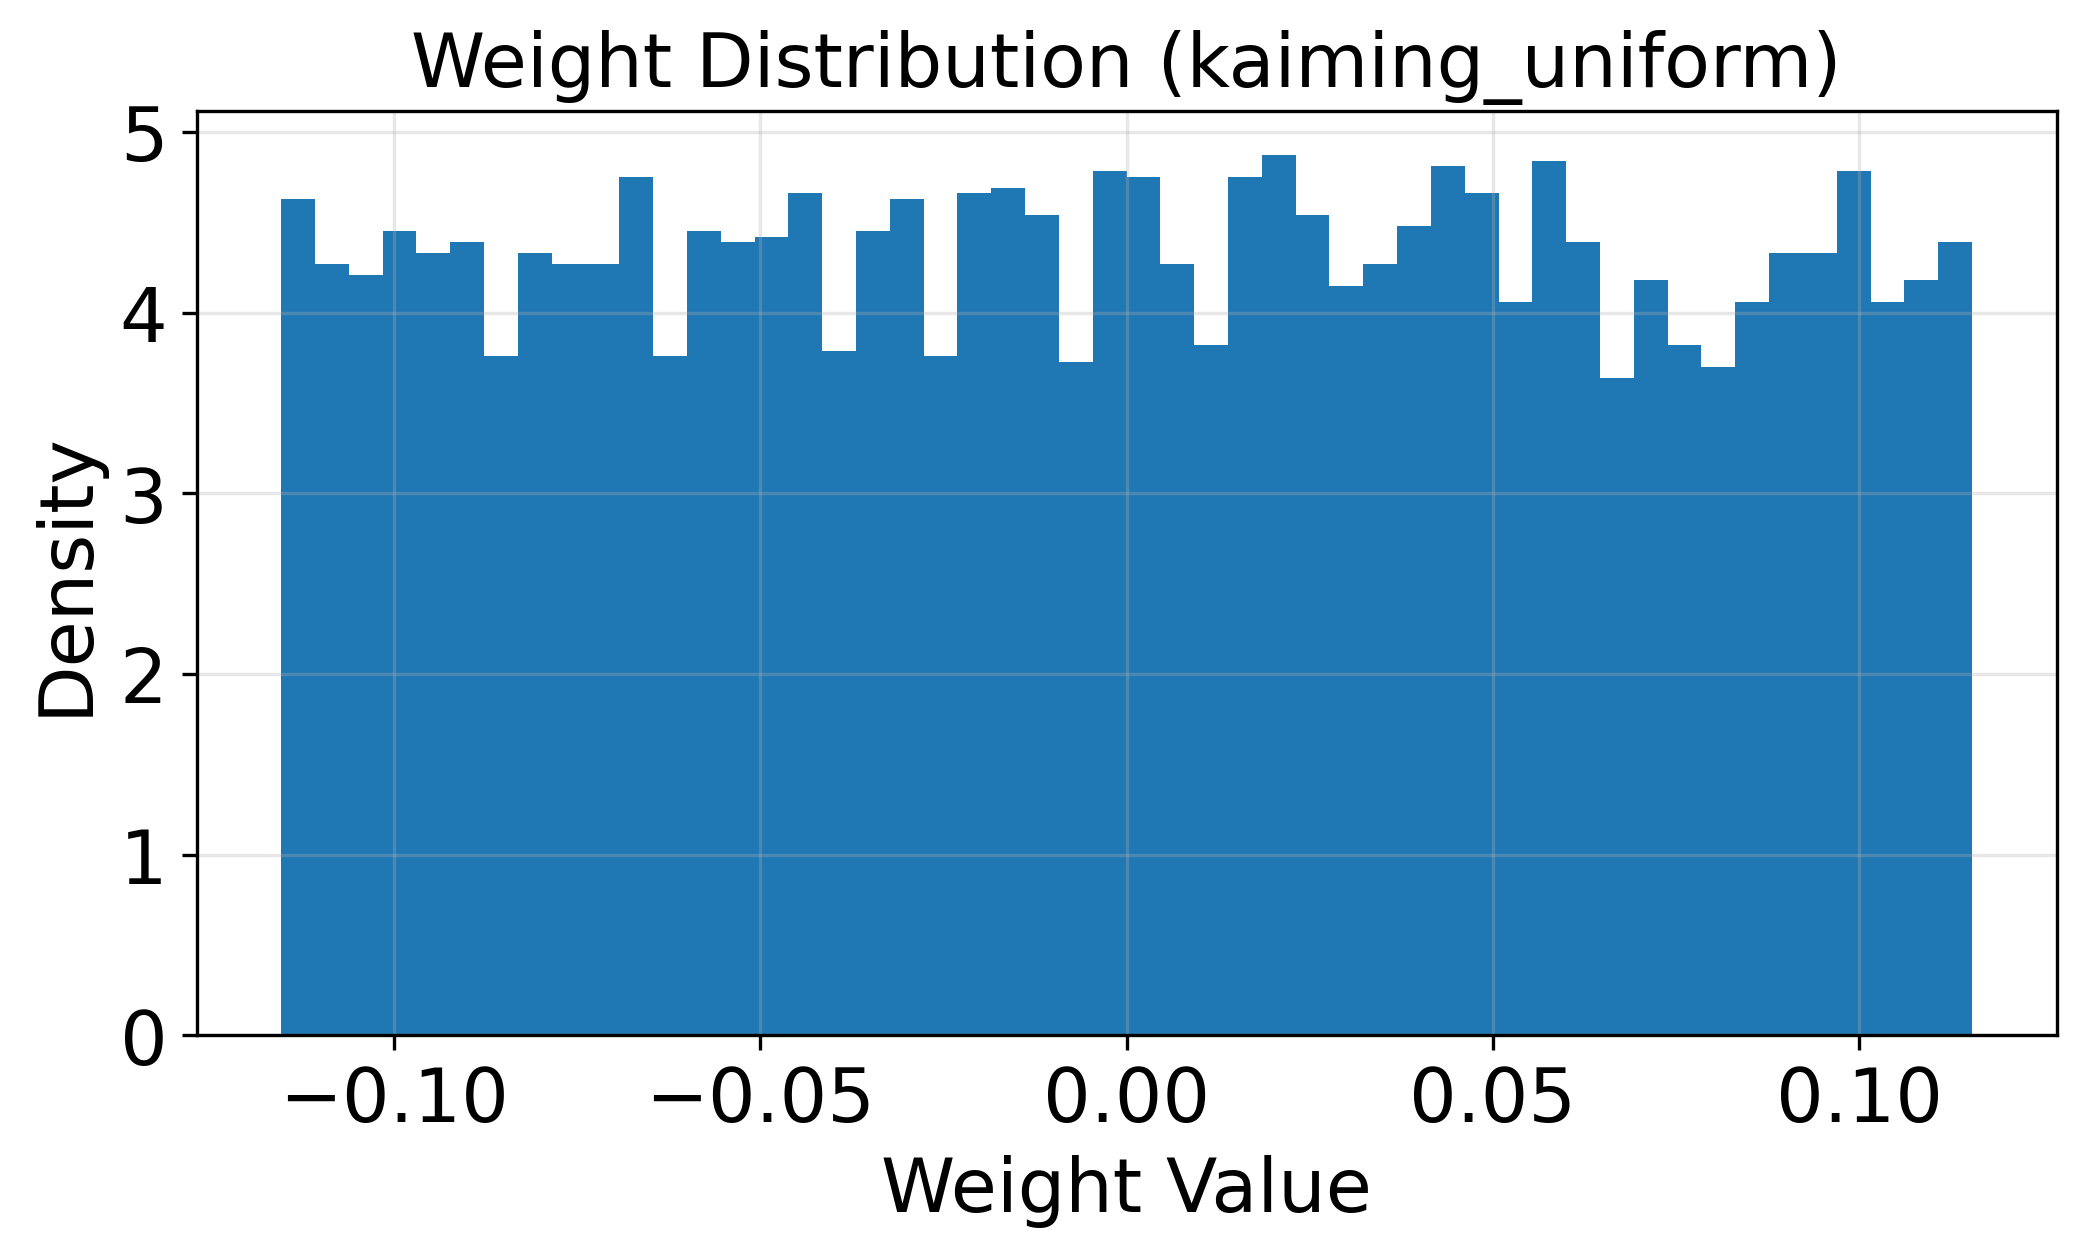

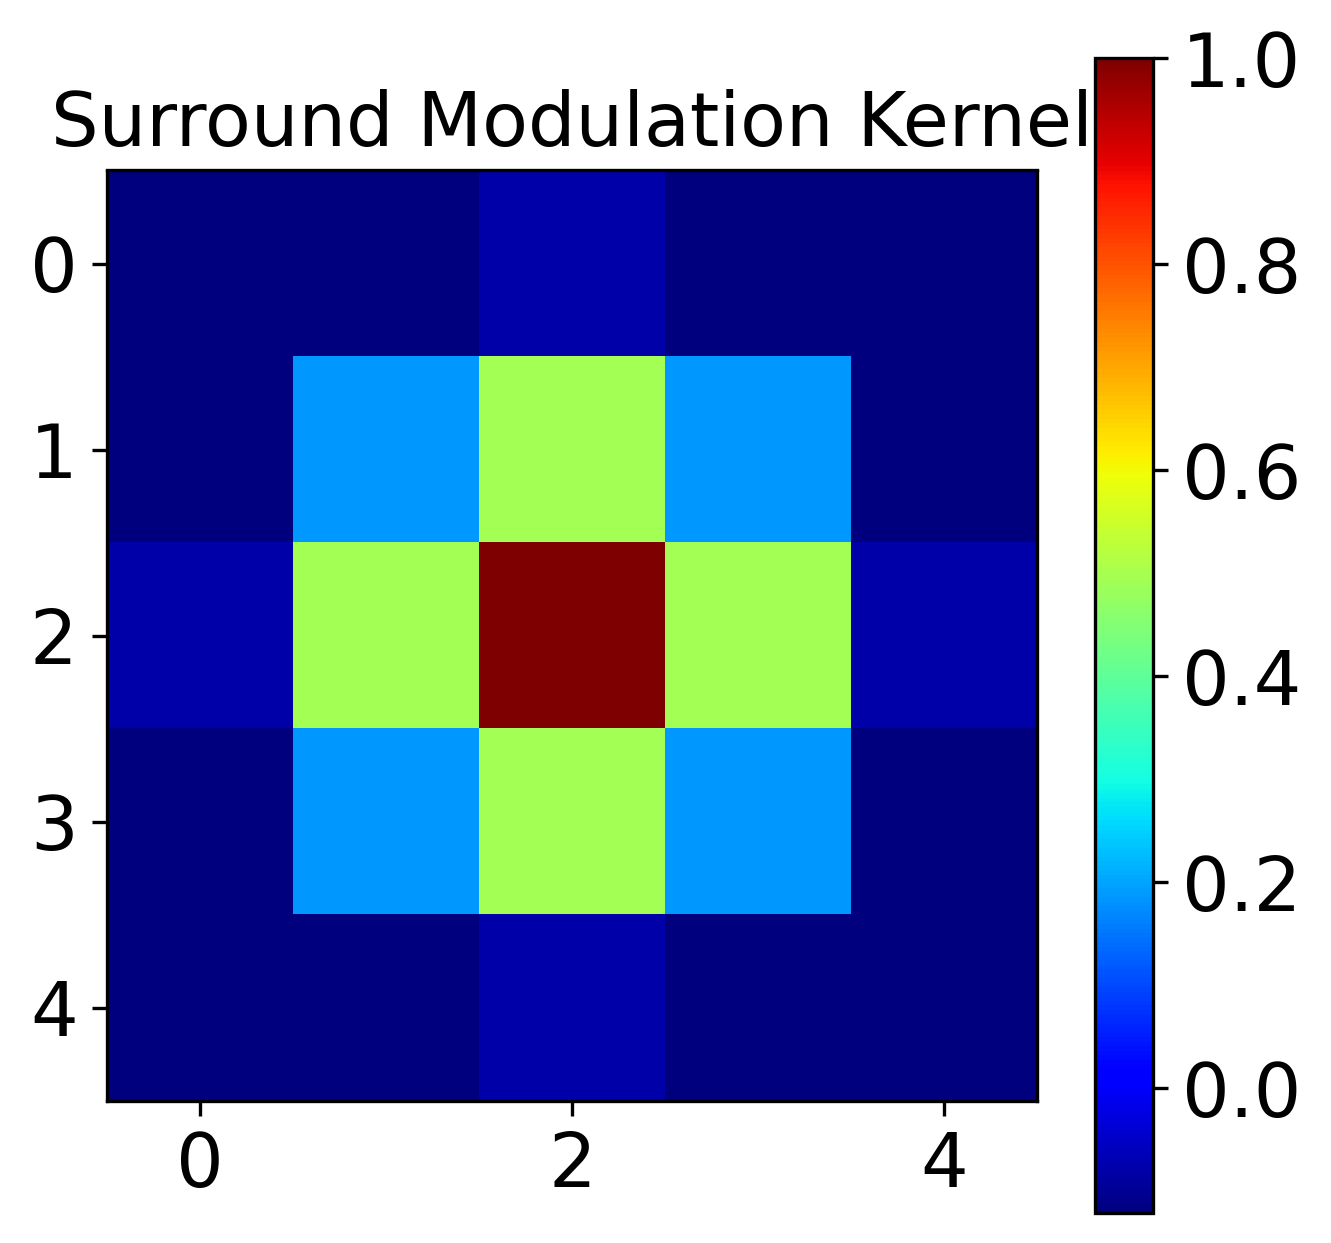

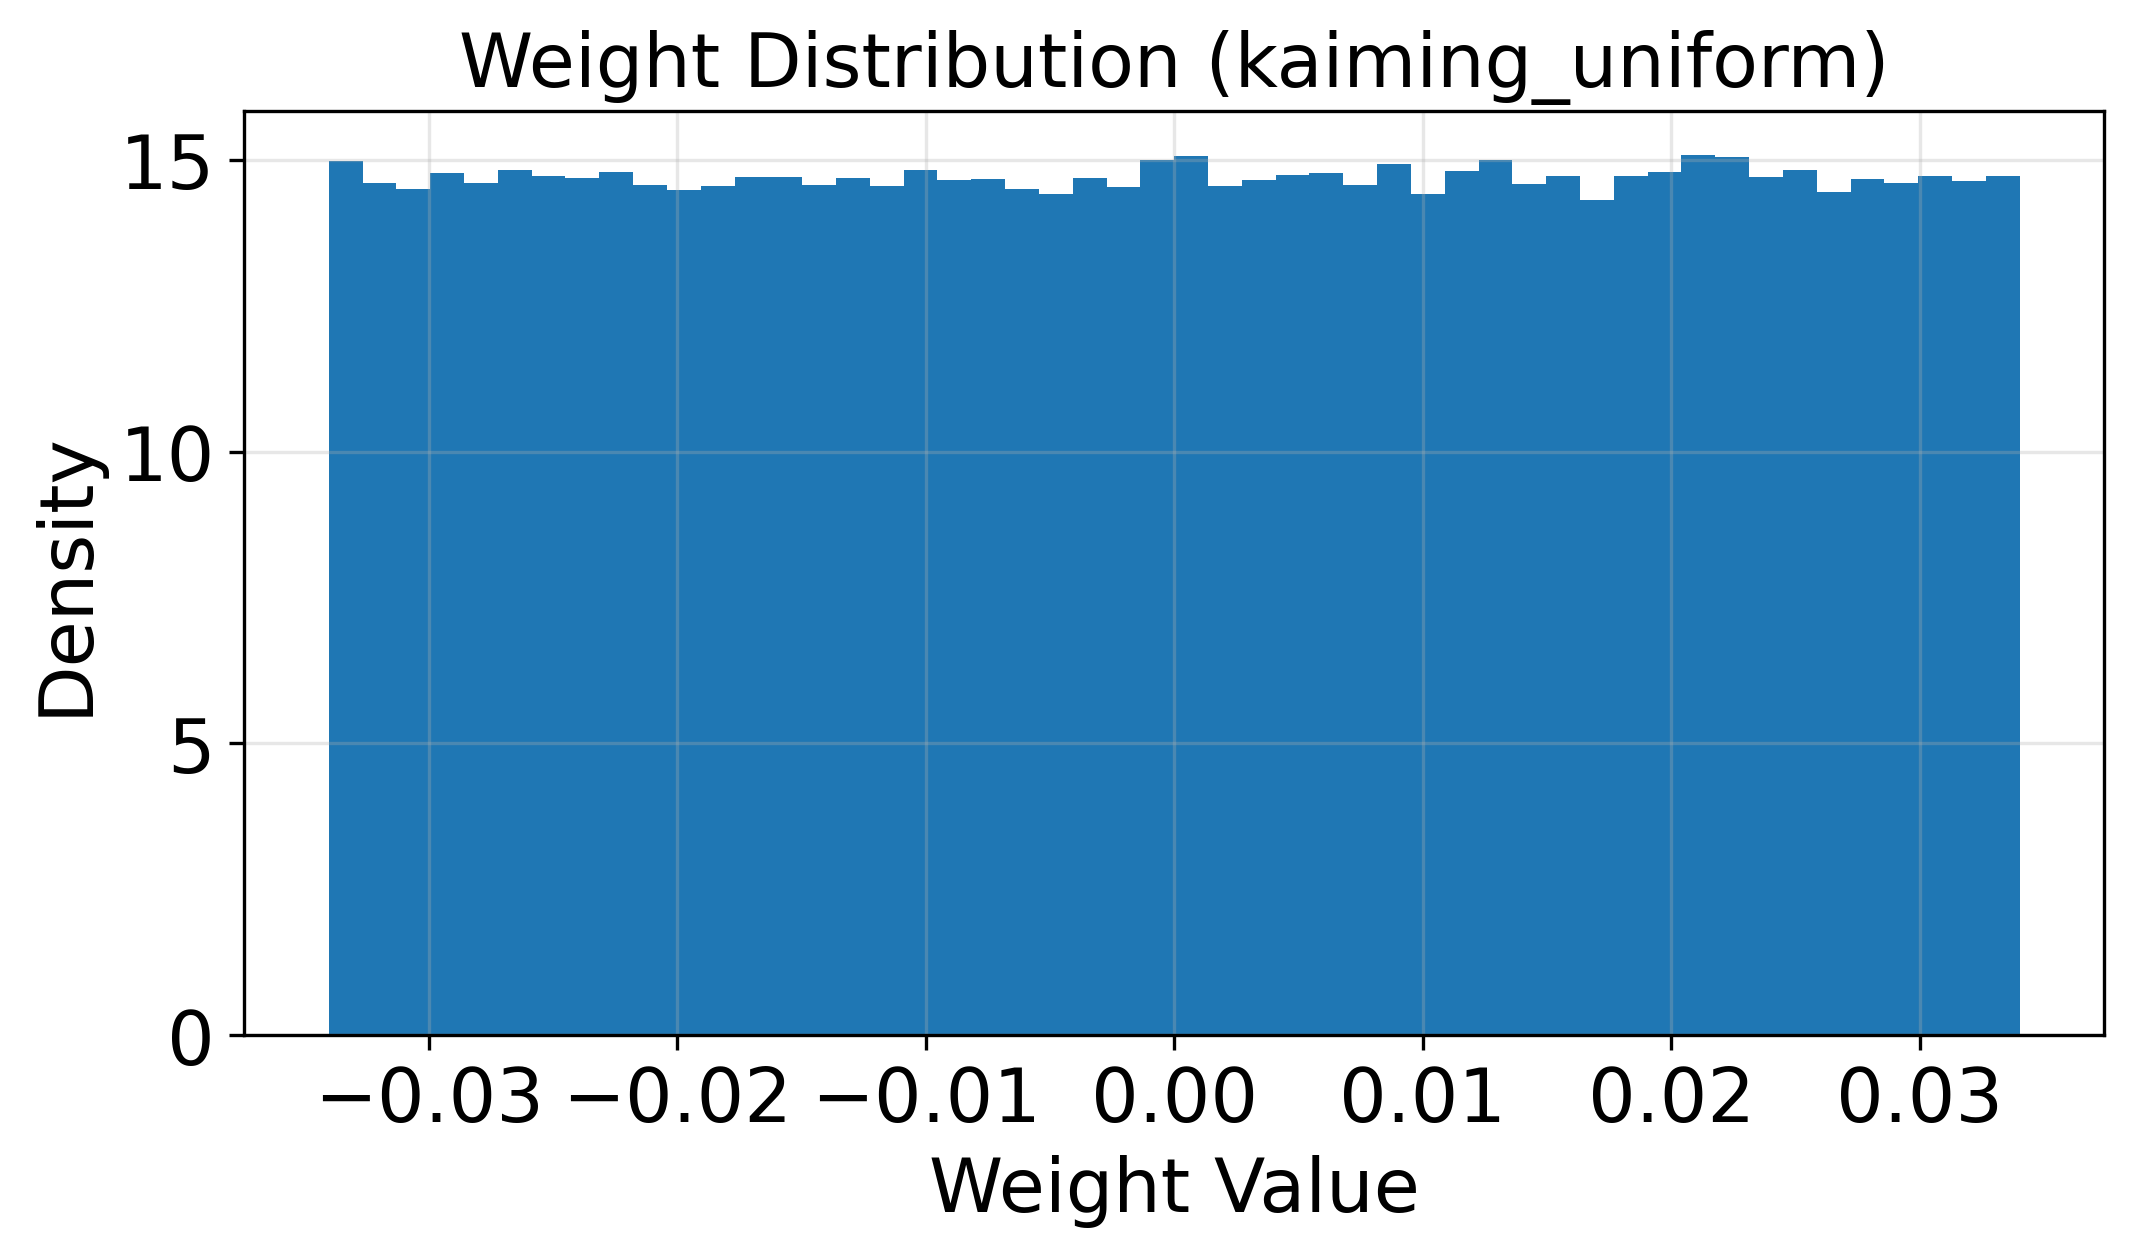

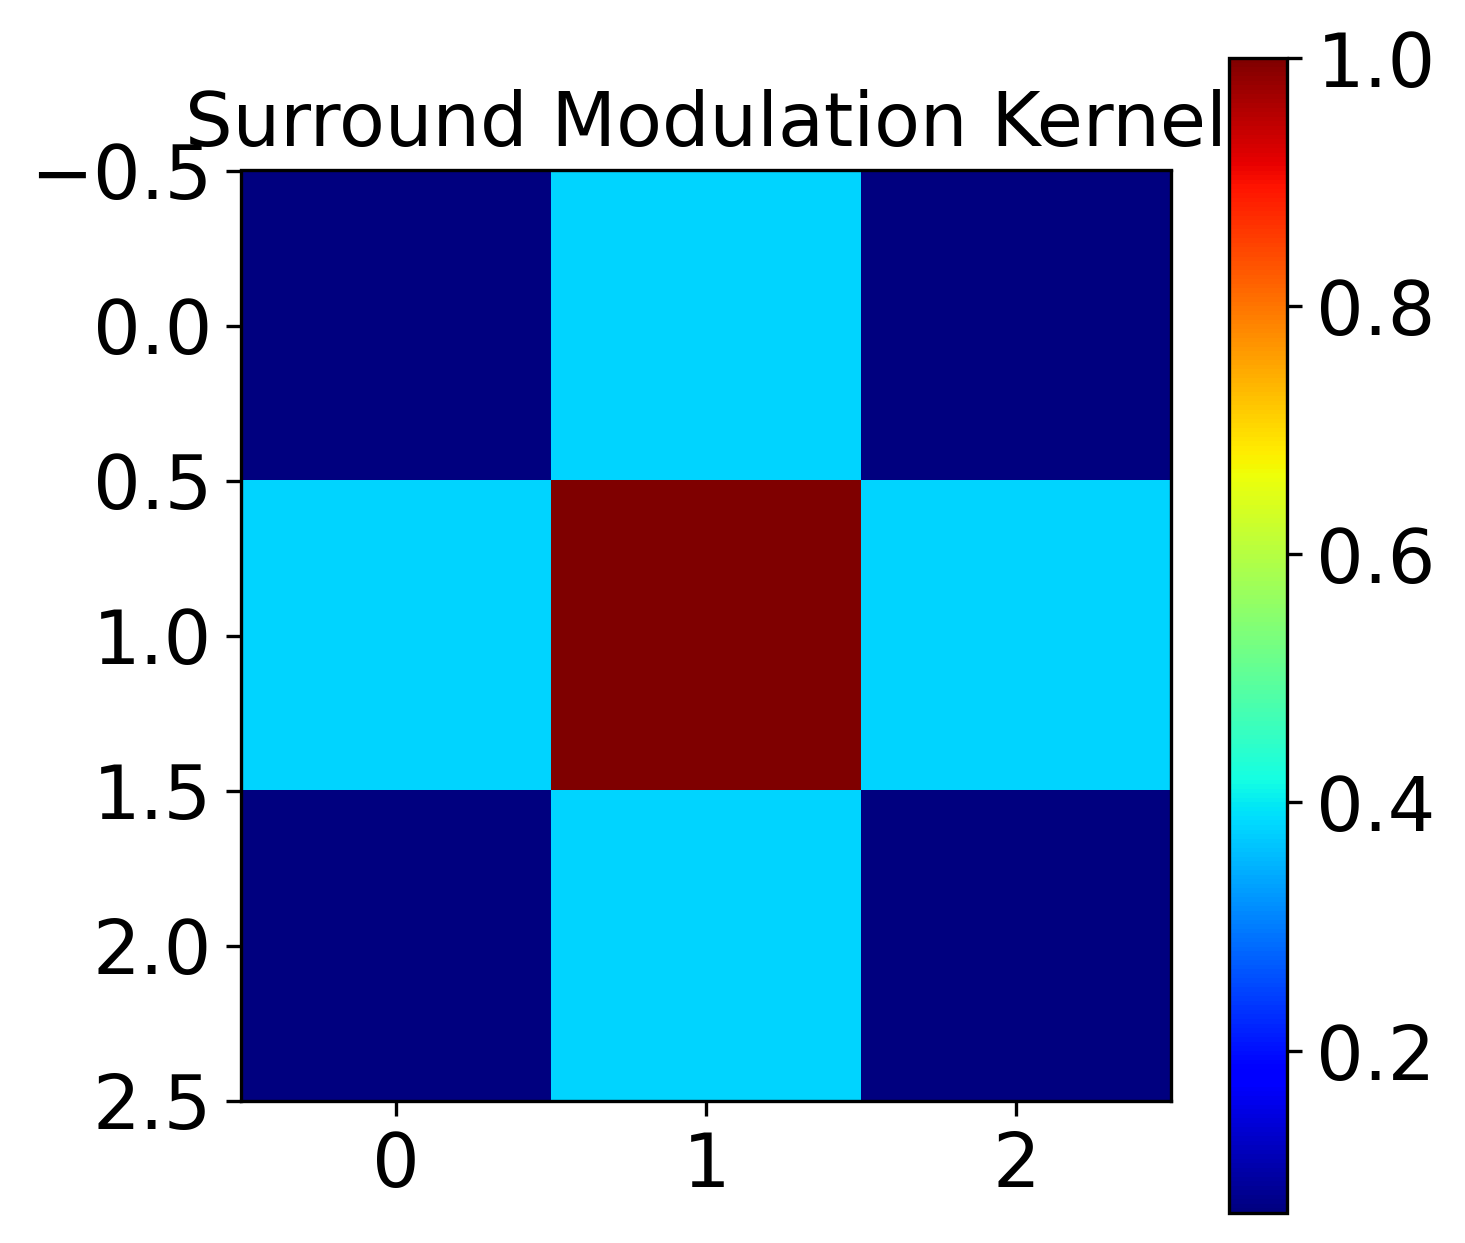

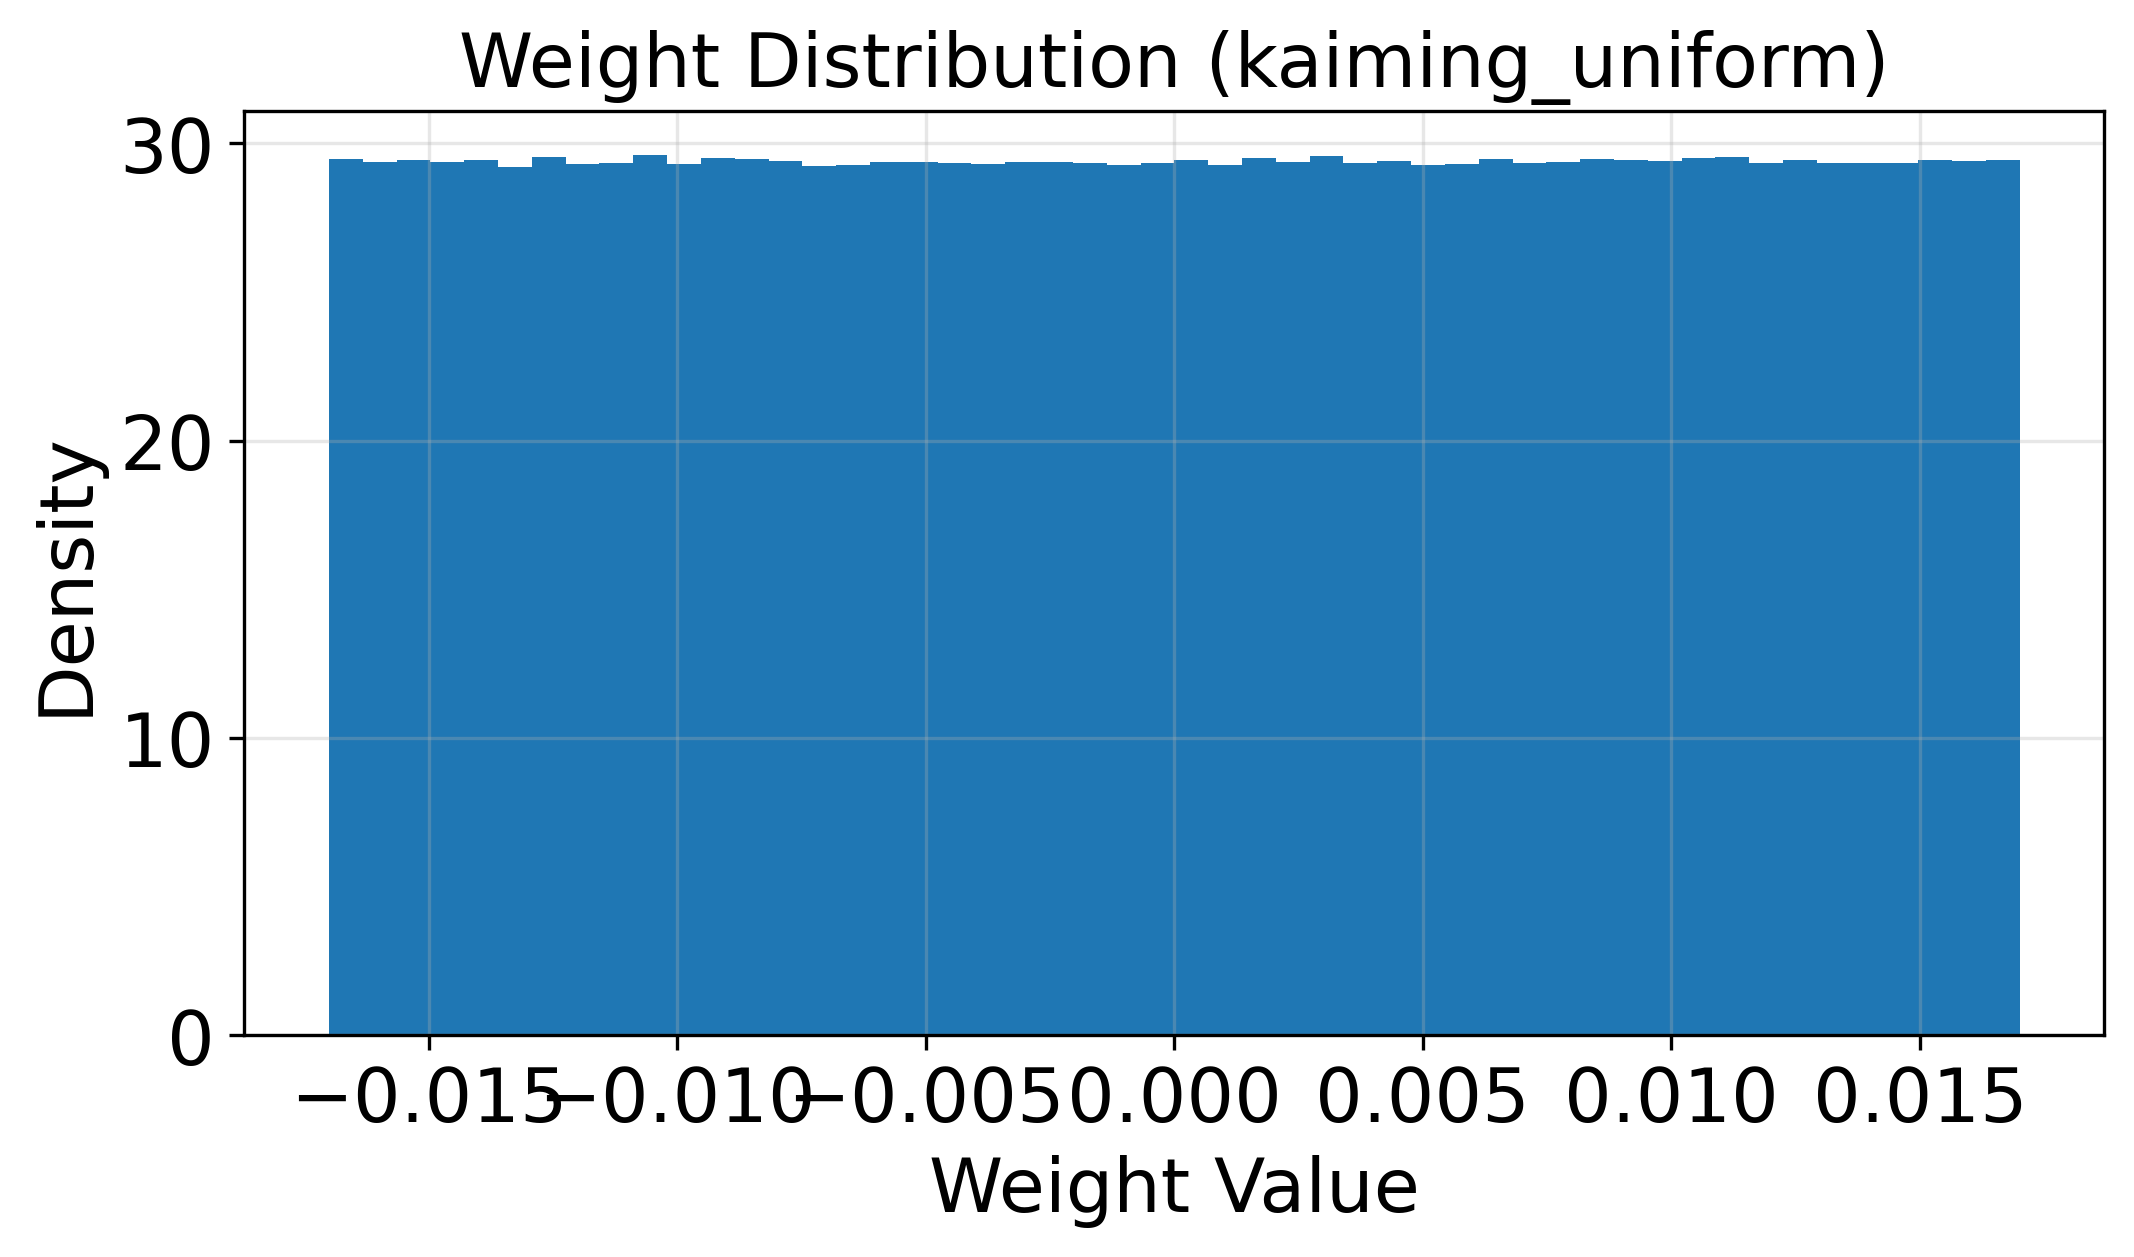

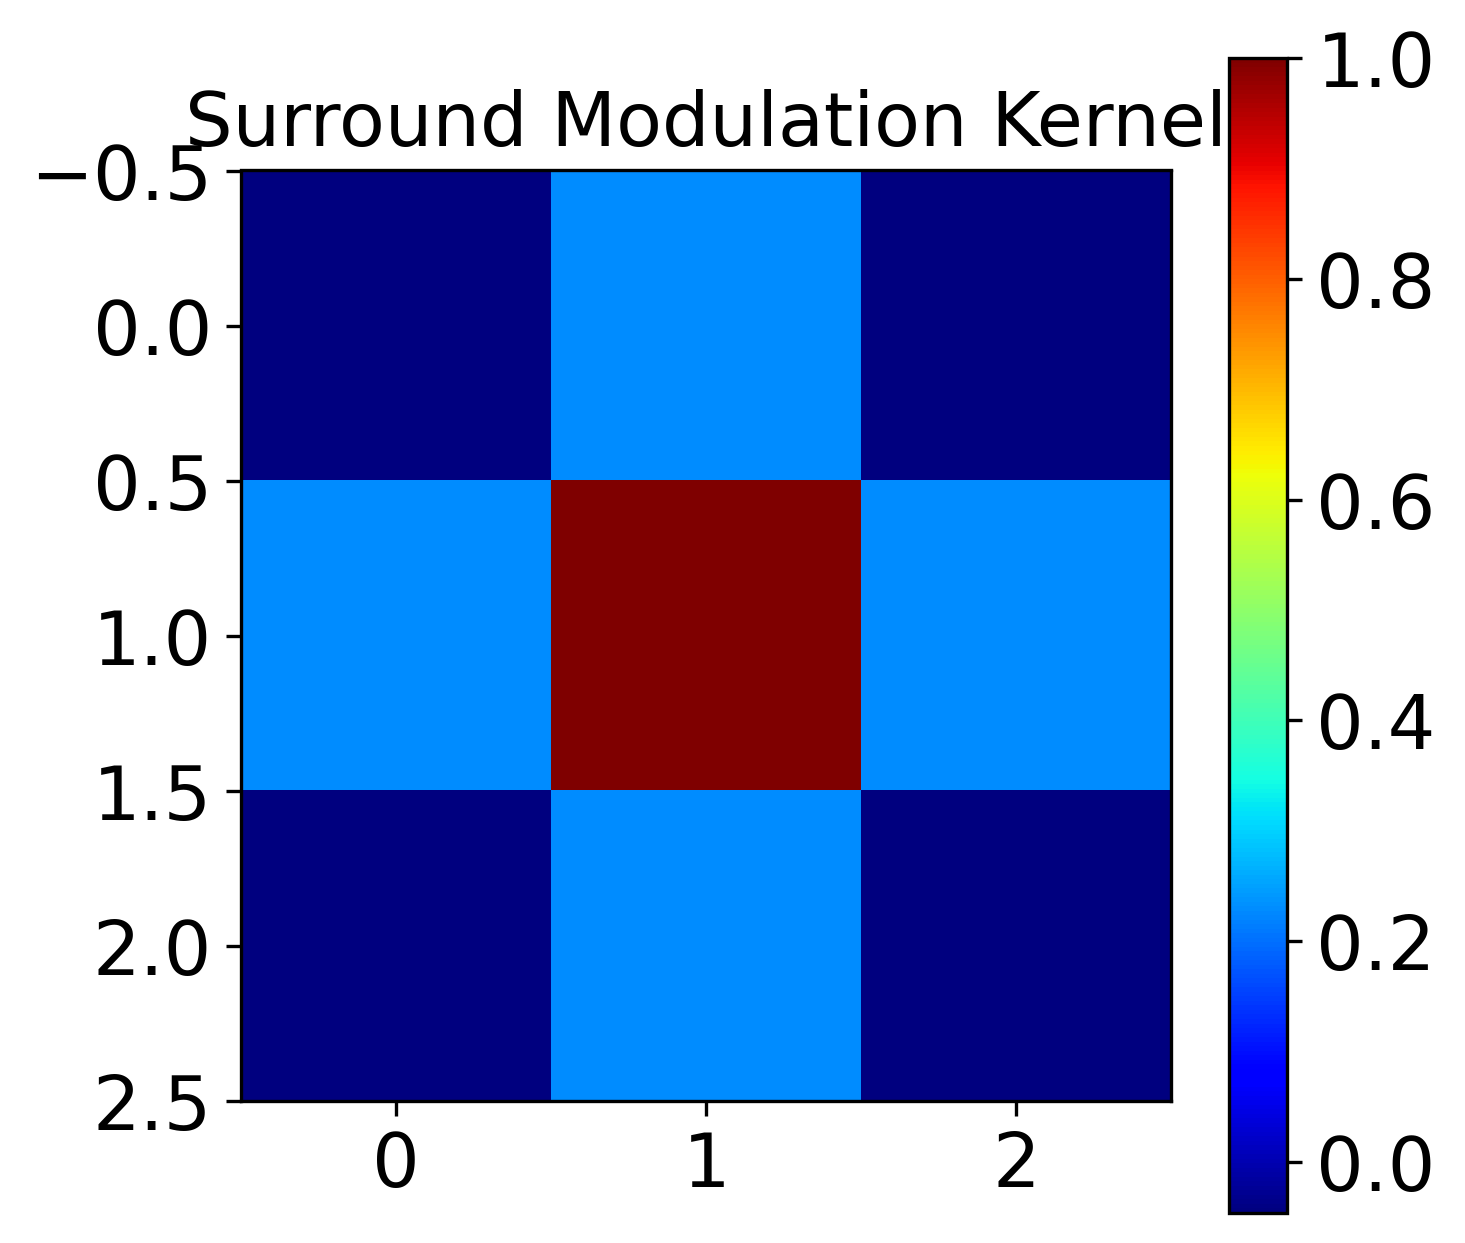

"\nconfusingly the researchers have given their 'optimal-HardWTA' described in the paper, a version name of 'softhebb'... we are not in fact selecting SoftHebb learning here, \nan easier way to understand what their optimal version is, looks like this:\nJourne architecture (as cited in their work) + cosine similarity + lateral inhibition + BCM learning + hard WTA"

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="softhebb"
).to(device)
"""
confusingly the researchers have given their 'optimal-HardWTA' described in the paper, a version name of 'softhebb'... we are not in fact selecting SoftHebb learning here, 
an easier way to understand what their optimal version is, looks like this:
Journe architecture (as cited in their work) + cosine similarity + lateral inhibition + BCM learning + hard WTA"""

In [12]:
for i, layer in enumerate([model.conv1, model.conv2, model.conv3], 1):
    print(
        f"Conv{i}: "
        f"sigma_e={layer.sigma_e}, "
        f"sigma_i={layer.sigma_i}, "
        f"lateral_kernel={layer.lateral_kernel}"
    )

Conv1: sigma_e=1.2, sigma_i=1.3, lateral_kernel=5
Conv2: sigma_e=1.0, sigma_i=1.2, lateral_kernel=3
Conv3: sigma_e=0.8, sigma_i=1.1, lateral_kernel=3


In [13]:
hebb_param

{'mode': 'bcm',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': True,
 'use_lateral_inhibition': True,
 'top_k': 1,
 'init_method': 'kaiming_uniform',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [14]:
print("conv1 init:", model.conv1.init_method)
print("conv2 init:", model.conv2.init_method)
print("conv3 init:", model.conv3.init_method)

print("conv1 lr:", model.conv1.lr)
print("conv2 lr:", model.conv2.lr)
print("conv3 lr:", model.conv3.lr)

conv1 init: kaiming_uniform
conv2 init: kaiming_uniform
conv3 init: kaiming_uniform
conv1 lr: 0.1
conv2 lr: 0.08
conv3 lr: 0.05


In [15]:
for i, layer in enumerate(
    [model.conv1, model.conv2, model.conv3], 1
):
    print(f"\nConv {i}")
    print("mode:", layer.mode)
    print("w_nrm:", layer.w_nrm)
    print("k:", getattr(layer, "k", "not stored"))
    print("alpha:", layer.alpha)
    print("t_invert:", layer.t_invert.item())
    print("lr:", layer.lr)
    print("init:", layer.init_method)
    print("cosine:", layer.use_cosine_similarity)
    print("lateral inhibition:", layer.use_lateral_inhibition)


Conv 1
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 1
lr: 0.1
init: kaiming_uniform
cosine: True
lateral inhibition: True

Conv 2
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.6499999761581421
lr: 0.08
init: kaiming_uniform
cosine: True
lateral inhibition: True

Conv 3
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.25
lr: 0.05
init: kaiming_uniform
cosine: True
lateral inhibition: True


In [16]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv2): HebbianConv2d(
    (act): Identity()
  )
  (pool2): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ2): Triangle()
  (bn3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv3): HebbianConv2d(
    (act): Identity()
  )
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (activ3): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=24576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [17]:
num_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parameter count: {num_parameters:,}")

Parameter count: 5,893,162


# Get Cifar-10

In [18]:
#this is the function we would use to get and transform the data, however since Toronto University servers have incredibly slow download time for cifar-10, again we use the mirror from kaggle
from data_processing.data import get_data

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10' dataset.
Path to dataset files: /kaggle/input/cifar10


In [20]:
print(os.listdir(path))

['cifar10']


In [21]:
cifar_path = os.path.join(path, "cifar10")

### Getting Train Split

In [22]:
cifar_train_path = os.path.join(cifar_path,"train")

In [23]:
from torchvision import datasets, transforms


base_transform = transforms.ToTensor()

train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=base_transform
)



### Getting Test Split

In [24]:
cifar_test_path = os.path.join(cifar_path,"test")

In [25]:
test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=base_transform
)

## Whitening

In [26]:
class ZCAWhitening:
    def __init__(self, epsilon=1e-3):
        self.epsilon = epsilon
        self.zca_matrix = None
        self.mean = None
        self.std = None

    def fit(self, x):
        x = x.reshape(x.shape[0], -1)

        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True)

        x = (x - self.mean) / (self.std + self.epsilon)

        cov = torch.mm(x.T, x) / (x.shape[0] - 1)

        eigenvalues, eigenvectors = torch.linalg.eigh(cov)

        inv_sqrt_eigenvalues = torch.diag(
            1.0 / torch.sqrt(eigenvalues + self.epsilon)
        )

        self.zca_matrix = (
            eigenvectors
            @ inv_sqrt_eigenvalues
            @ eigenvectors.T
        )

    def transform(self, x):
        original_shape = x.shape

        x = x.reshape(x.shape[0], -1)
        x = (x - self.mean) / (self.std + self.epsilon)

        x_whitened = torch.mm(x, self.zca_matrix)

        return x_whitened.reshape(original_shape)

In [27]:
from torch.utils.data import ConcatDataset, DataLoader

combined_dataset = ConcatDataset([
    train_dataset,
    test_dataset
])

zca_loader = DataLoader(
    combined_dataset,
    batch_size=64,
    shuffle=True
)

In [28]:
all_data = []

for images, _ in zca_loader:
    all_data.append(images)

all_data = torch.cat(all_data, dim=0)

print(all_data.shape)

torch.Size([60000, 3, 32, 32])


In [29]:
zca = ZCAWhitening(epsilon=1e-3)
#researchers perform zca whitening across the whole dataset (train and test), which would seem to leak statistics 
zca.fit(all_data)

In [30]:
class ZCATransform:
    def __init__(self, zca):
        self.zca = zca

    def __call__(self, x):
        x = x.unsqueeze(0)
        x = self.zca.transform(x)
        return x.squeeze(0)

In [31]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    #ZCATransform(zca)
])

In [32]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

#oddly the researchers use random horizontal flipping on the test set (in addition to the train)
test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

In [33]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,  #uses 64 to reproduce their experiment
    shuffle=True,
    num_workers=2
)

In [34]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

In [35]:
device

device(type='cuda')

# The 5 runs...

In [39]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [35]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

RUN 1/5 | SEED = 0
Building SoftHebb model


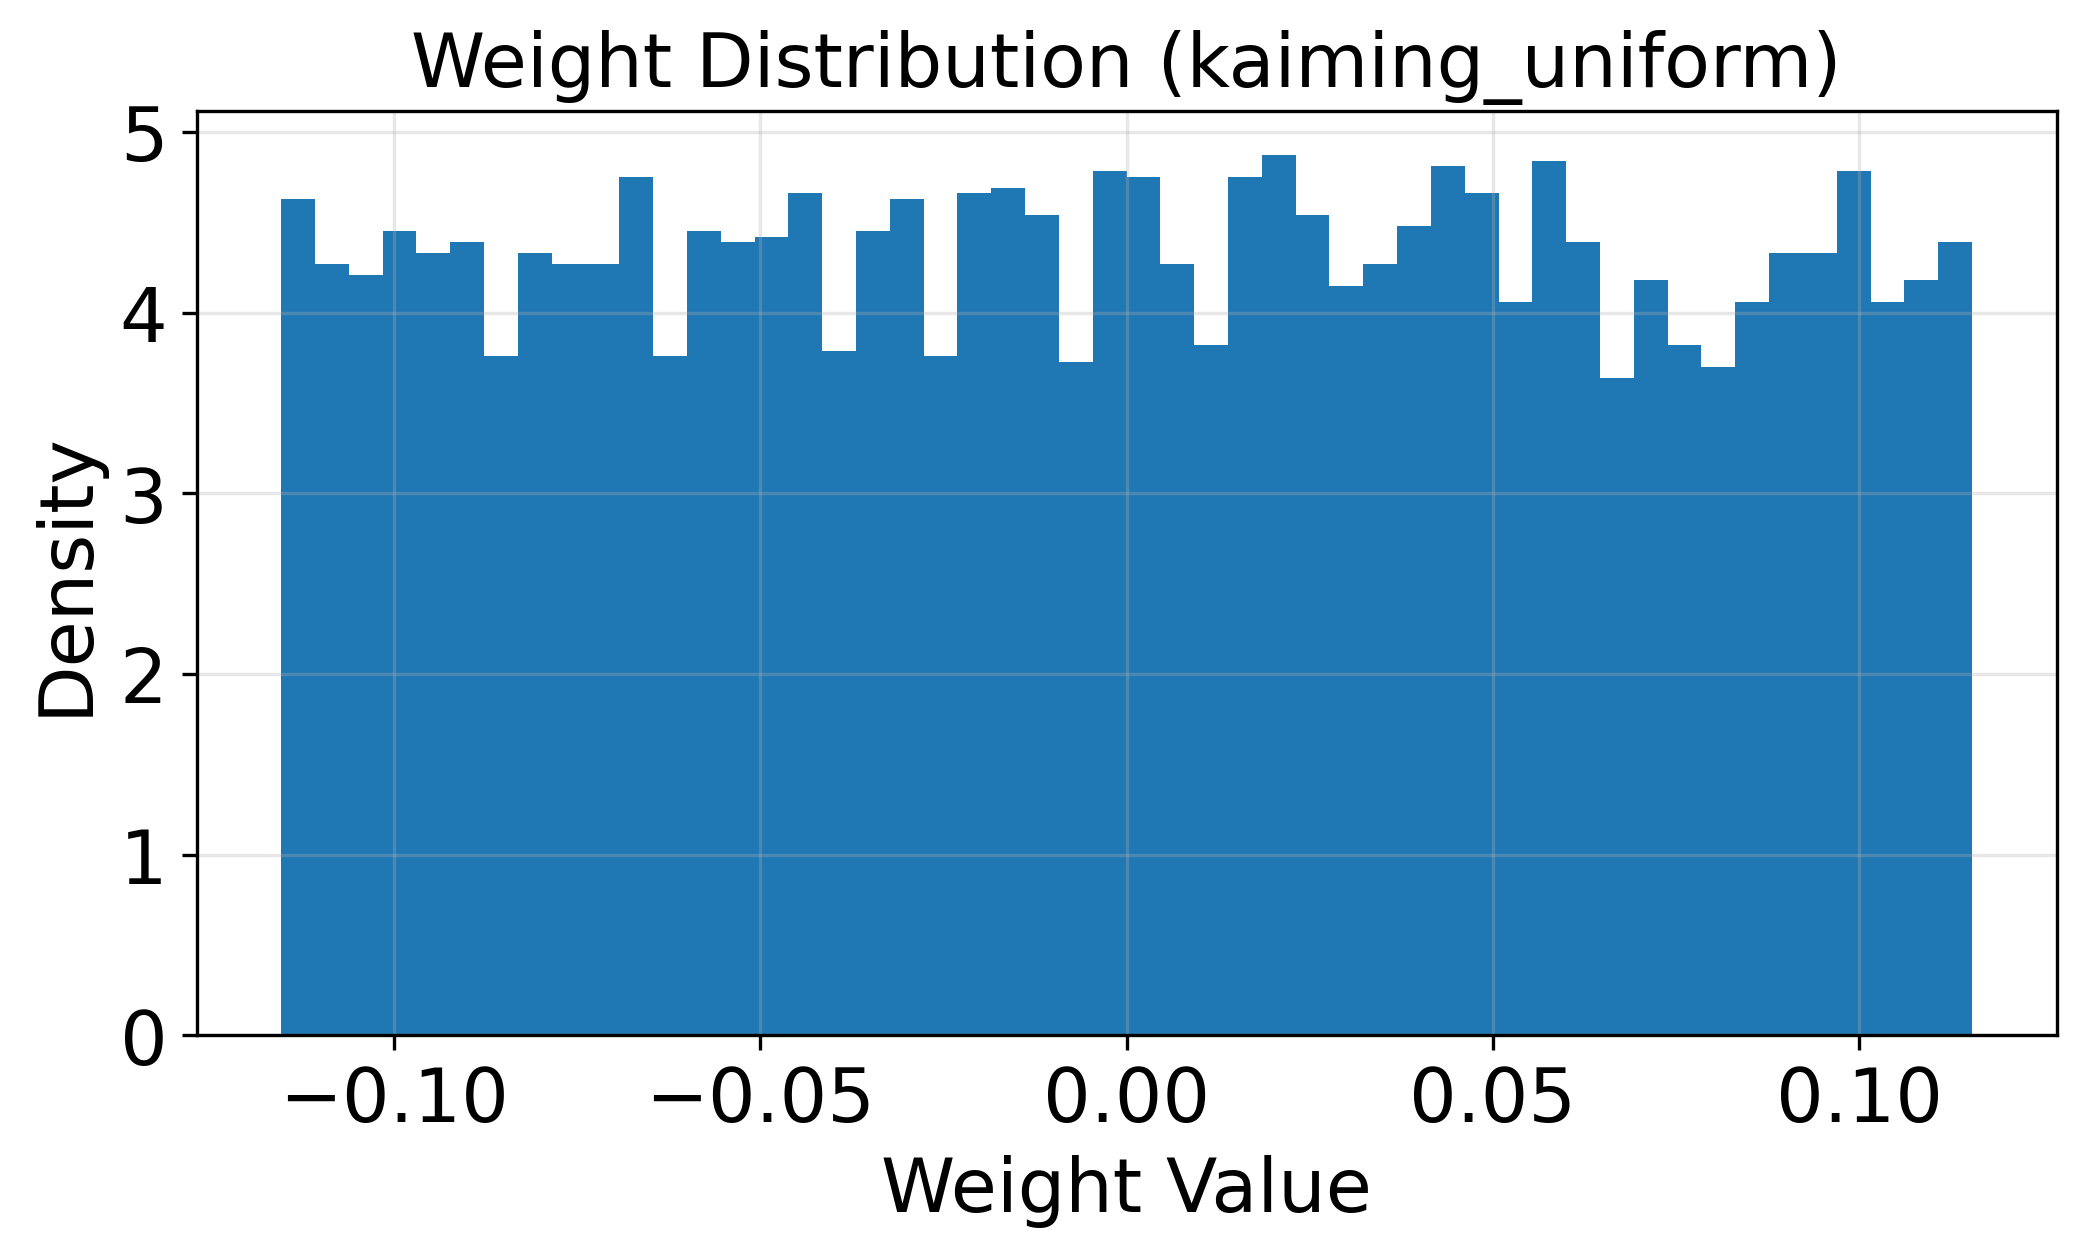

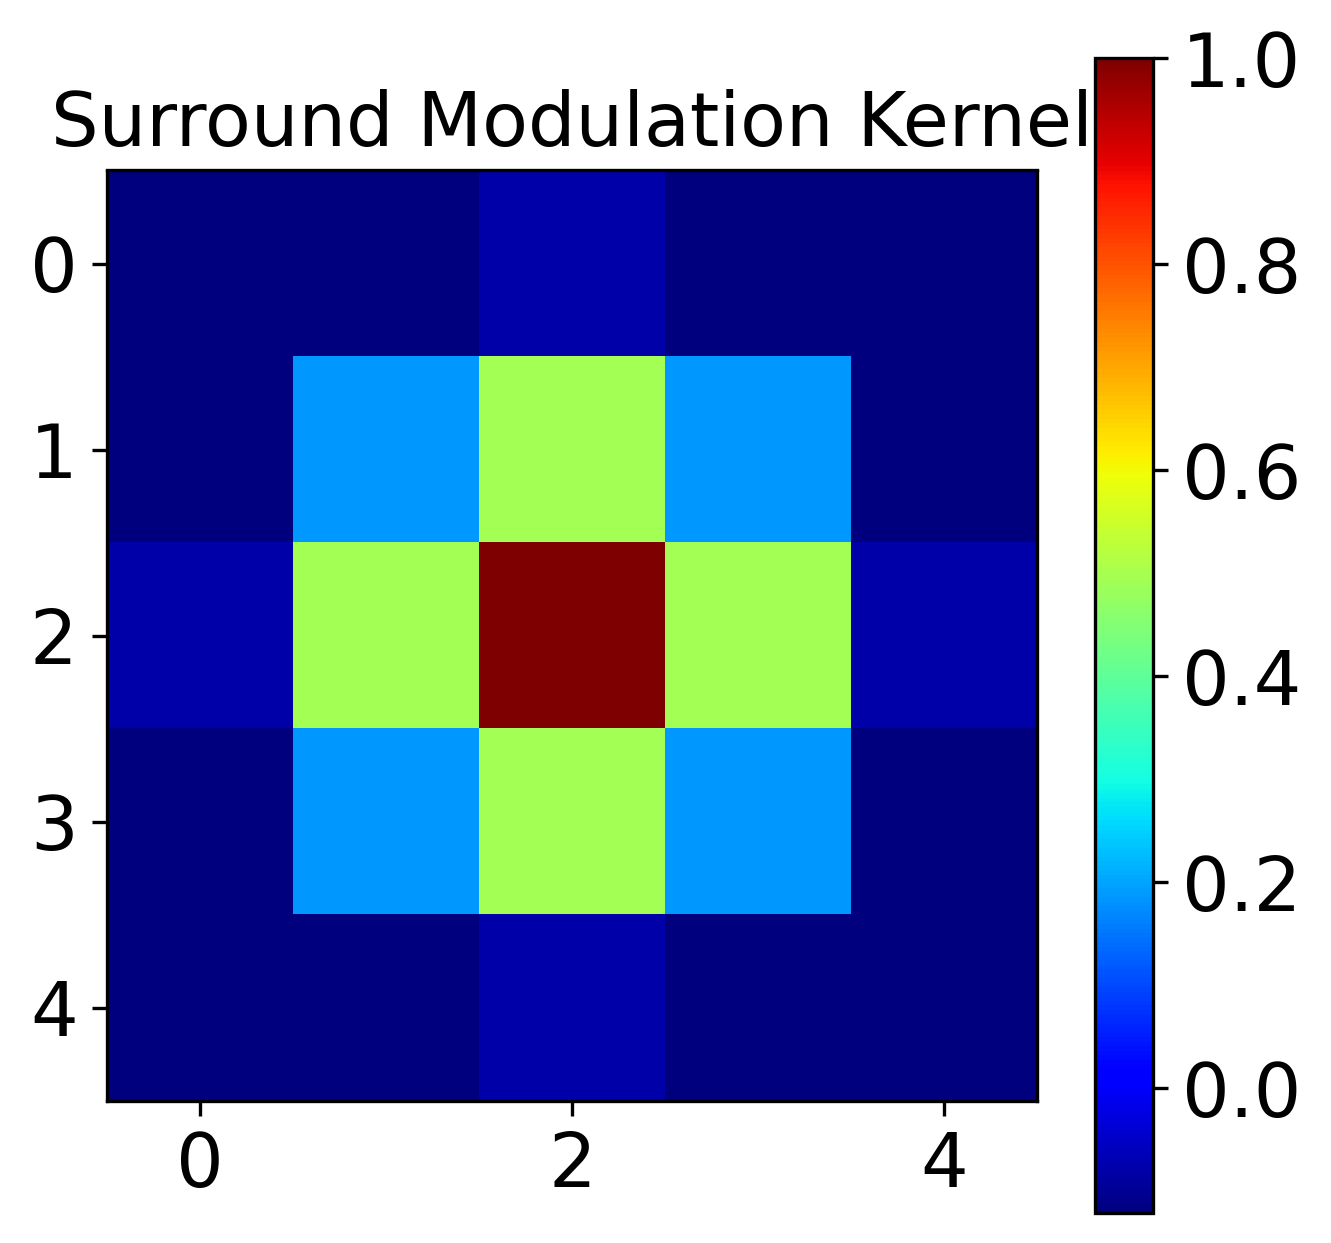

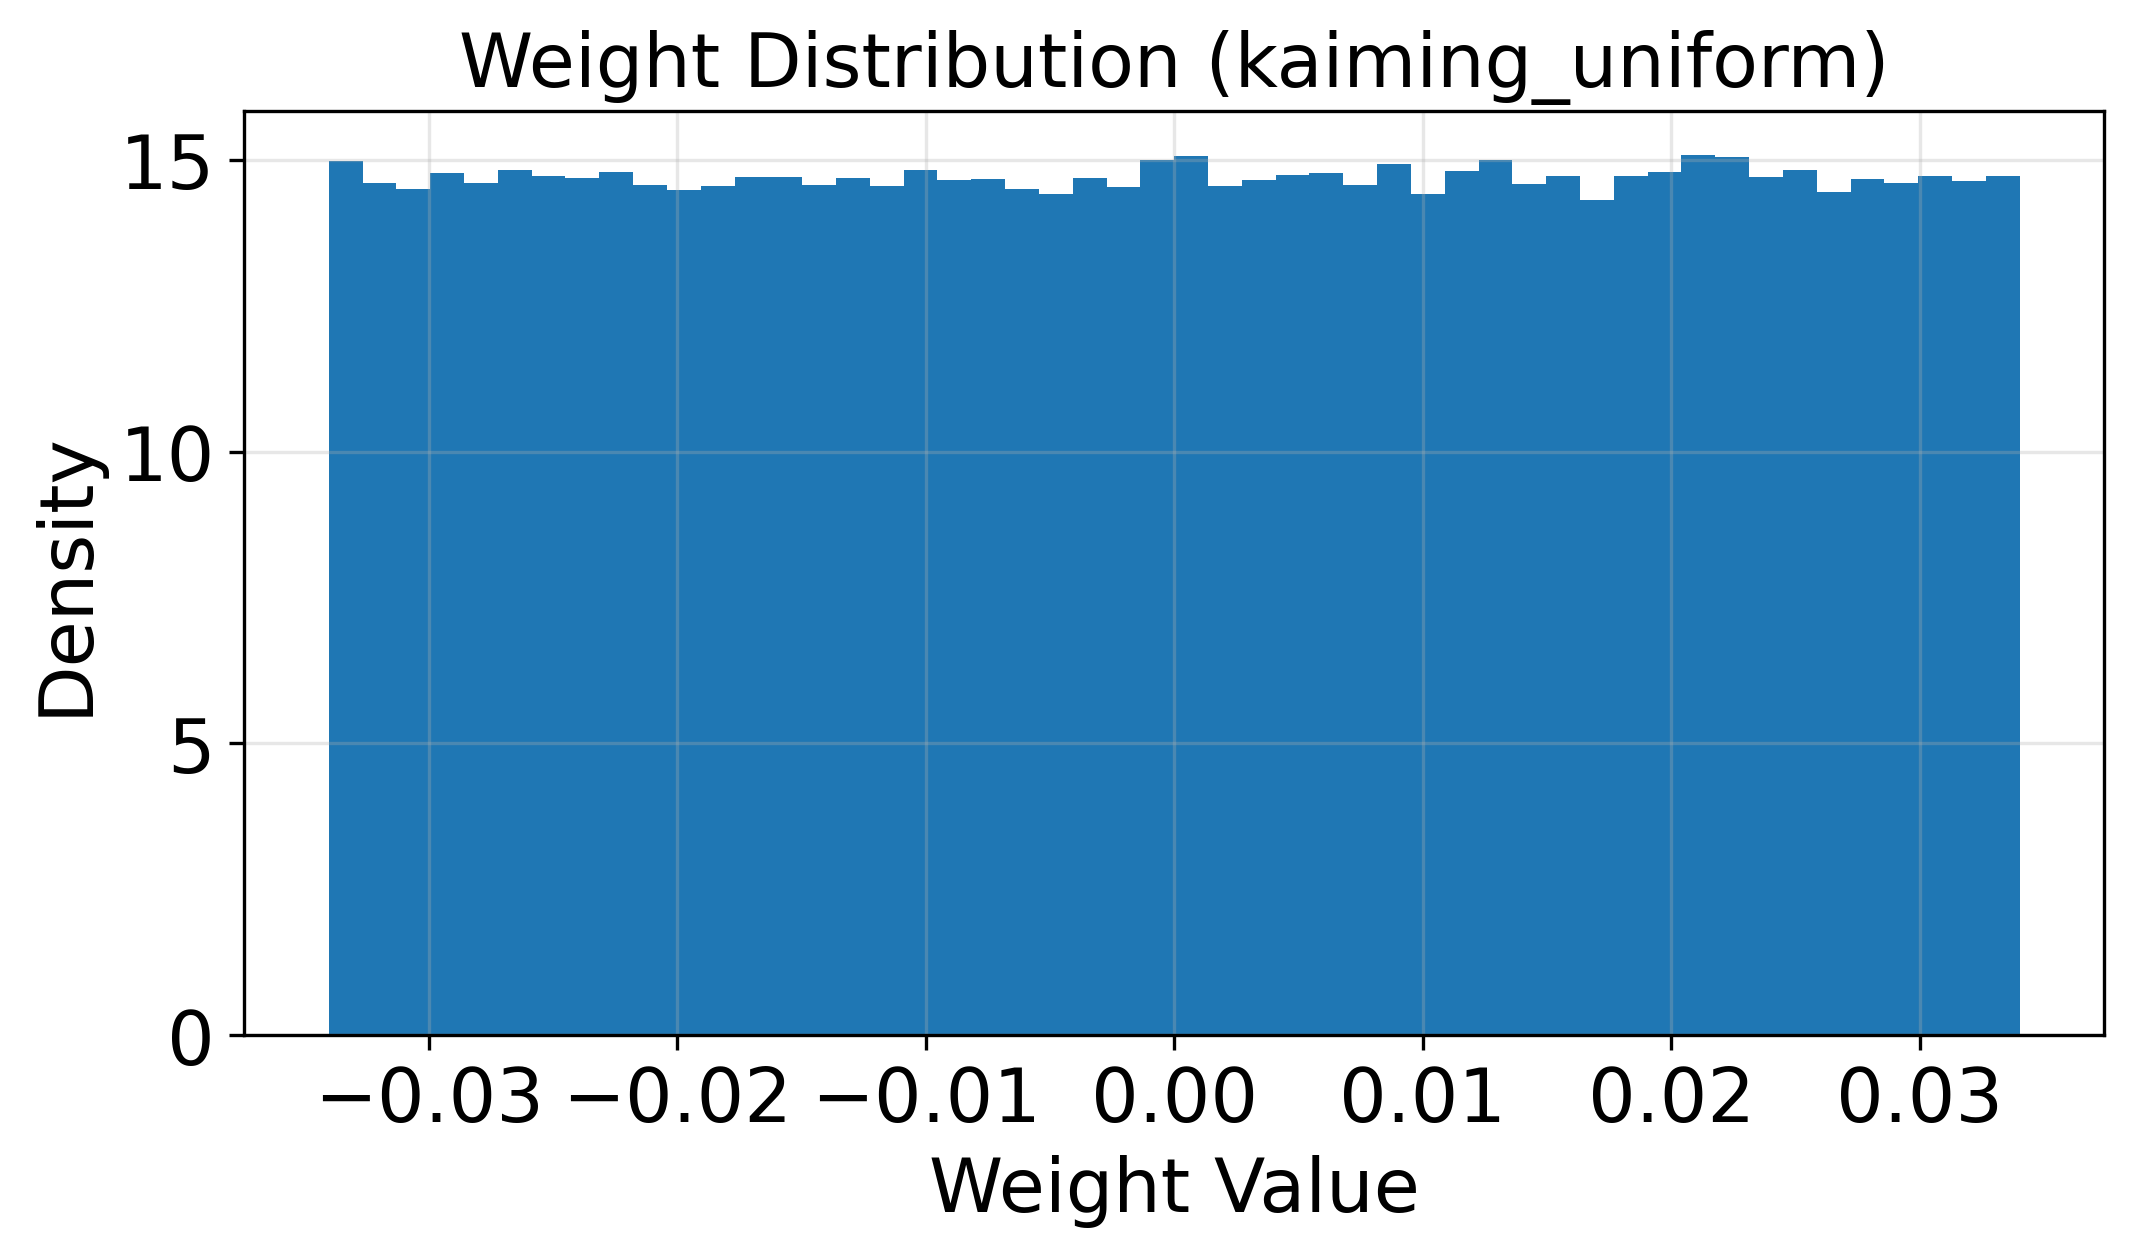

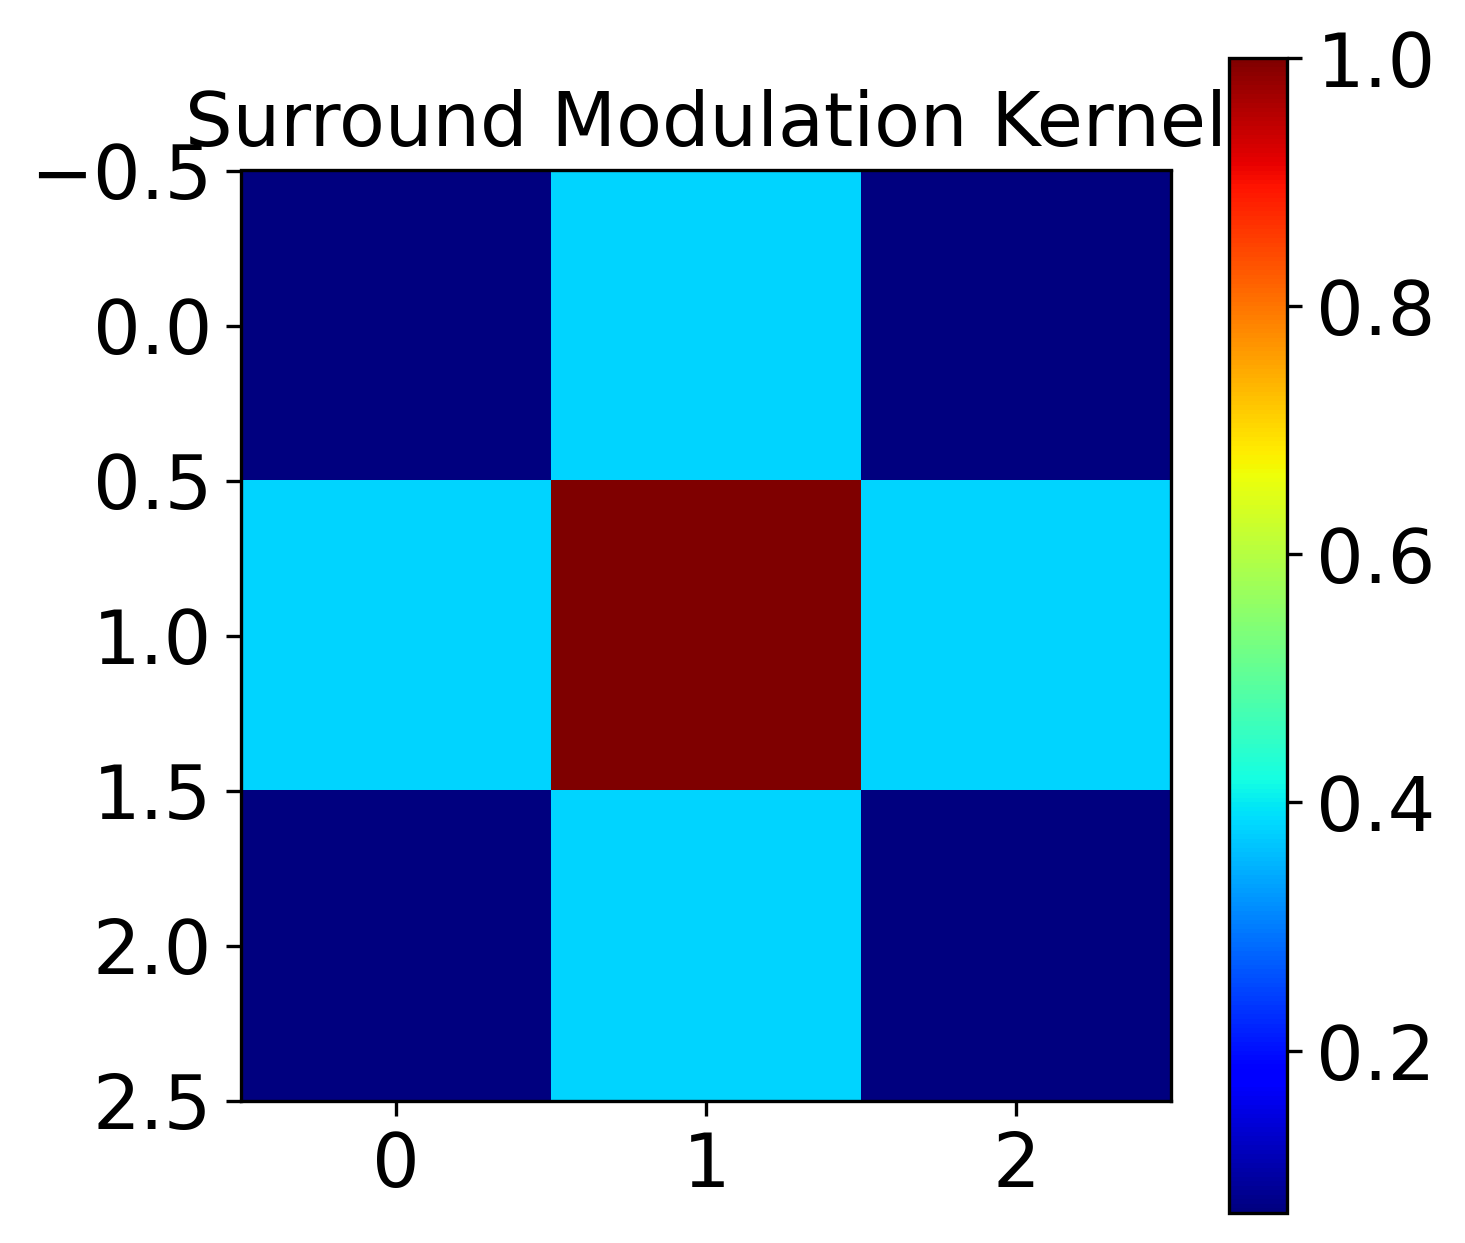

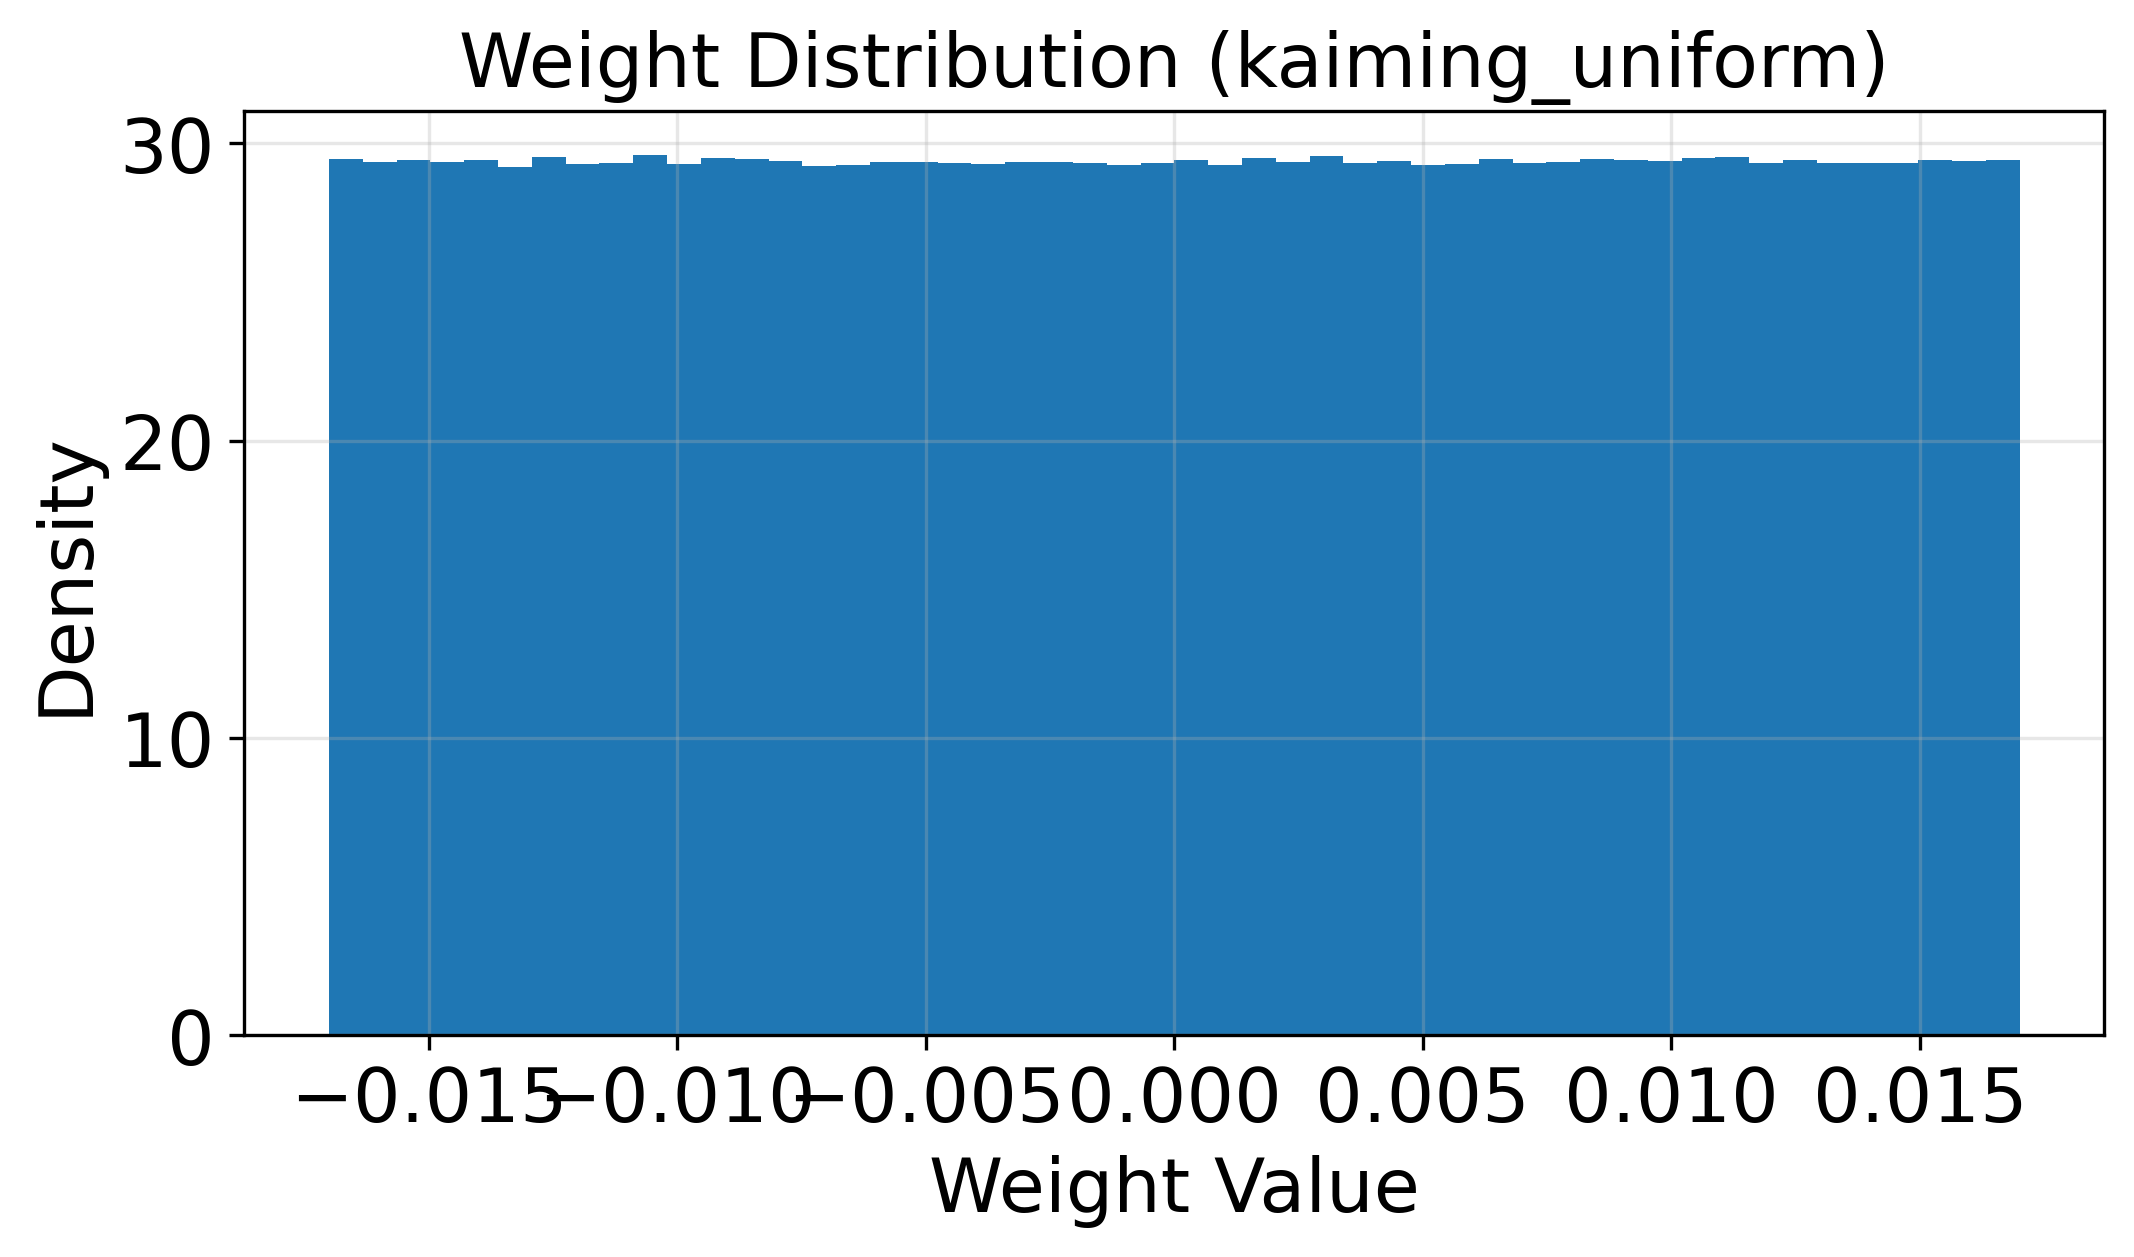

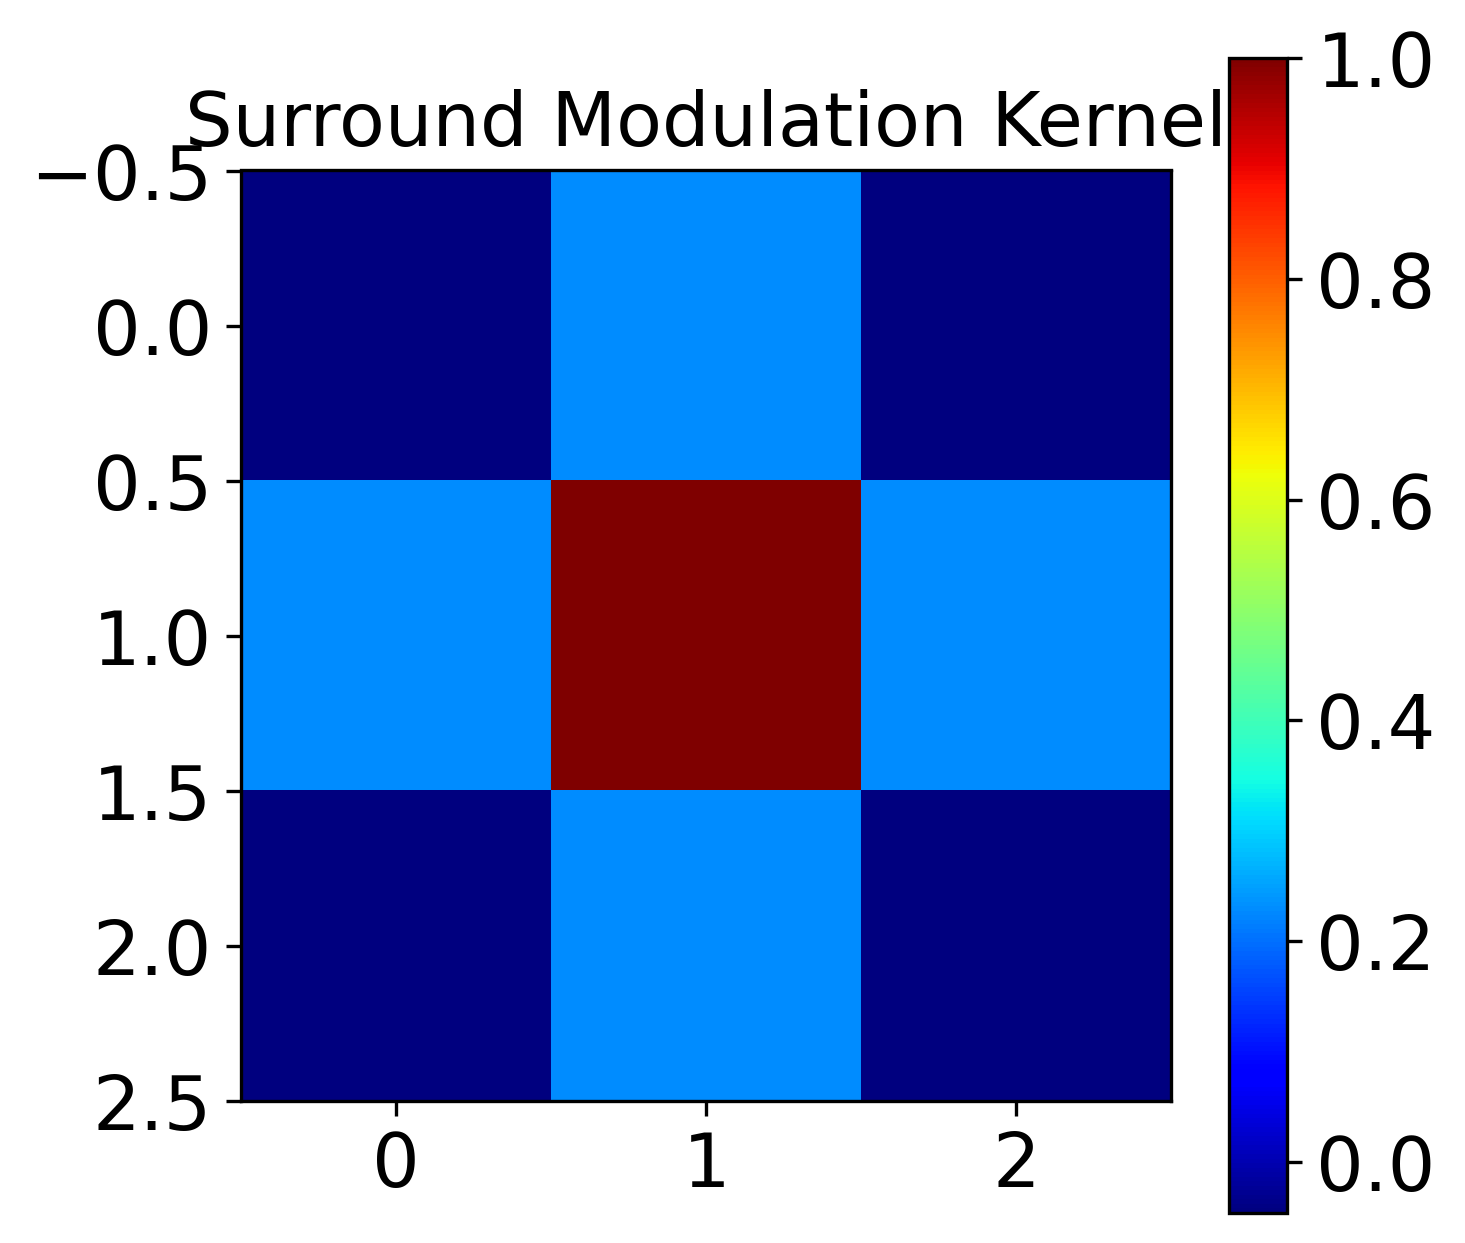

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3136 | Train Acc: 54.12% | Test Loss: 1.0493 | Test Acc: 63.65% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0349 | Train Acc: 63.95% | Test Loss: 0.9430 | Test Acc: 67.28% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9597 | Train Acc: 66.70% | Test Loss: 0.9043 | Test Acc: 68.99% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9211 | Train Acc: 68.03% | Test Loss: 0.8628 | Test Acc: 69.83% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8953 | Train Acc: 69.00% | Test Loss: 0.8477 | Test Acc: 70.38% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8726 | Train Acc: 69.80% | Test Loss: 0.8369 | Test Acc: 70.73% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8586 | Train Acc: 70.49% | Test Loss: 0.8244 | Test Acc: 71.66% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8528 | Train Acc: 70.35% | Test Loss: 0.8265 | Test Acc: 71.89% | LR: 0.001000
Epoch [9/2

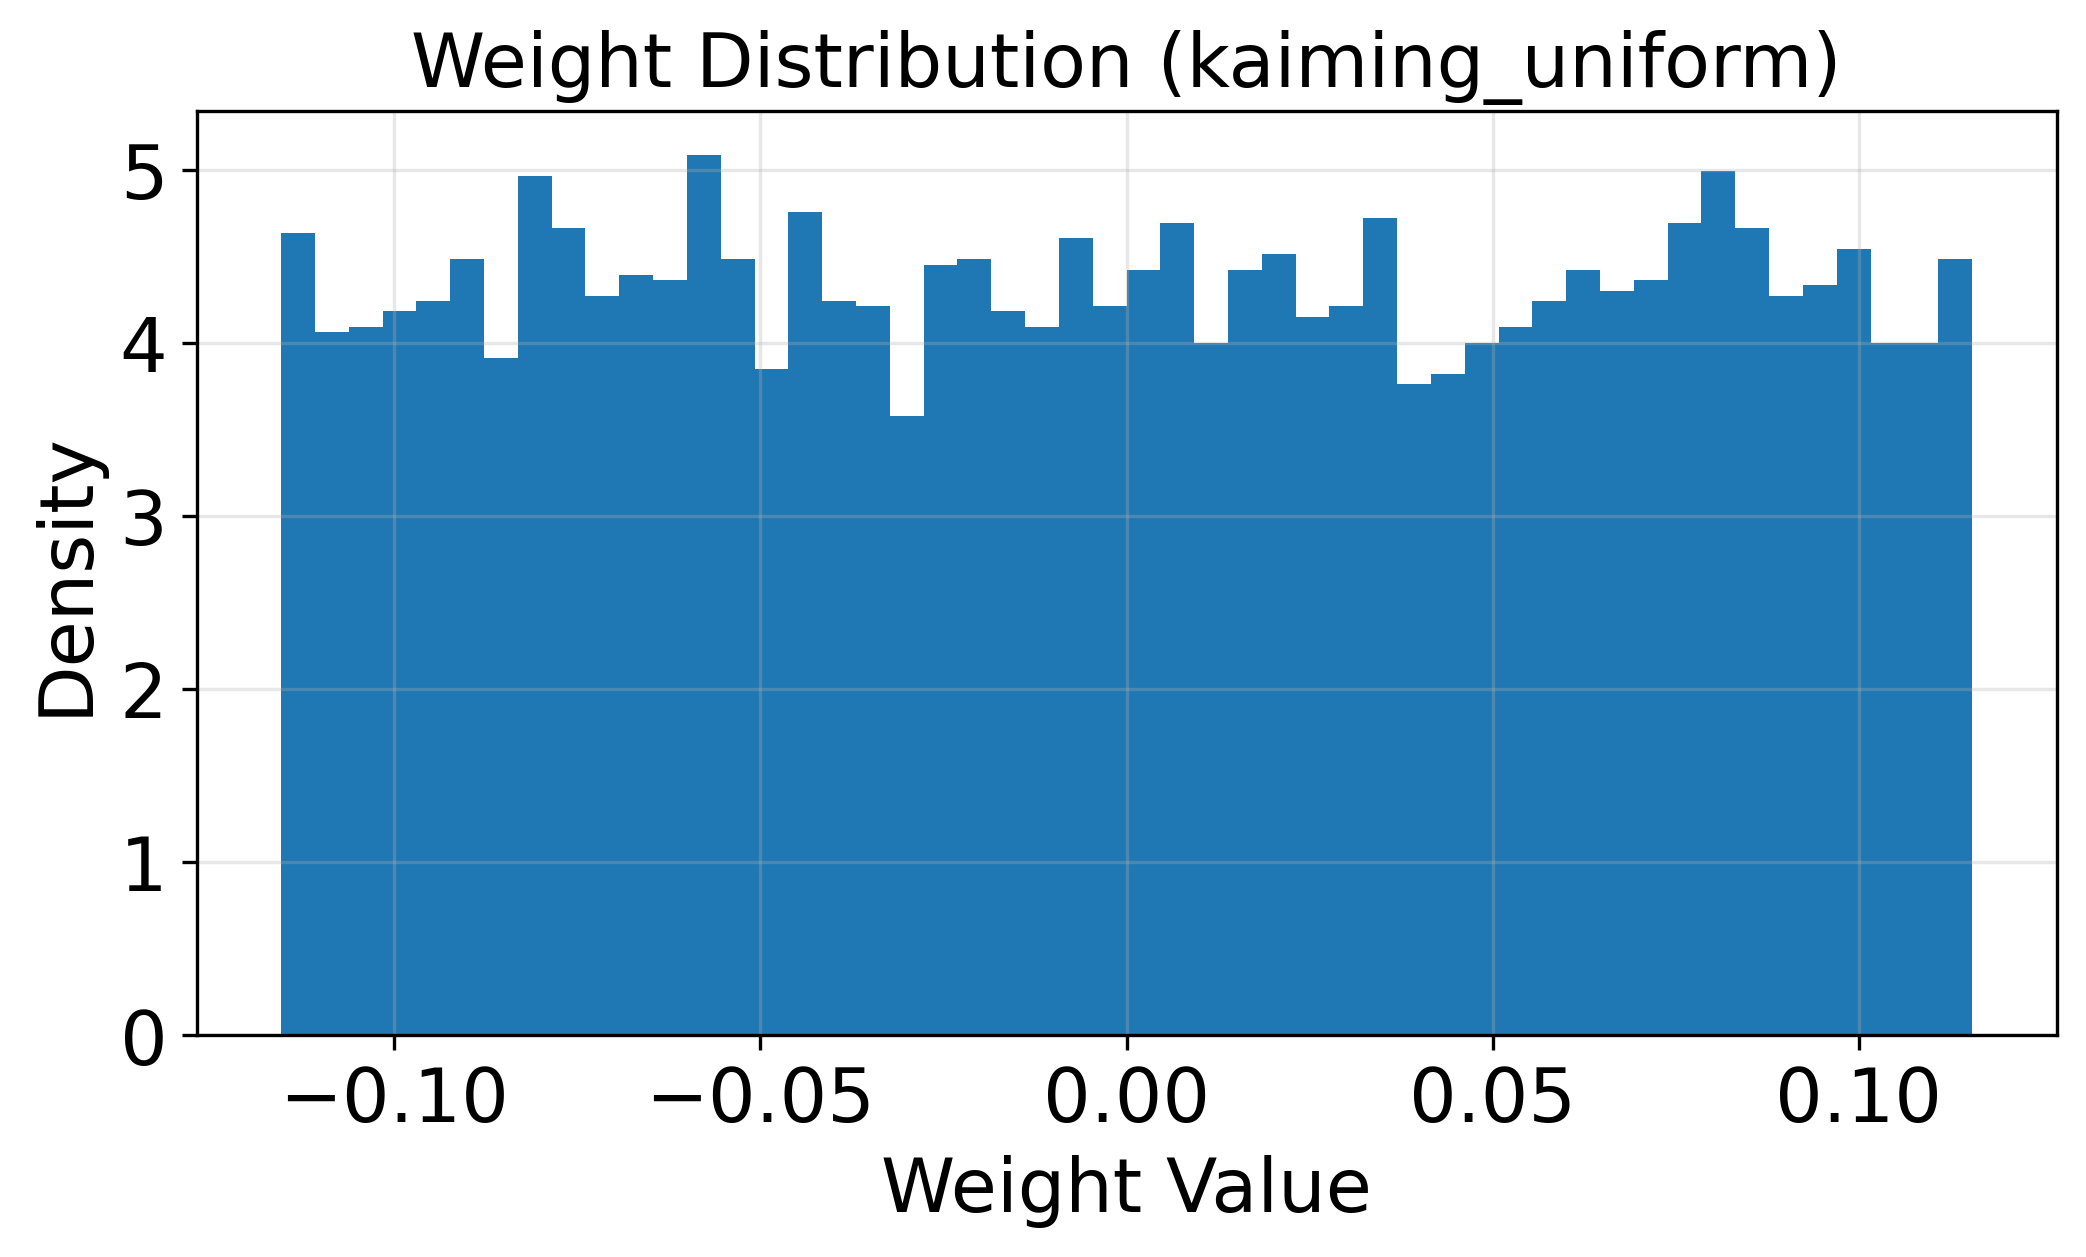

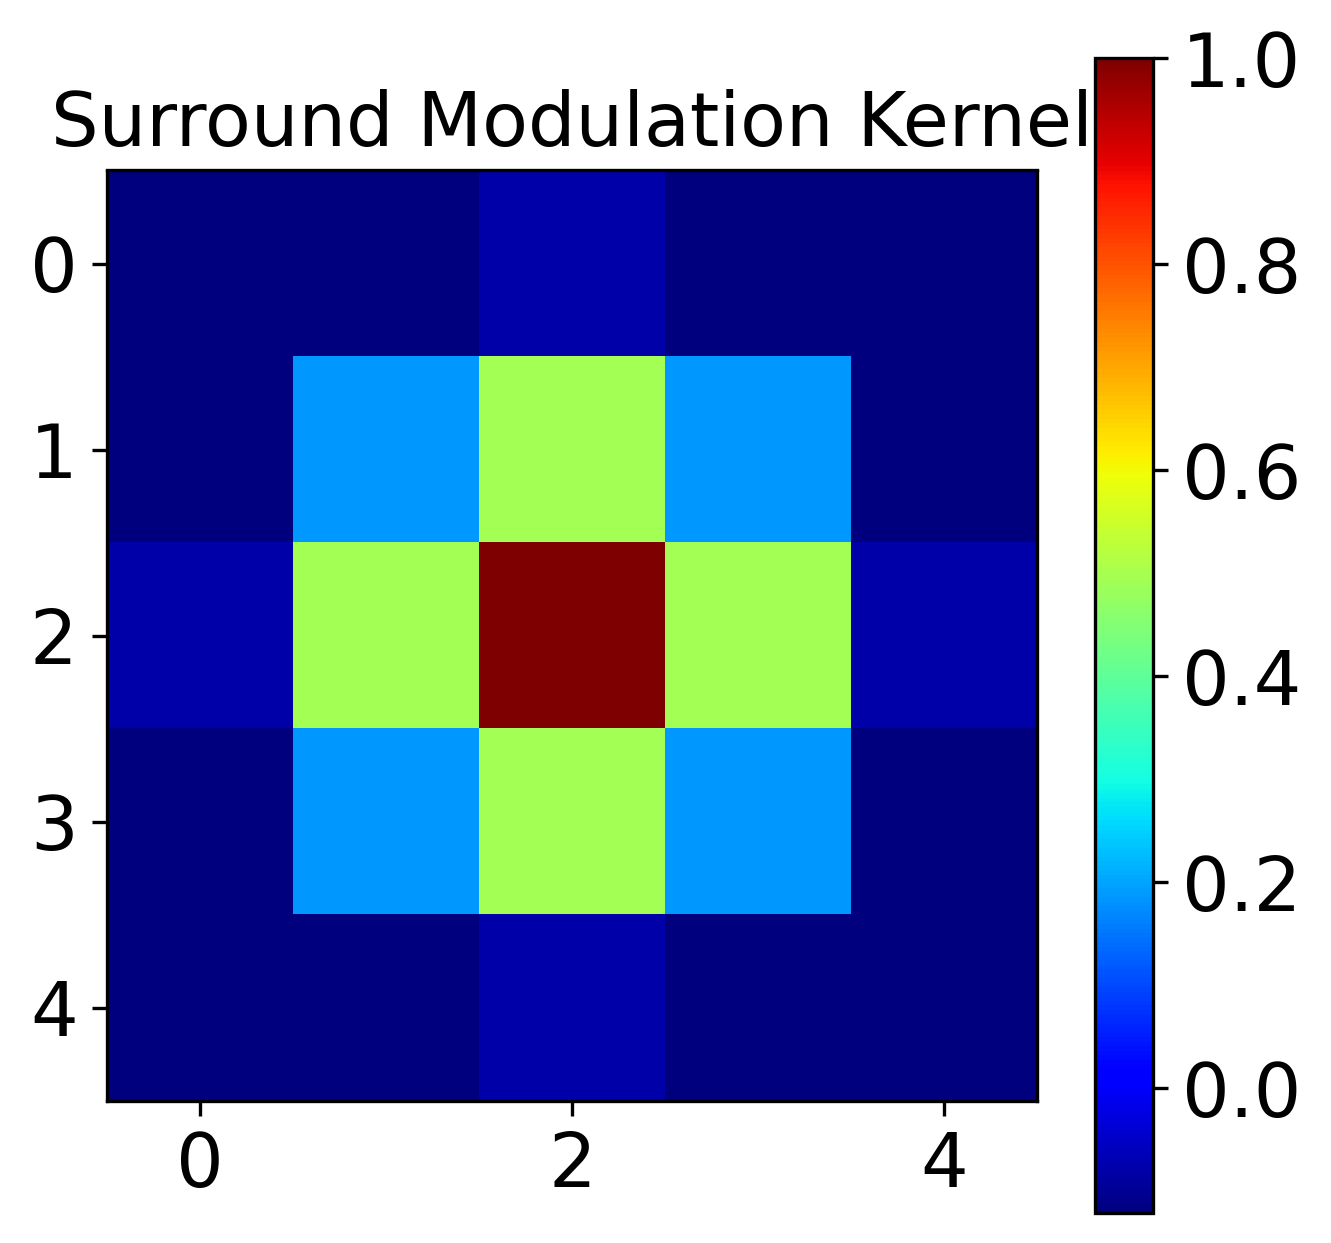

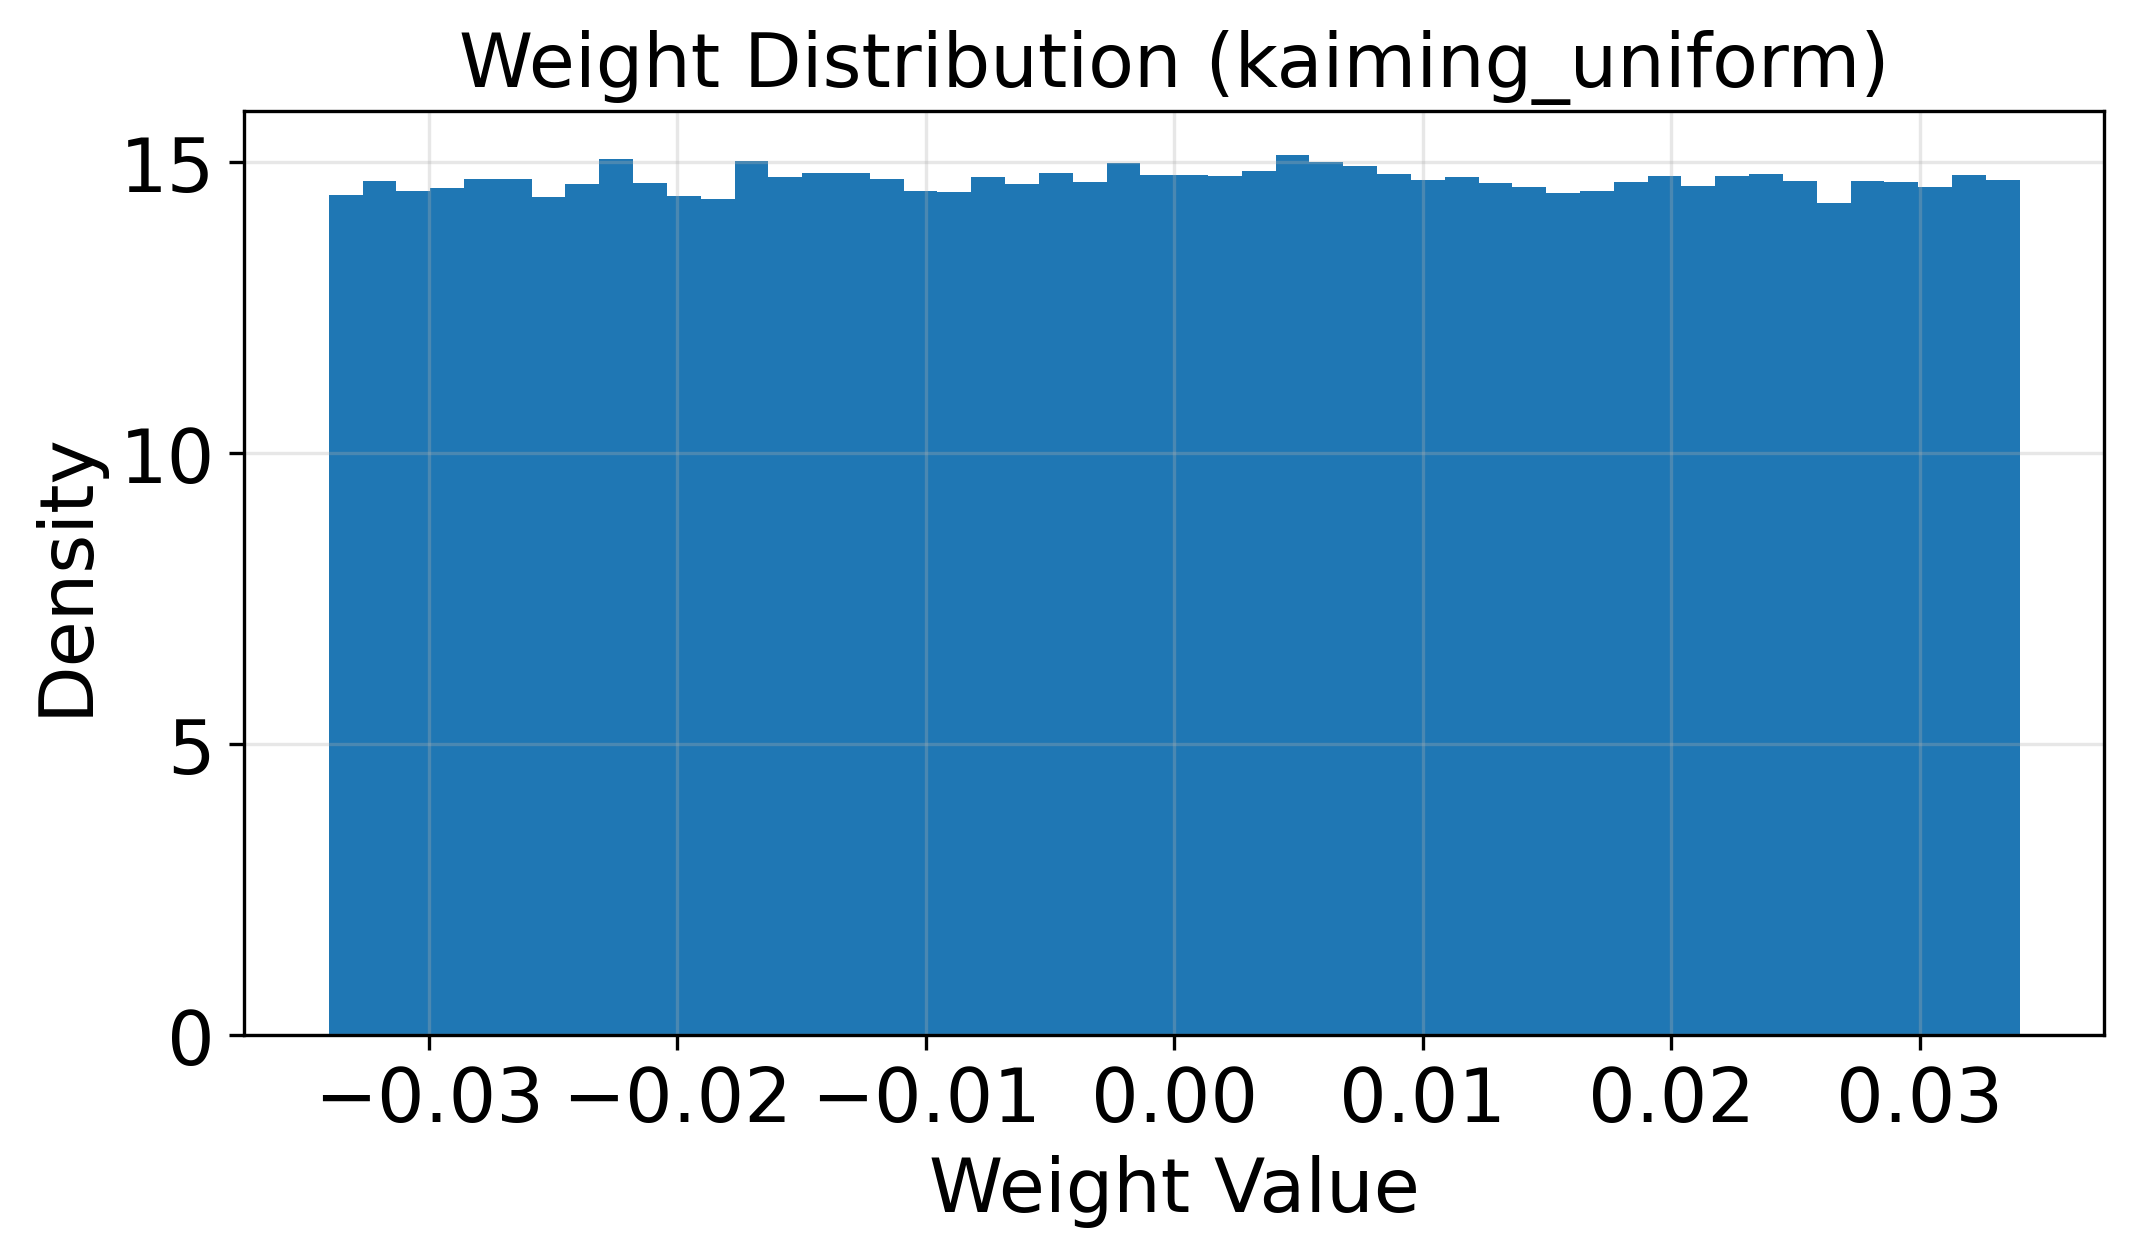

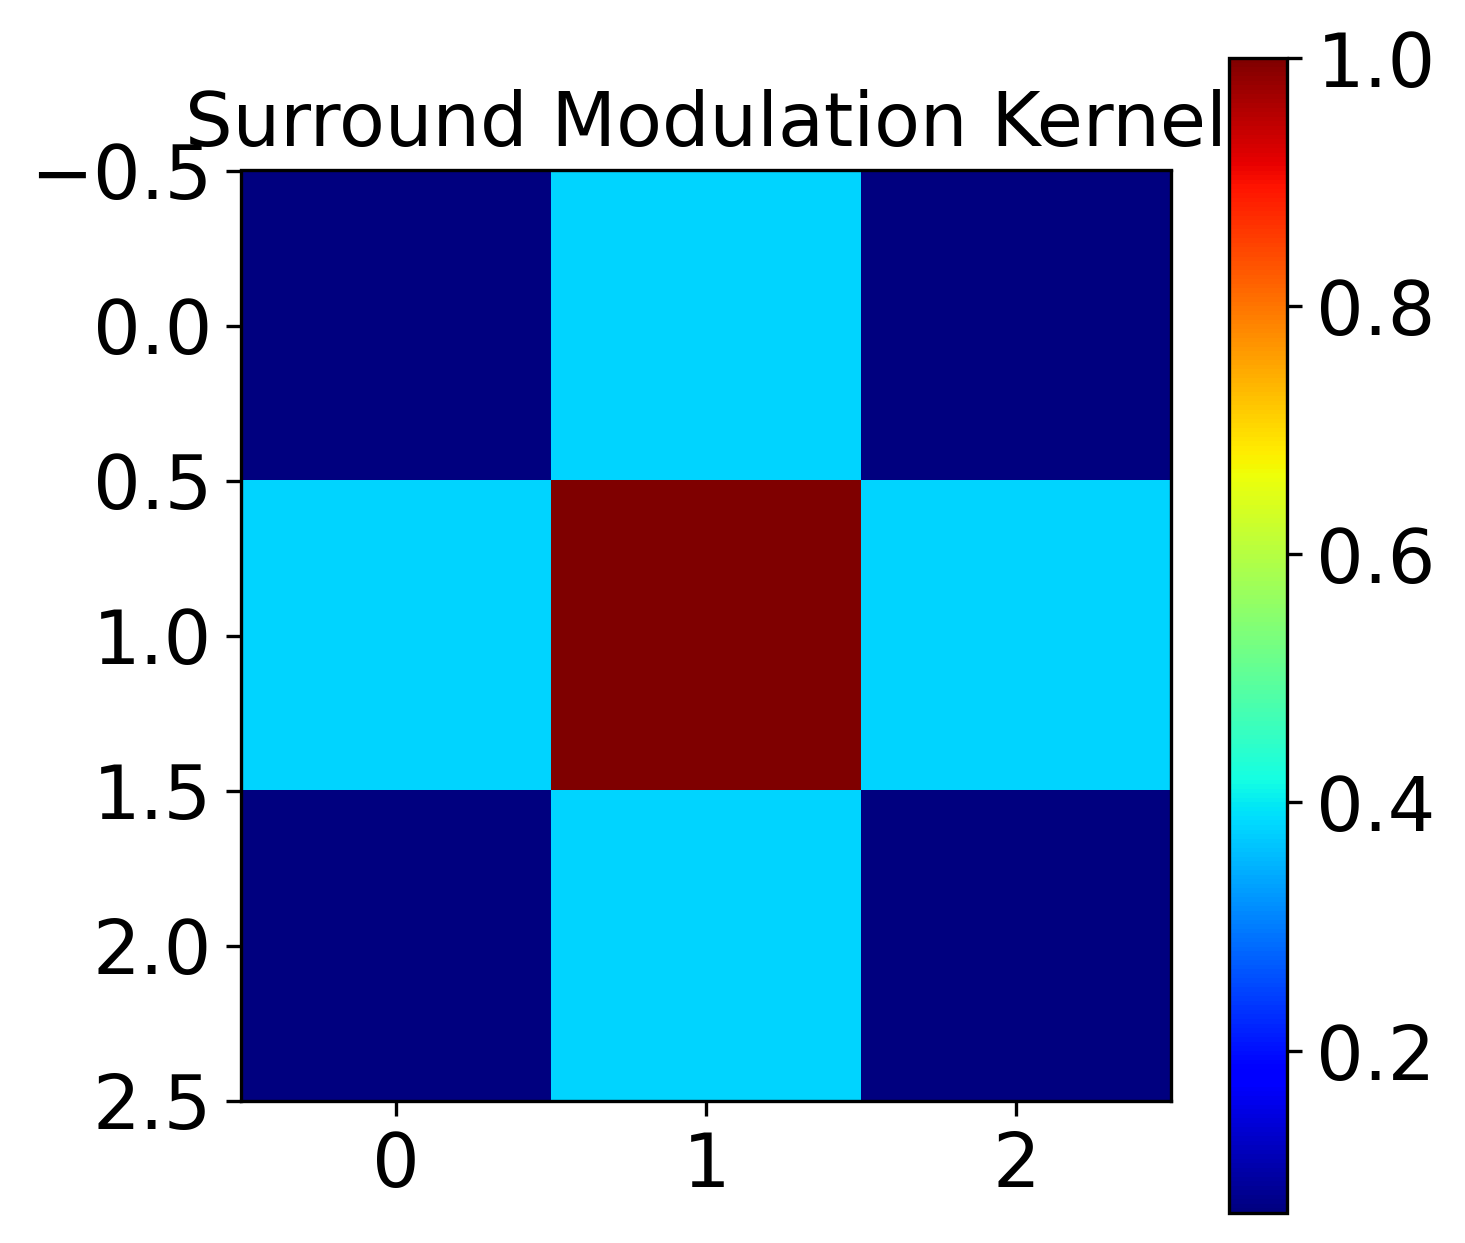

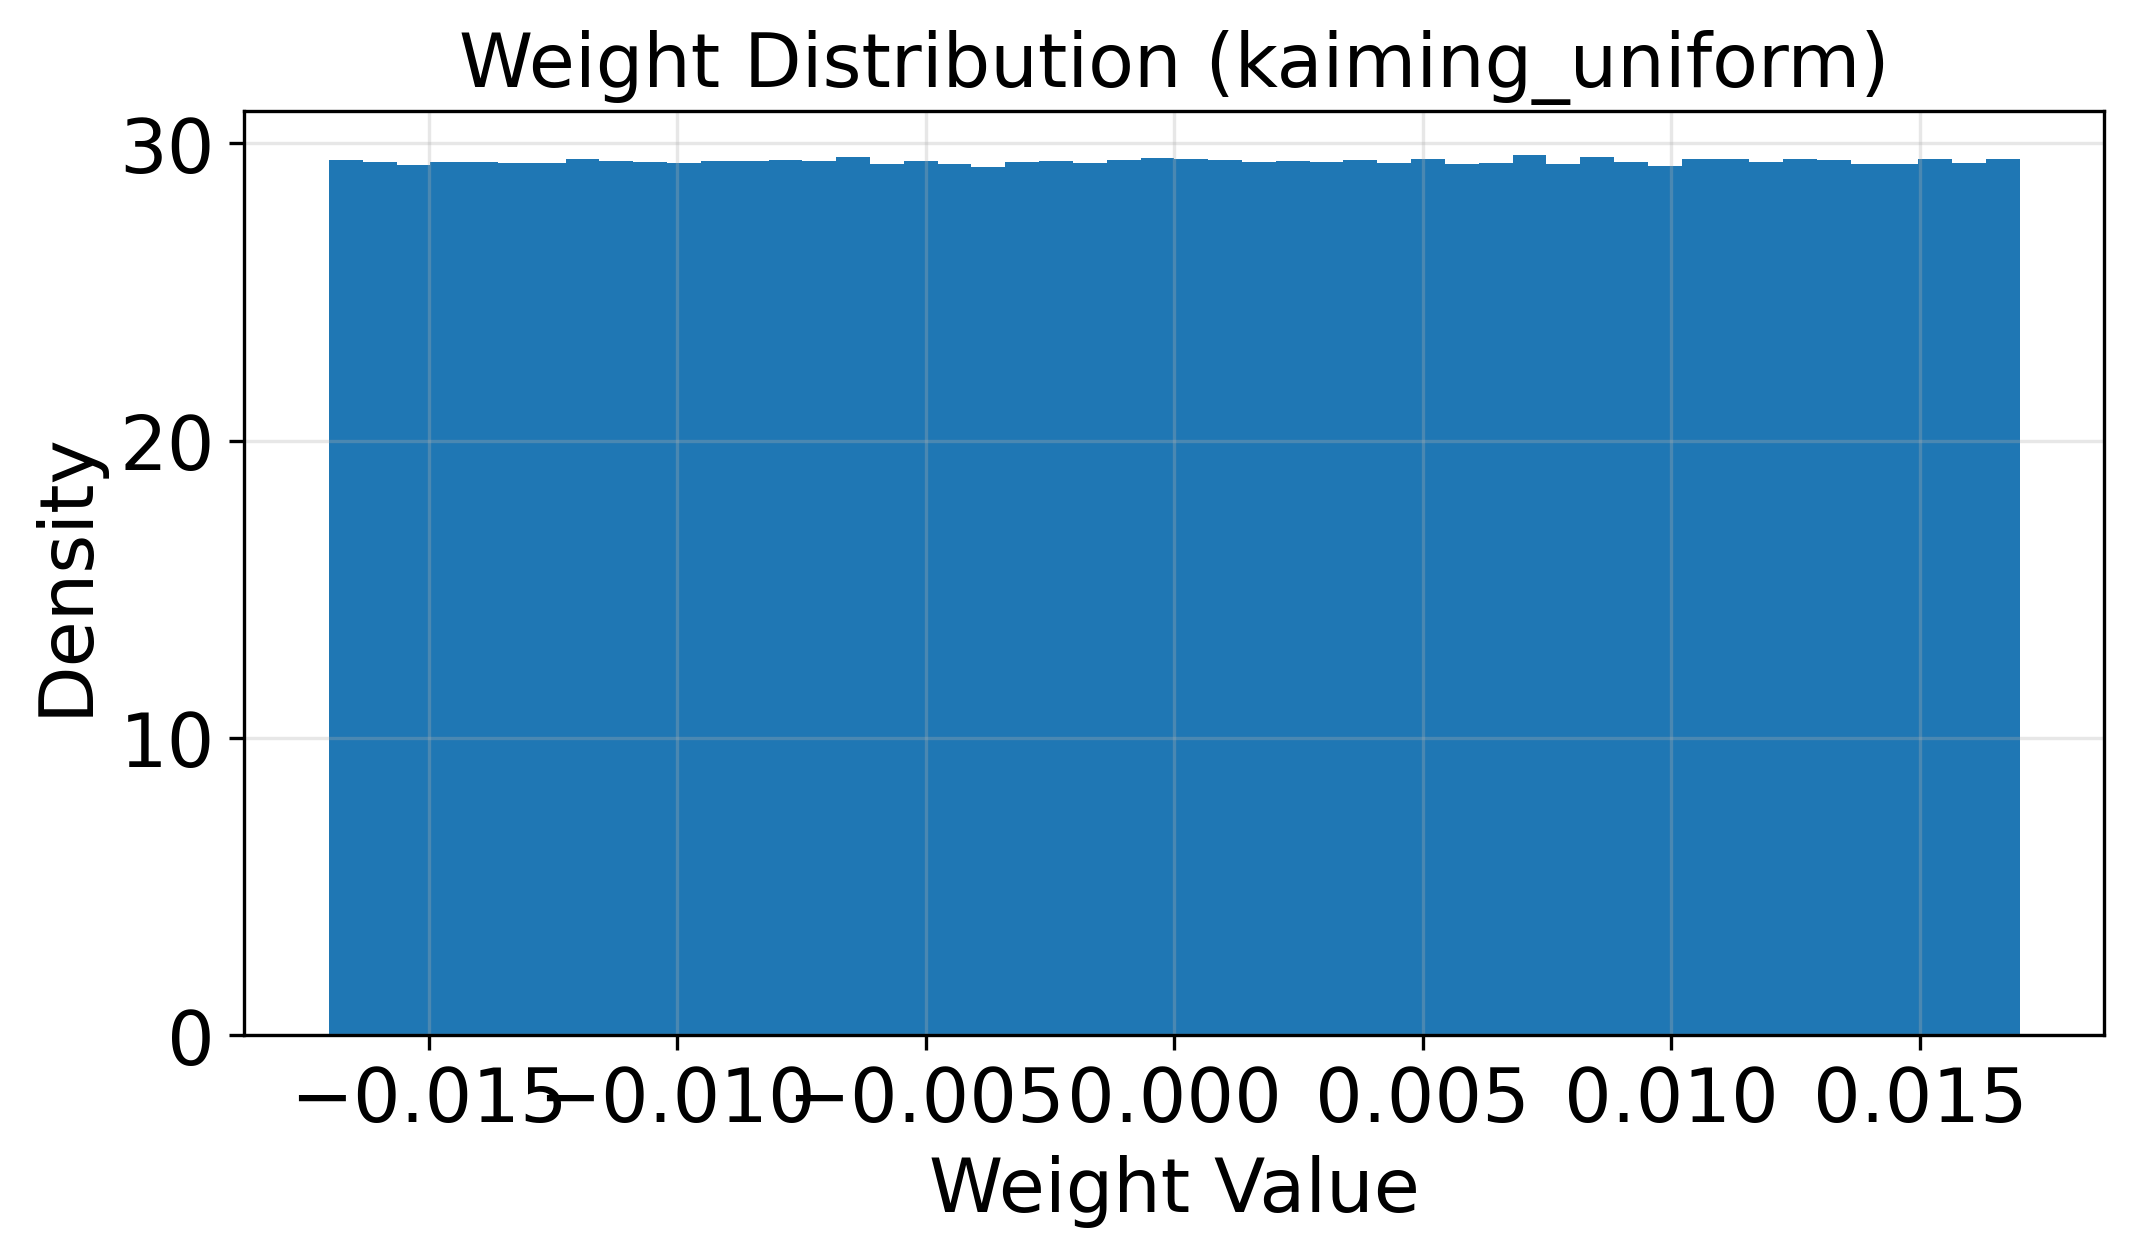

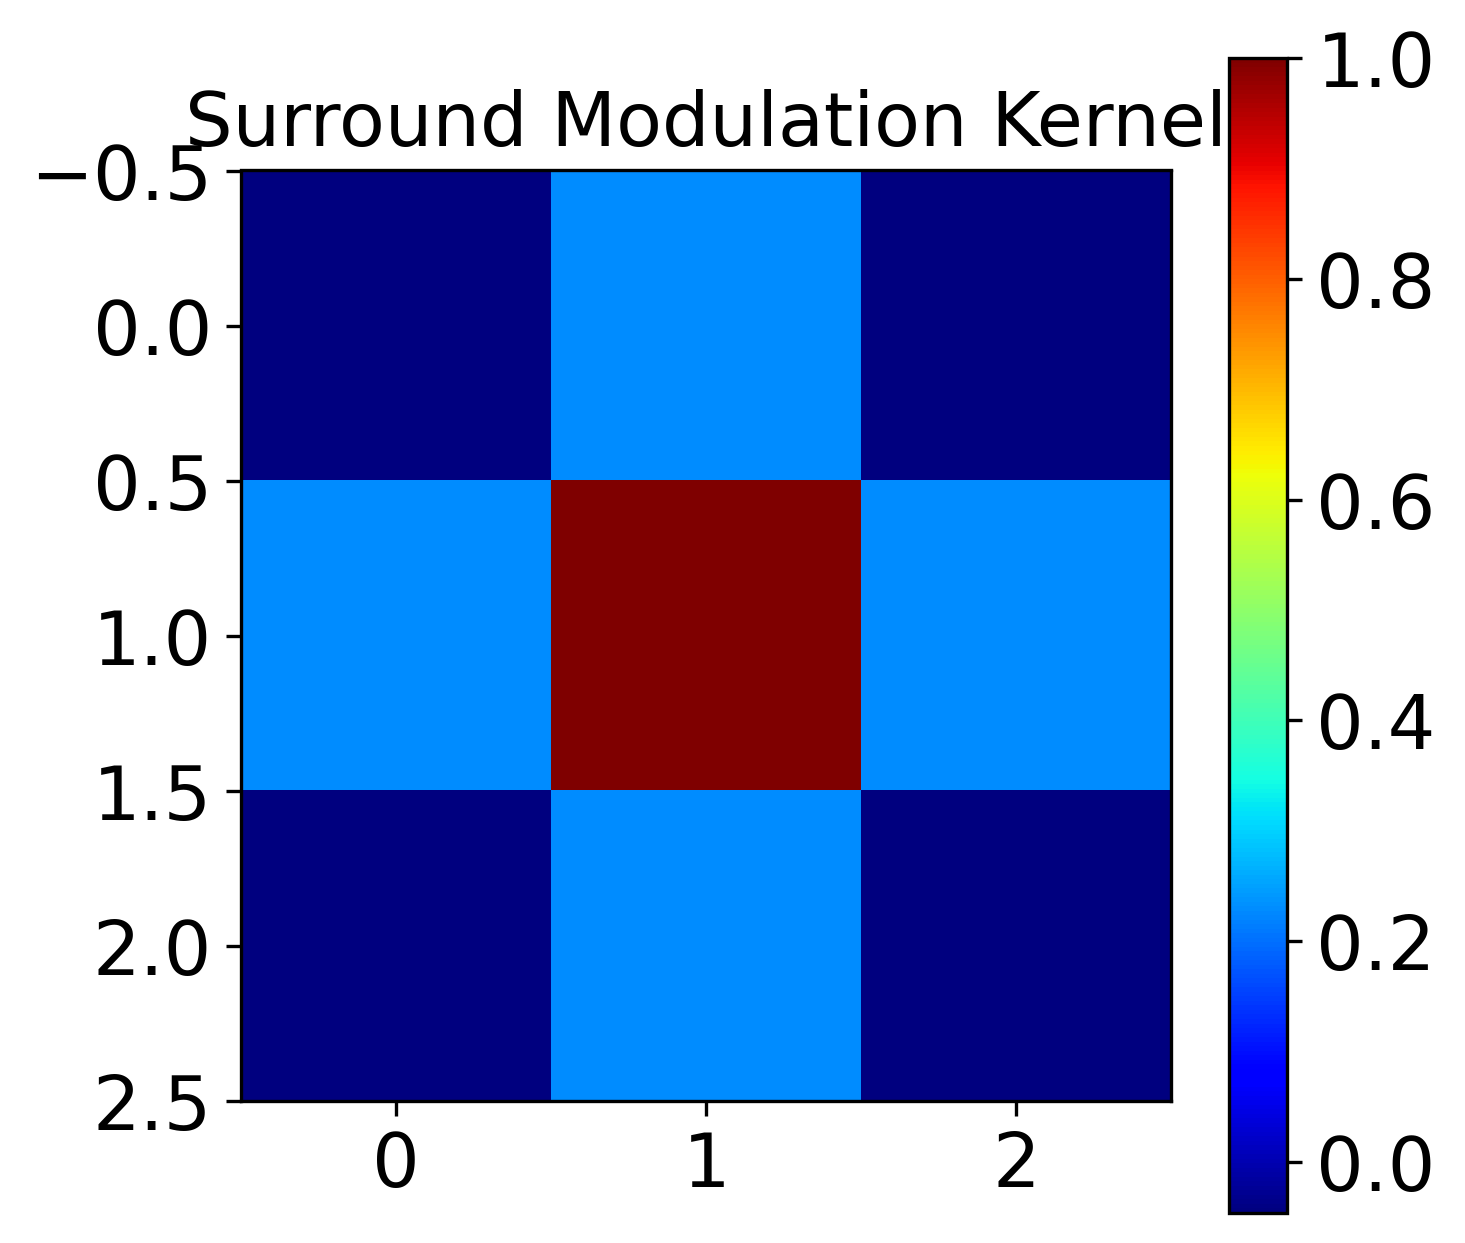

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2663 | Train Acc: 55.88% | Test Loss: 1.0048 | Test Acc: 65.21% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9932 | Train Acc: 65.87% | Test Loss: 0.9301 | Test Acc: 68.04% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9257 | Train Acc: 68.12% | Test Loss: 0.8816 | Test Acc: 69.54% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8853 | Train Acc: 69.32% | Test Loss: 0.8441 | Test Acc: 70.65% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8596 | Train Acc: 70.26% | Test Loss: 0.8391 | Test Acc: 71.05% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8399 | Train Acc: 70.81% | Test Loss: 0.8345 | Test Acc: 70.97% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8199 | Train Acc: 71.66% | Test Loss: 0.8222 | Test Acc: 71.48% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8084 | Train Acc: 72.08% | Test Loss: 0.8016 | Test Acc: 72.31% | LR: 0.001000
Epoch [9/2

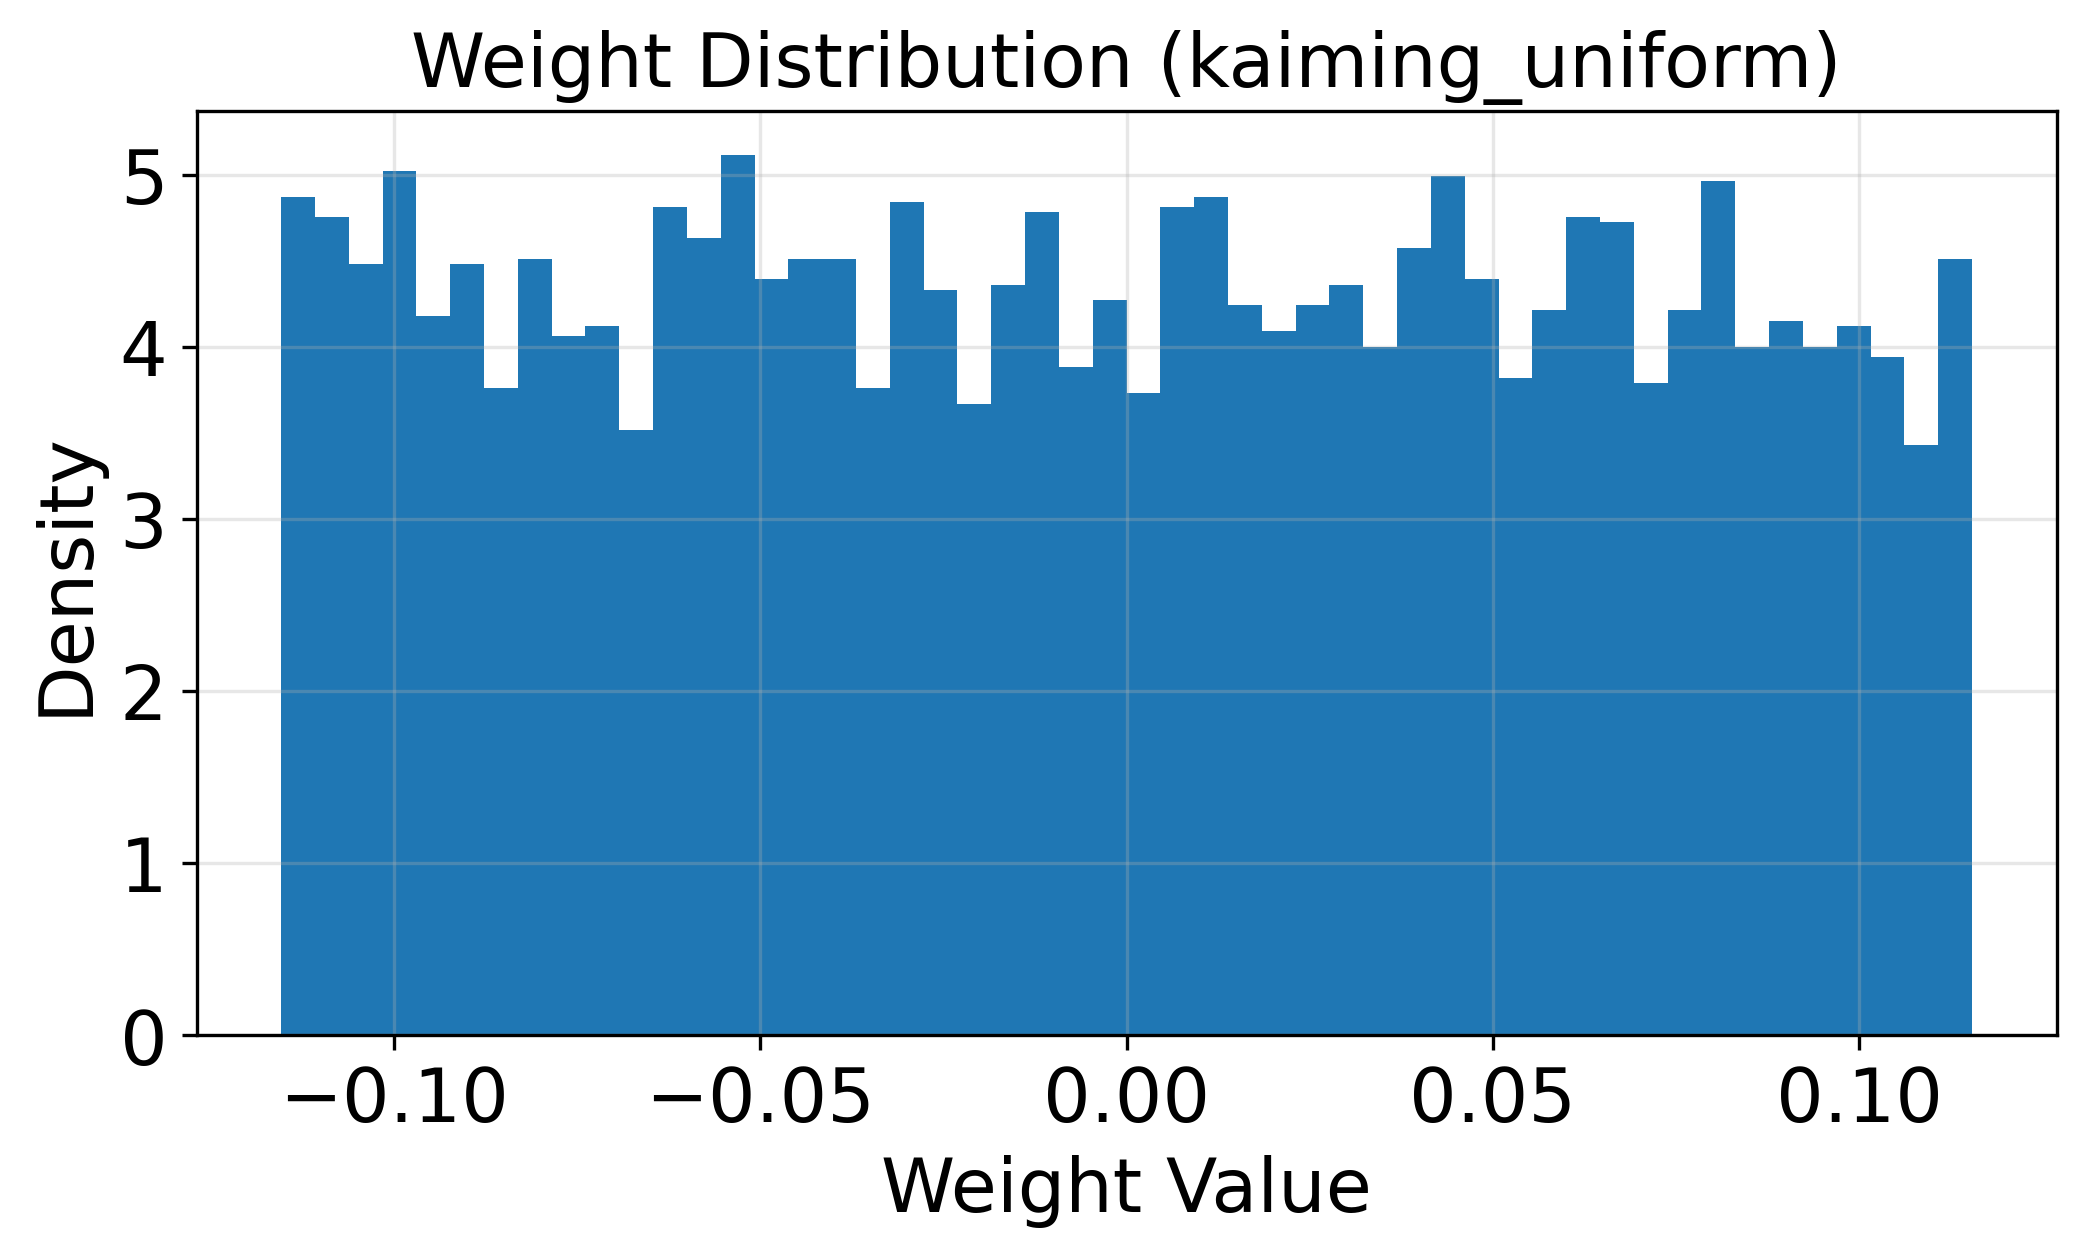

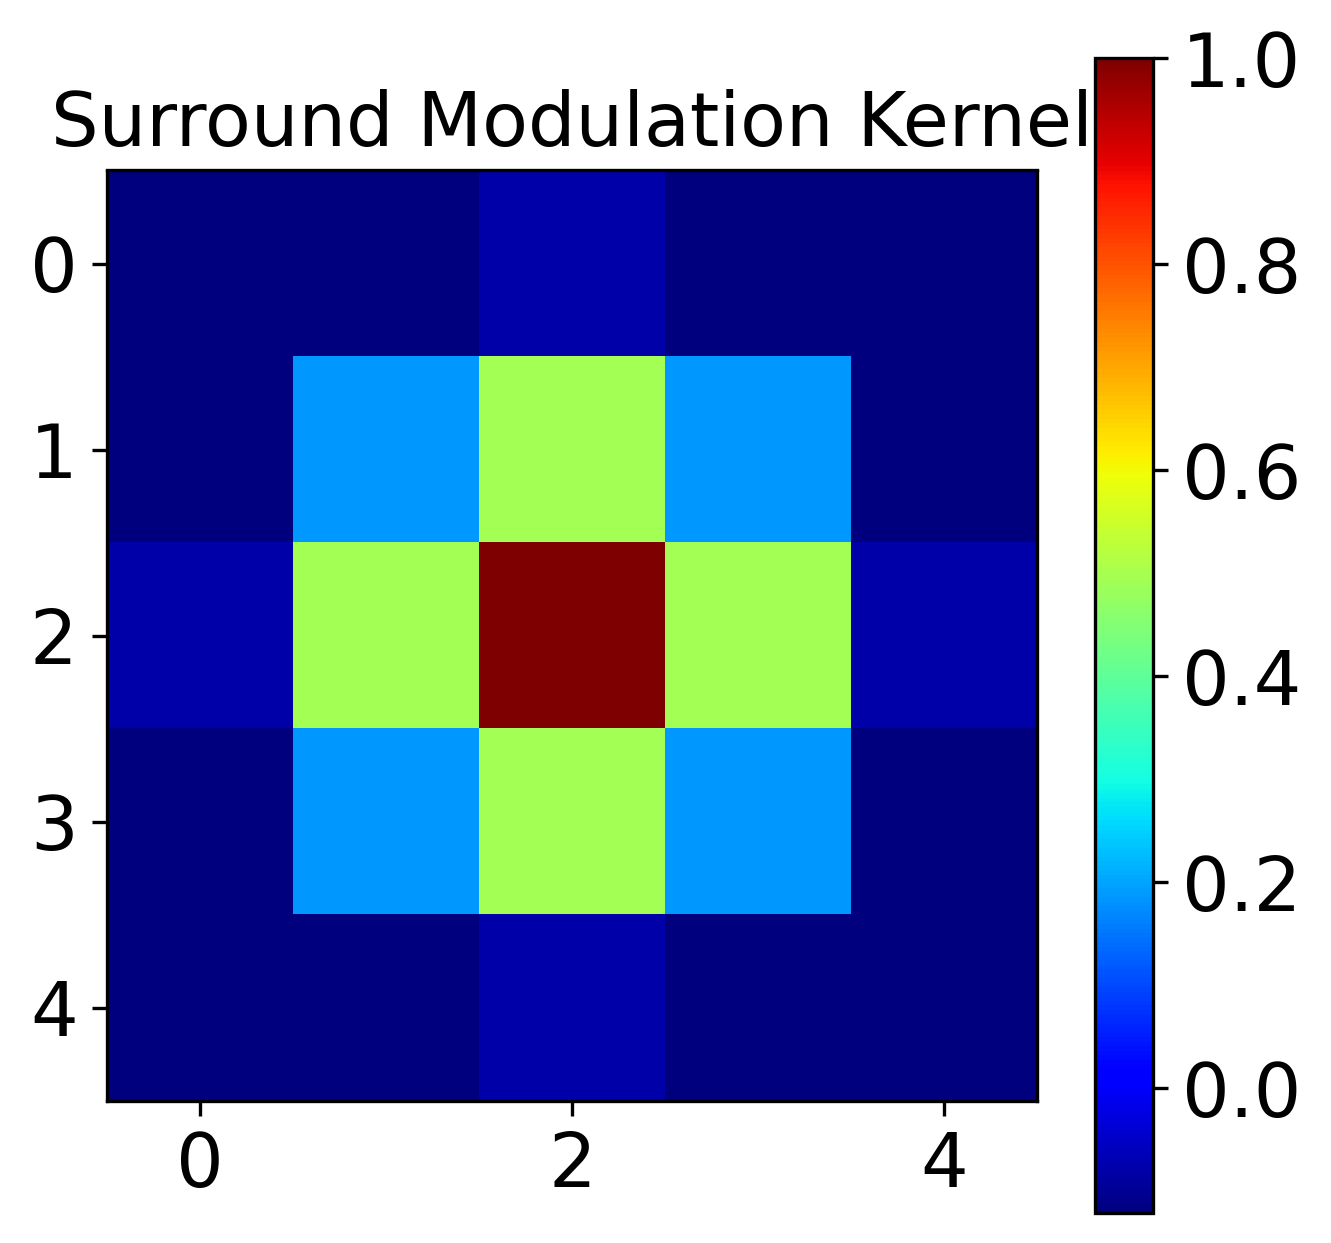

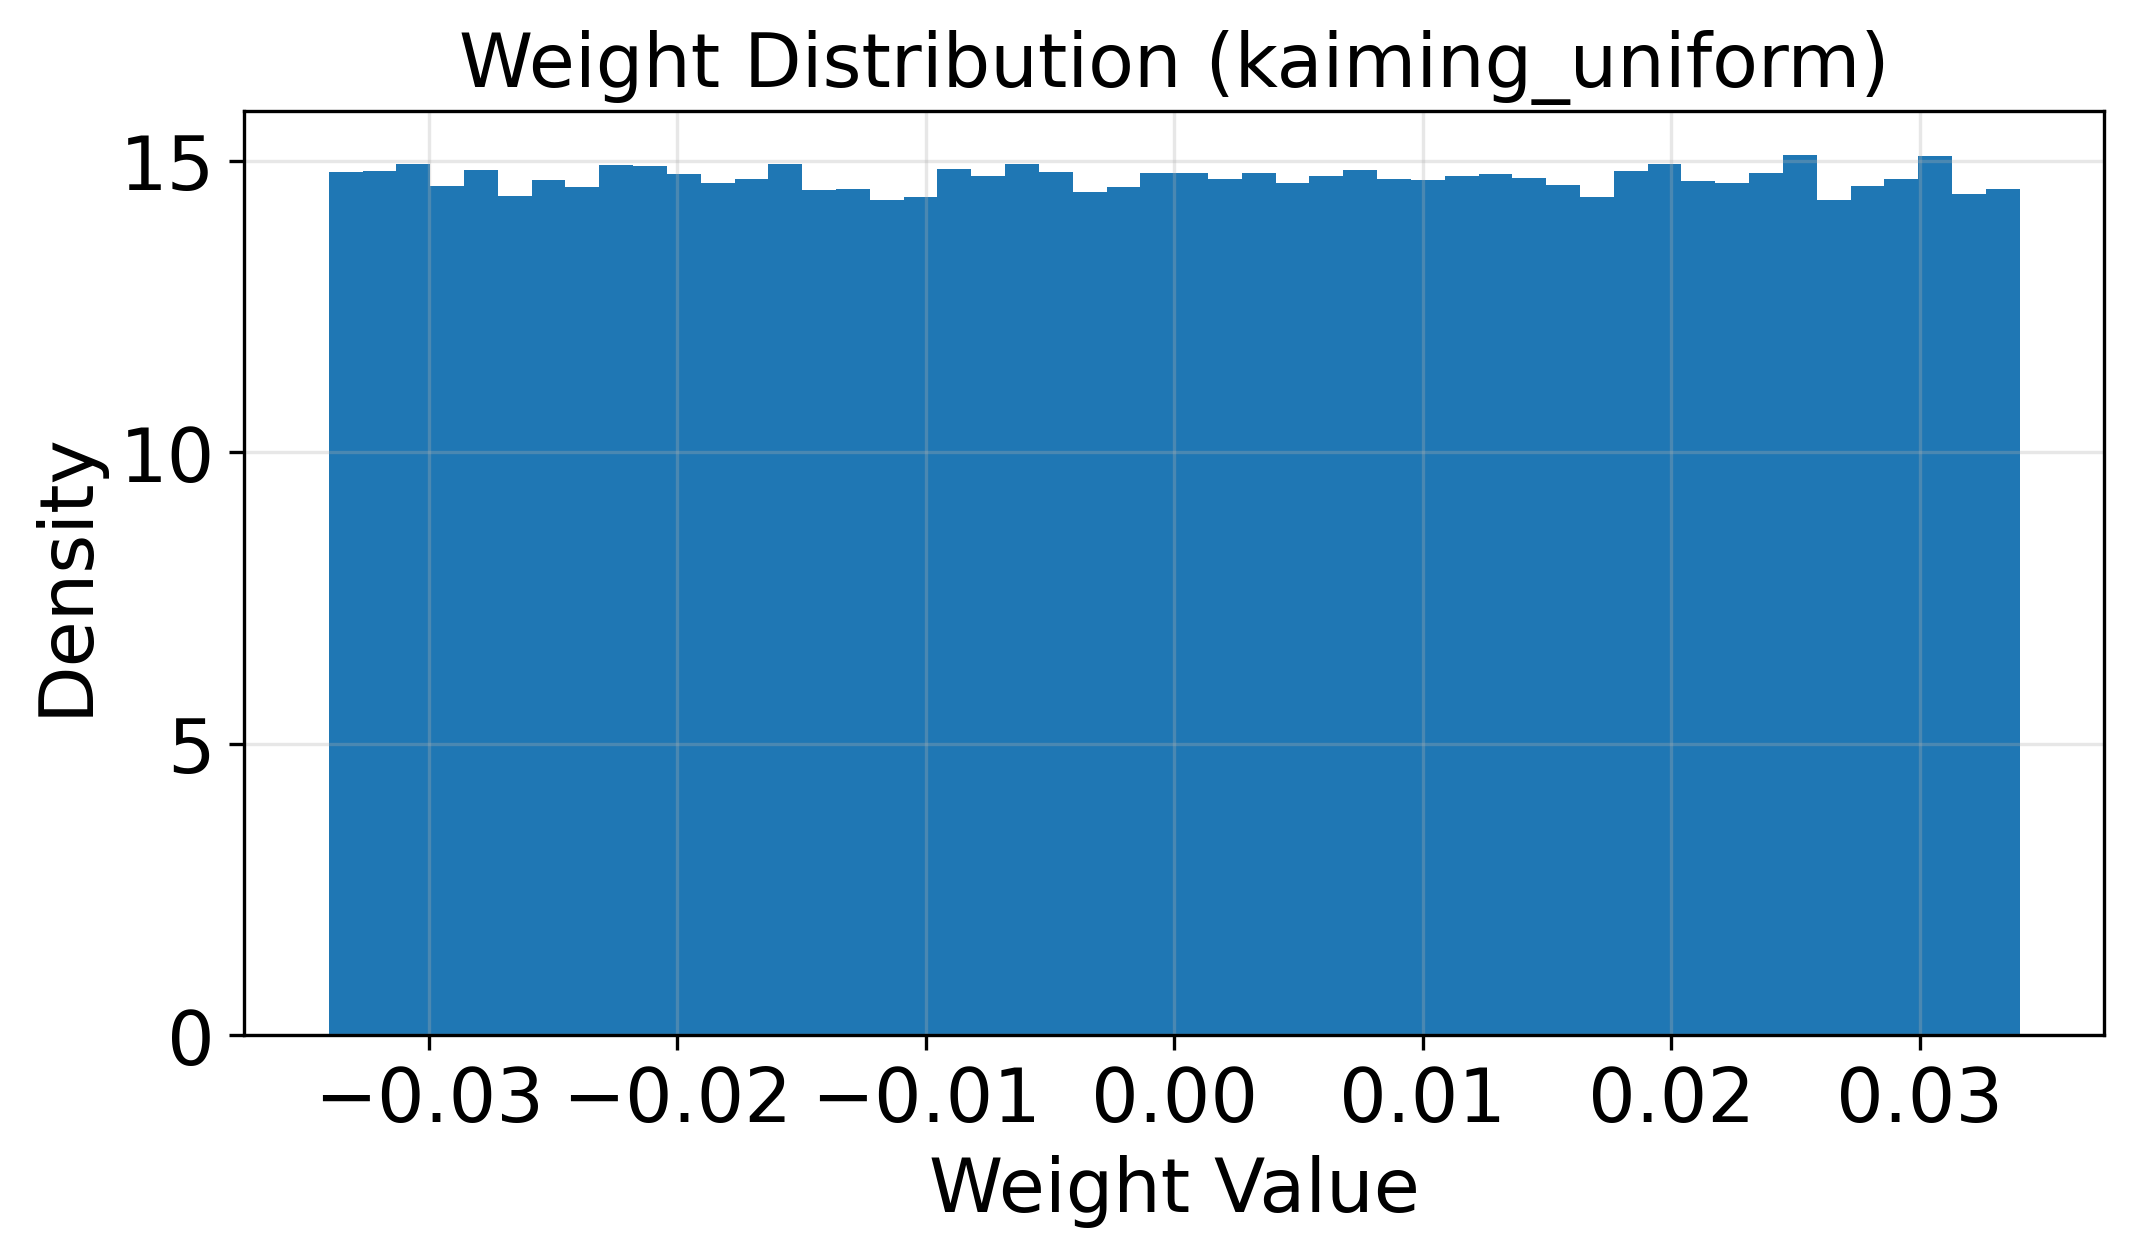

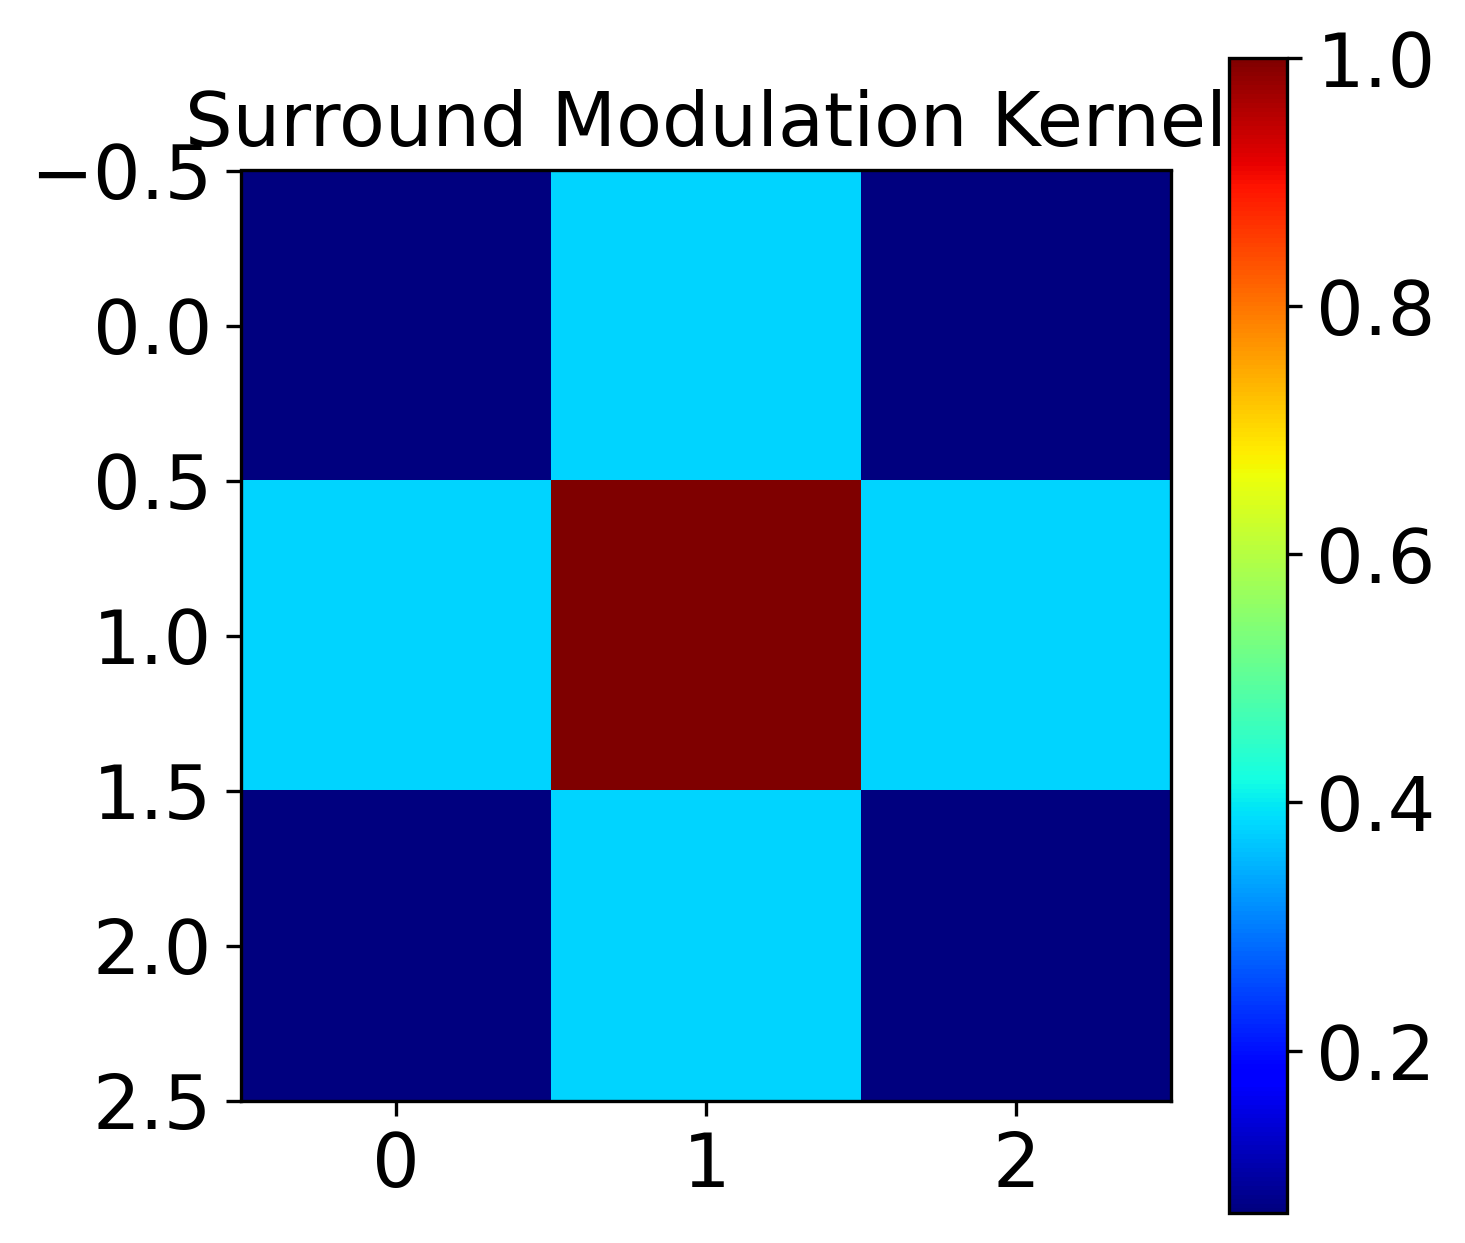

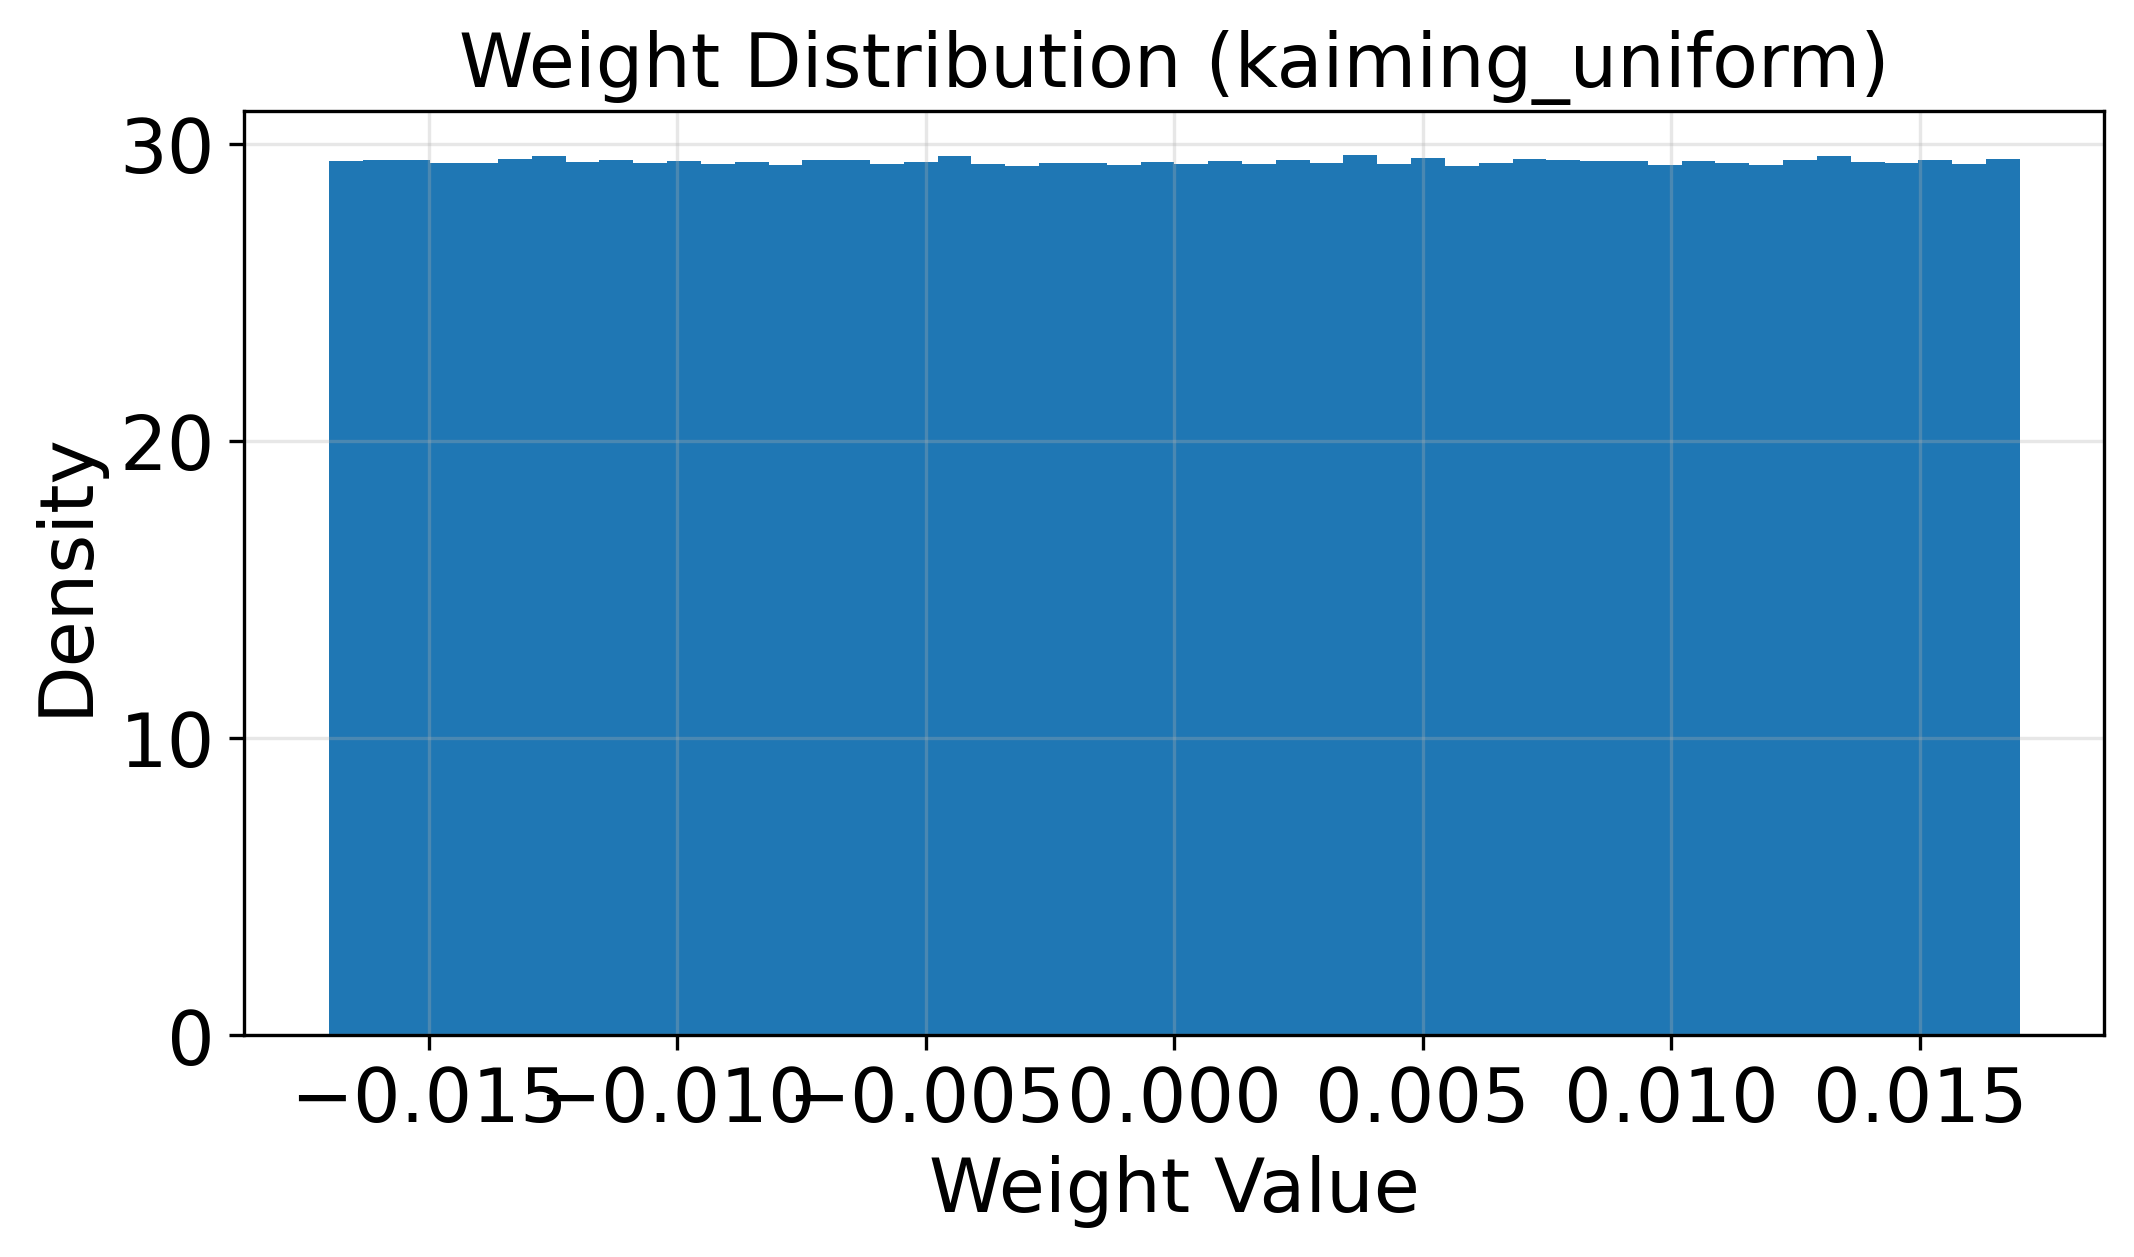

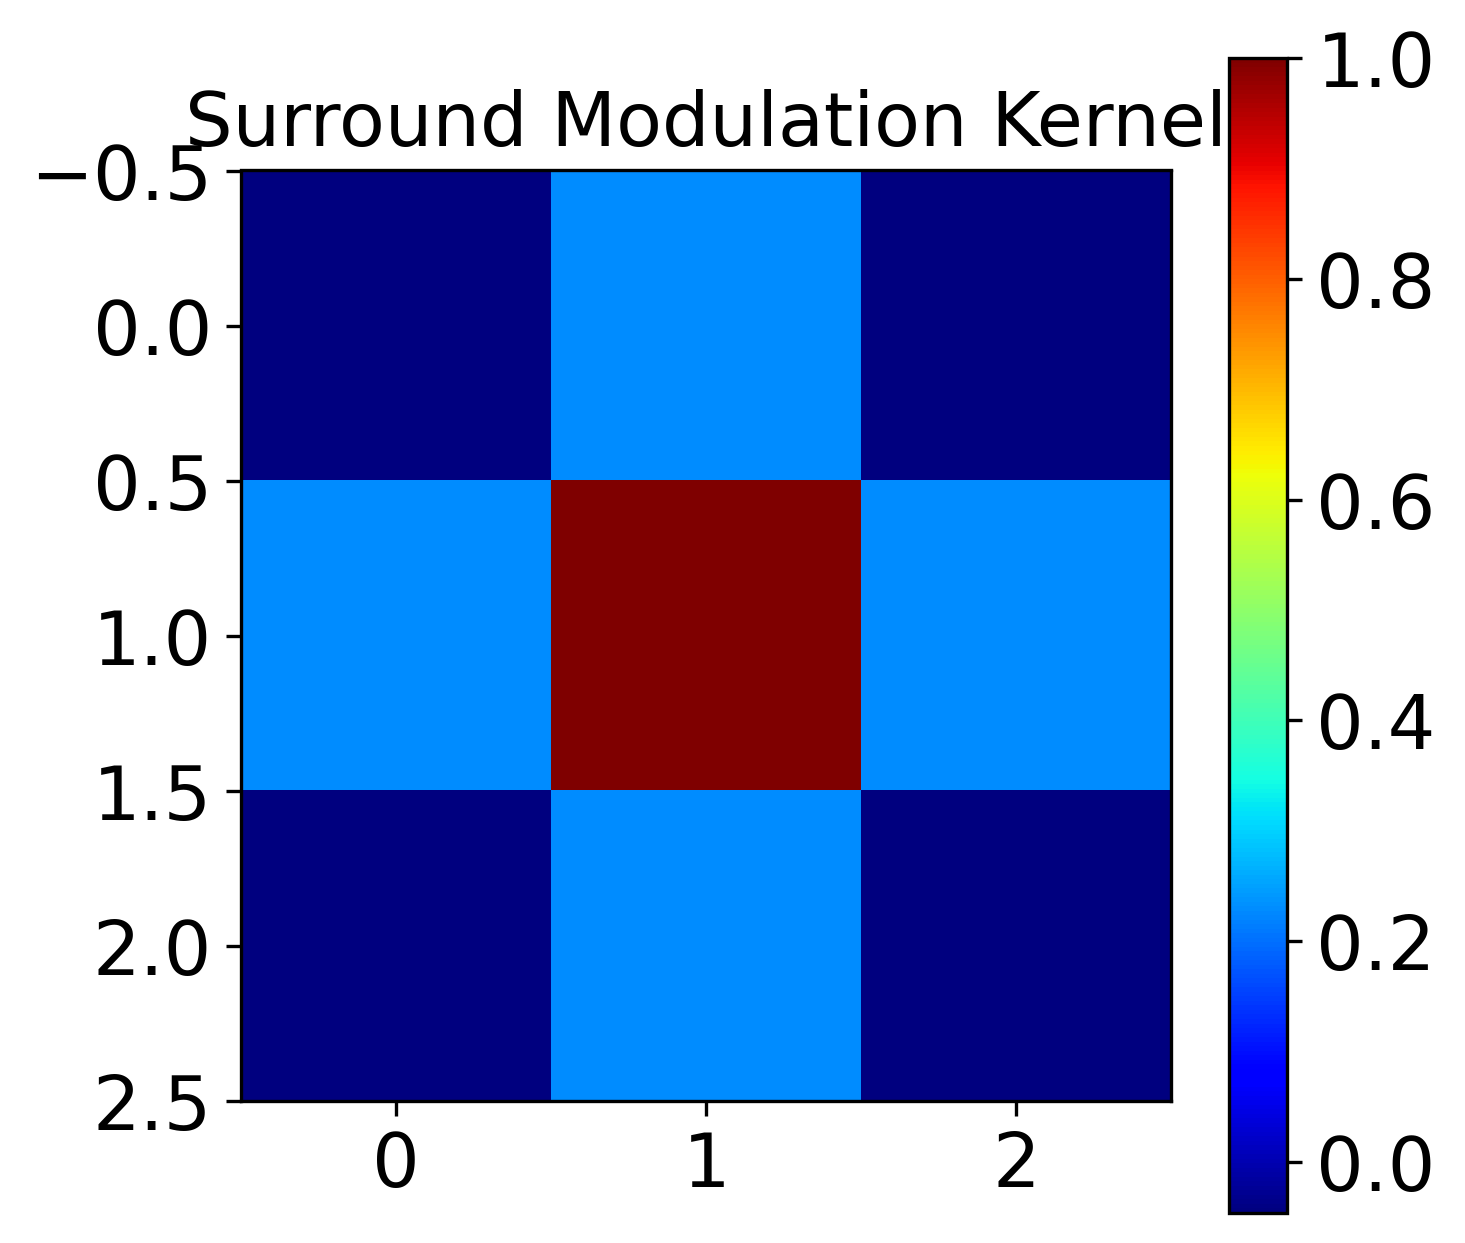

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2632 | Train Acc: 55.90% | Test Loss: 1.0284 | Test Acc: 63.68% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9914 | Train Acc: 65.80% | Test Loss: 0.9225 | Test Acc: 67.78% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9168 | Train Acc: 68.36% | Test Loss: 0.8713 | Test Acc: 69.70% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8788 | Train Acc: 69.73% | Test Loss: 0.8358 | Test Acc: 70.65% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8497 | Train Acc: 70.69% | Test Loss: 0.8319 | Test Acc: 70.76% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8297 | Train Acc: 71.24% | Test Loss: 0.8190 | Test Acc: 71.54% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8119 | Train Acc: 72.10% | Test Loss: 0.8134 | Test Acc: 71.74% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8050 | Train Acc: 72.20% | Test Loss: 0.8011 | Test Acc: 71.75% | LR: 0.001000
Epoch [9/2

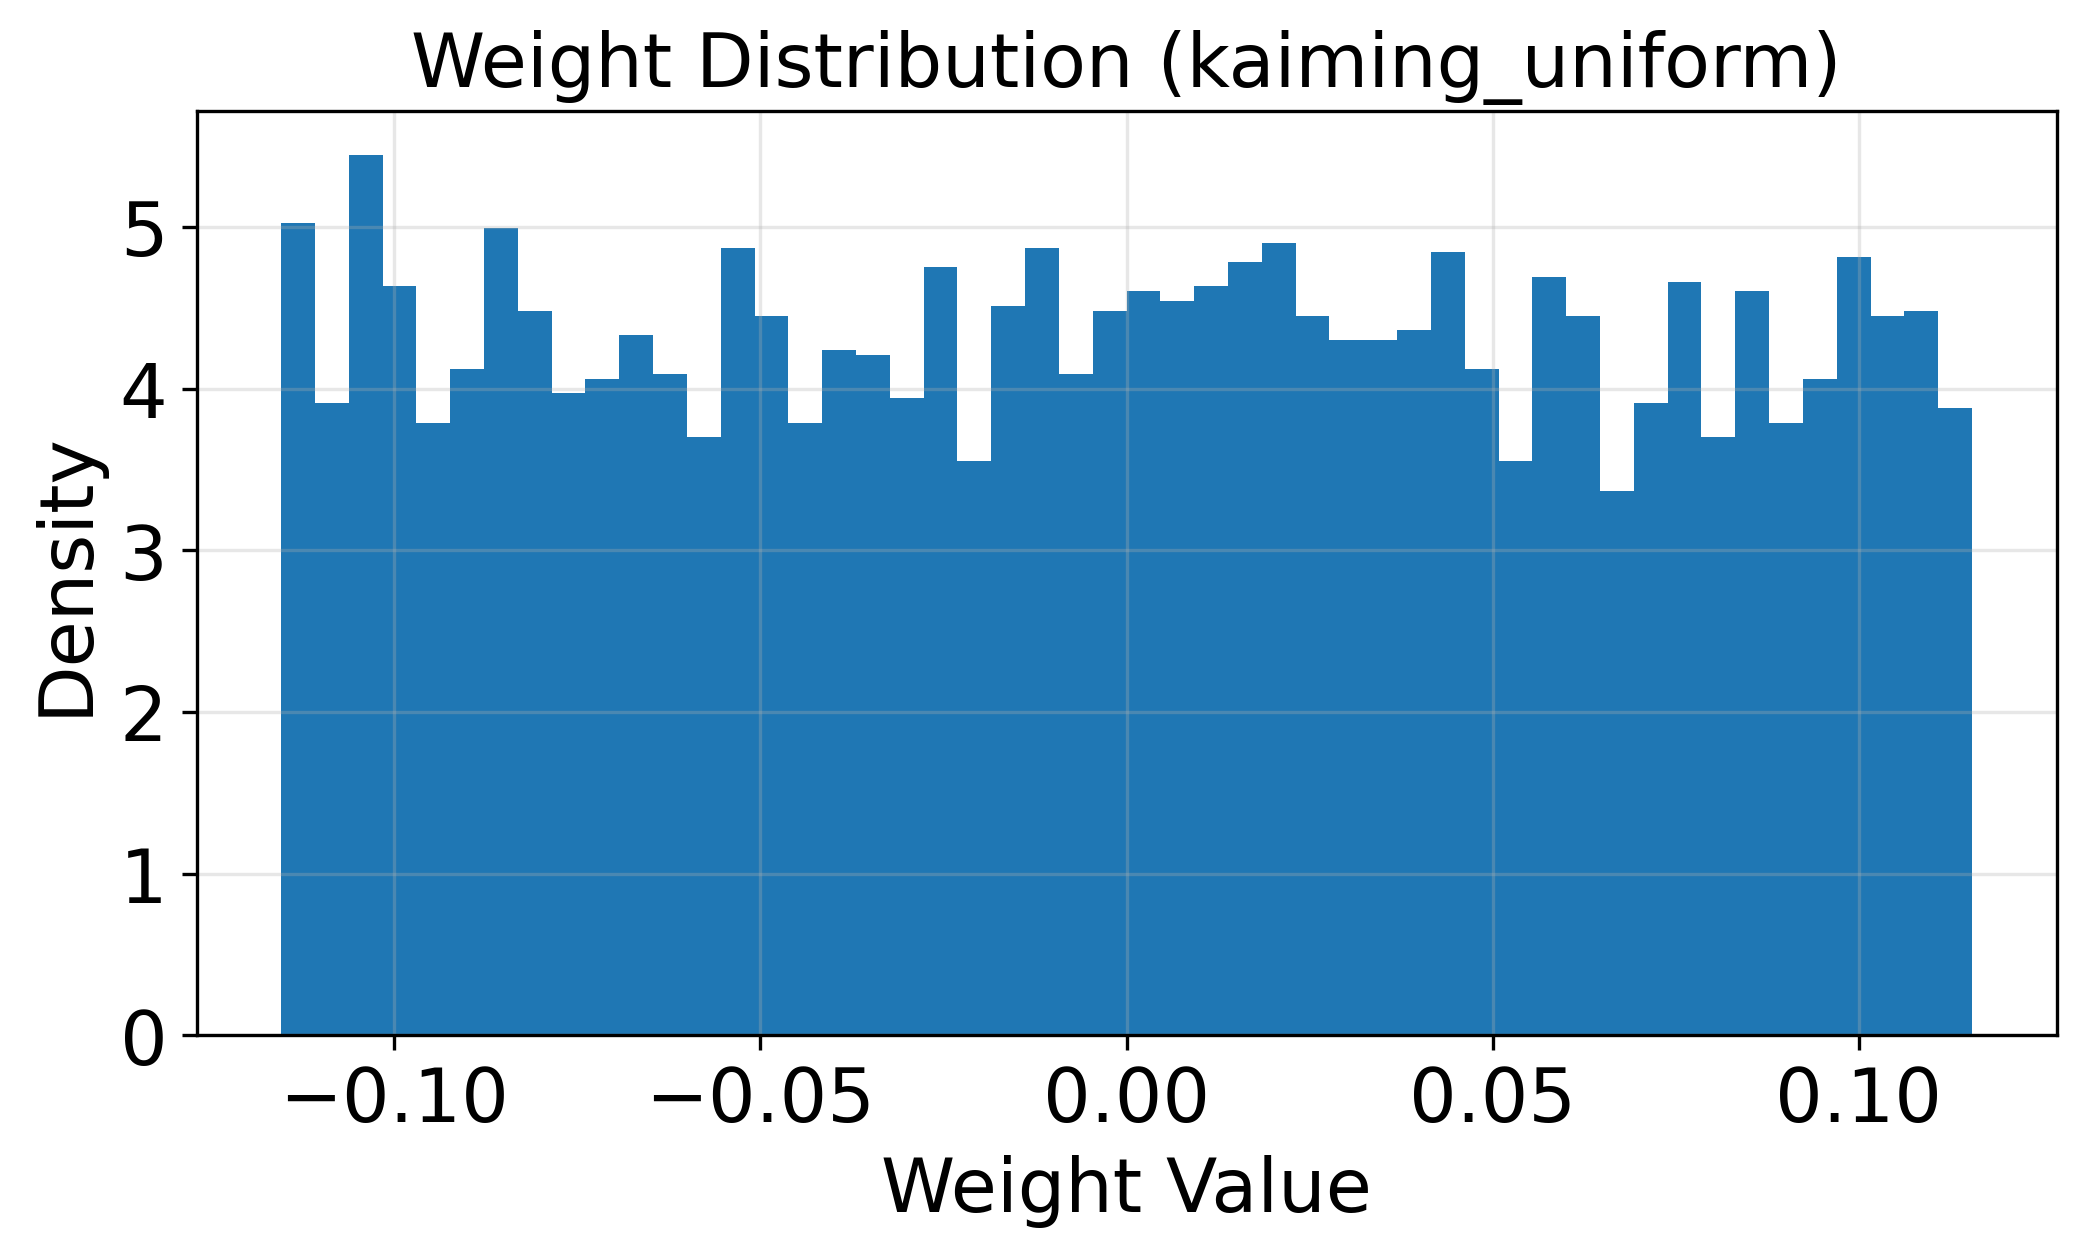

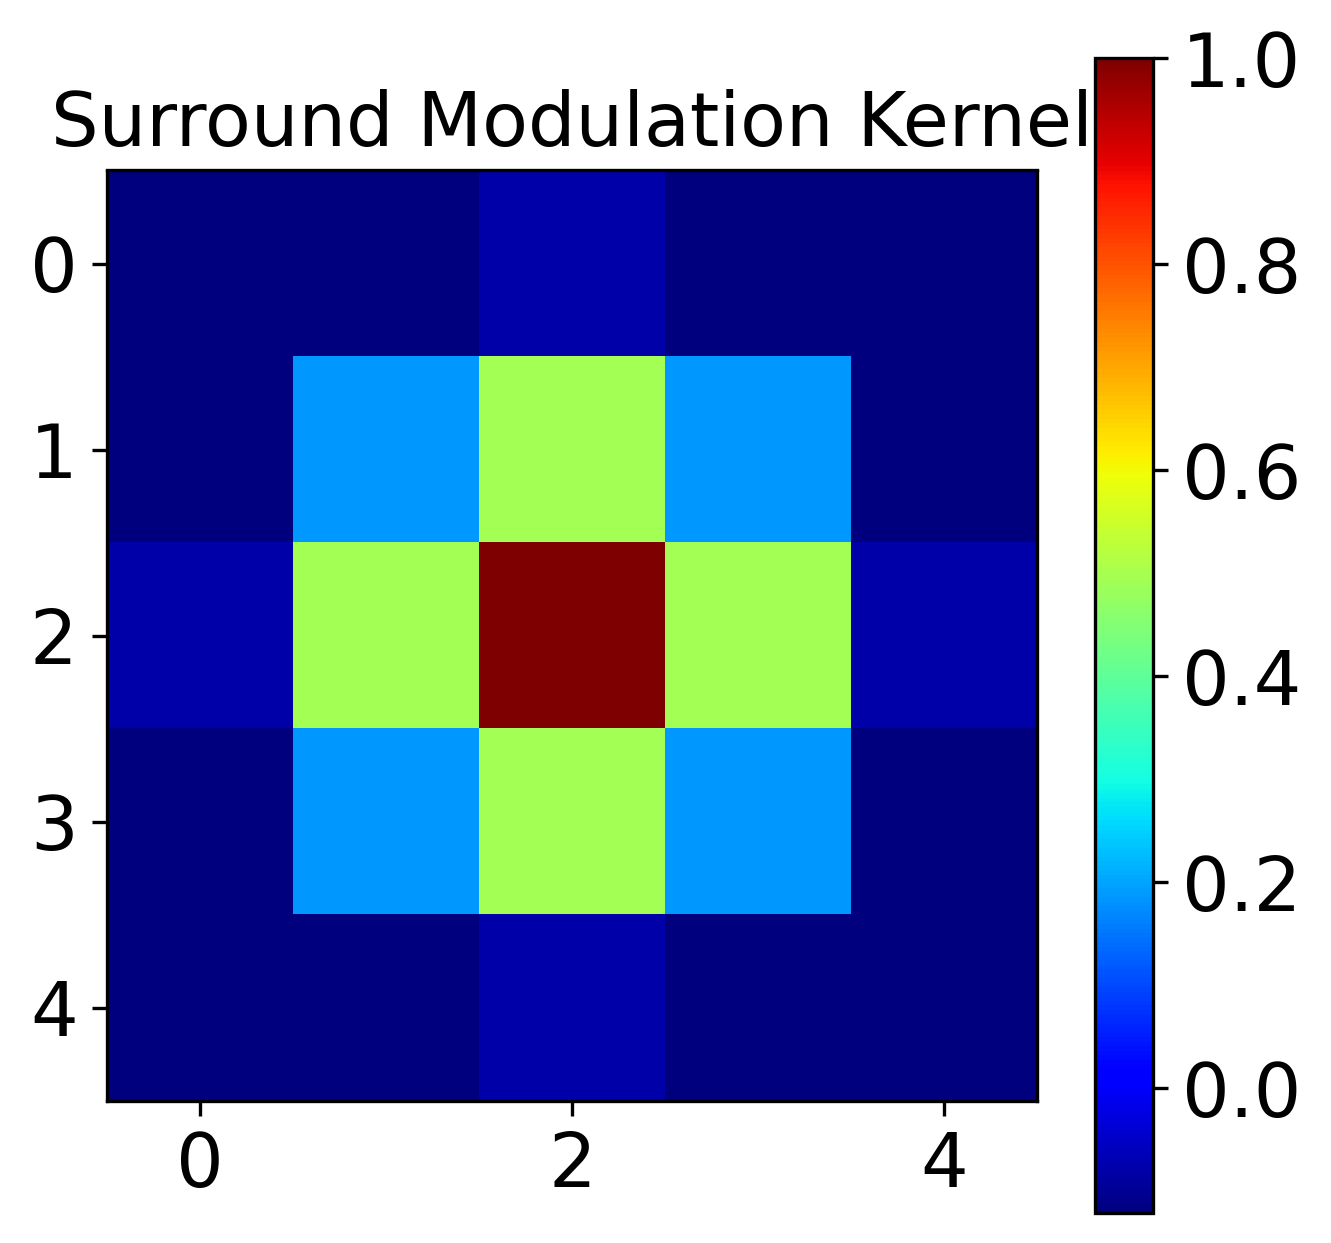

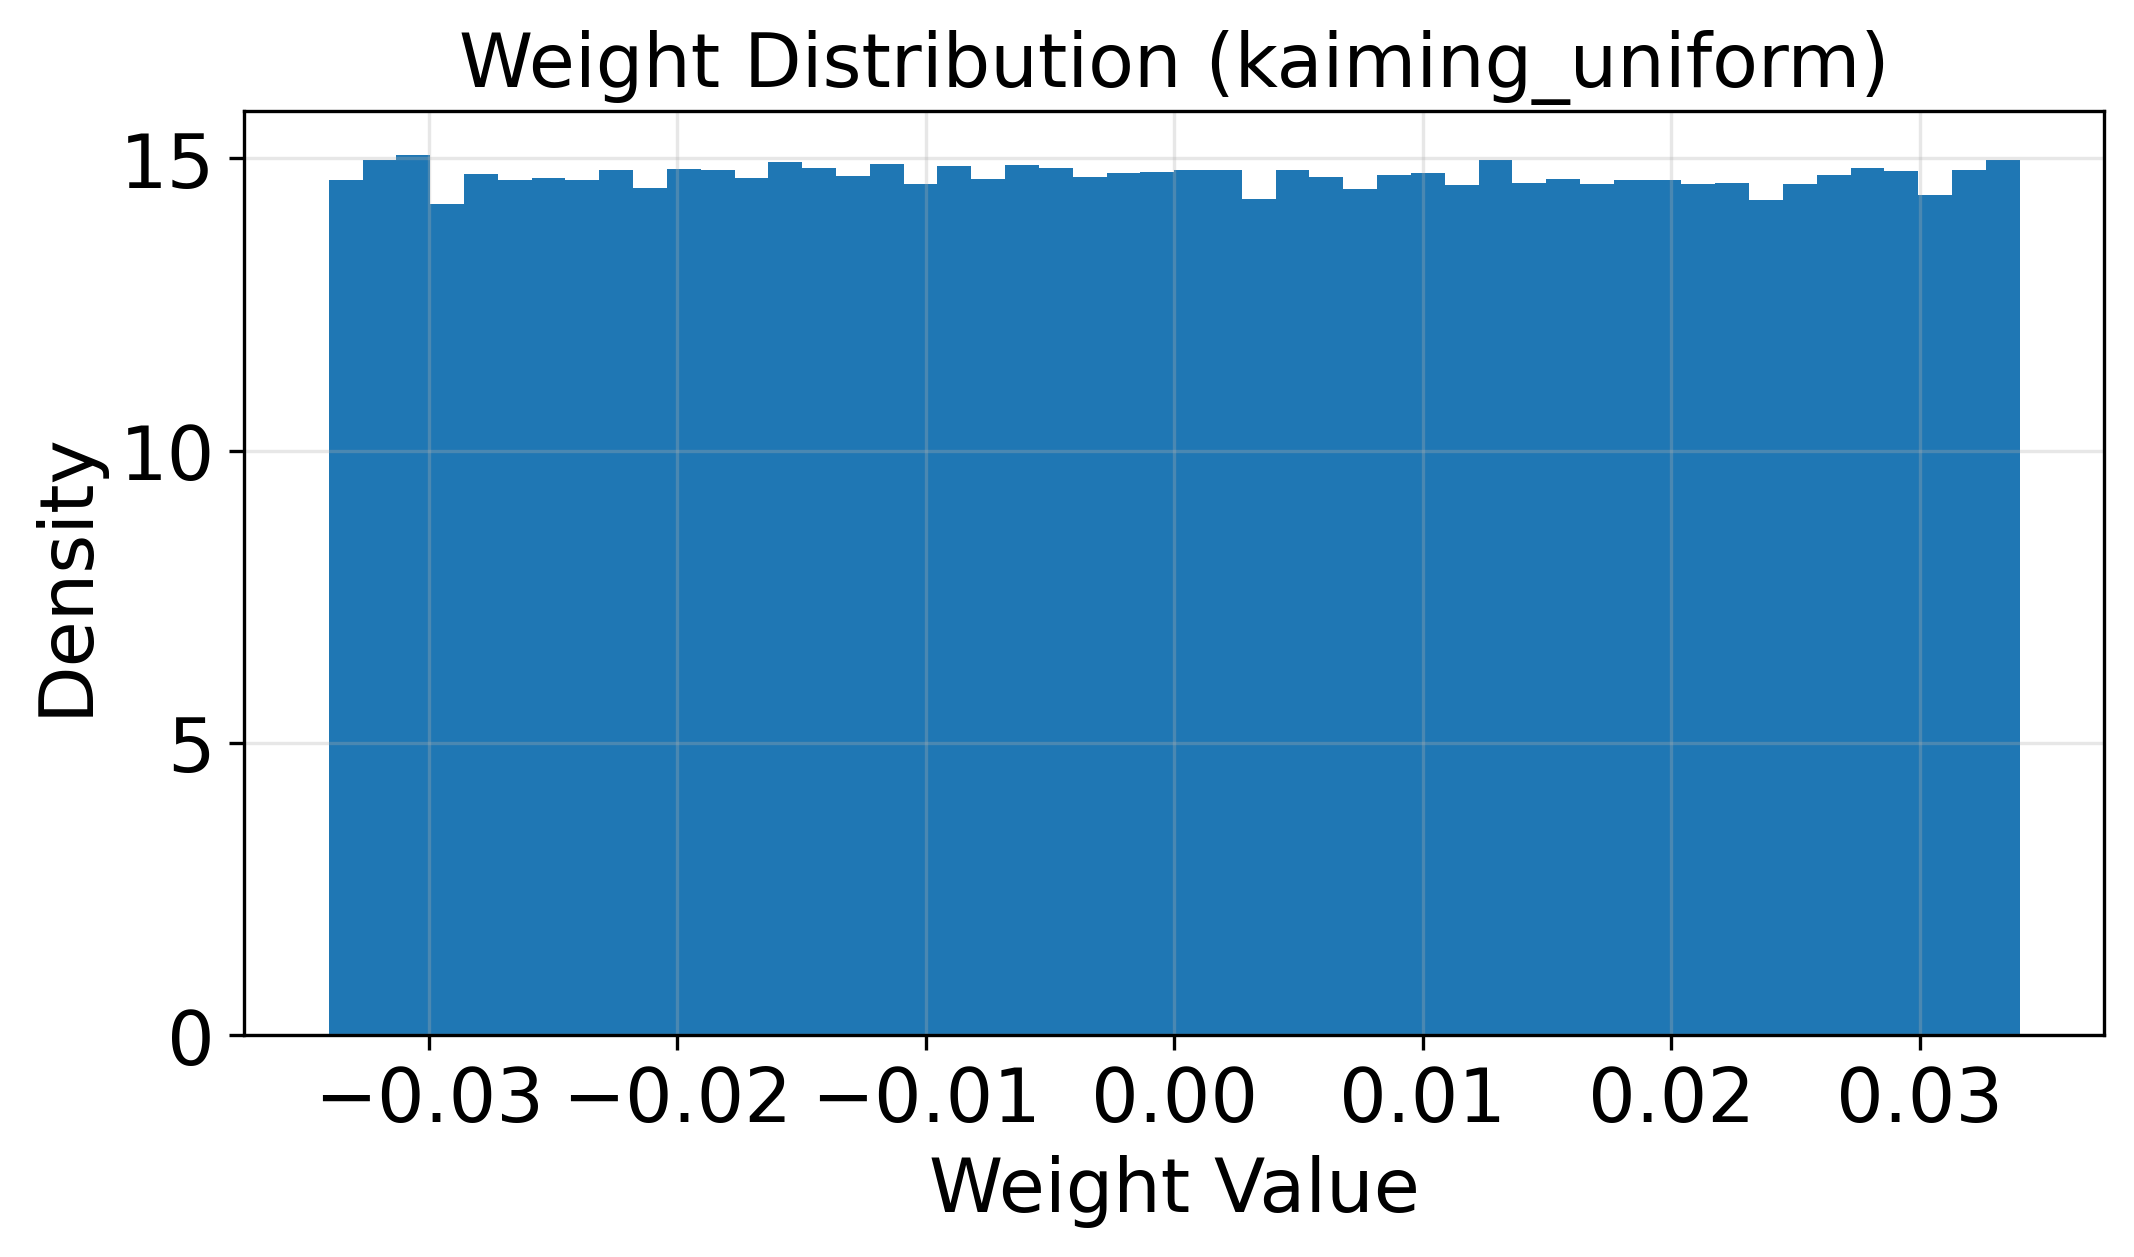

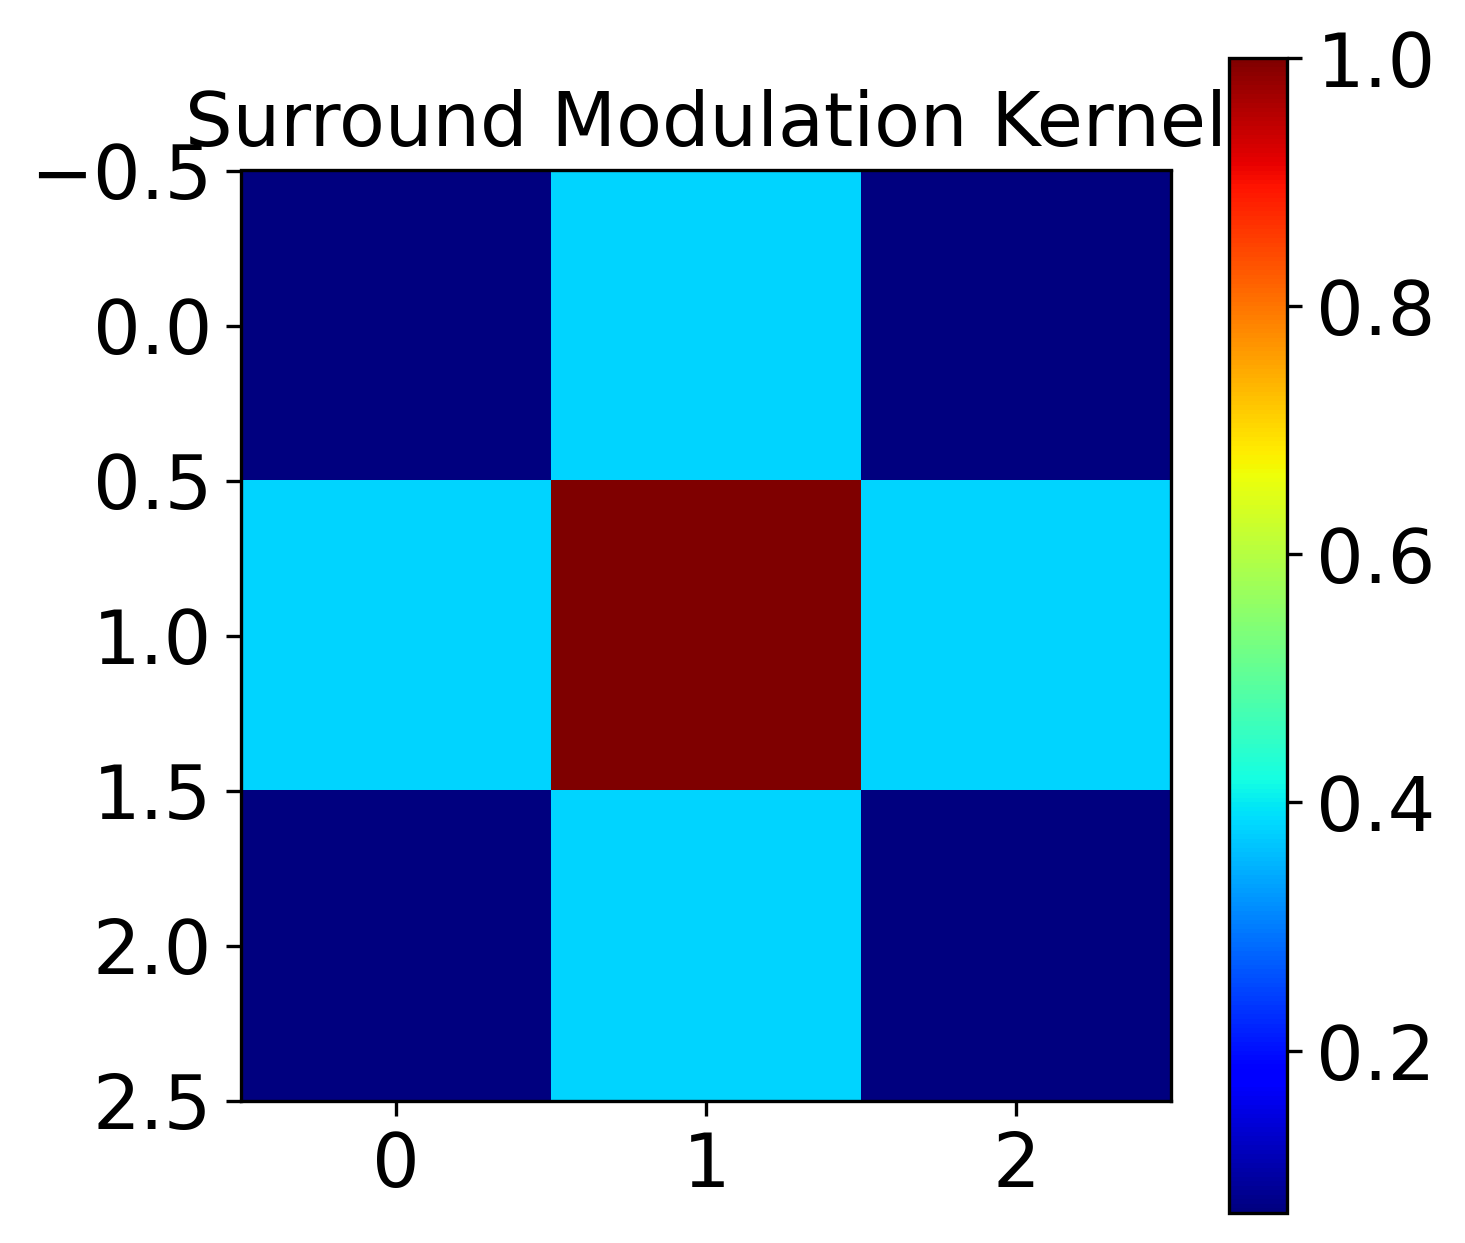

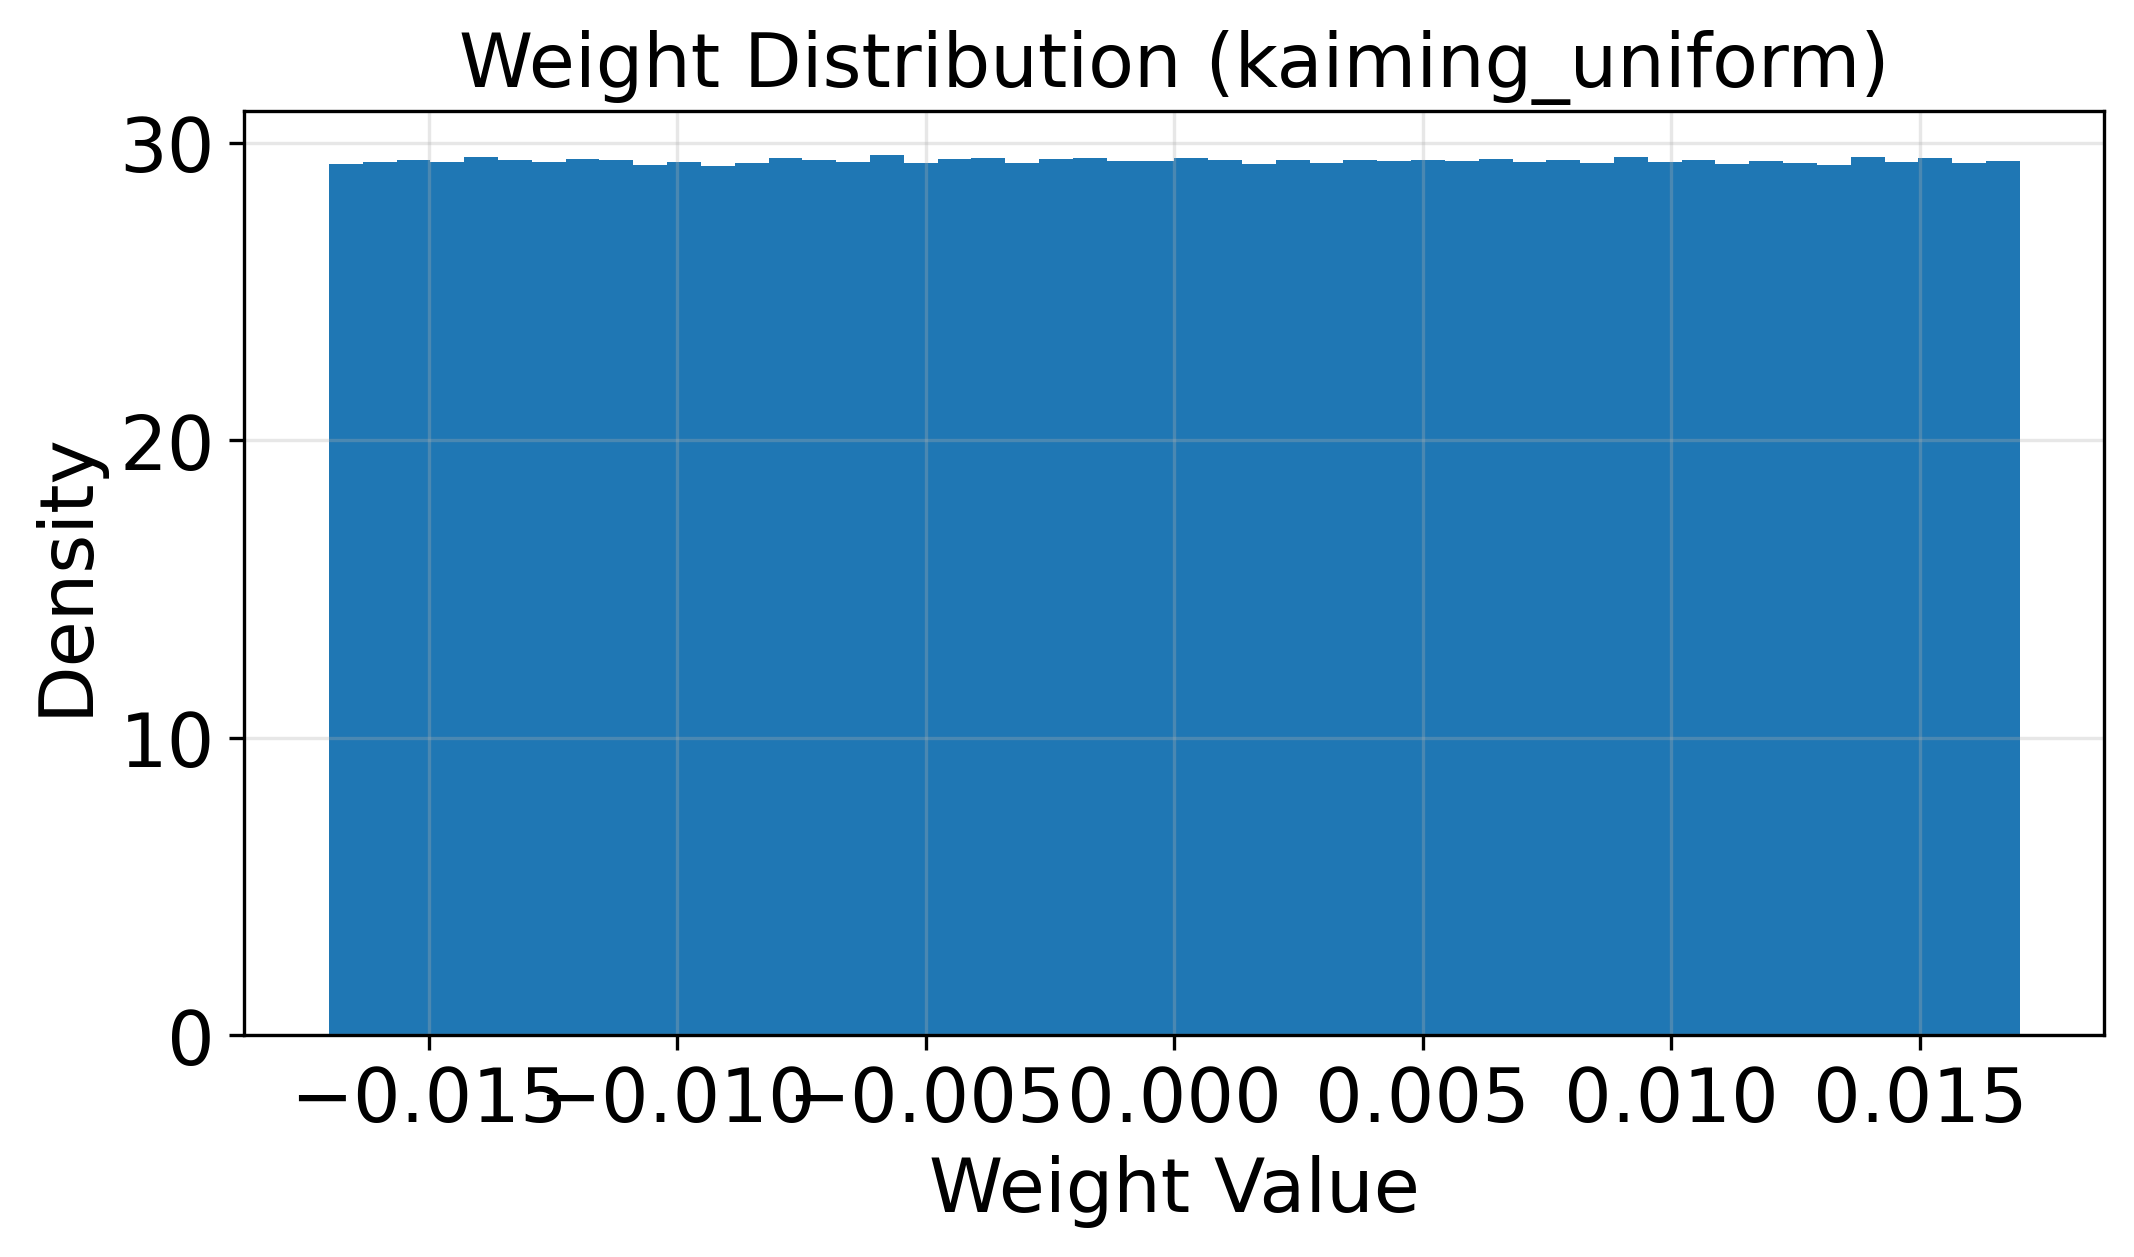

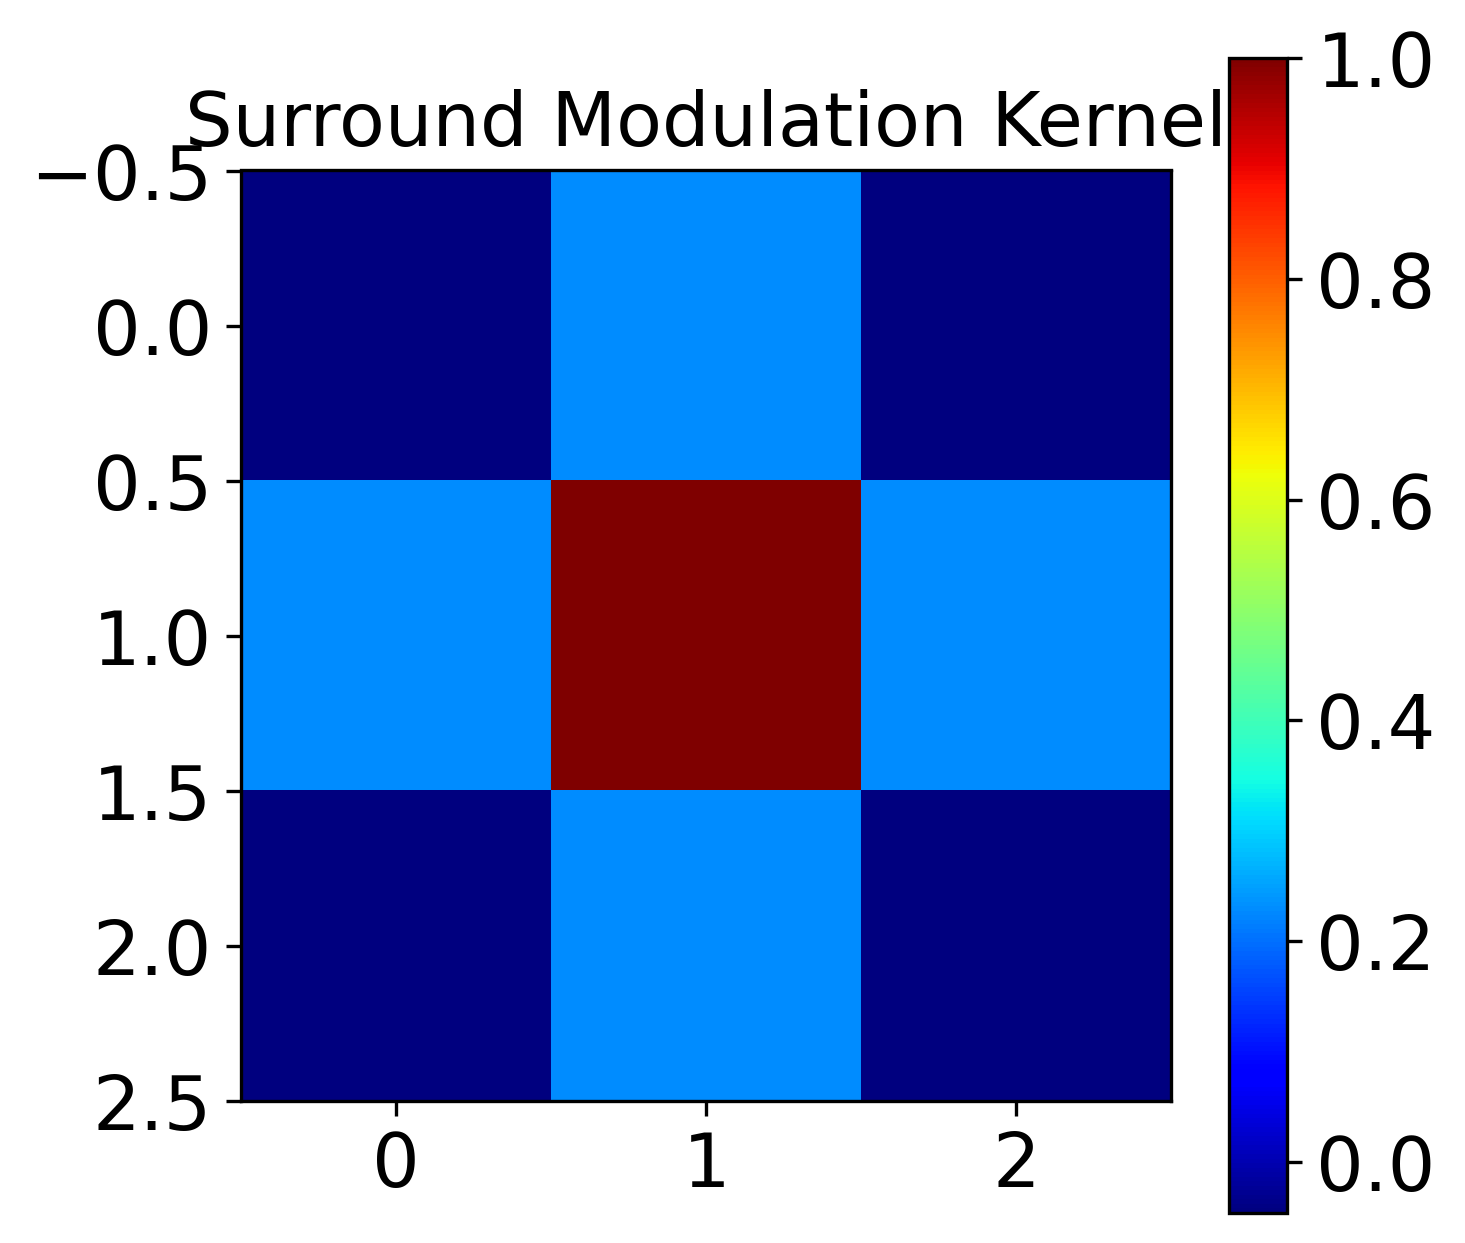

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2609 | Train Acc: 56.40% | Test Loss: 1.0316 | Test Acc: 63.90% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9840 | Train Acc: 66.10% | Test Loss: 0.9335 | Test Acc: 67.66% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9208 | Train Acc: 68.34% | Test Loss: 0.8685 | Test Acc: 69.52% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8748 | Train Acc: 69.84% | Test Loss: 0.8699 | Test Acc: 70.11% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8444 | Train Acc: 70.98% | Test Loss: 0.8716 | Test Acc: 69.58% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8257 | Train Acc: 71.52% | Test Loss: 0.8308 | Test Acc: 70.72% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8170 | Train Acc: 71.71% | Test Loss: 0.8158 | Test Acc: 71.30% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8019 | Train Acc: 72.32% | Test Loss: 0.8362 | Test Acc: 70.57% | LR: 0.001000
Epoch [9/2

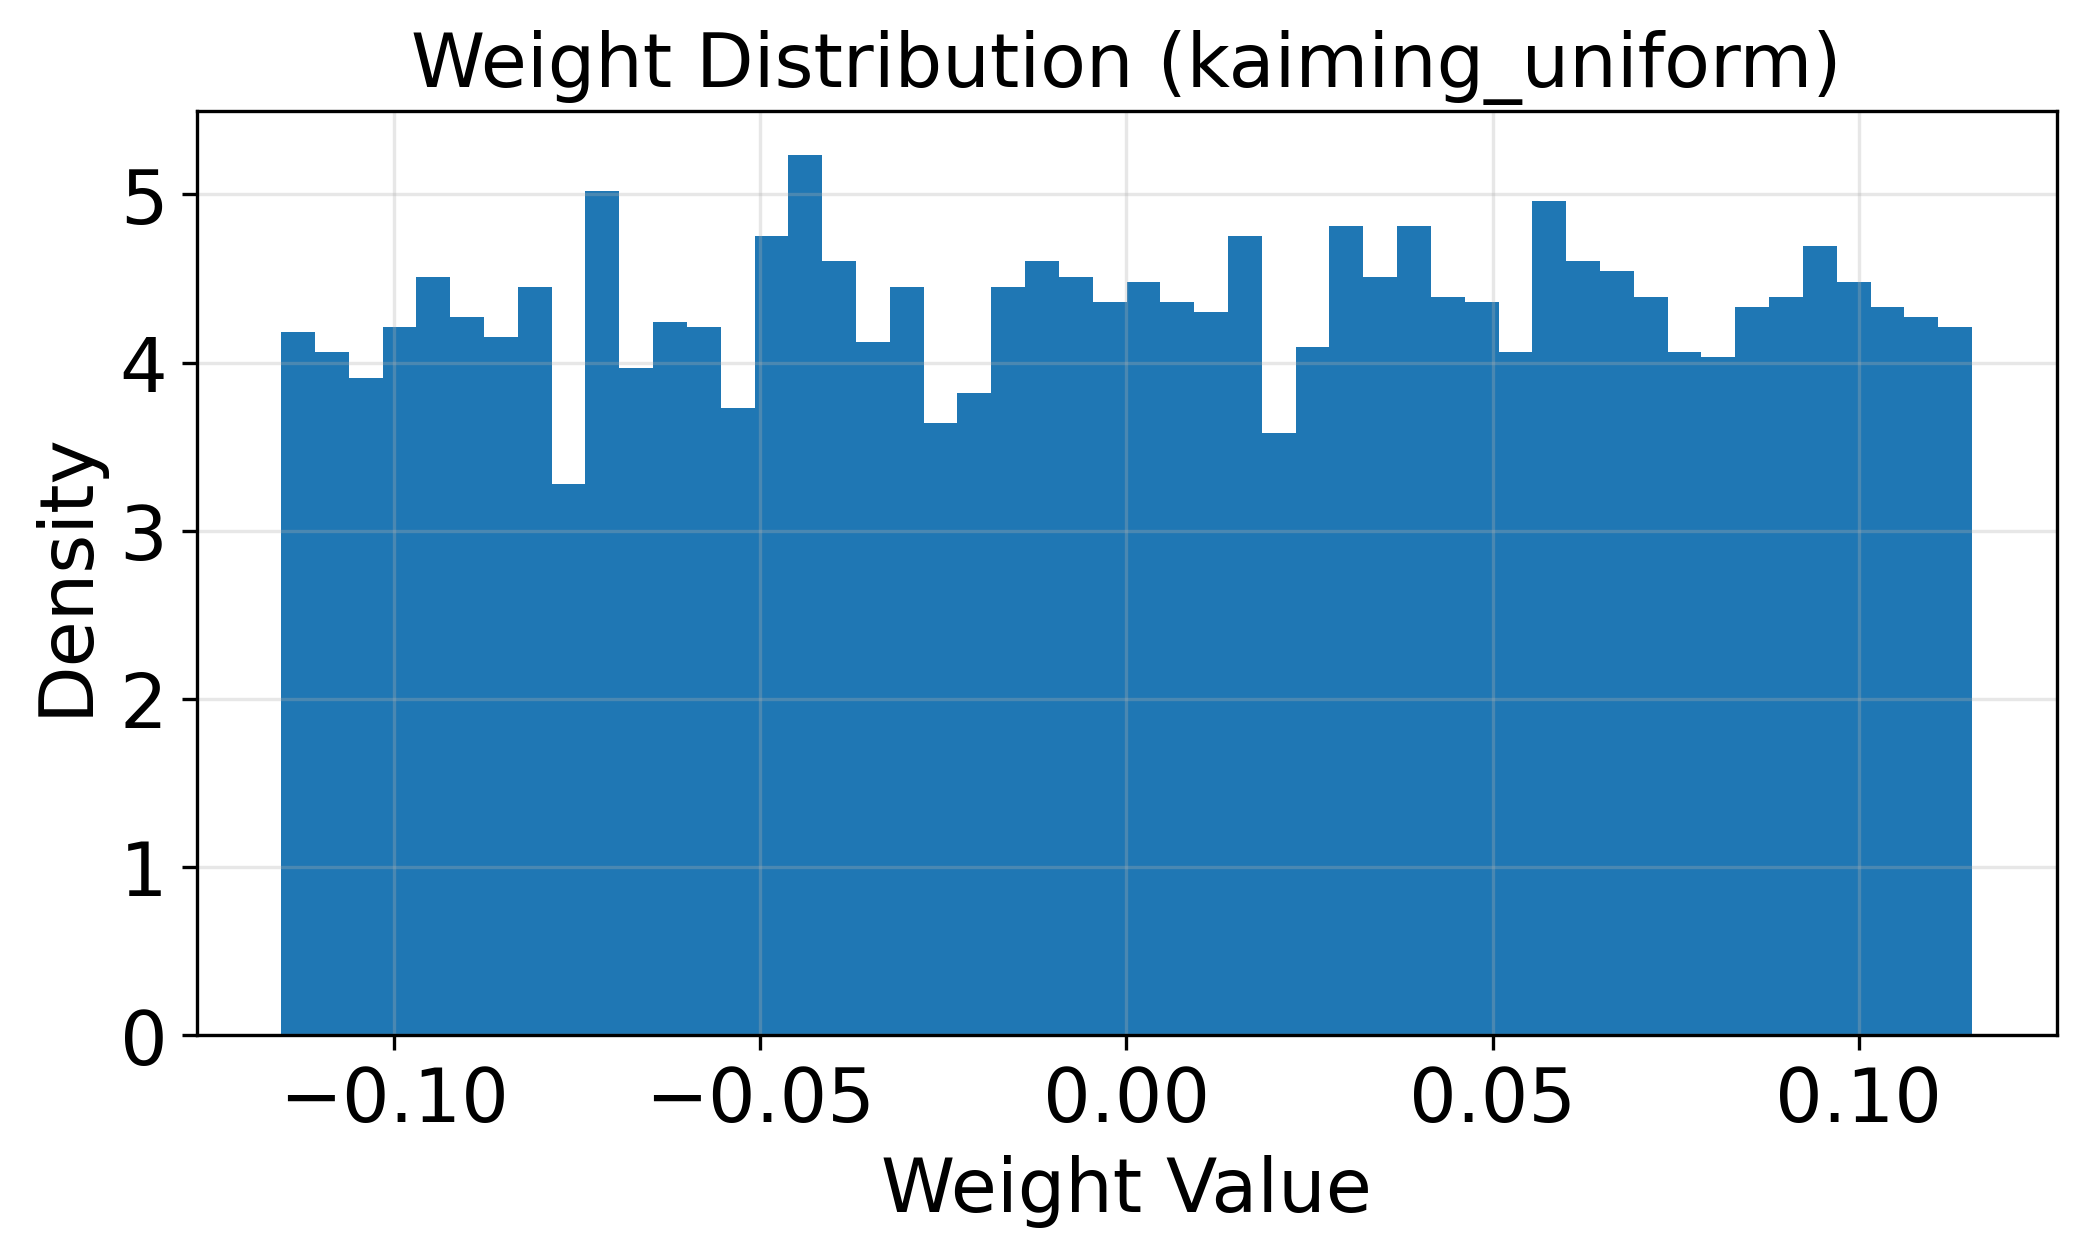

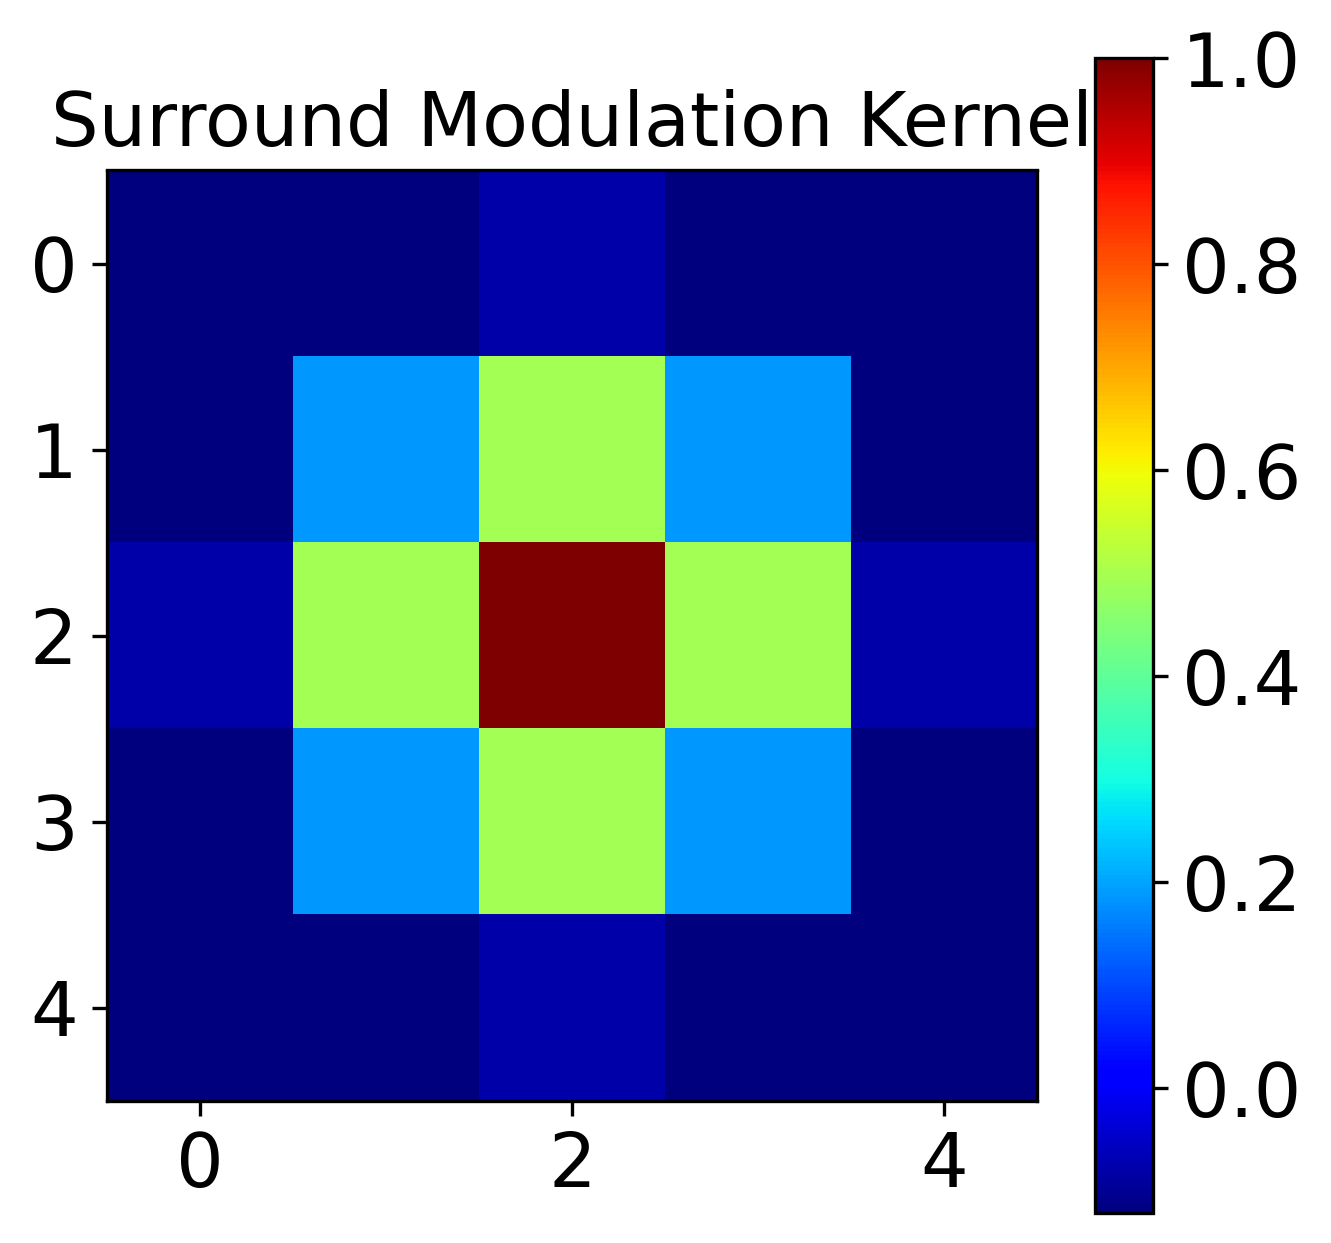

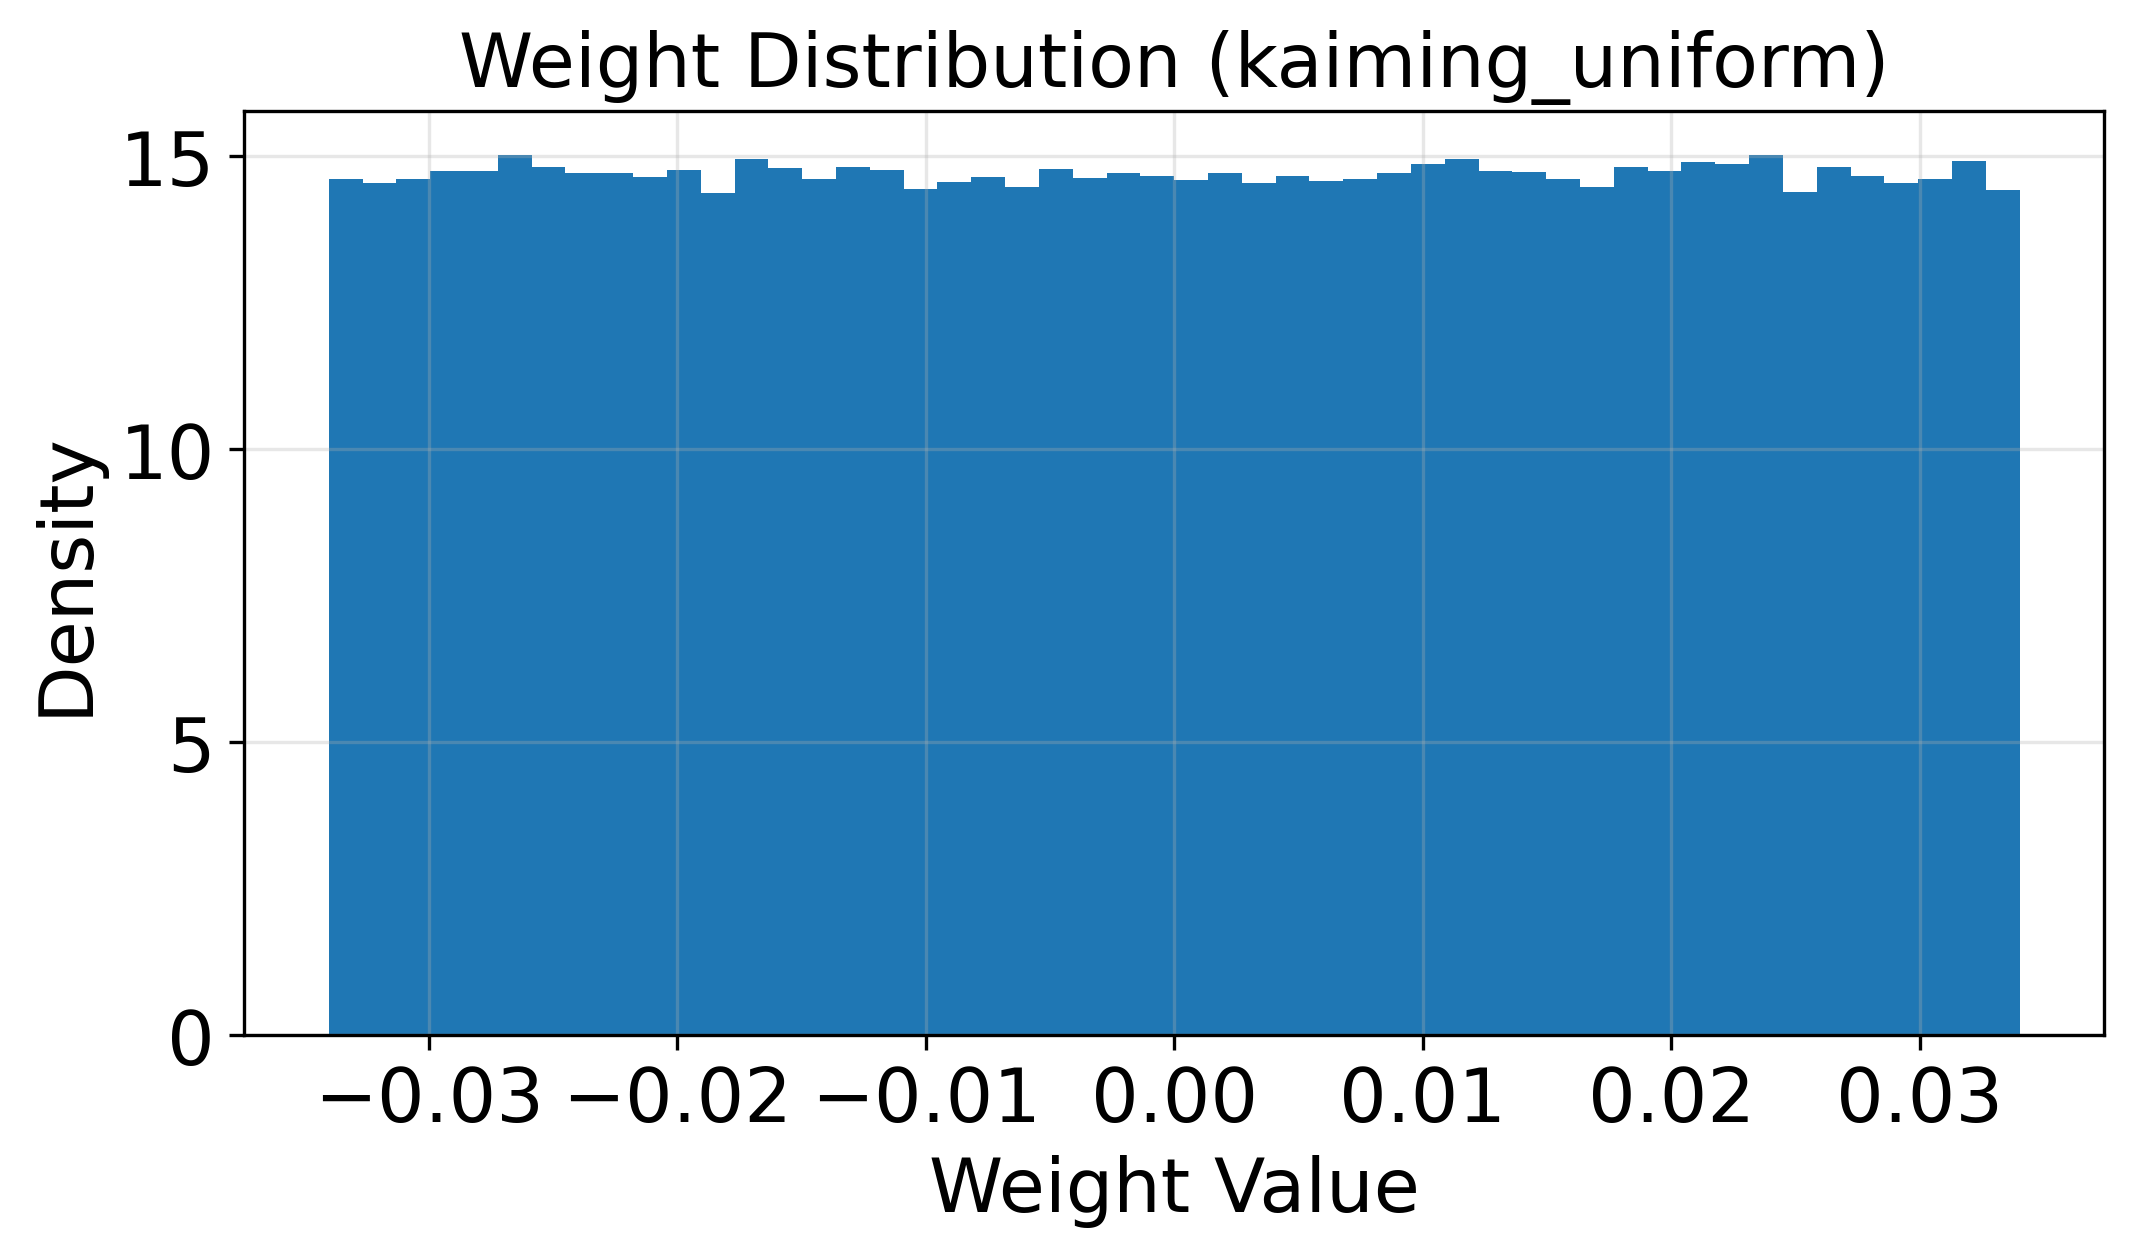

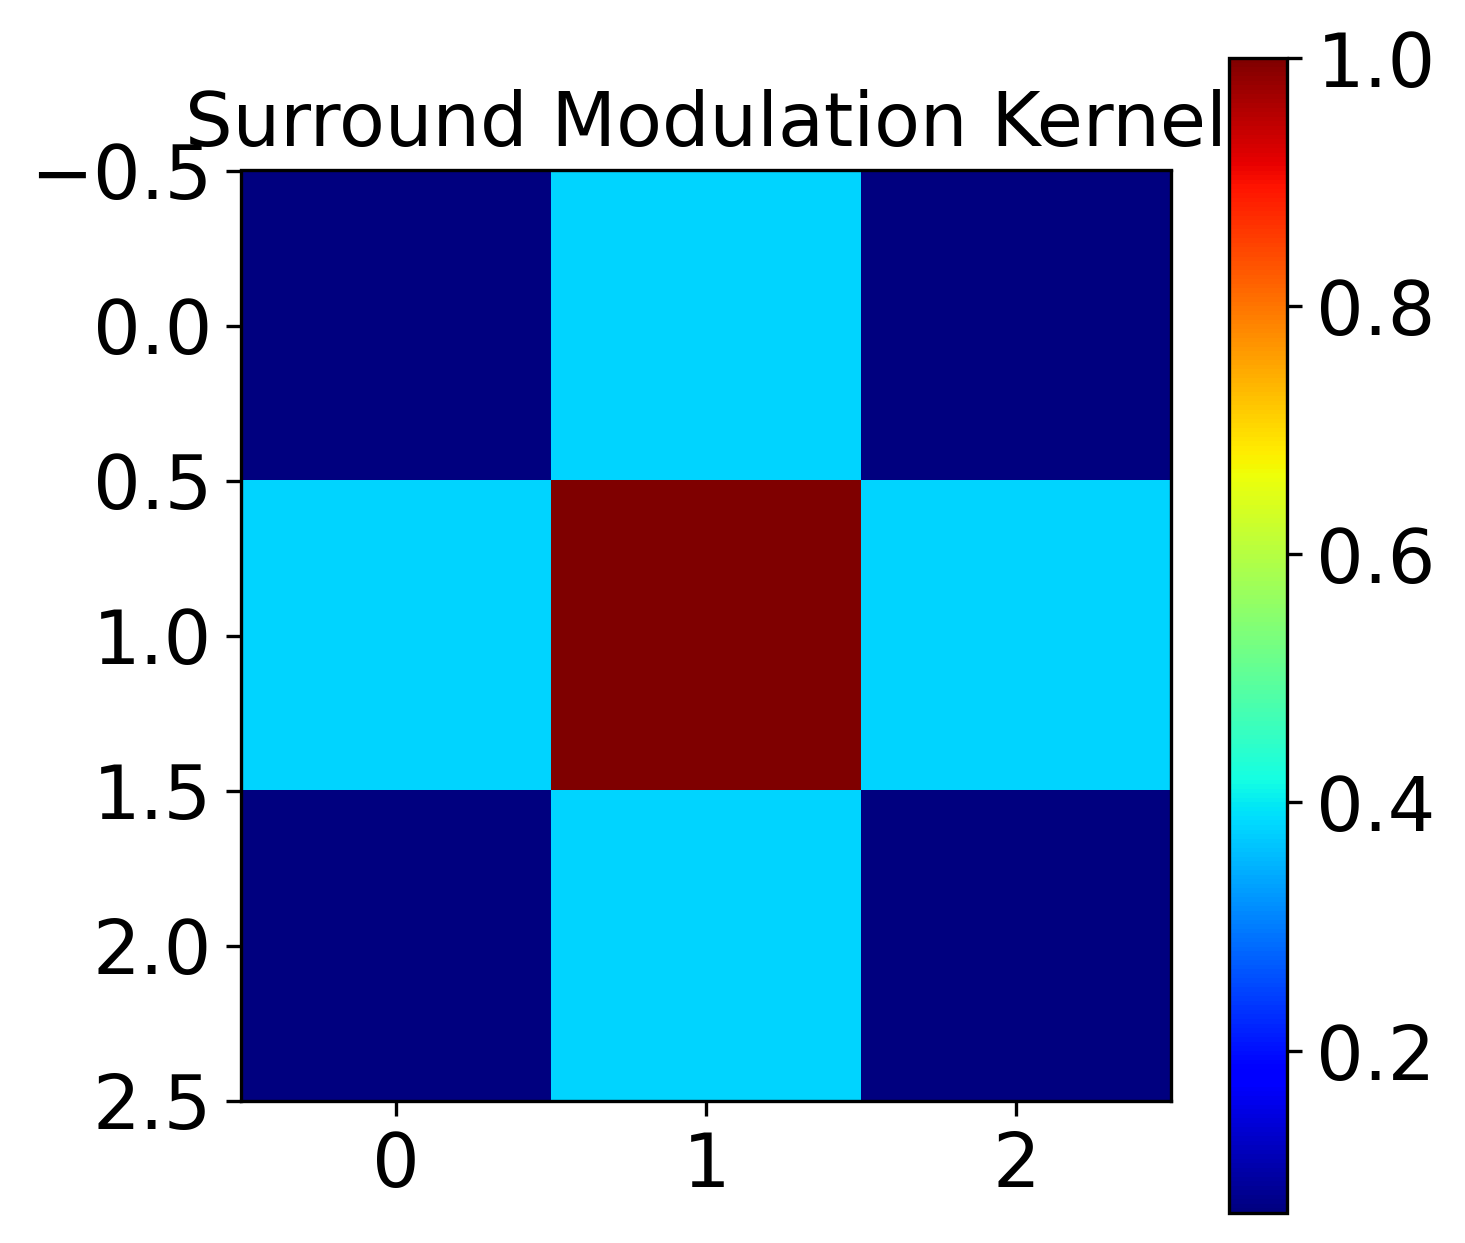

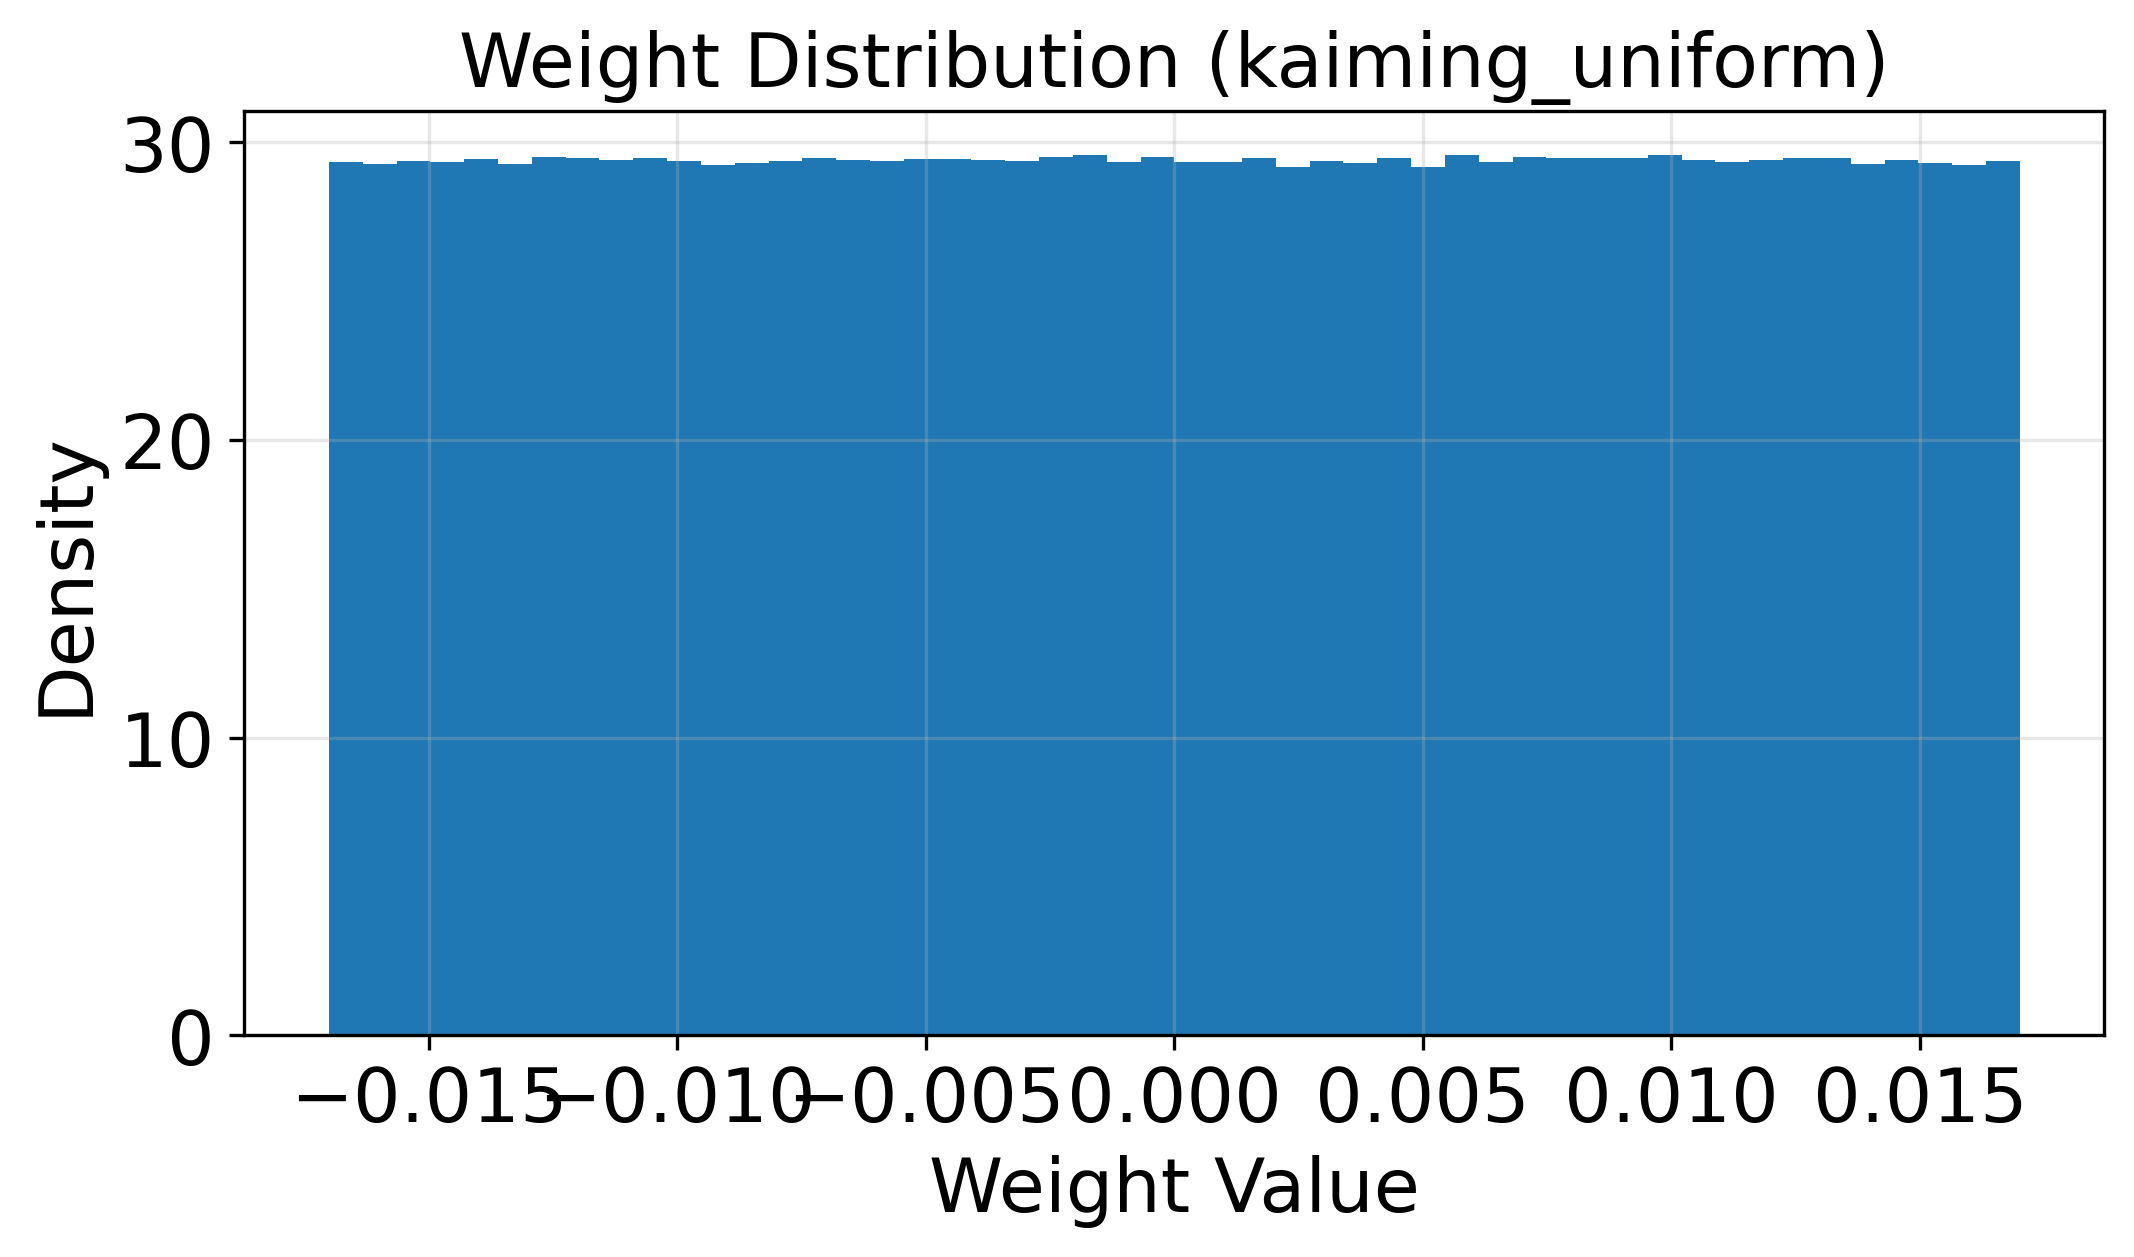

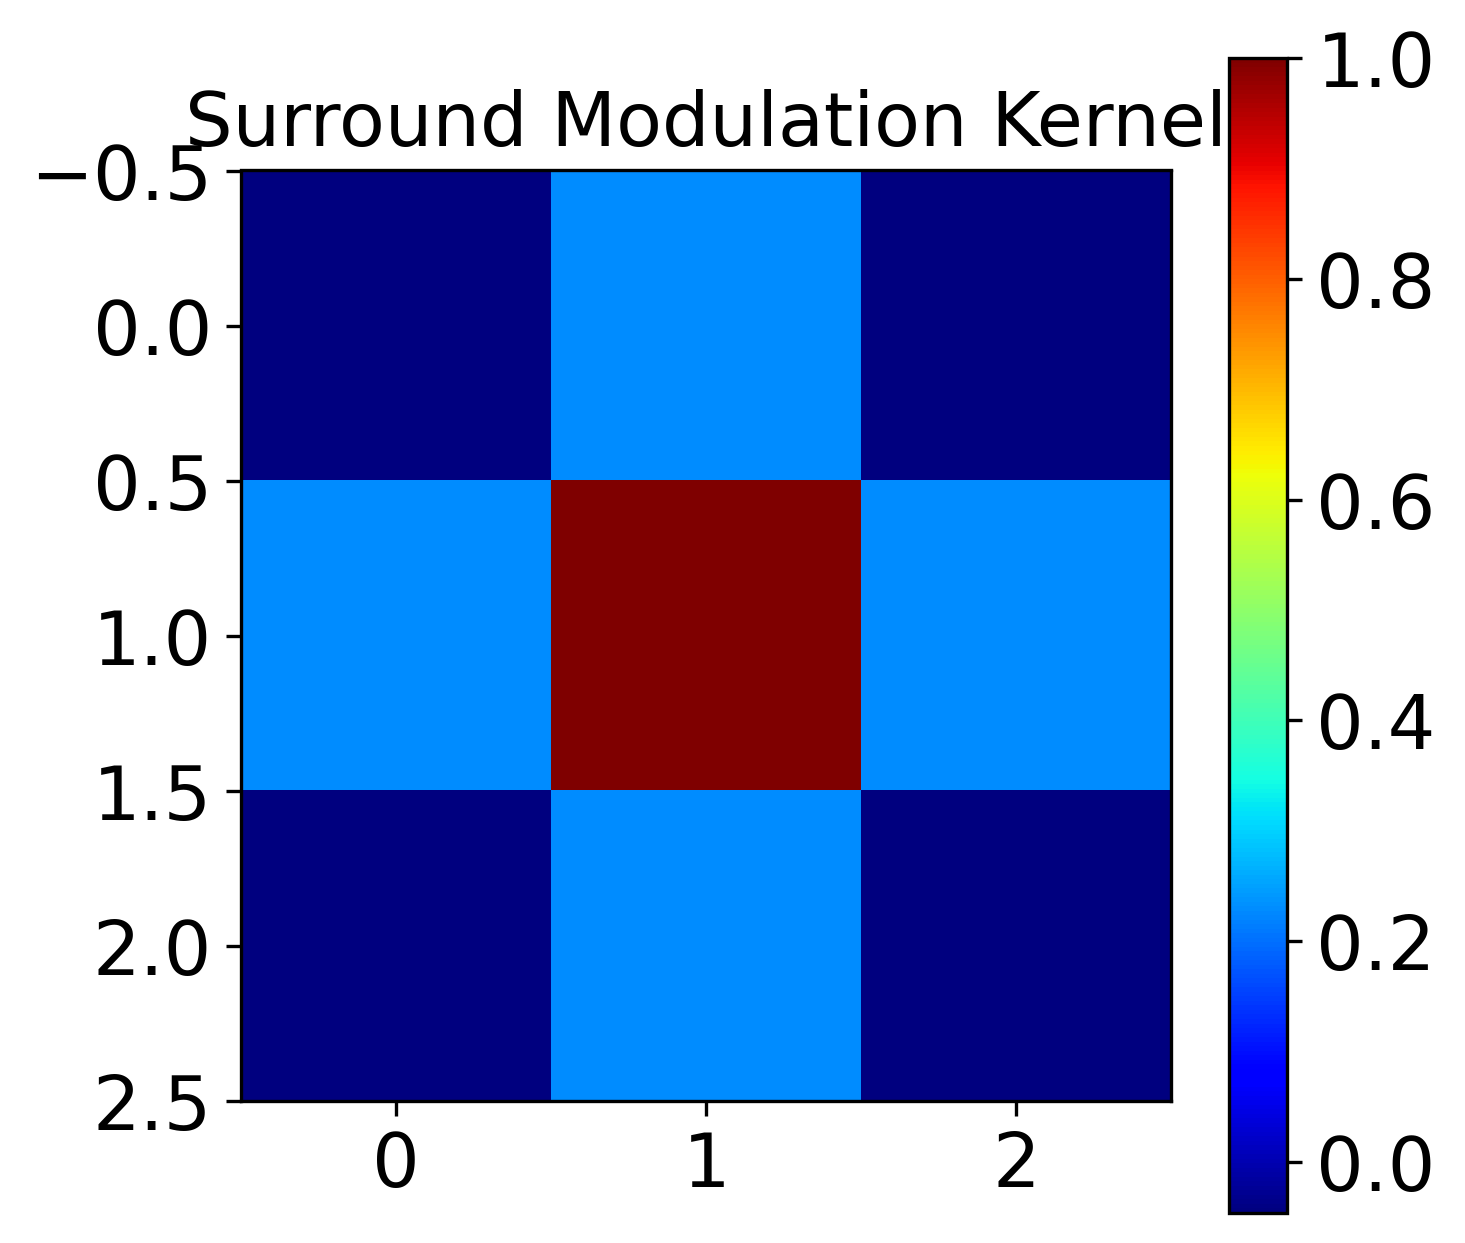

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3069 | Train Acc: 54.64% | Test Loss: 1.0366 | Test Acc: 63.99% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0258 | Train Acc: 64.54% | Test Loss: 0.9767 | Test Acc: 66.24% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9571 | Train Acc: 66.84% | Test Loss: 0.9136 | Test Acc: 68.07% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9144 | Train Acc: 68.56% | Test Loss: 0.9211 | Test Acc: 68.20% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8910 | Train Acc: 69.16% | Test Loss: 0.8469 | Test Acc: 70.65% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8656 | Train Acc: 70.08% | Test Loss: 0.8378 | Test Acc: 70.85% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8568 | Train Acc: 70.31% | Test Loss: 0.8248 | Test Acc: 71.14% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8495 | Train Acc: 70.79% | Test Loss: 0.8306 | Test Acc: 71.01% | LR: 0.001000
Epoch [9/2

In [ ]:
#zca stats only need be computed once:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            #do the zca transform per batch (equivalent to doing it for every image as the researchers do, but saves on runtime)
            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                #again zca transform the batch
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [37]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
train_acc_df=pd.DataFrame(train_acc)

In [54]:
test_acc_df=pd.DataFrame(test_acc)


In [ ]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_train_acc_.csv",index=False)

In [55]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_test_acc_.csv",index=False)


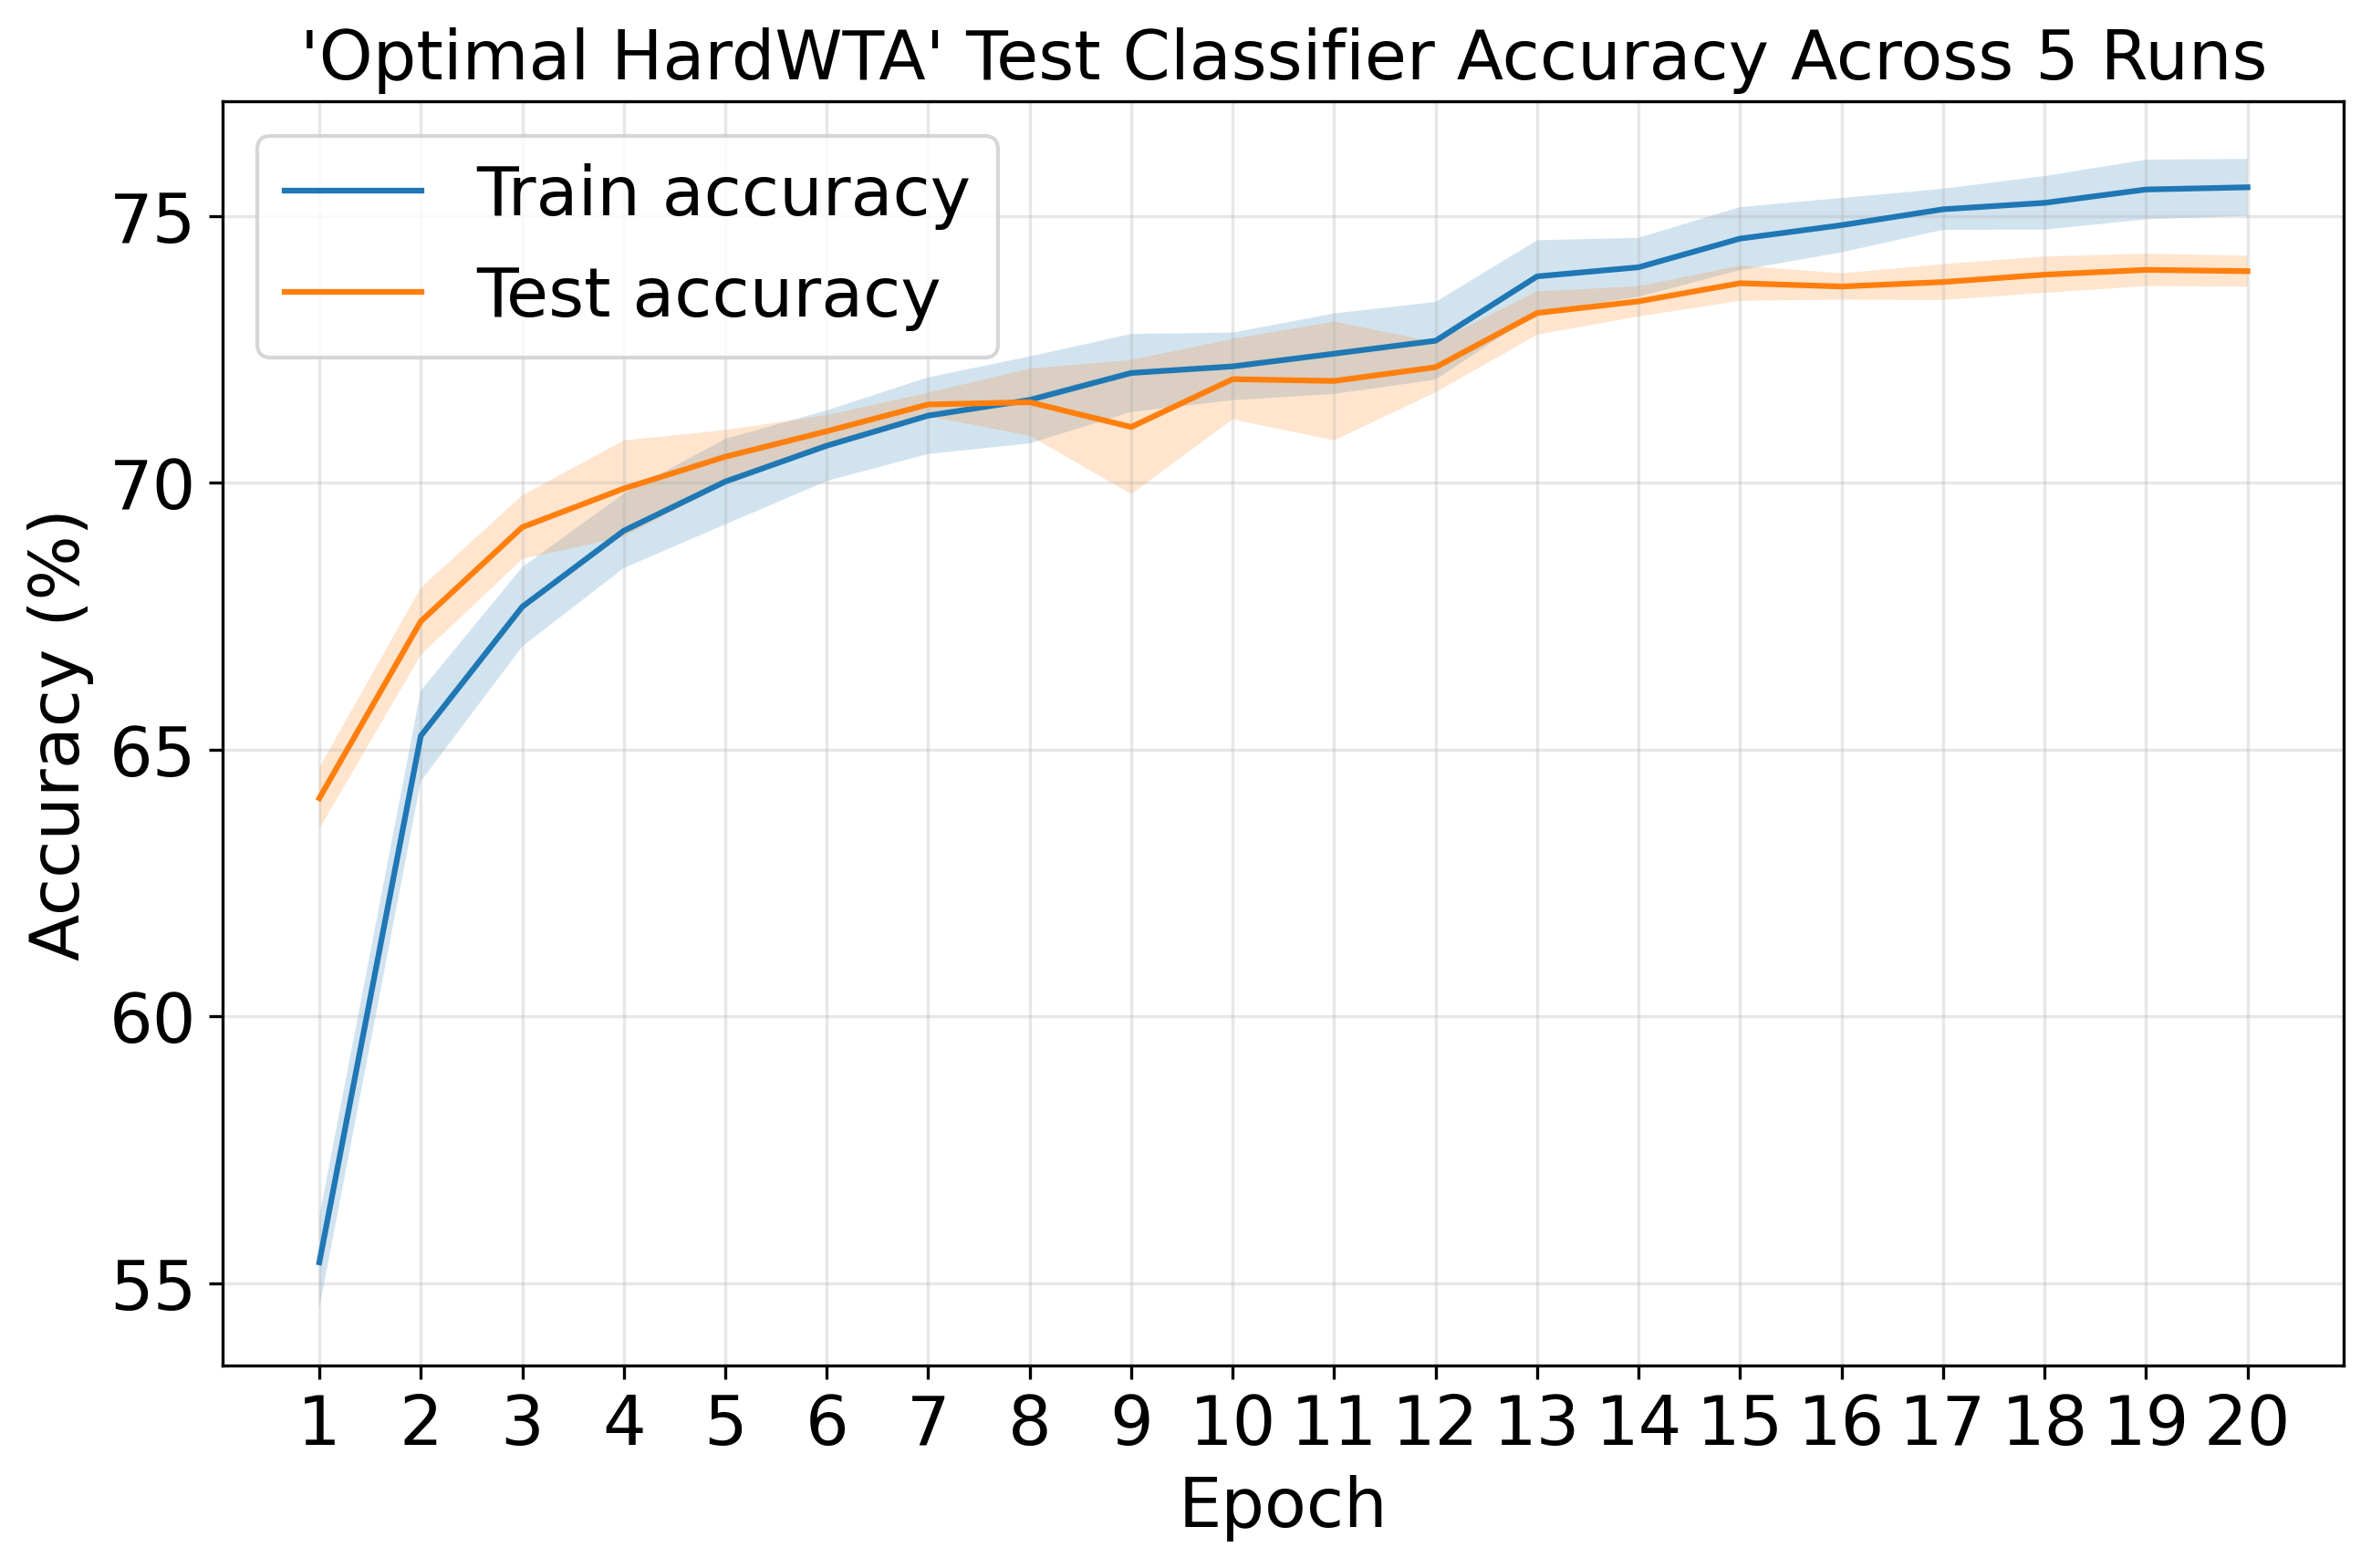

In [56]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 73.96 ± 0.29%


In [58]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 74.04 ± 0.32%


# Removing the data leakage:

In [36]:
zca_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

all_train_data = []

for images, _ in zca_loader:
    all_train_data.append(images)

all_train_data = torch.cat(all_train_data, dim=0)

print(all_train_data.shape)
# [50000, 3, 32, 32]

zca = ZCAWhitening(epsilon=1e-3)
zca.fit(all_train_data)

torch.Size([50000, 3, 32, 32])


In [37]:
# just inspecting the effect on the first seed:
seeds = [0]
all_histories = {}

RUN 1/ 1 | SEED = 0
Building SoftHebb model


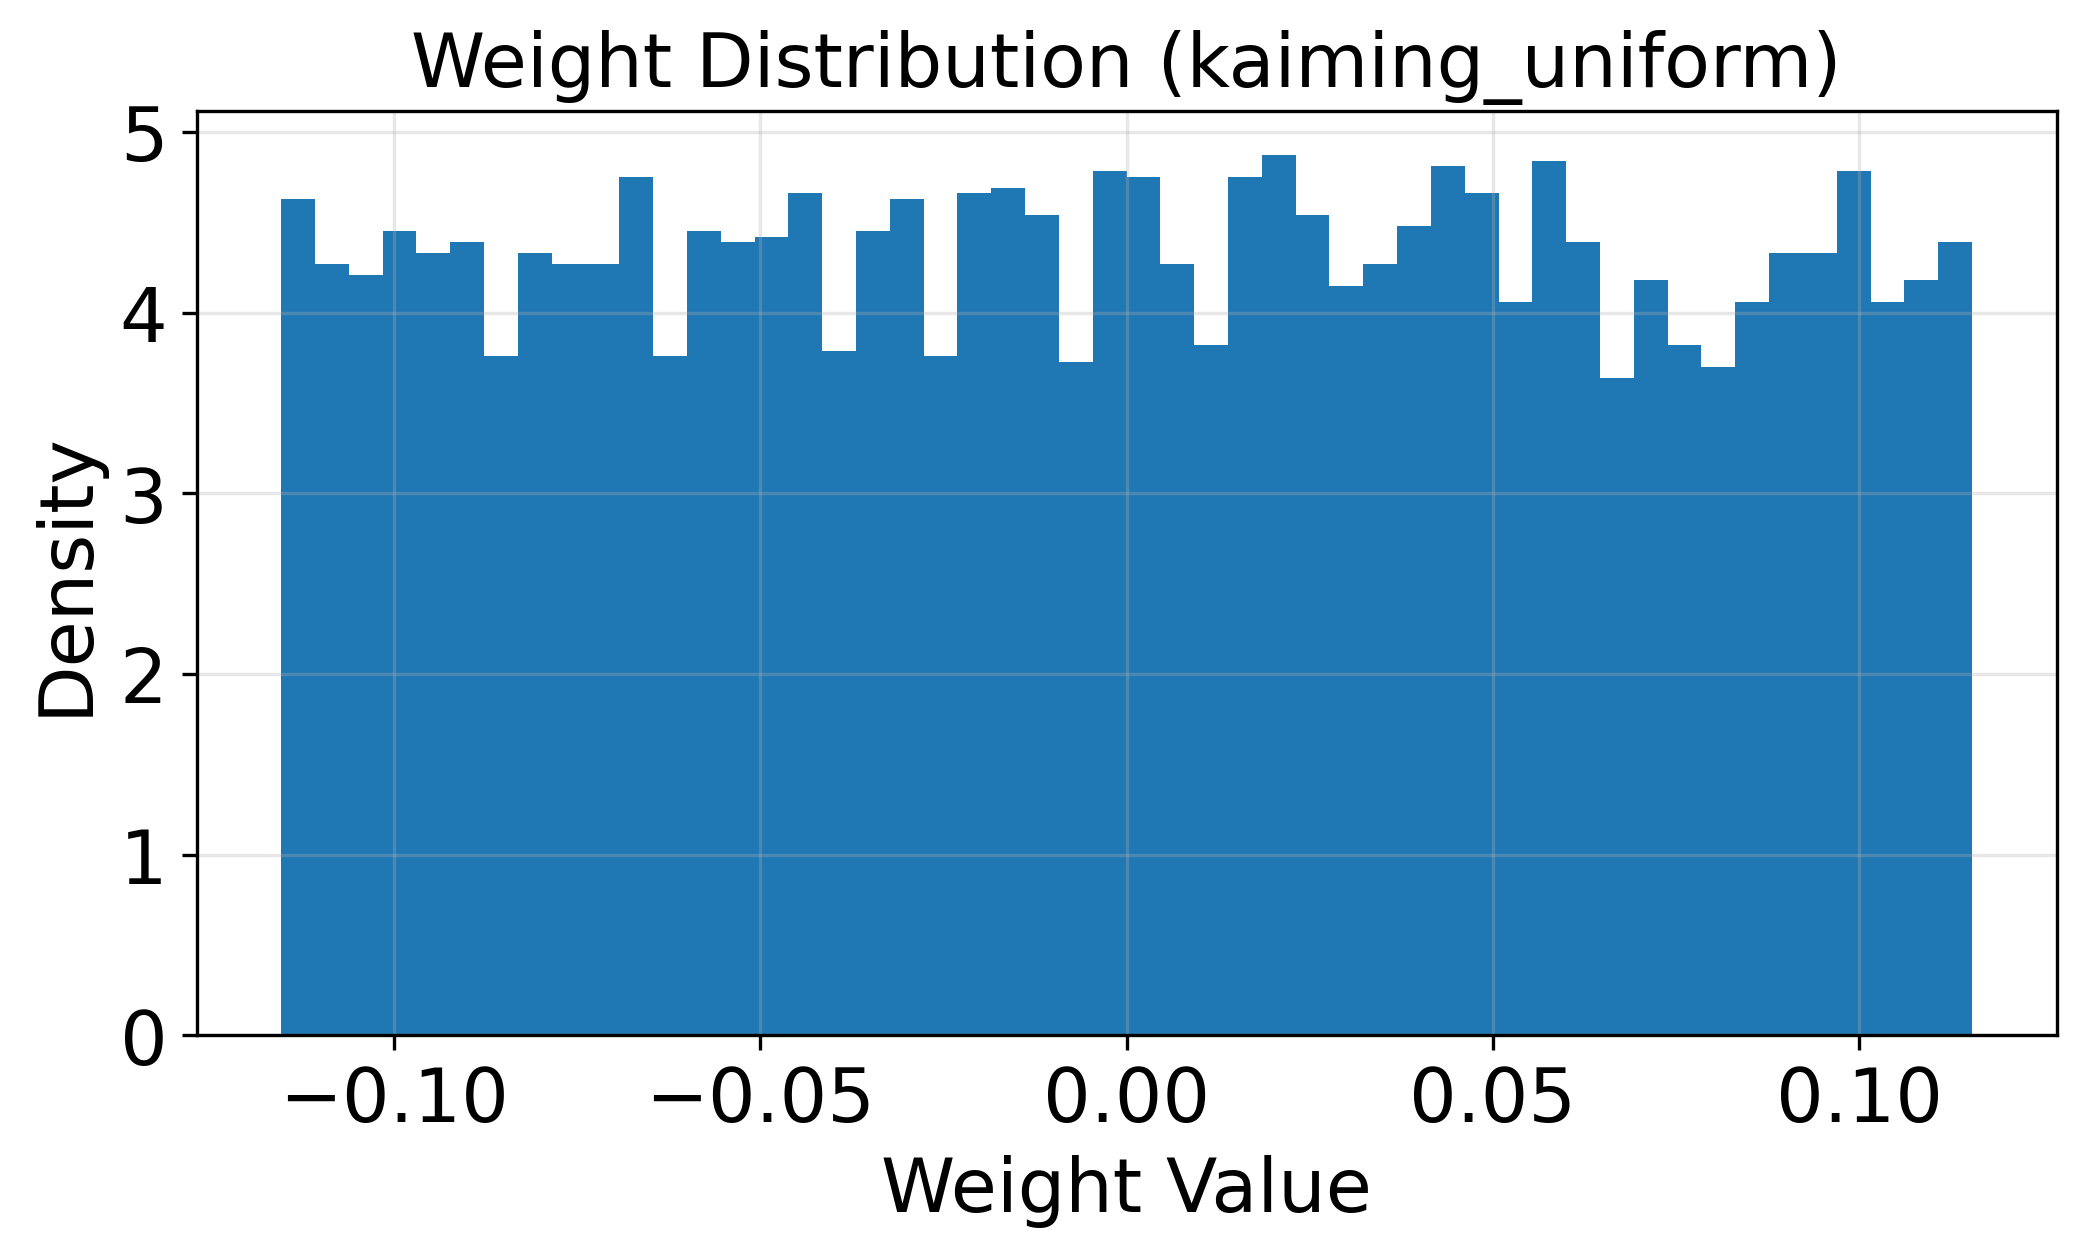

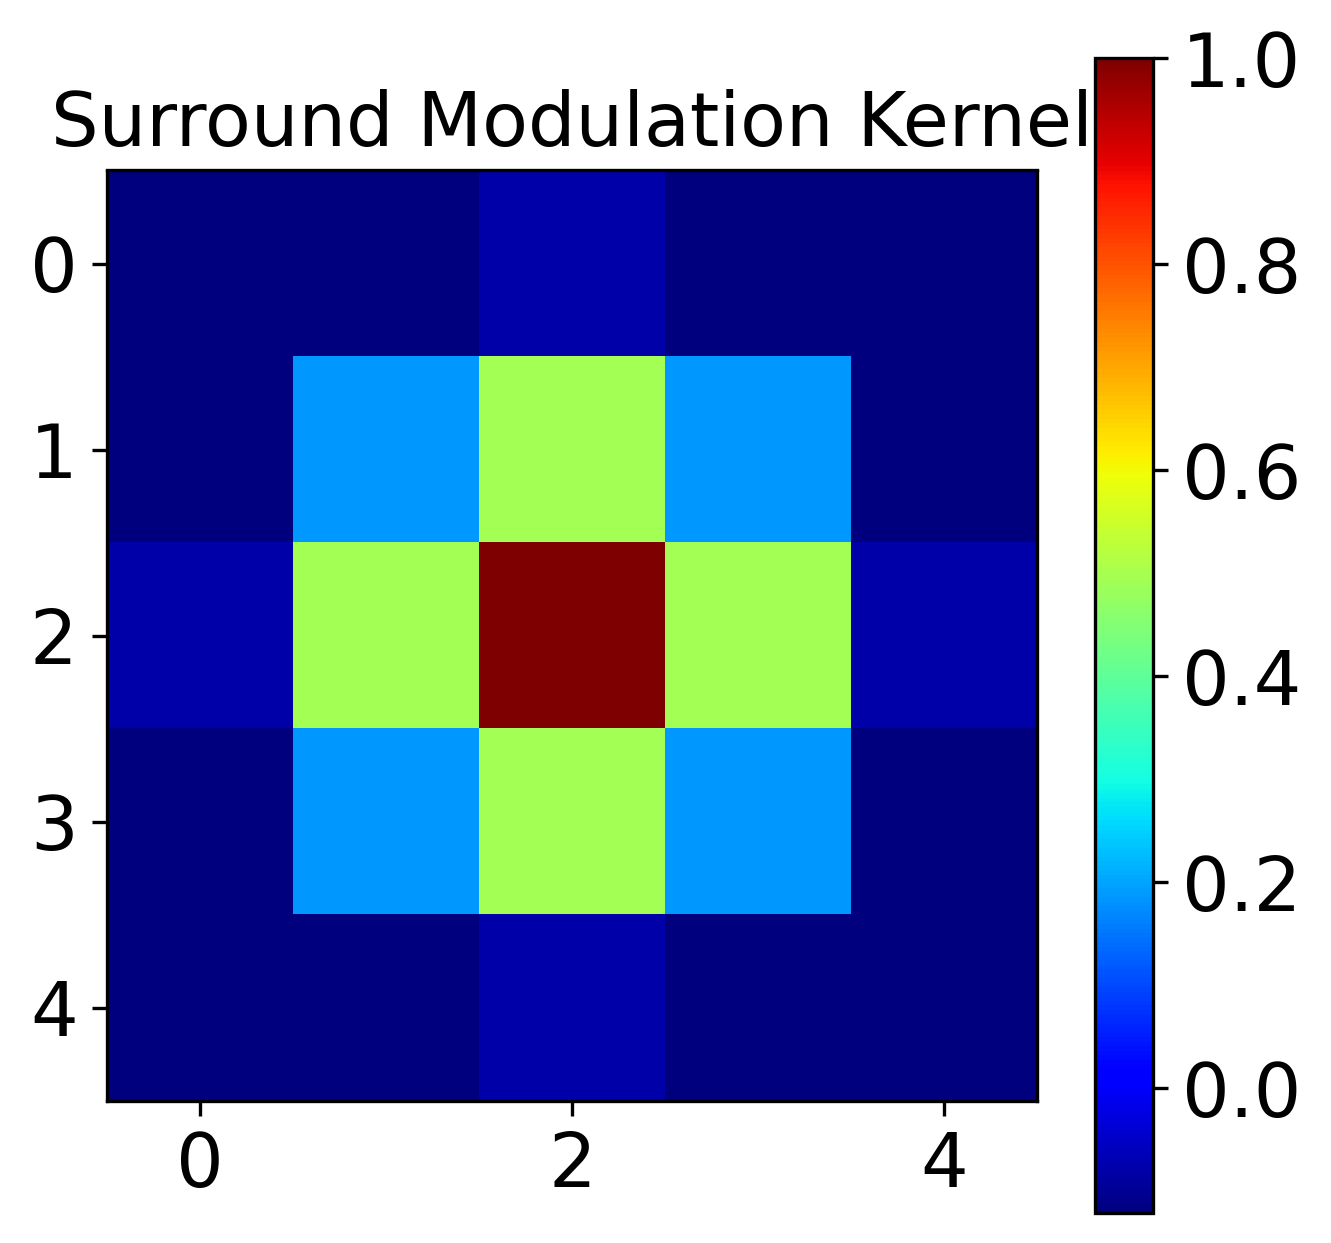

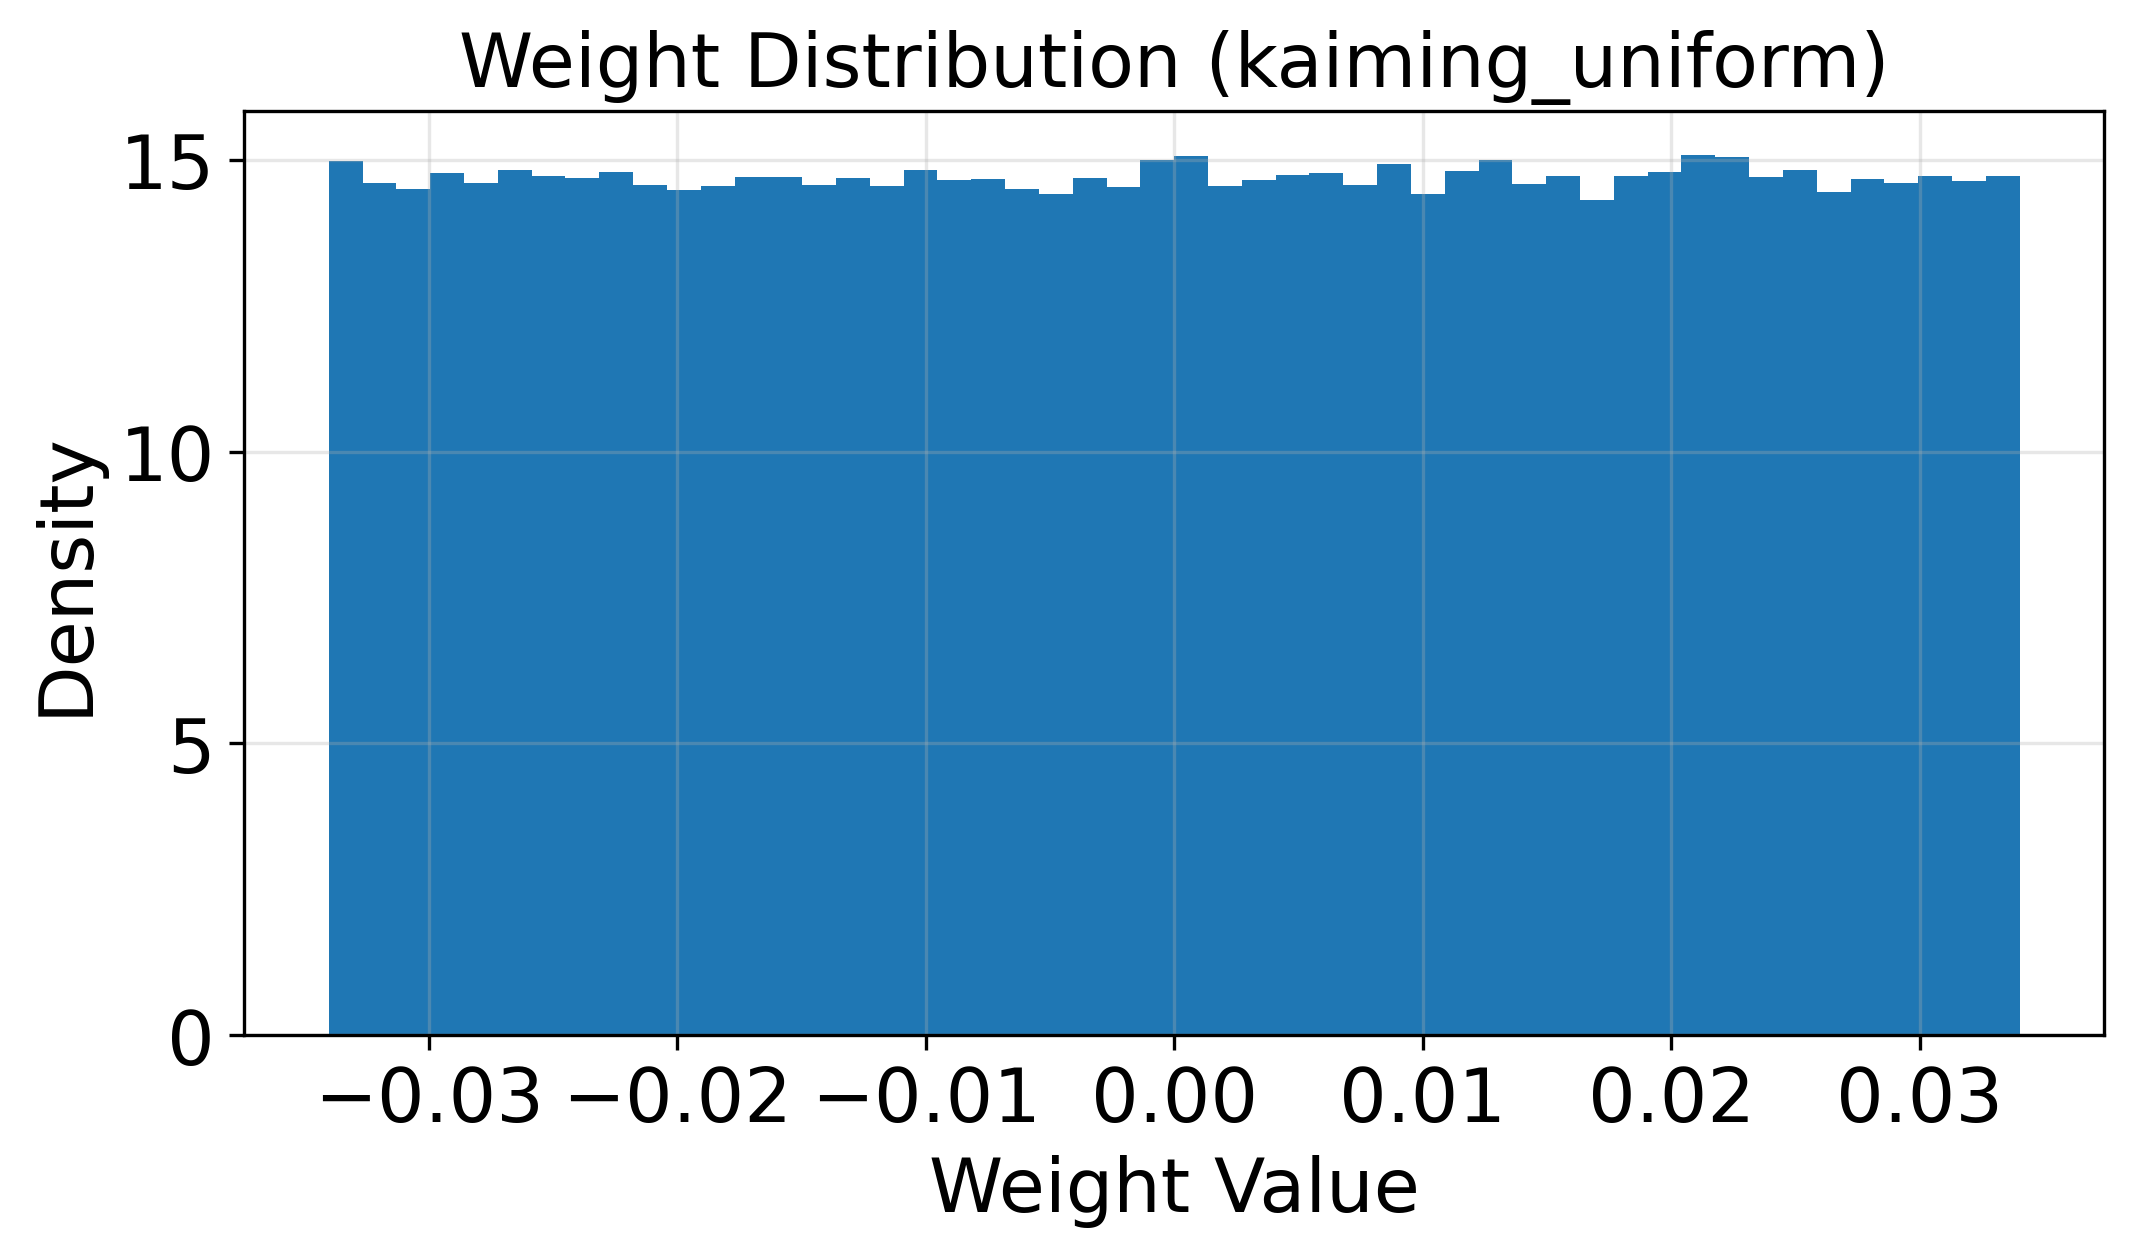

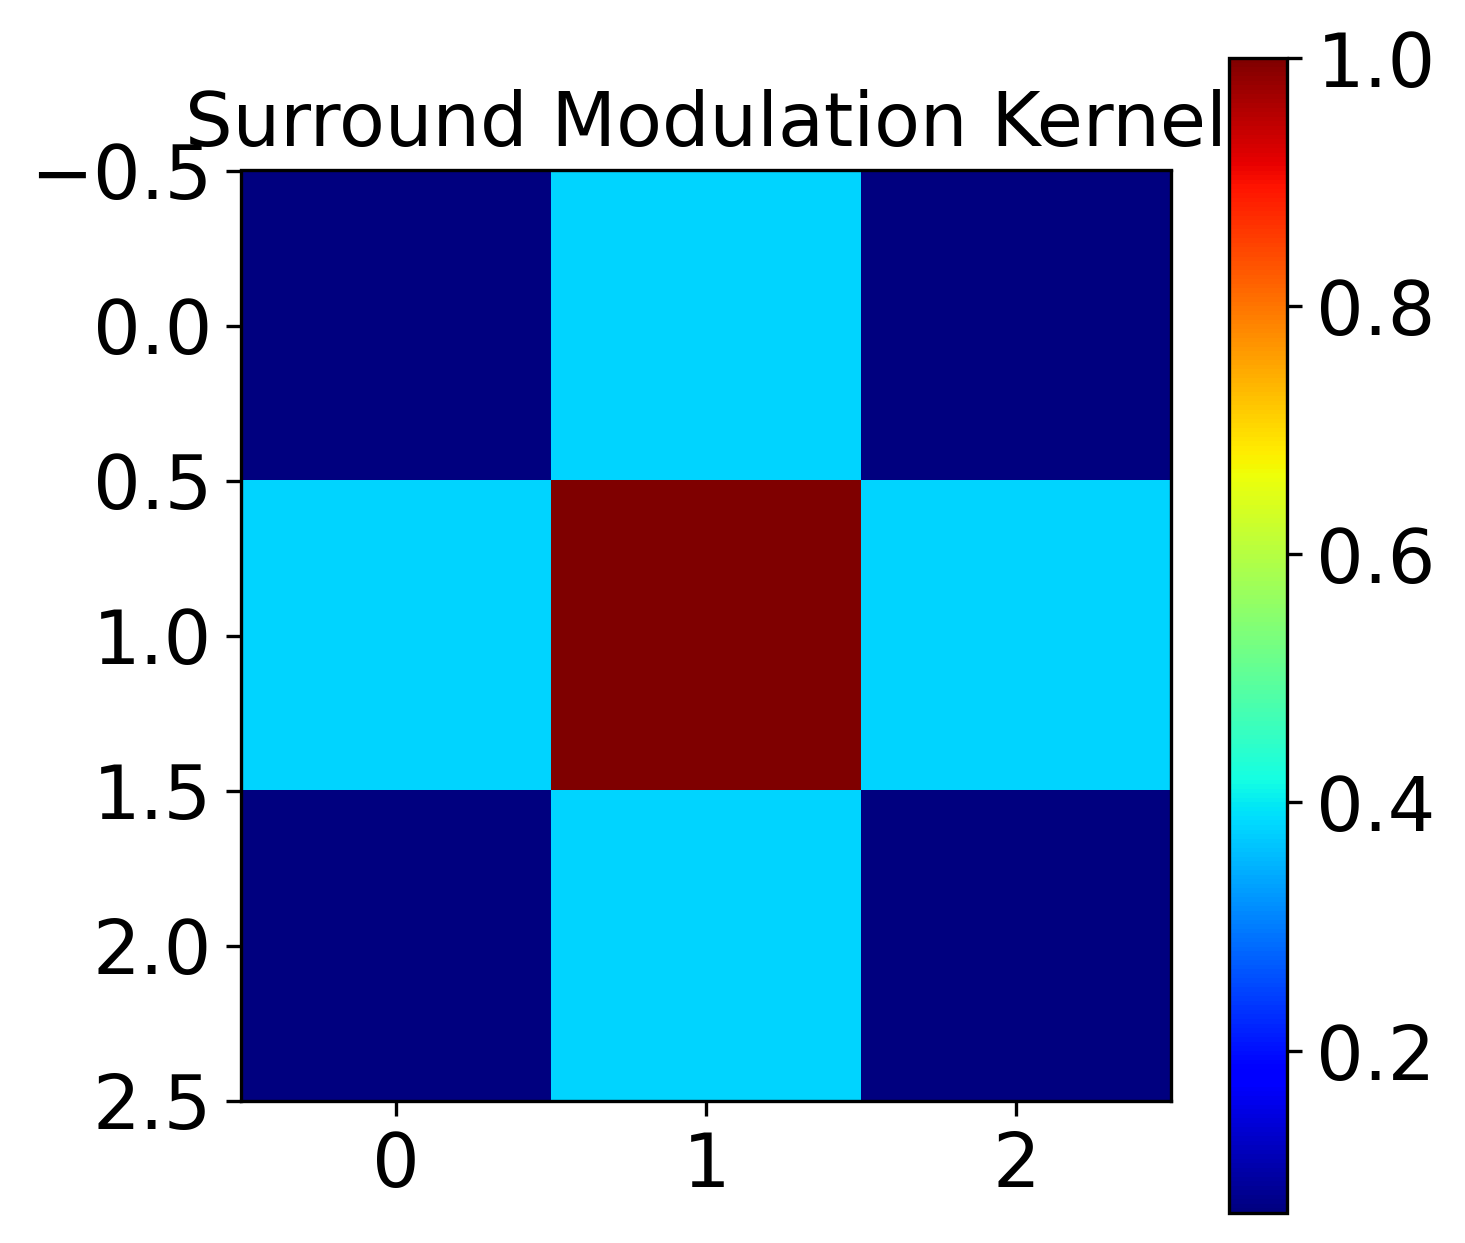

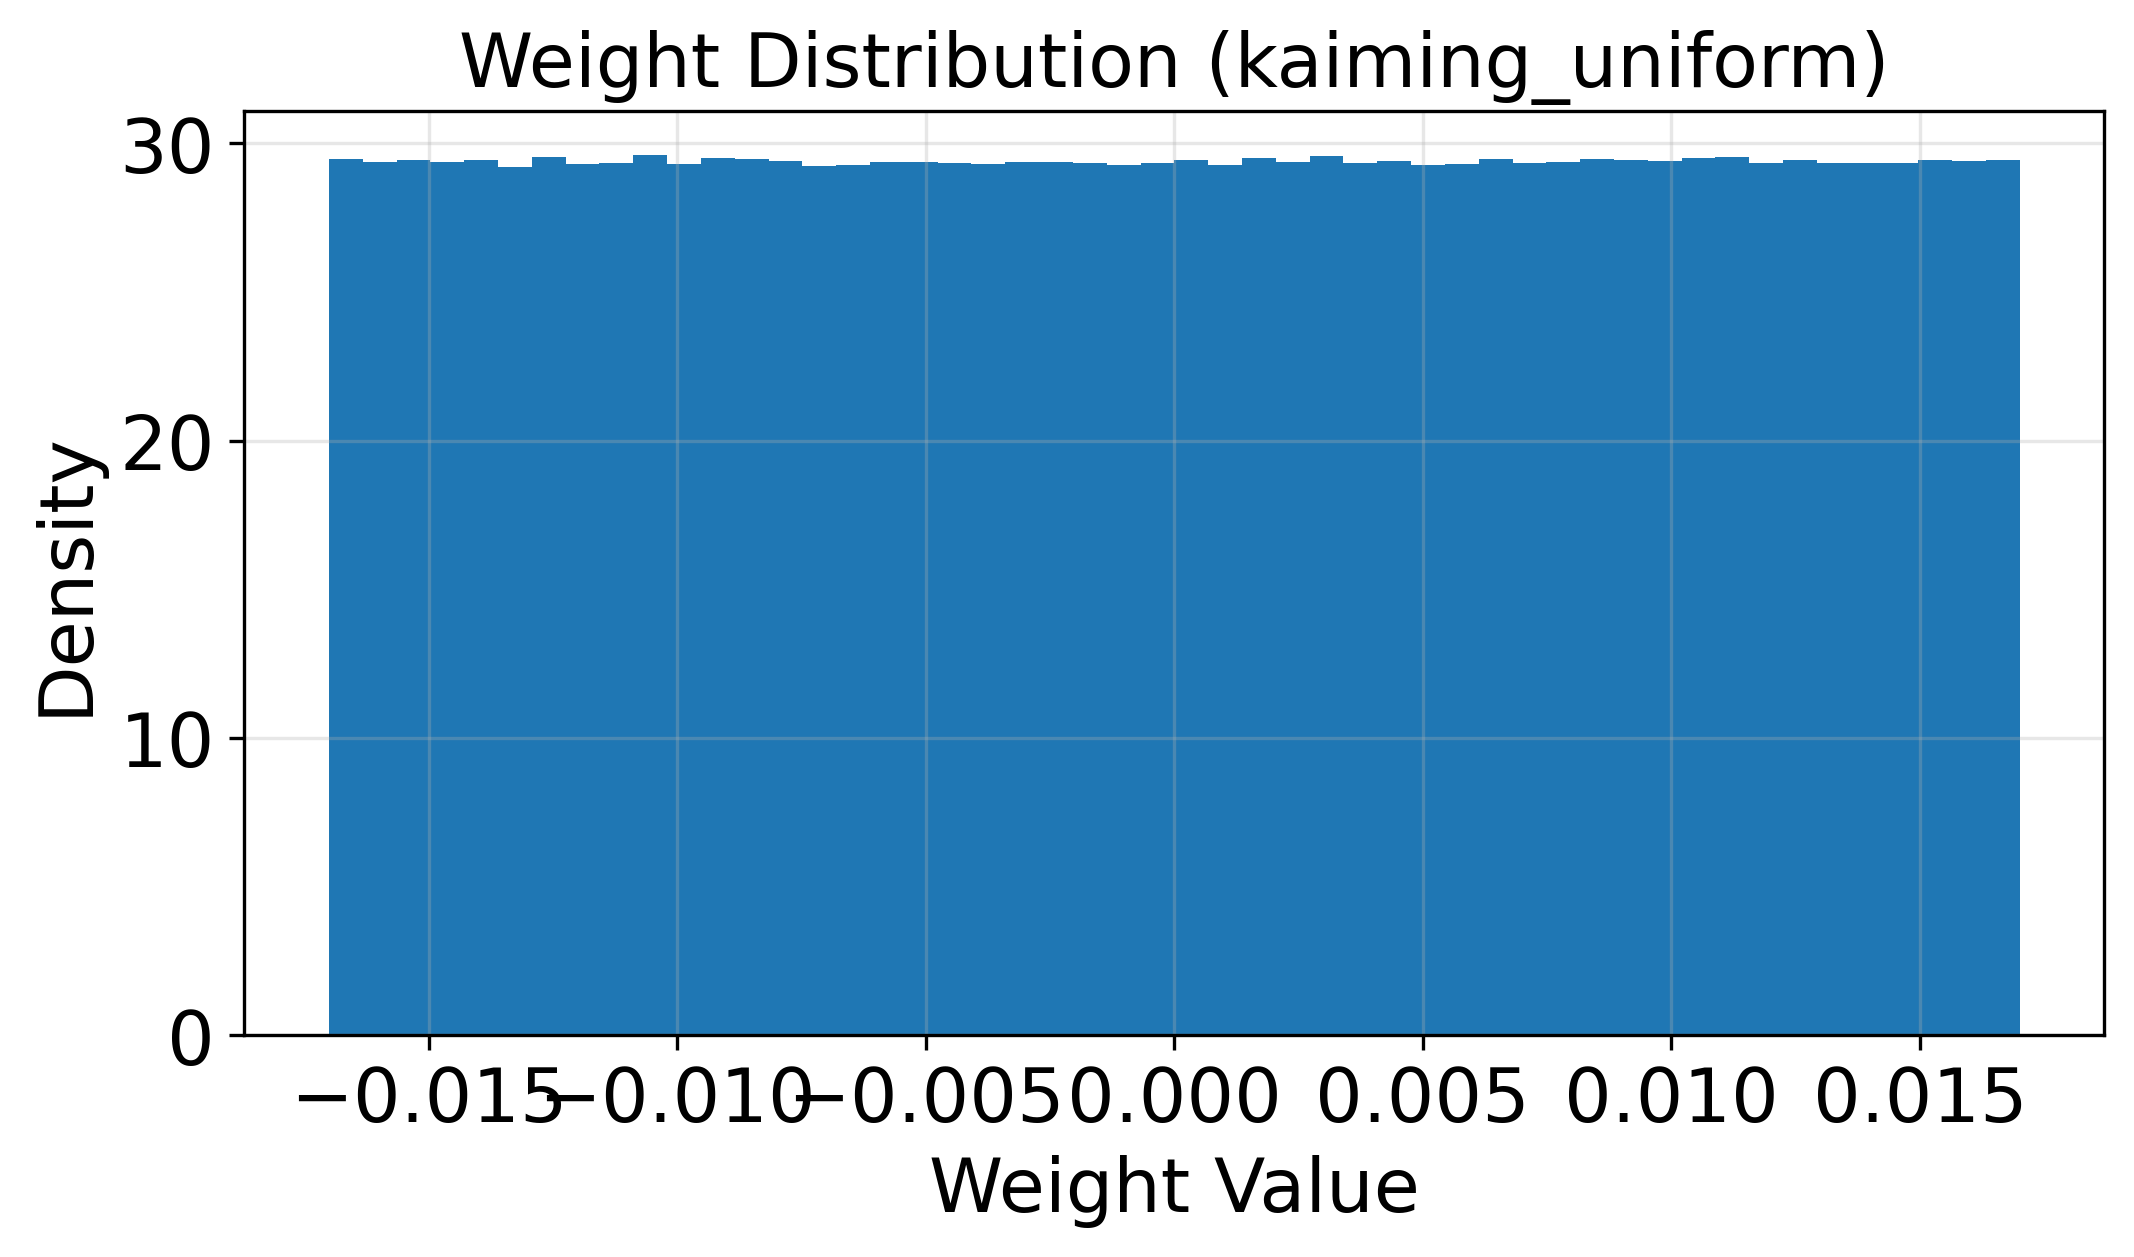

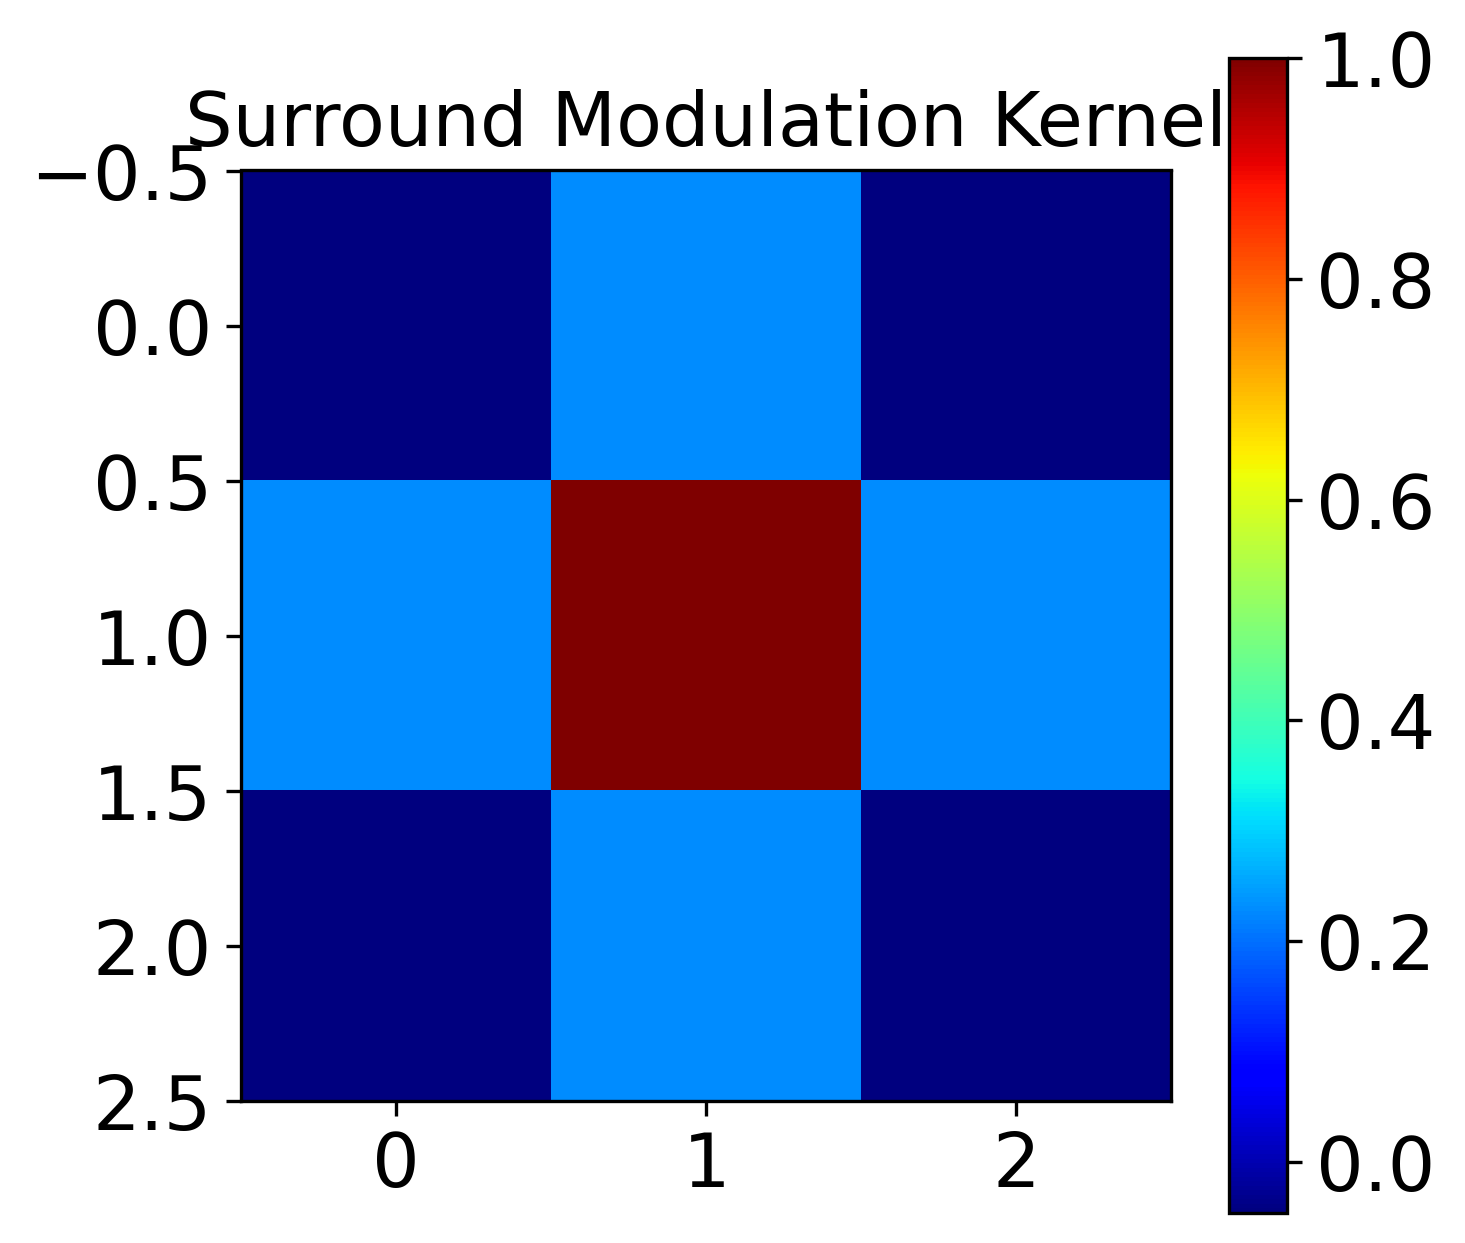

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3209 | Train Acc: 53.90% | Test Loss: 1.0562 | Test Acc: 63.50% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0415 | Train Acc: 63.80% | Test Loss: 0.9518 | Test Acc: 66.95% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9685 | Train Acc: 66.31% | Test Loss: 0.9087 | Test Acc: 68.27% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9266 | Train Acc: 67.88% | Test Loss: 0.8636 | Test Acc: 70.08% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9002 | Train Acc: 68.86% | Test Loss: 0.8590 | Test Acc: 70.27% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8785 | Train Acc: 69.47% | Test Loss: 0.8392 | Test Acc: 70.73% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8642 | Train Acc: 70.08% | Test Loss: 0.8308 | Test Acc: 71.42% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8593 | Train Acc: 69.99% | Test Loss: 0.8283 | Test Acc: 71.73% | LR: 0.001000
Epoch [9/2

In [ ]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")


   
    set_seed(seed)

    #fresh model

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [44]:
all_histories

{0: {'train_loss': [1.3208522814941406,
   1.0414635470962526,
   0.9684924629592896,
   0.9266442039299011,
   0.9002052894973754,
   0.8785077830696106,
   0.864224251537323,
   0.8592674514579773,
   0.8430757111358642,
   0.83348287940979,
   0.8382120342254639,
   0.8230803774642944,
   0.7810569947814942,
   0.774855376701355,
   0.7591355406188964,
   0.7523836577224732,
   0.7390910371017456,
   0.7396258999443054,
   0.732274489955902,
   0.7290912915802001],
  'train_accuracy': [53.9,
   63.8,
   66.312,
   67.876,
   68.862,
   69.468,
   70.082,
   69.994,
   70.898,
   71.29,
   71.16,
   71.54,
   72.946,
   73.336,
   73.622,
   73.982,
   74.32,
   74.474,
   74.784,
   74.554],
  'test_loss': [1.0562220279693604,
   0.9517595216751099,
   0.9086573139190673,
   0.8635654076576232,
   0.8589652419090271,
   0.8391552341461181,
   0.8307799953460694,
   0.8283476650238037,
   0.8982768812179566,
   0.8065577233314514,
   0.8119003596305847,
   0.824047052192688,
   0.805

In [43]:
all_histories[0]['test_accuracy']

[63.5,
 66.95,
 68.27,
 70.08,
 70.27,
 70.73,
 71.42,
 71.73,
 69.06,
 72.38,
 71.96,
 71.4,
 72.01,
 72.98,
 73.13,
 73.05,
 73.45,
 73.64,
 73.55,
 73.49]

### Test performance for the first seed is marginally worse off (not significantly changed, but it is better practise for statistics used in data-preprocessing to omit information from the test set), 
### these are the previously found test accuracies for seed=0
63.65	67.28	68.99	69.83	70.38	70.73	71.66	71.89	69.08	72.12	71.43	71.6	72.51	73.3	73.3	73.84	73.8	73.69

# Removing the random flipping at test time (using the zca computed on the train set only)
### To me it doesn't make sense to evaluate the test set with random horizontal flips (and perhaps the researchers didn't do so for the results printed in their paper, yet as far as their code repository is concerned, they appear to include random flips at test time)

In [ ]:
valid_test_transform = transforms.Compose([
    transforms.ToTensor(),
])

valid_test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=valid_test_transform
)

test_loader = torch.utils.data.DataLoader(
    valid_test_dataset,
    batch_size=64,
    shuffle=True, #shuffling the test set is not necessary either, but I will keep it for reproducability of the previous 5 runs 
    num_workers=2
)

In [46]:

seeds = [0,1,2,3,4]
all_histories = {}

RUN 1/ 5 | SEED = 0
Building SoftHebb model


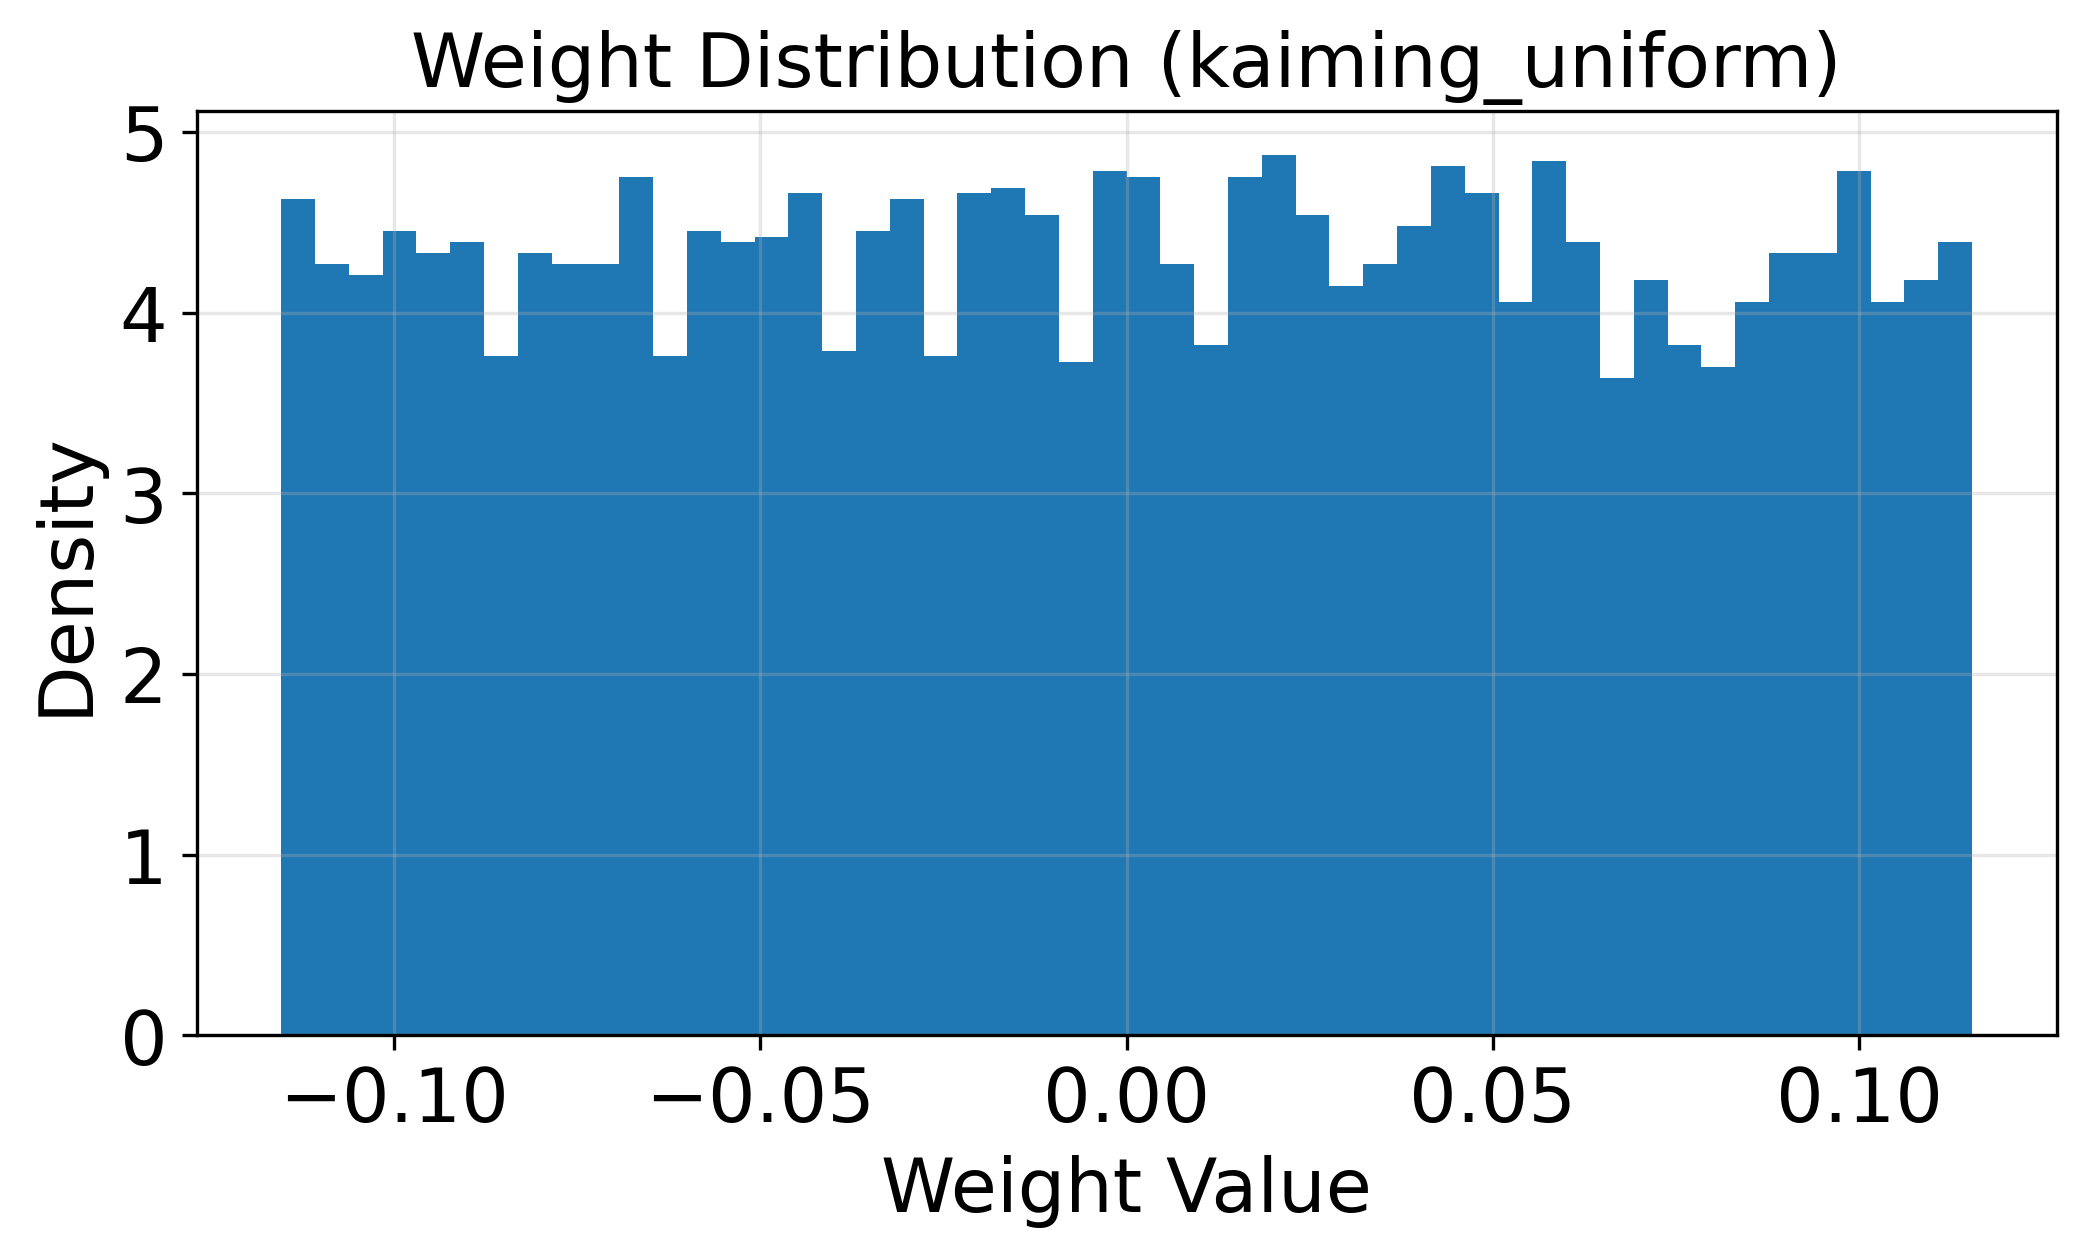

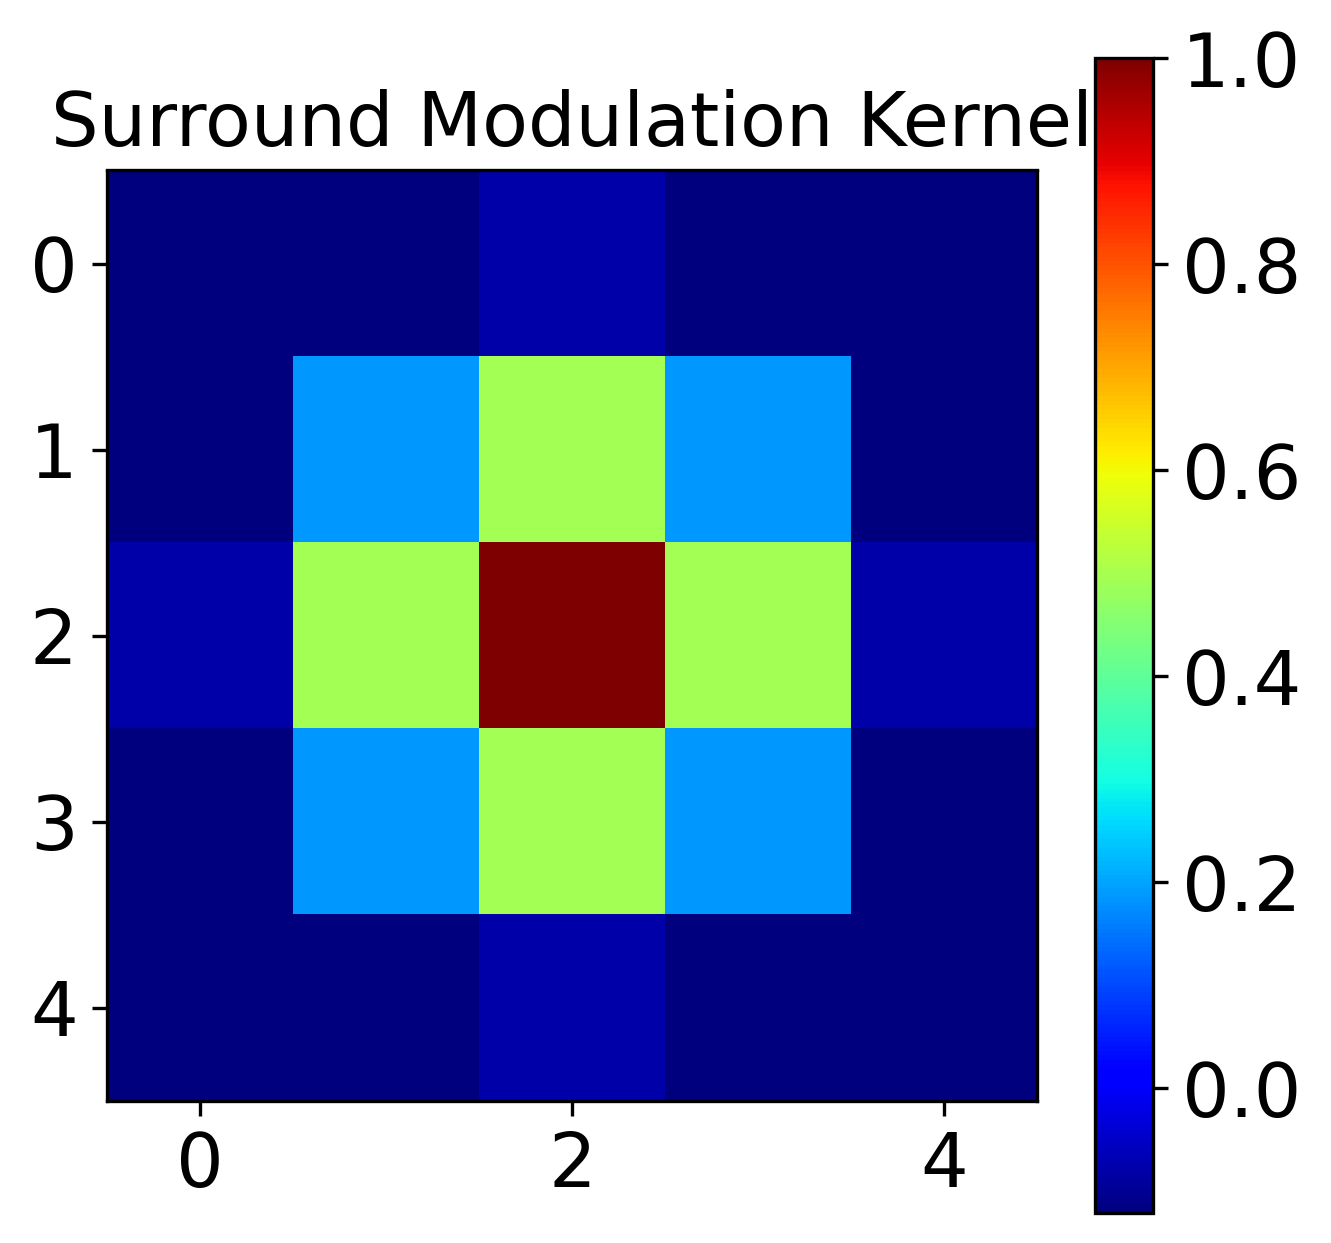

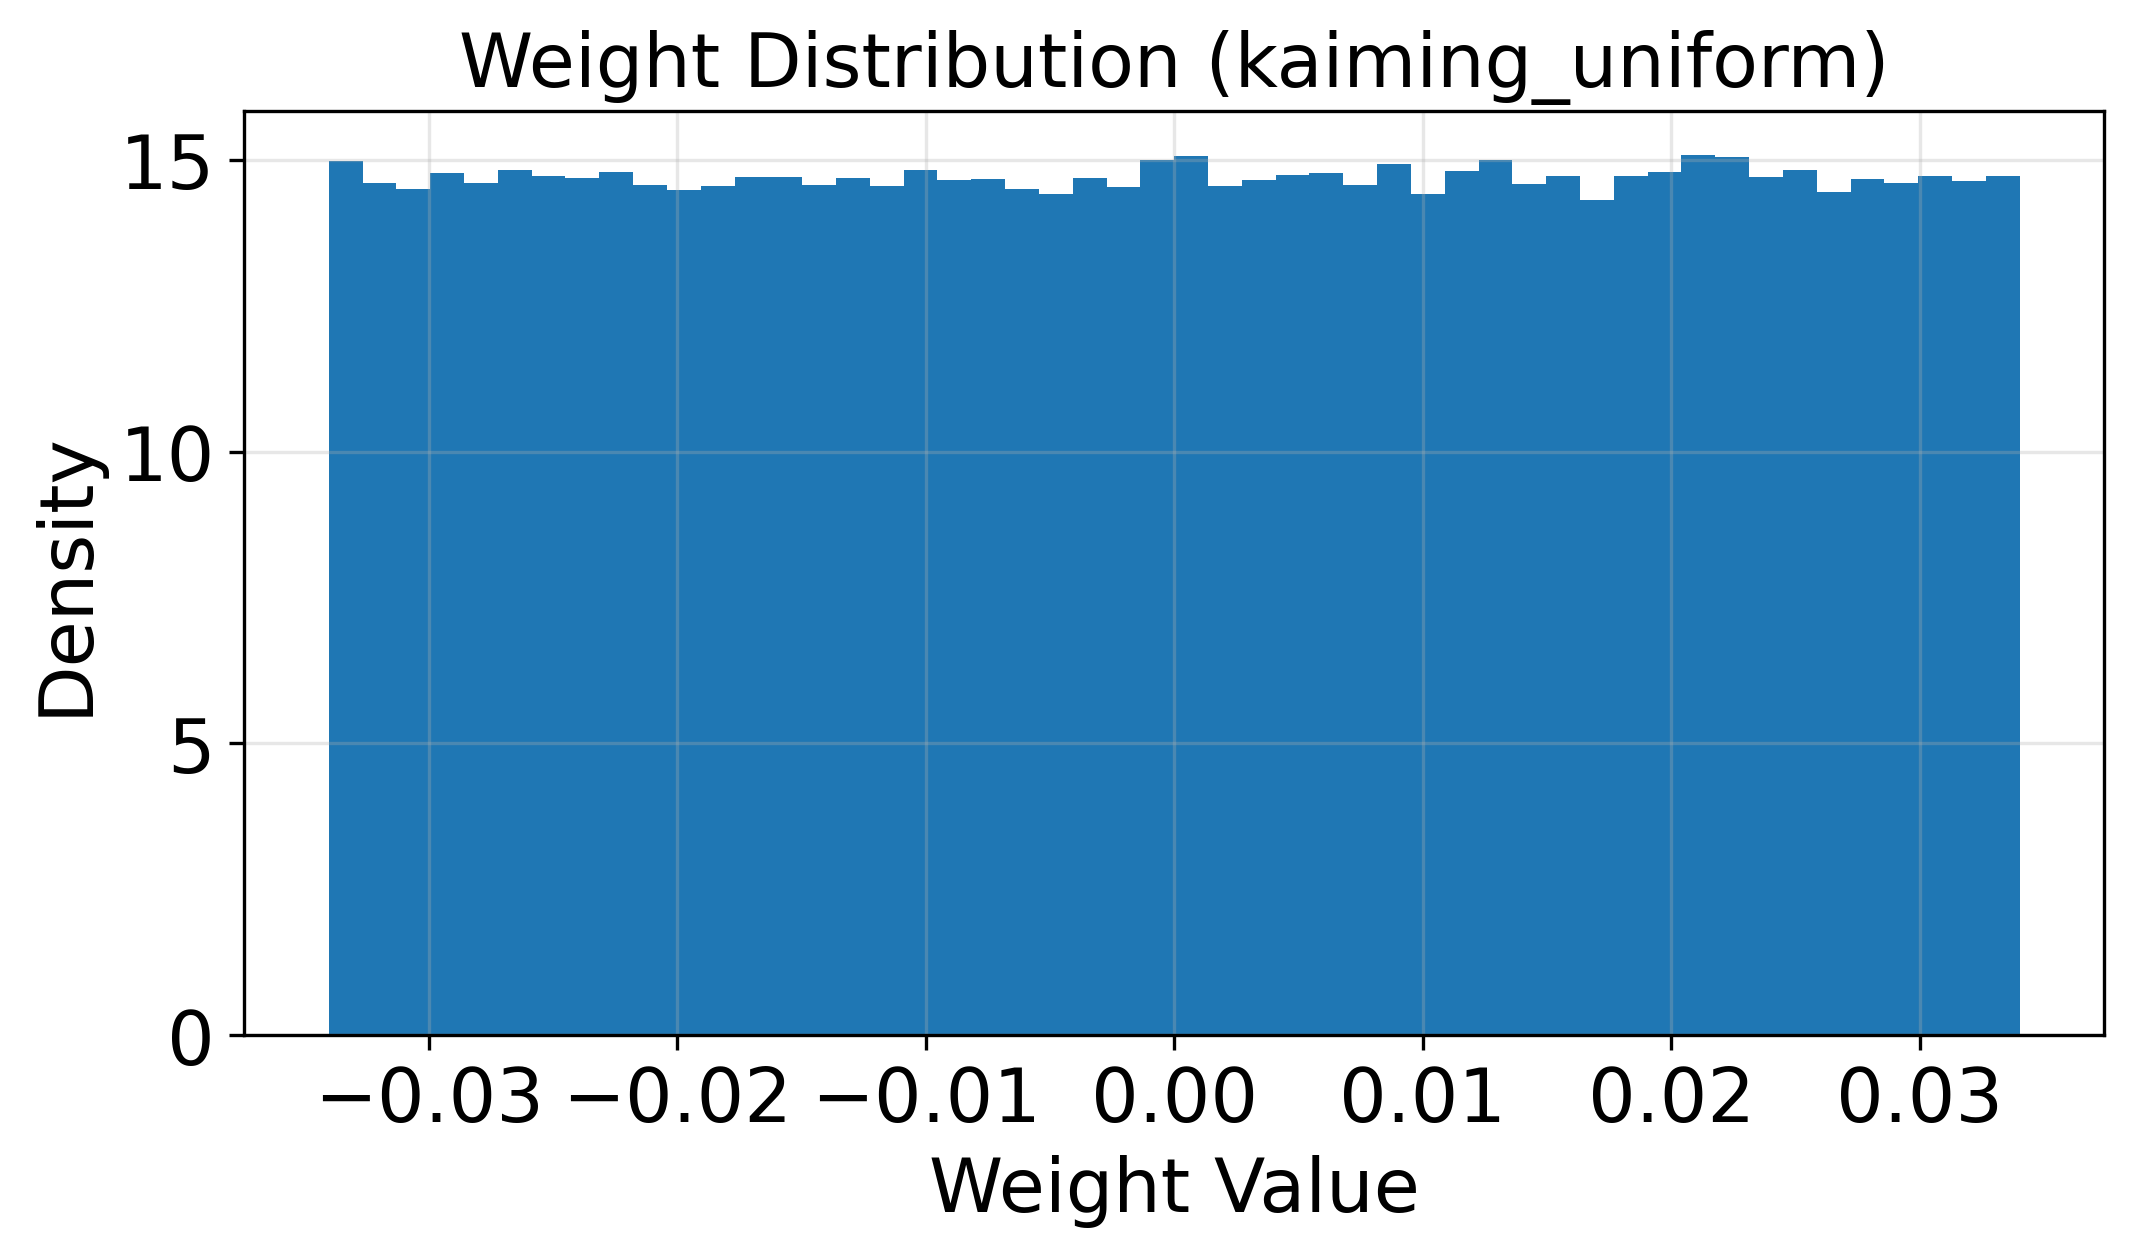

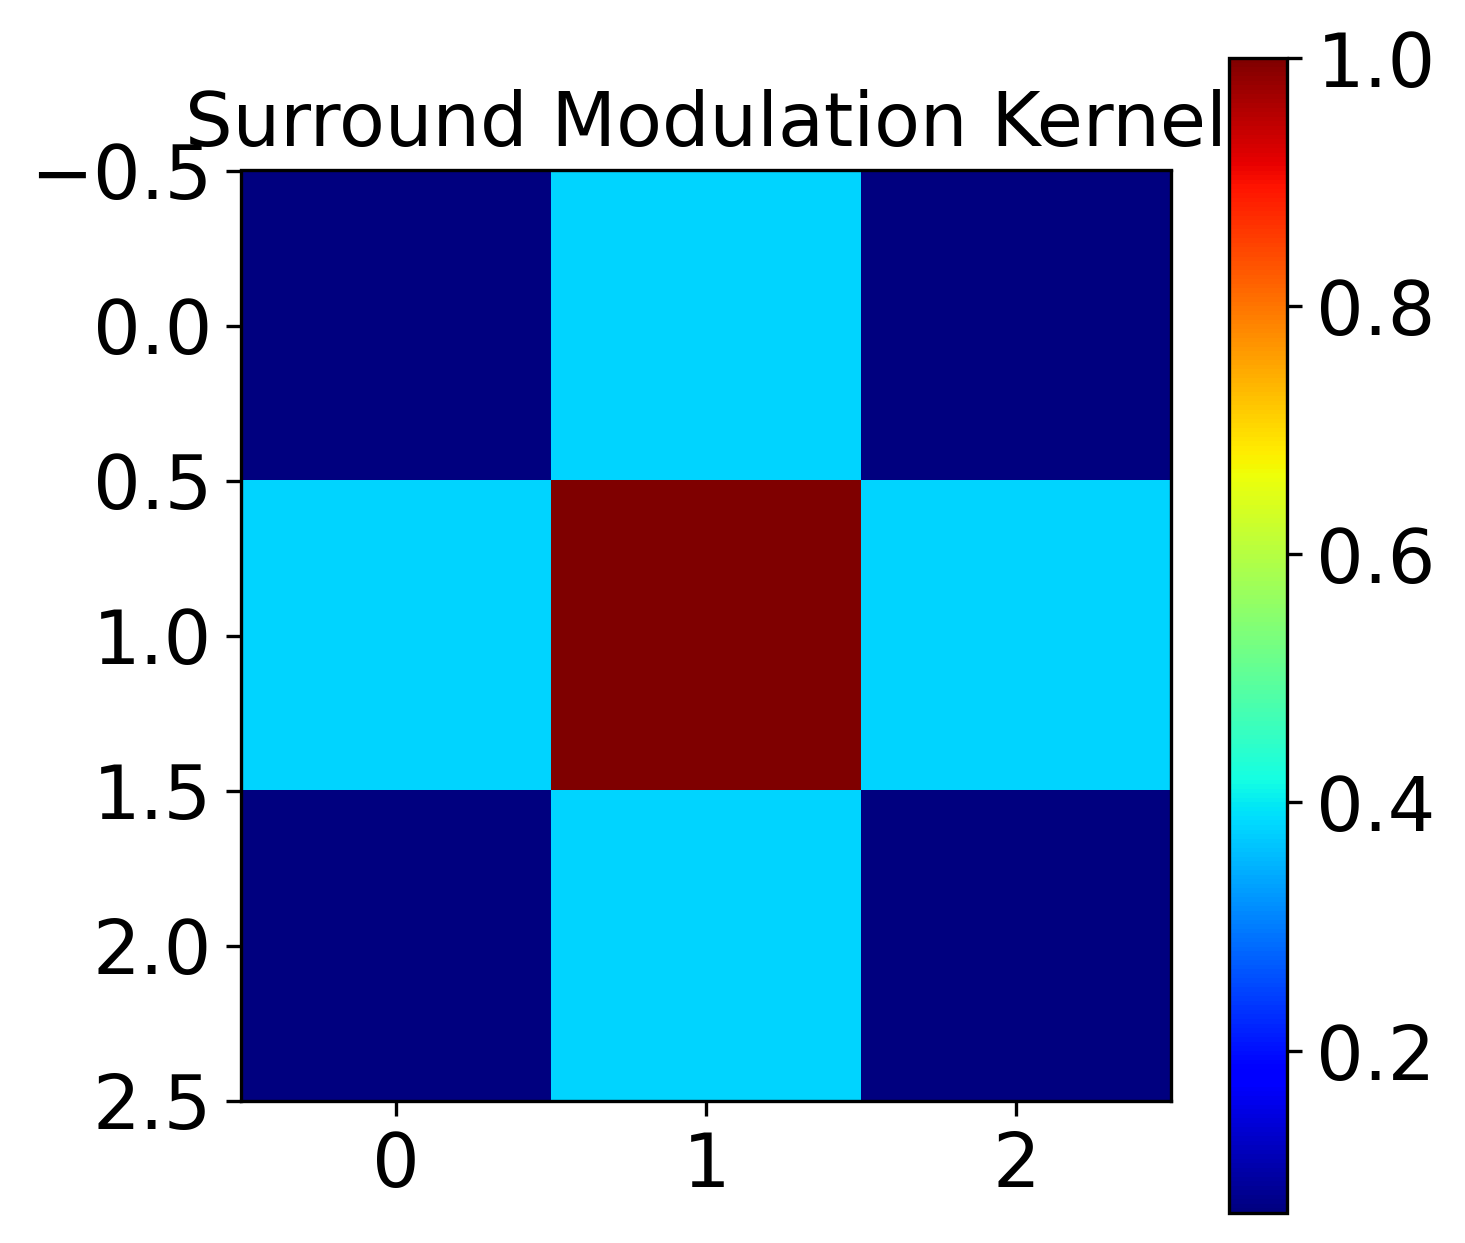

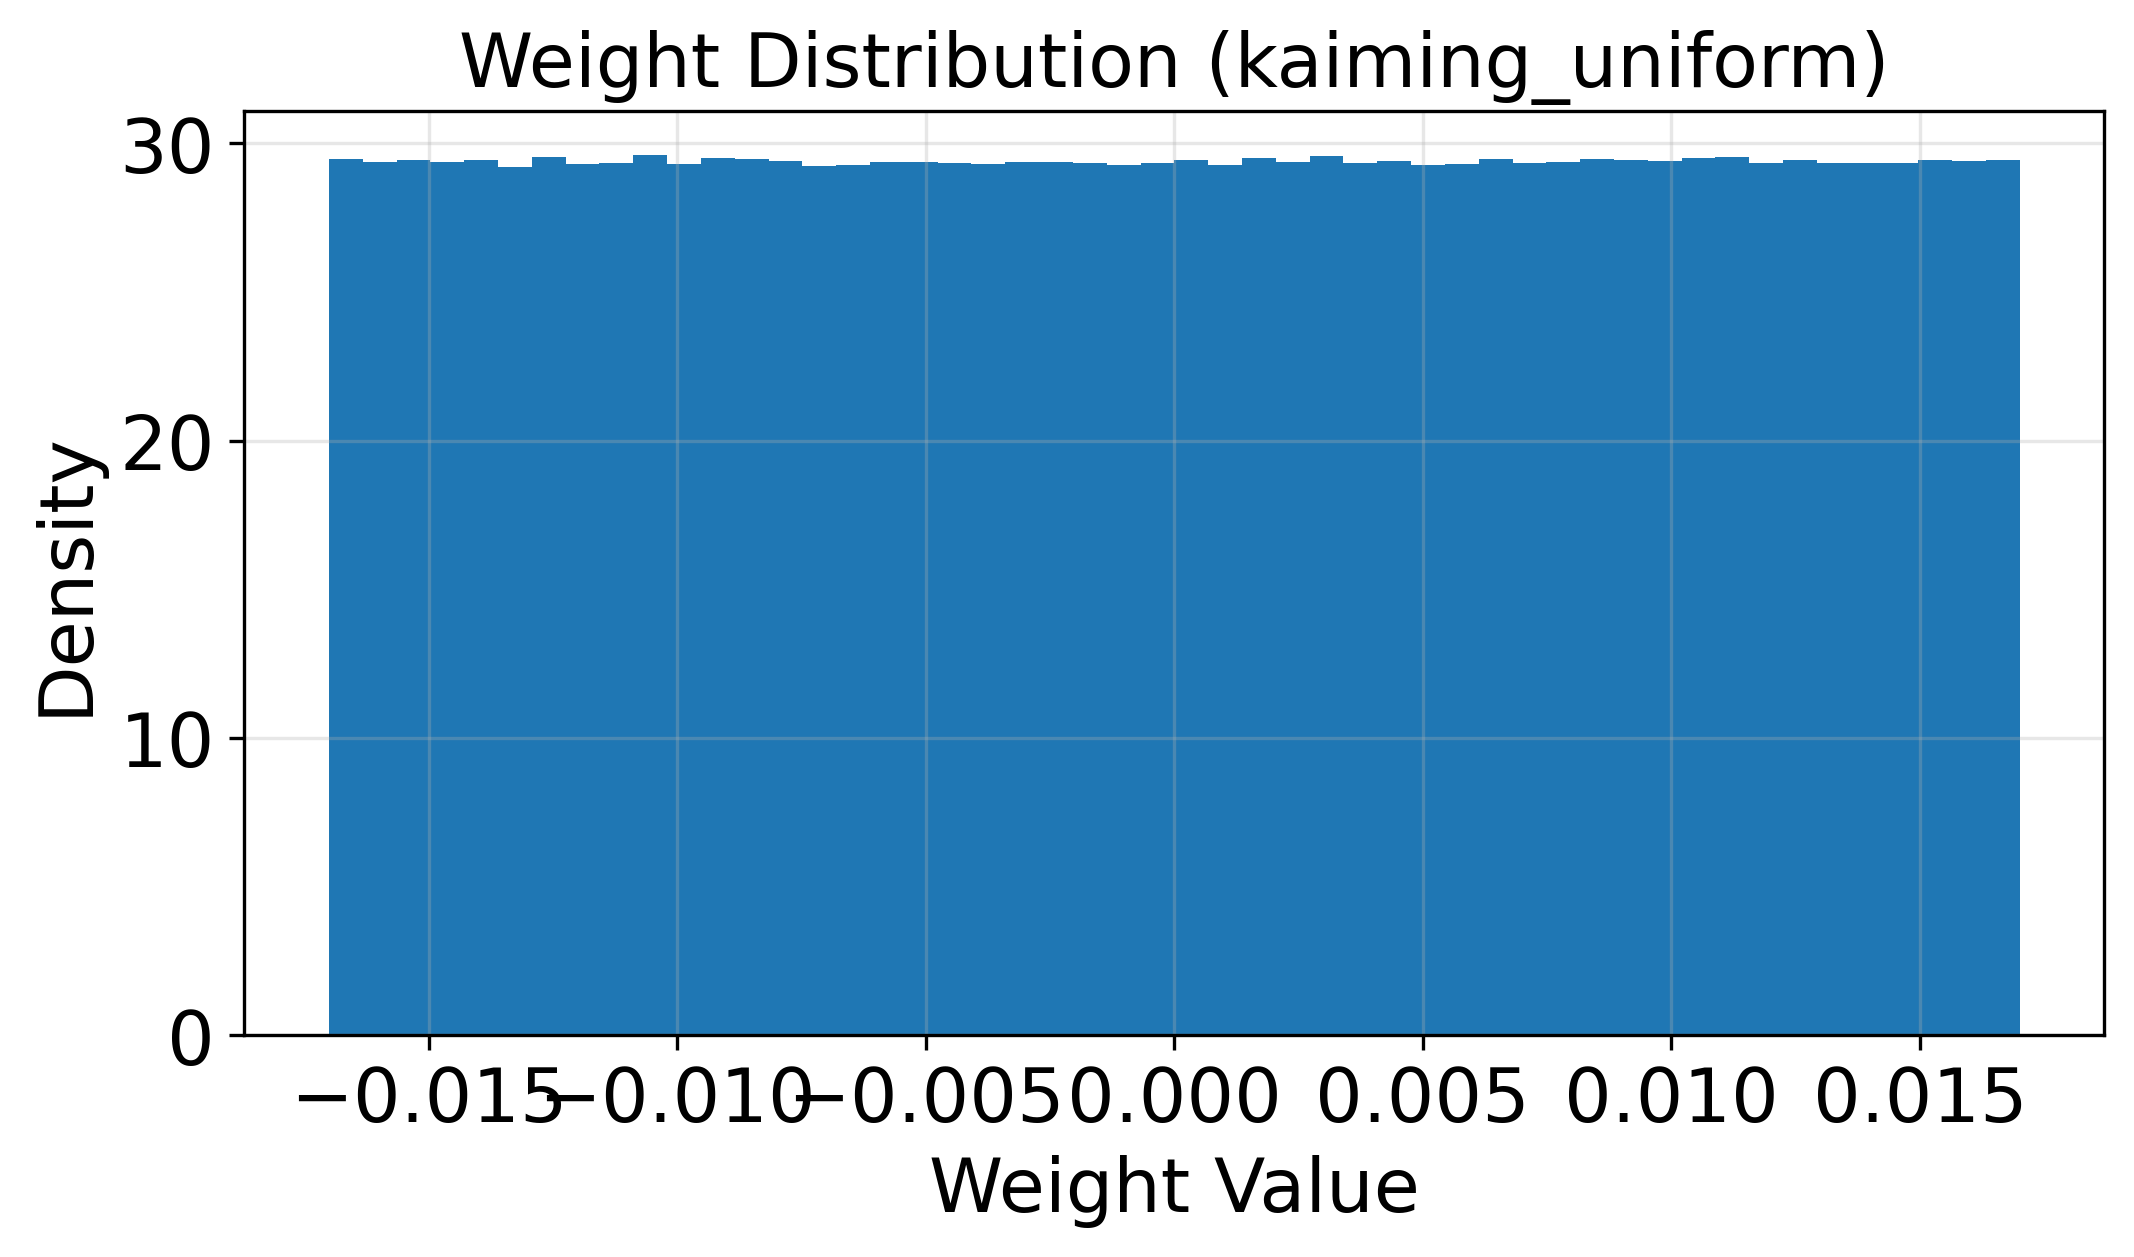

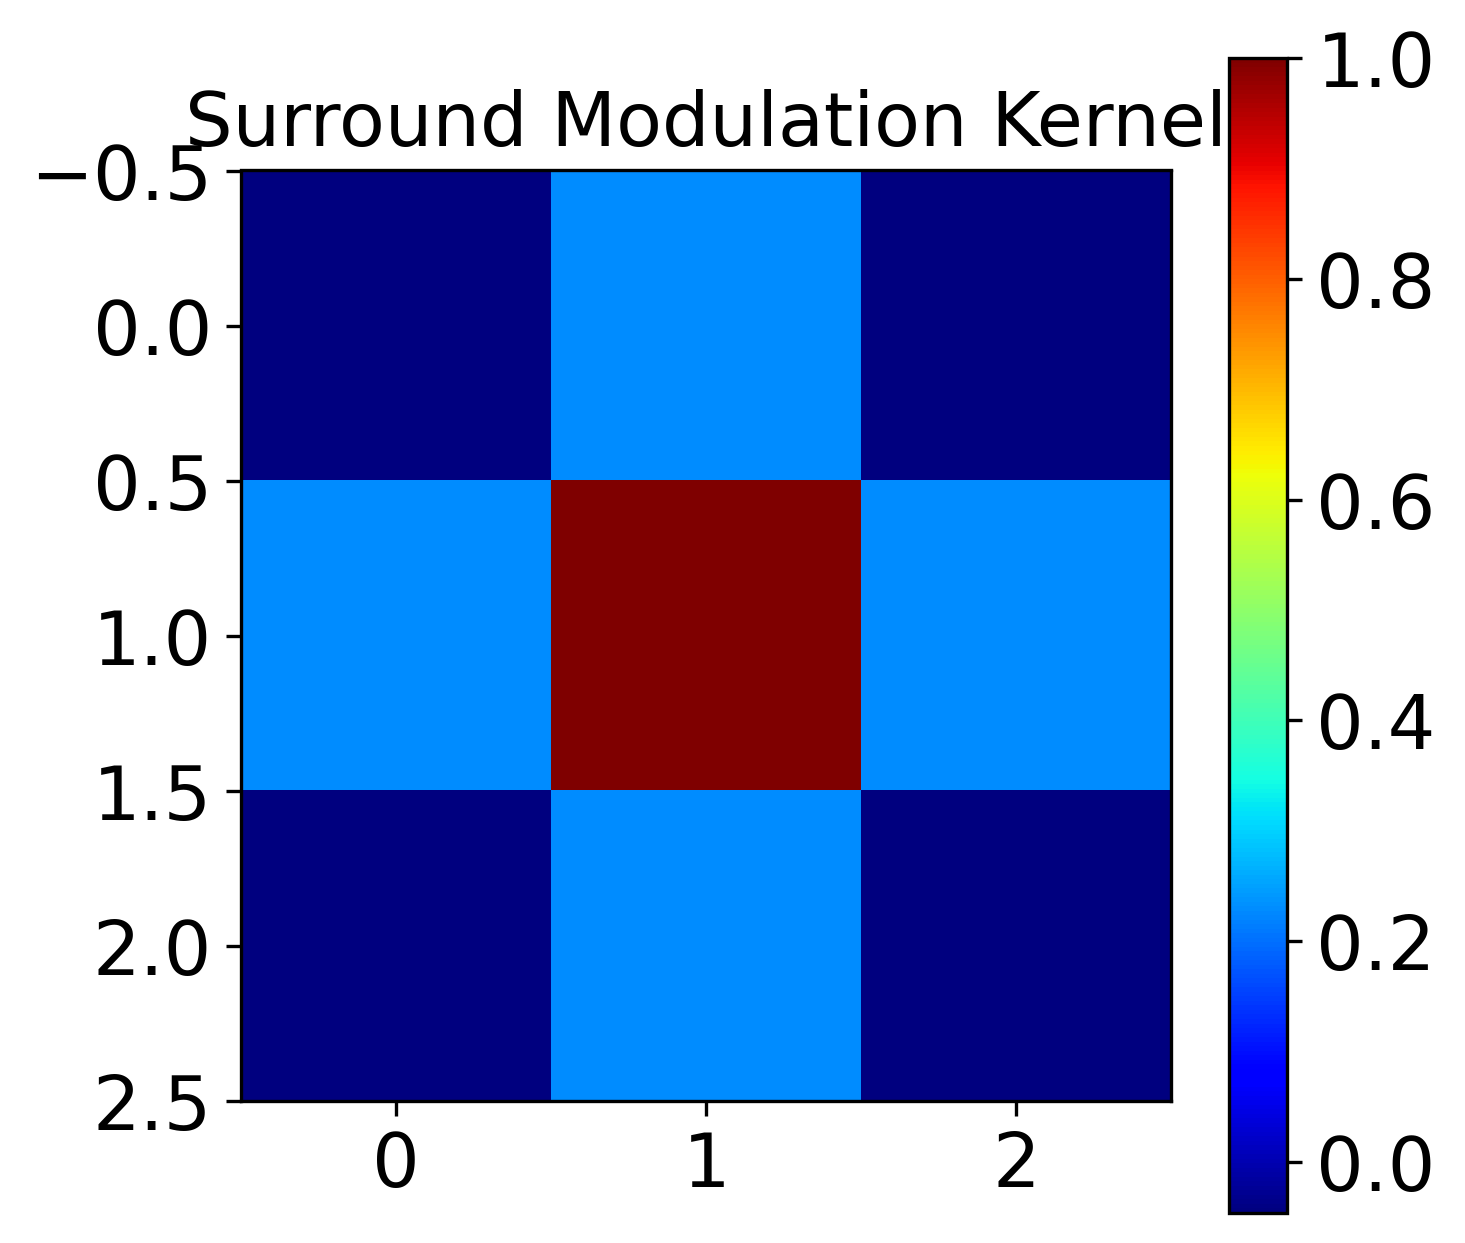

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3209 | Train Acc: 53.90% | Test Loss: 1.0541 | Test Acc: 63.44% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0415 | Train Acc: 63.80% | Test Loss: 0.9549 | Test Acc: 67.19% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9685 | Train Acc: 66.31% | Test Loss: 0.9063 | Test Acc: 68.47% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9266 | Train Acc: 67.88% | Test Loss: 0.8614 | Test Acc: 69.92% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9002 | Train Acc: 68.86% | Test Loss: 0.8588 | Test Acc: 70.34% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8785 | Train Acc: 69.47% | Test Loss: 0.8440 | Test Acc: 70.48% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8642 | Train Acc: 70.08% | Test Loss: 0.8283 | Test Acc: 71.73% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8593 | Train Acc: 69.99% | Test Loss: 0.8336 | Test Acc: 71.62% | LR: 0.001000
Epoch [9/2

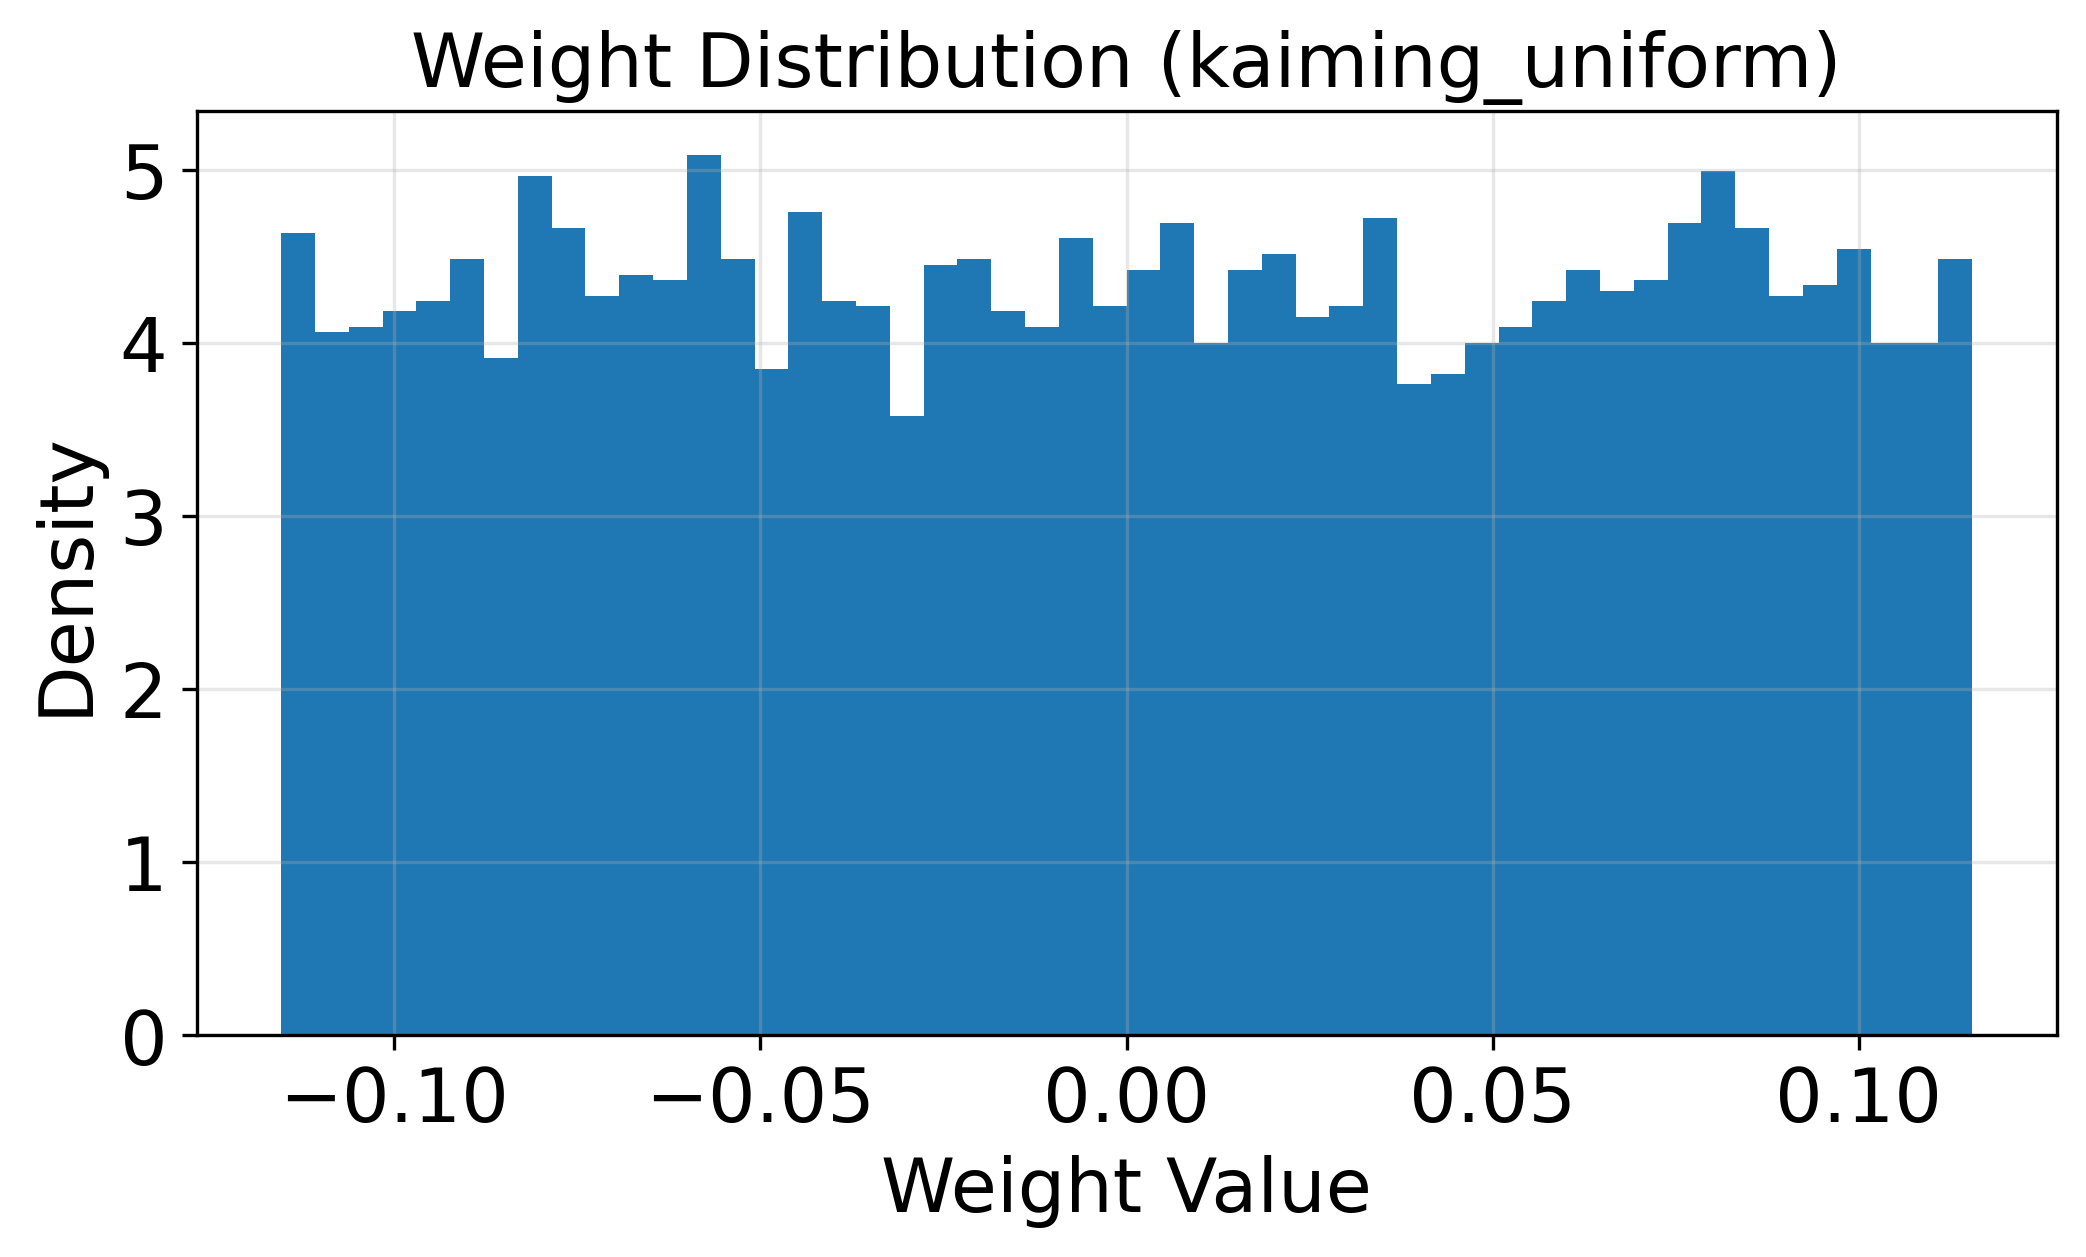

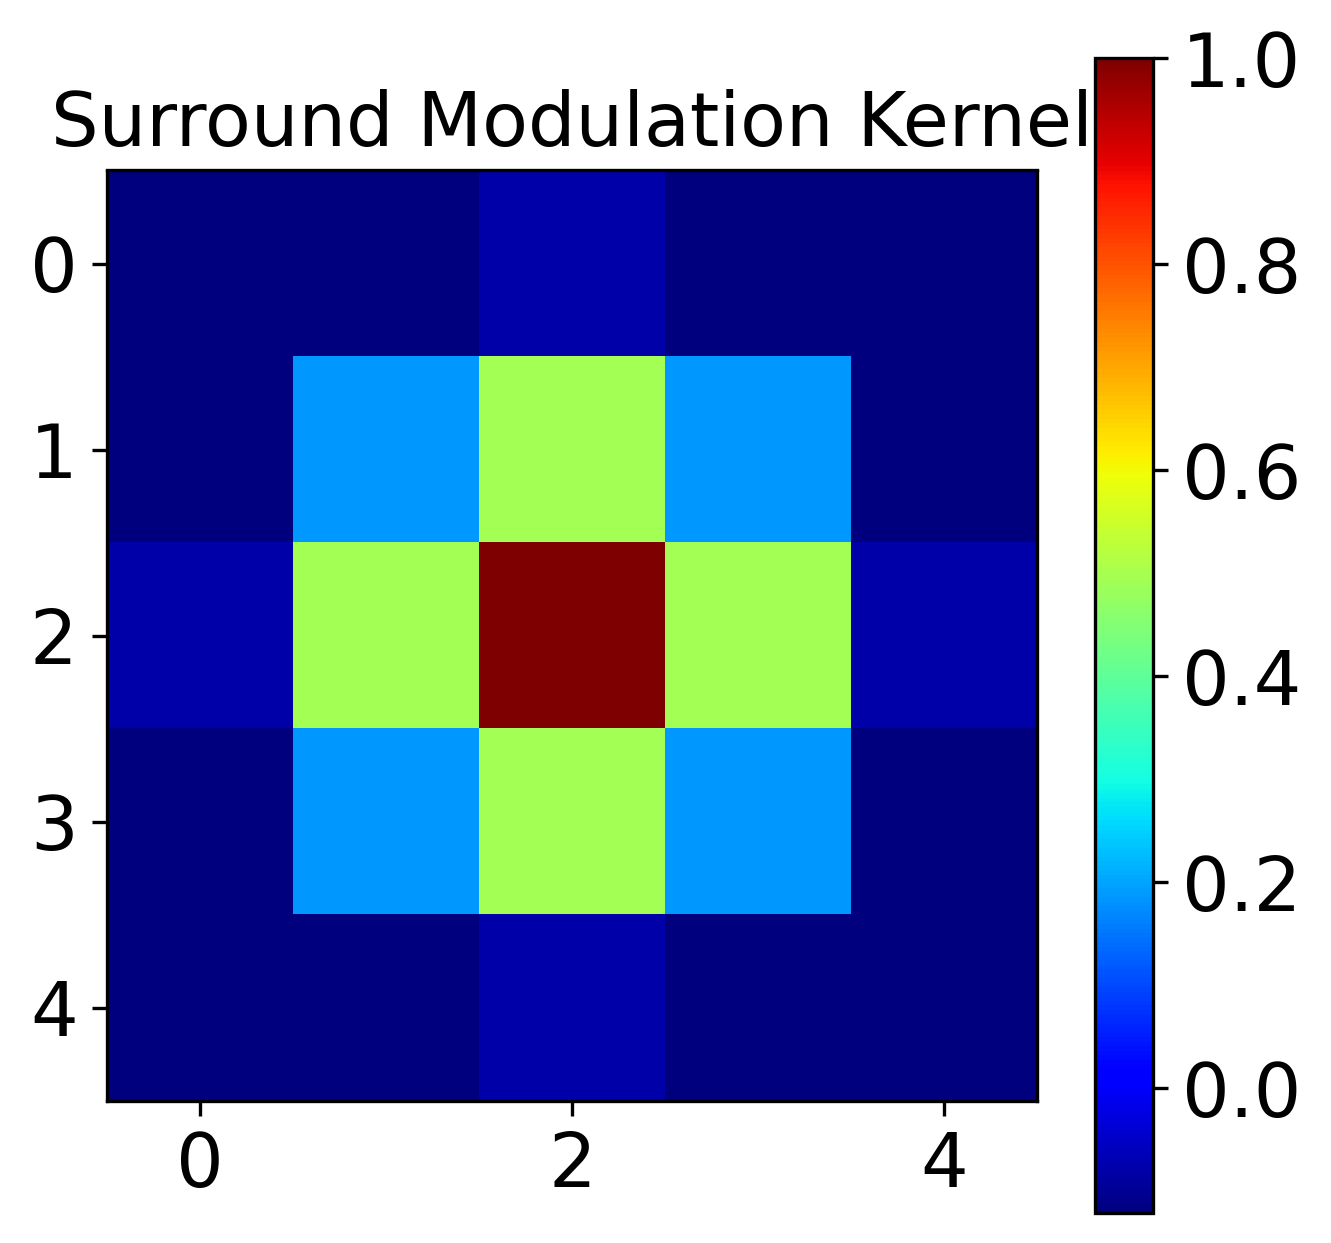

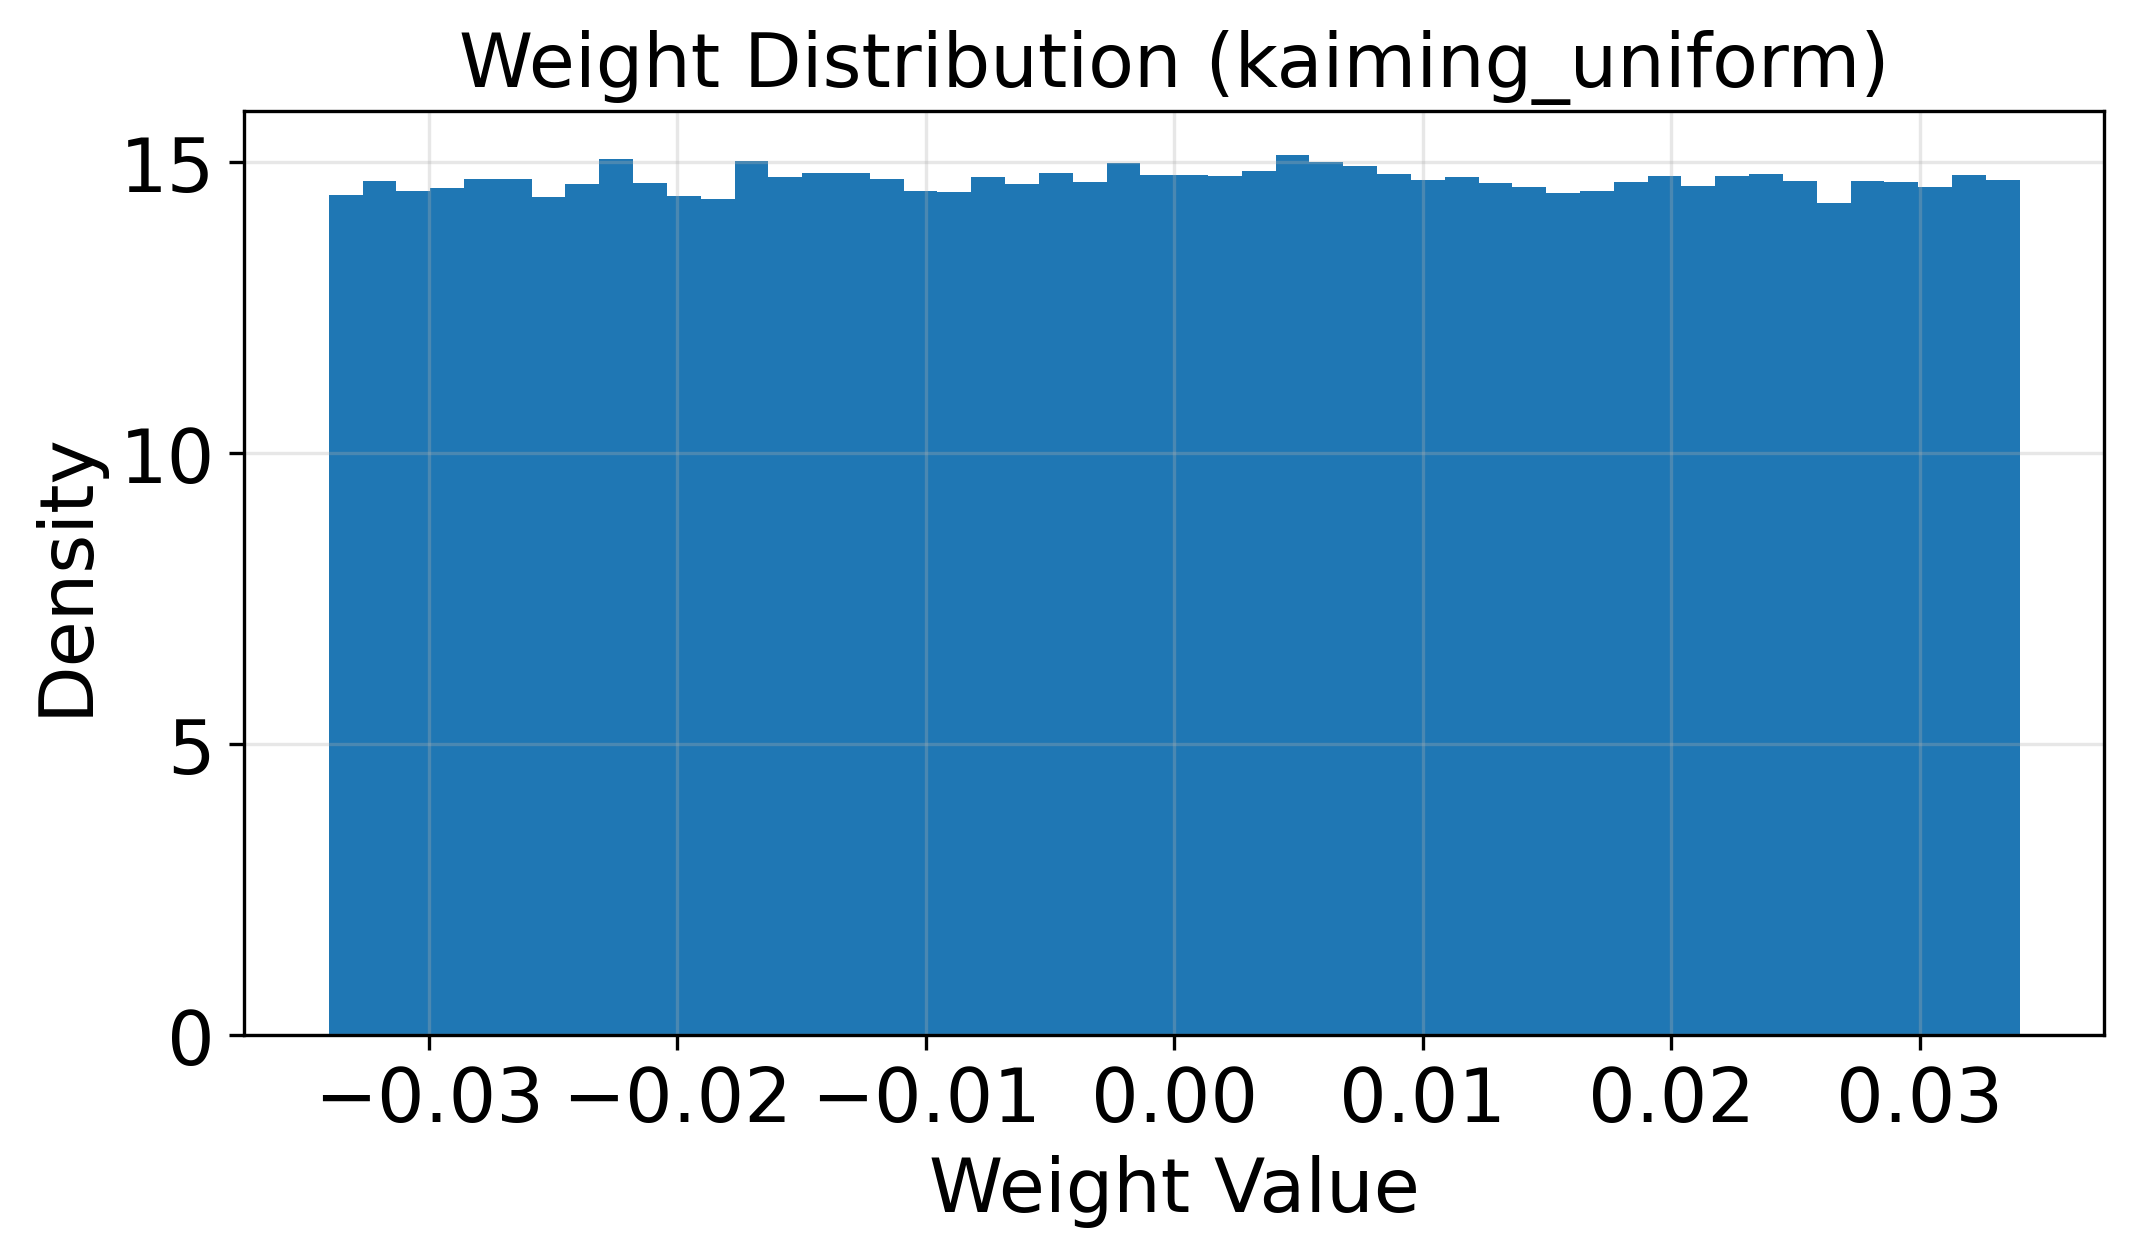

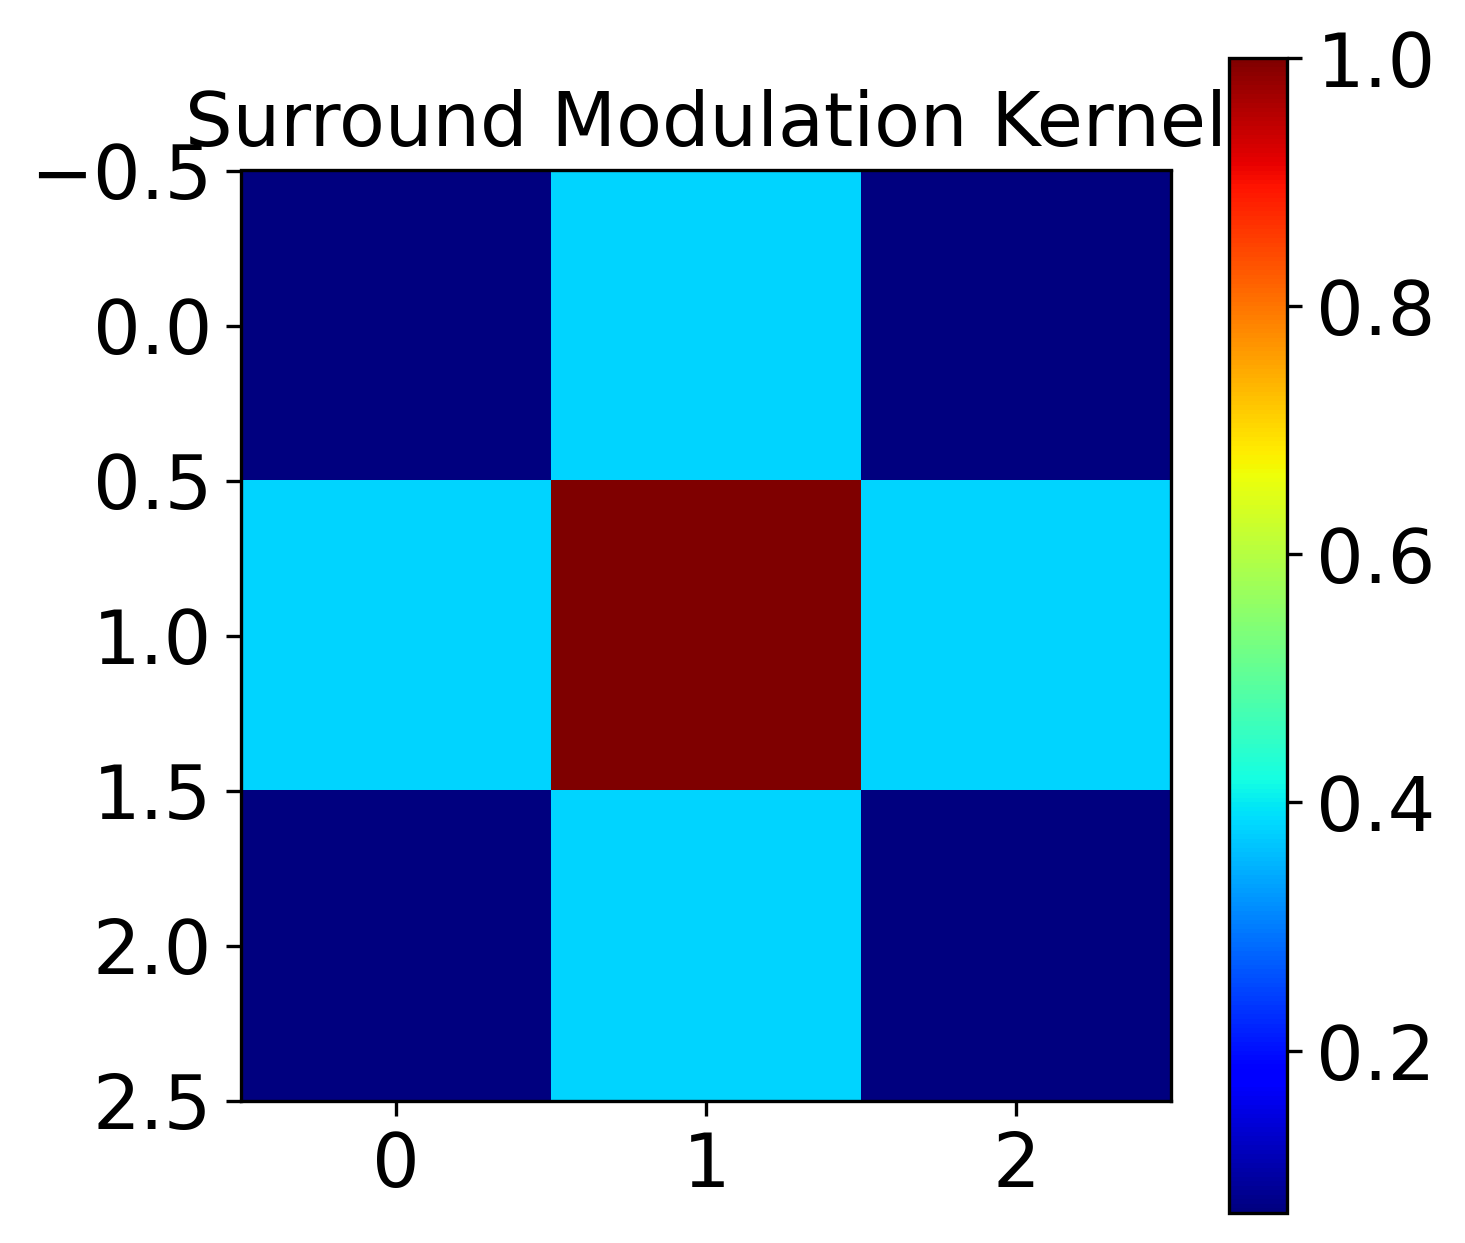

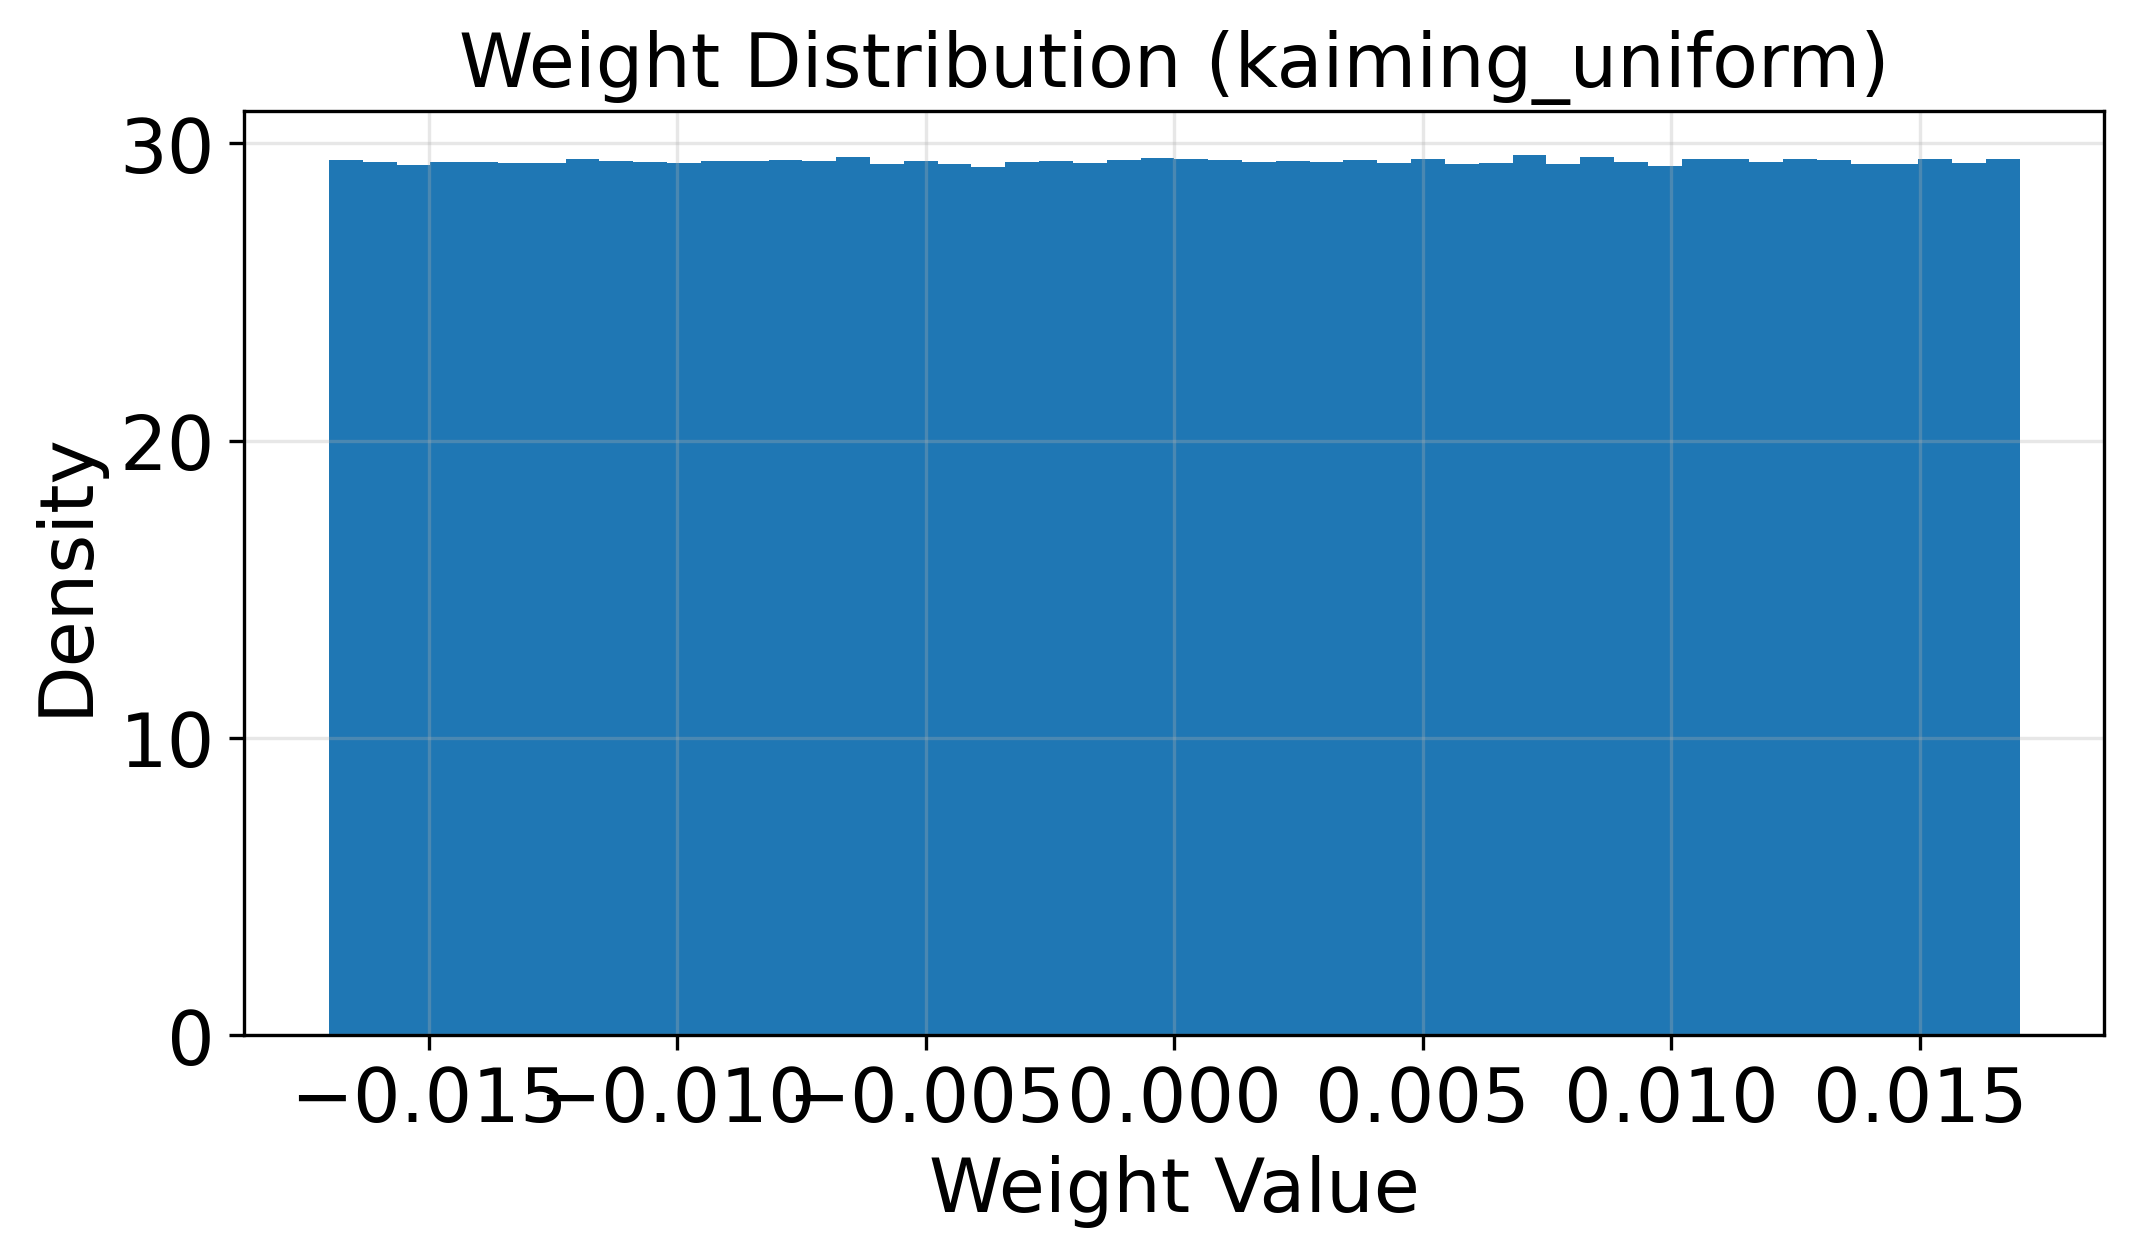

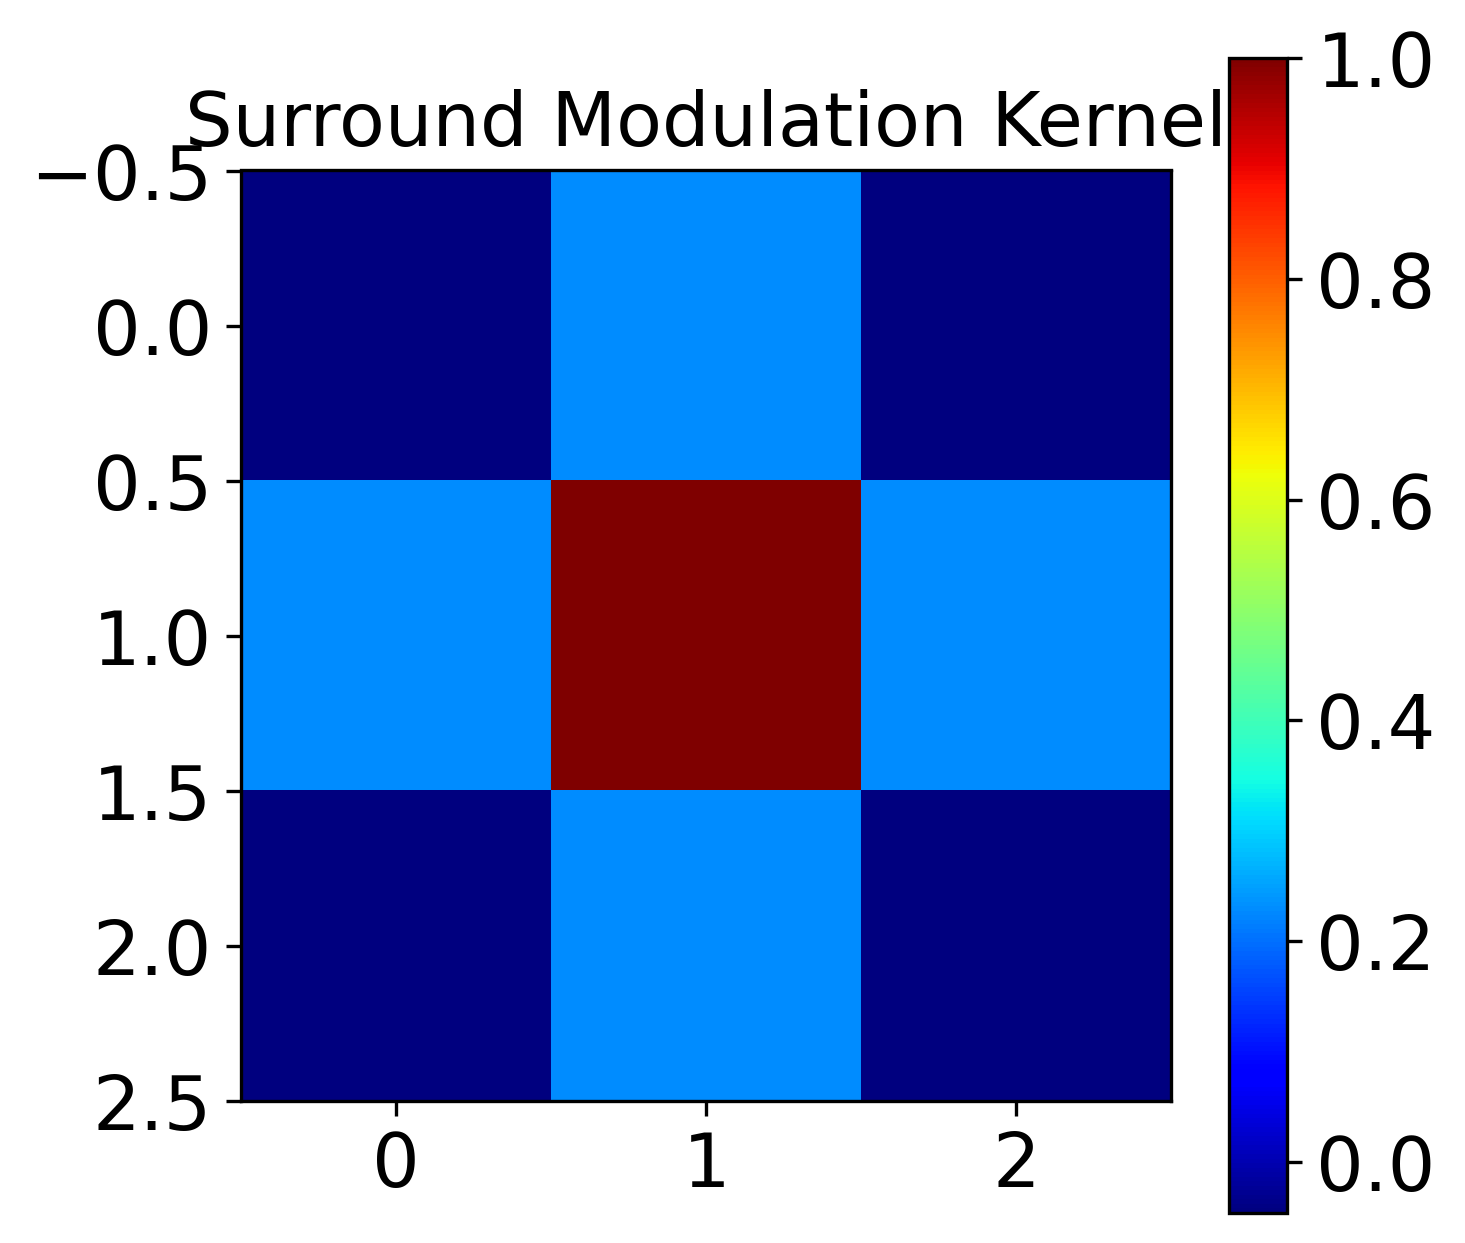

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2691 | Train Acc: 55.75% | Test Loss: 1.0066 | Test Acc: 65.49% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9980 | Train Acc: 65.75% | Test Loss: 0.9411 | Test Acc: 67.44% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9282 | Train Acc: 68.10% | Test Loss: 0.8842 | Test Acc: 69.27% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8880 | Train Acc: 69.24% | Test Loss: 0.8508 | Test Acc: 70.47% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8624 | Train Acc: 70.20% | Test Loss: 0.8321 | Test Acc: 71.69% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8425 | Train Acc: 70.81% | Test Loss: 0.8469 | Test Acc: 70.35% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8240 | Train Acc: 71.66% | Test Loss: 0.8222 | Test Acc: 71.66% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8113 | Train Acc: 71.85% | Test Loss: 0.8152 | Test Acc: 71.61% | LR: 0.001000
Epoch [9/2

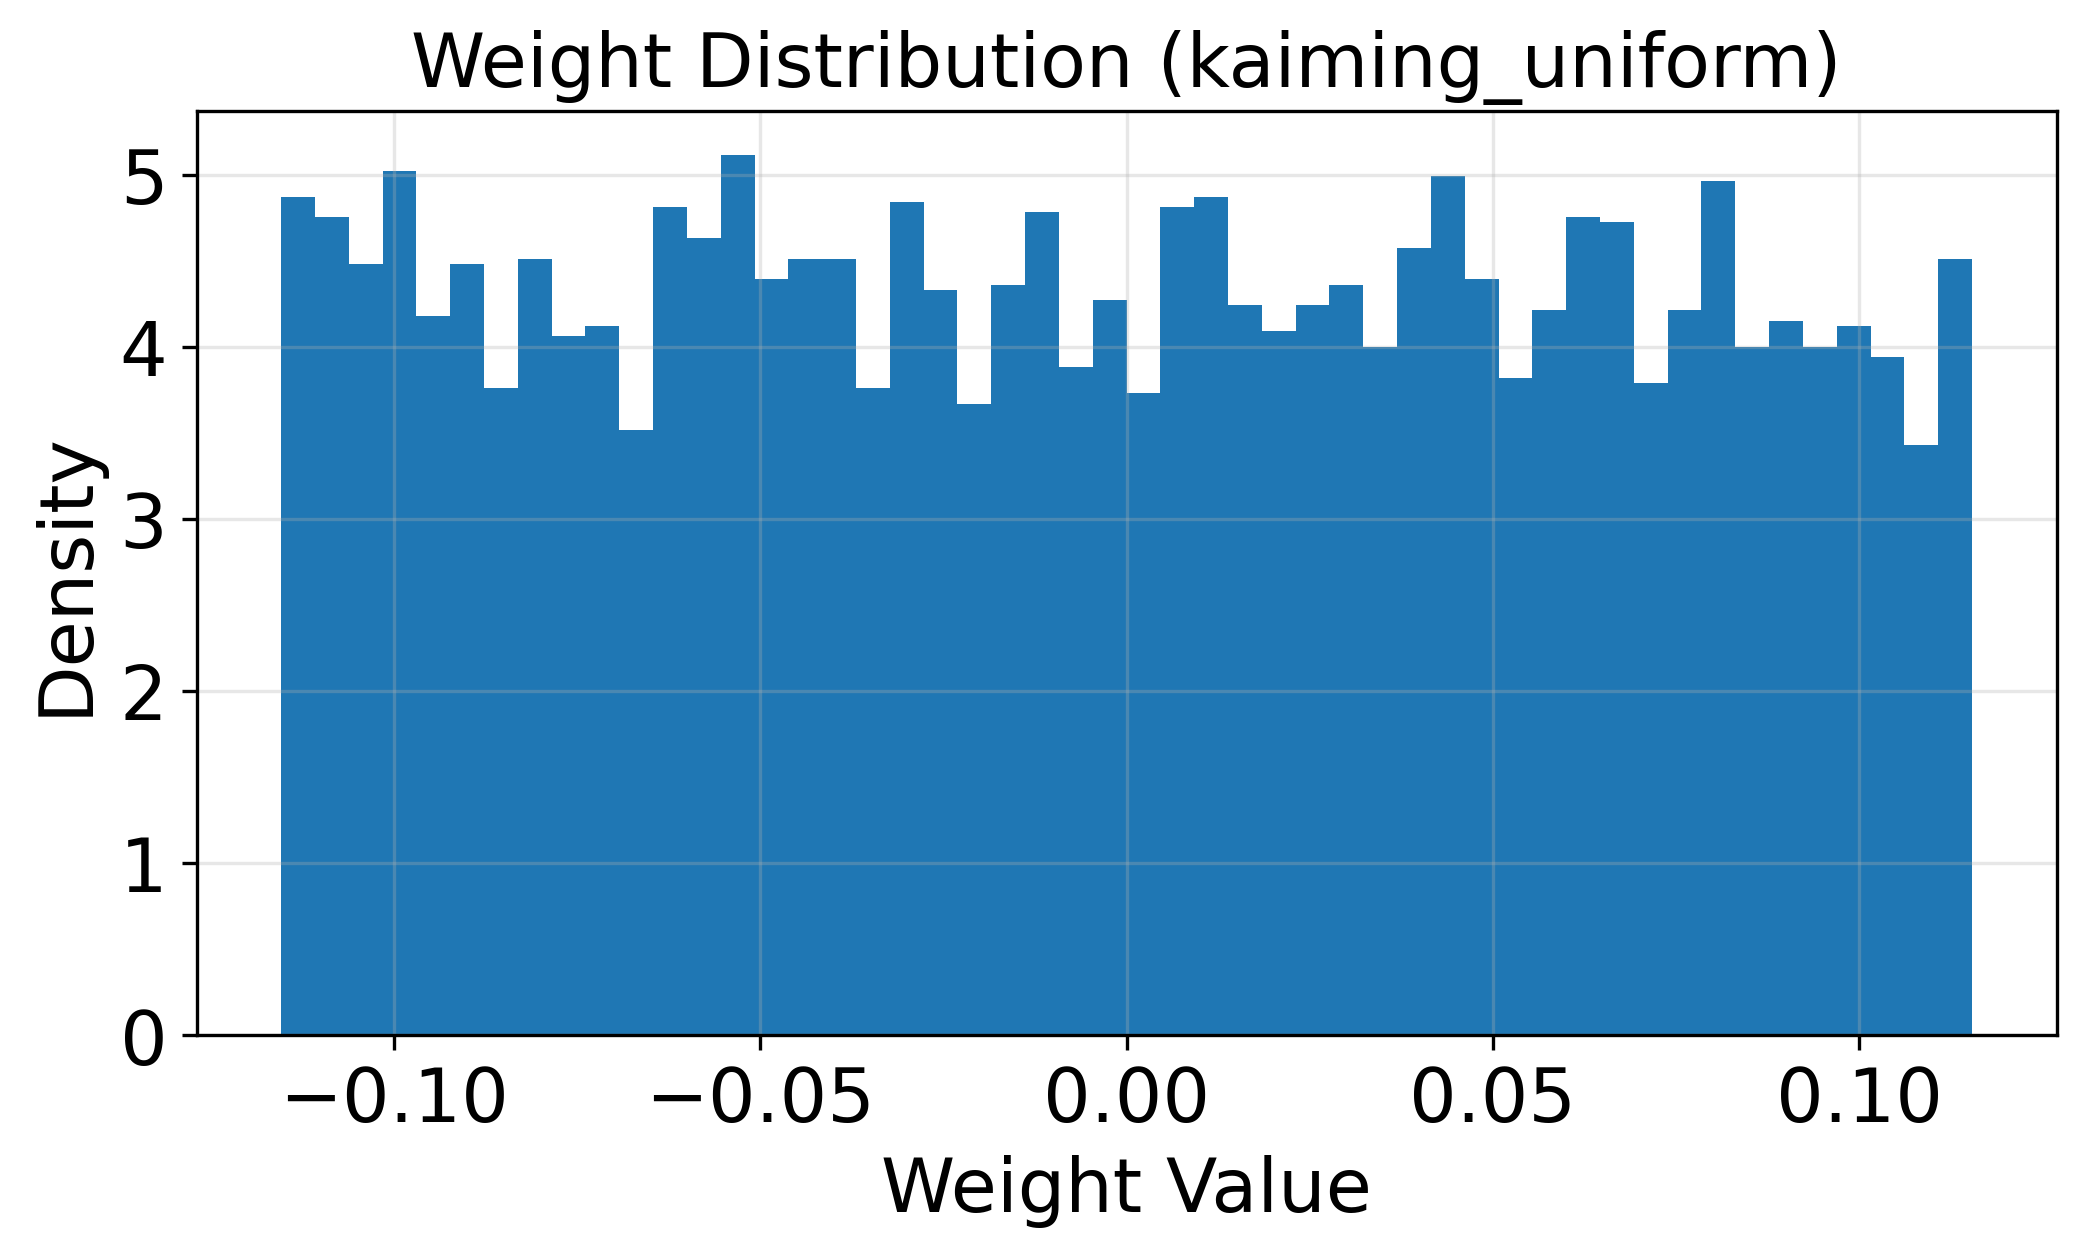

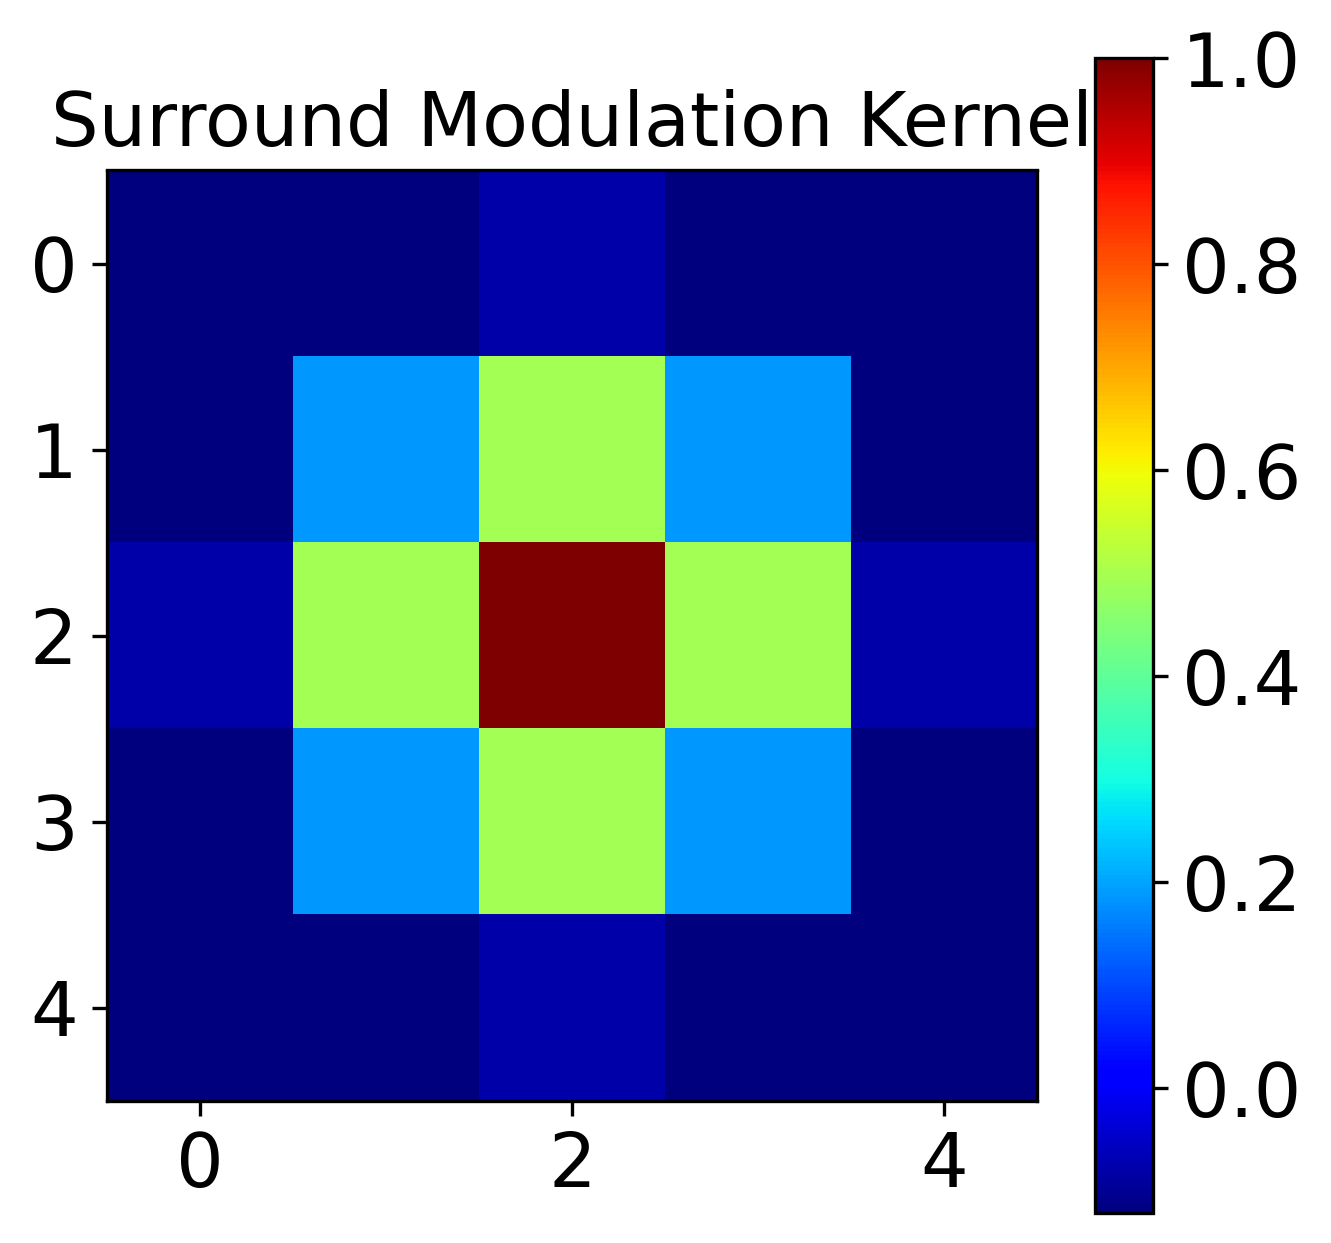

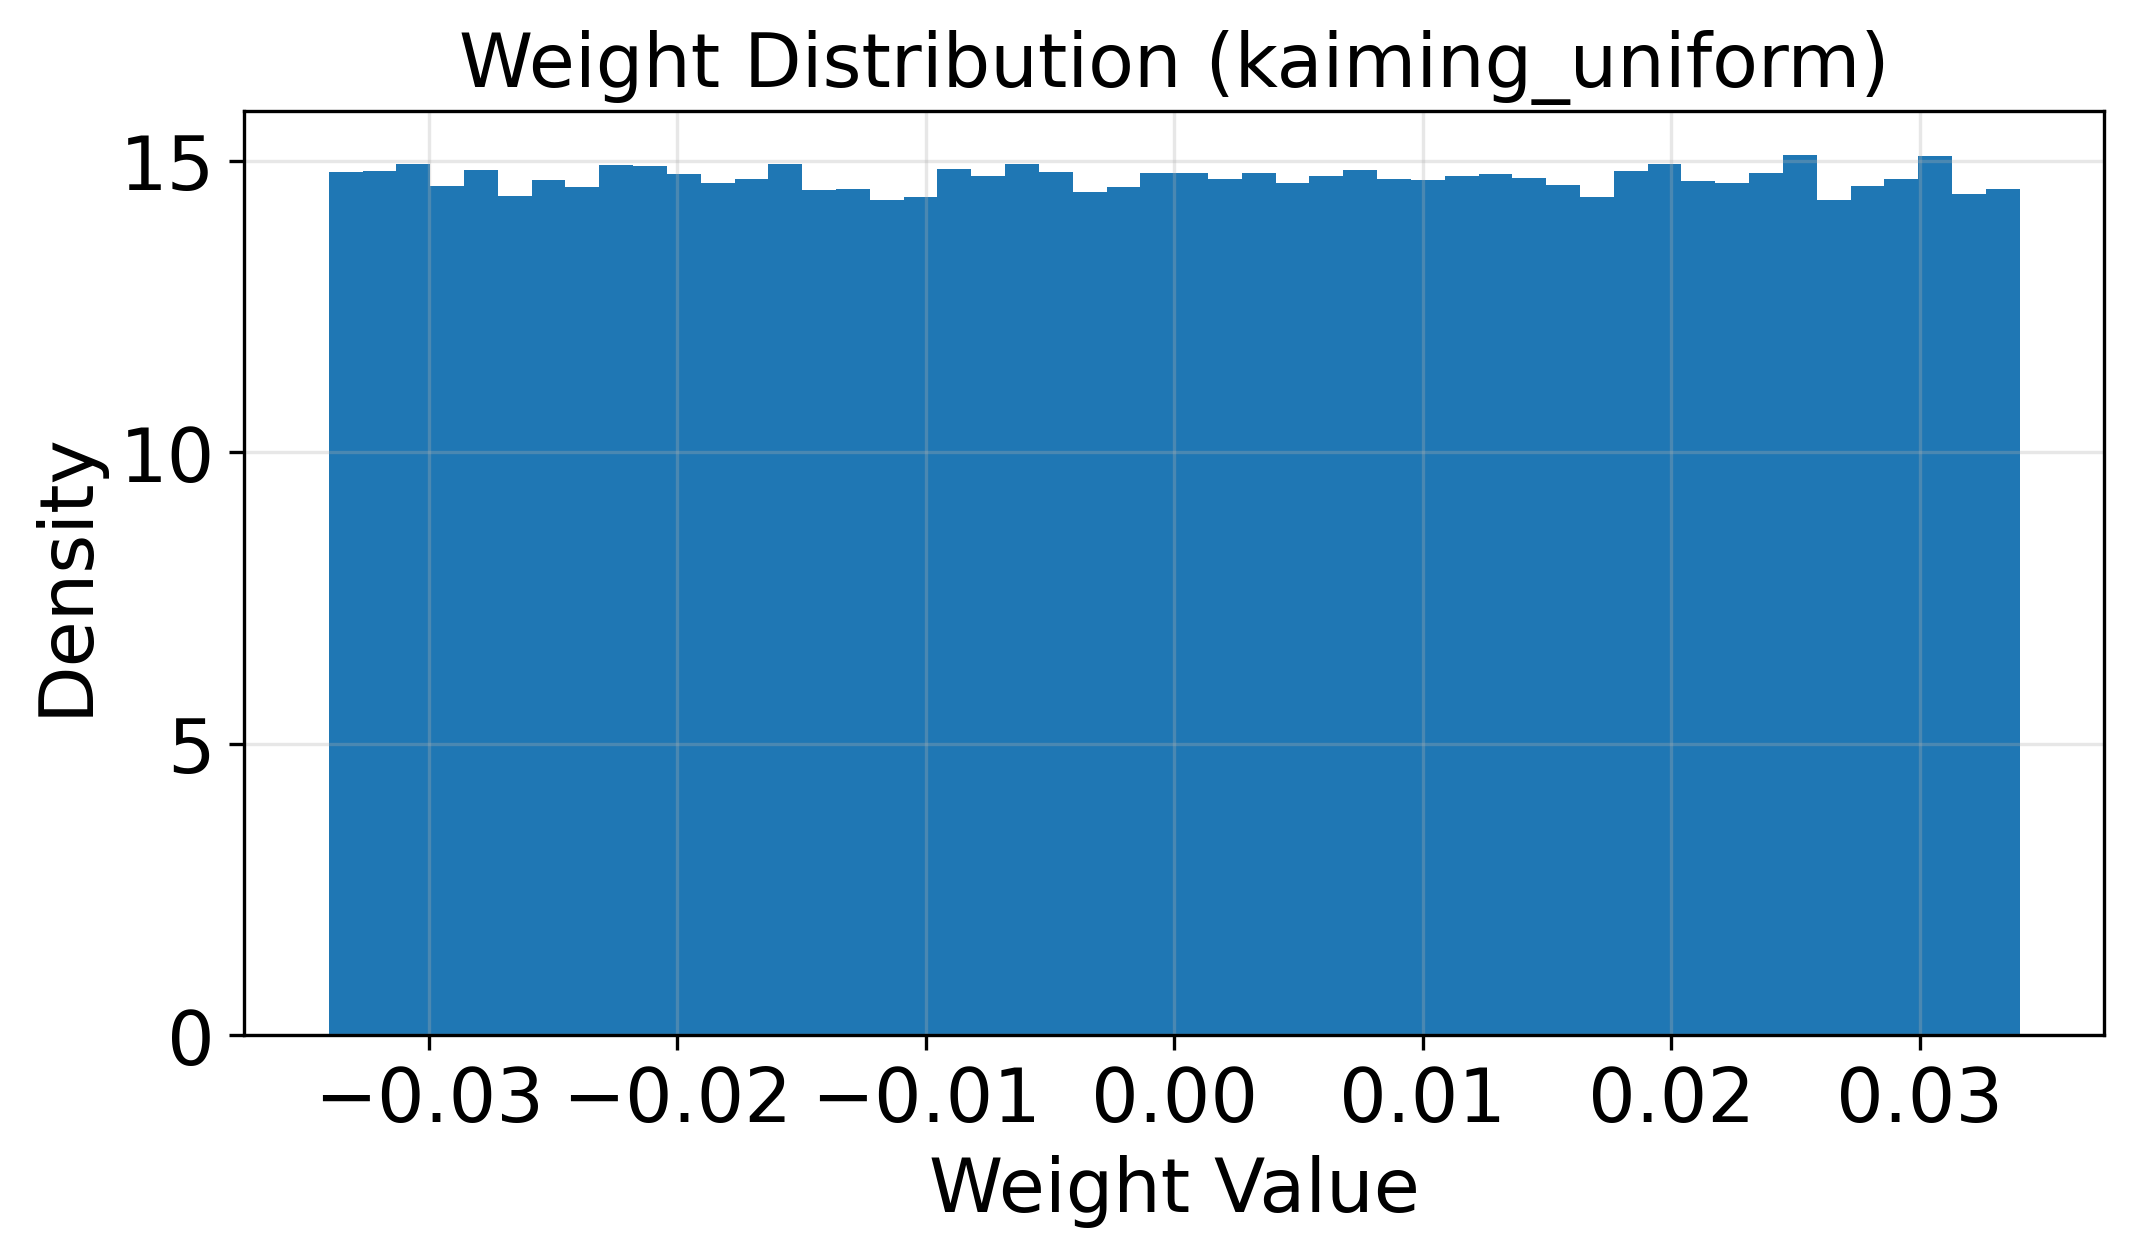

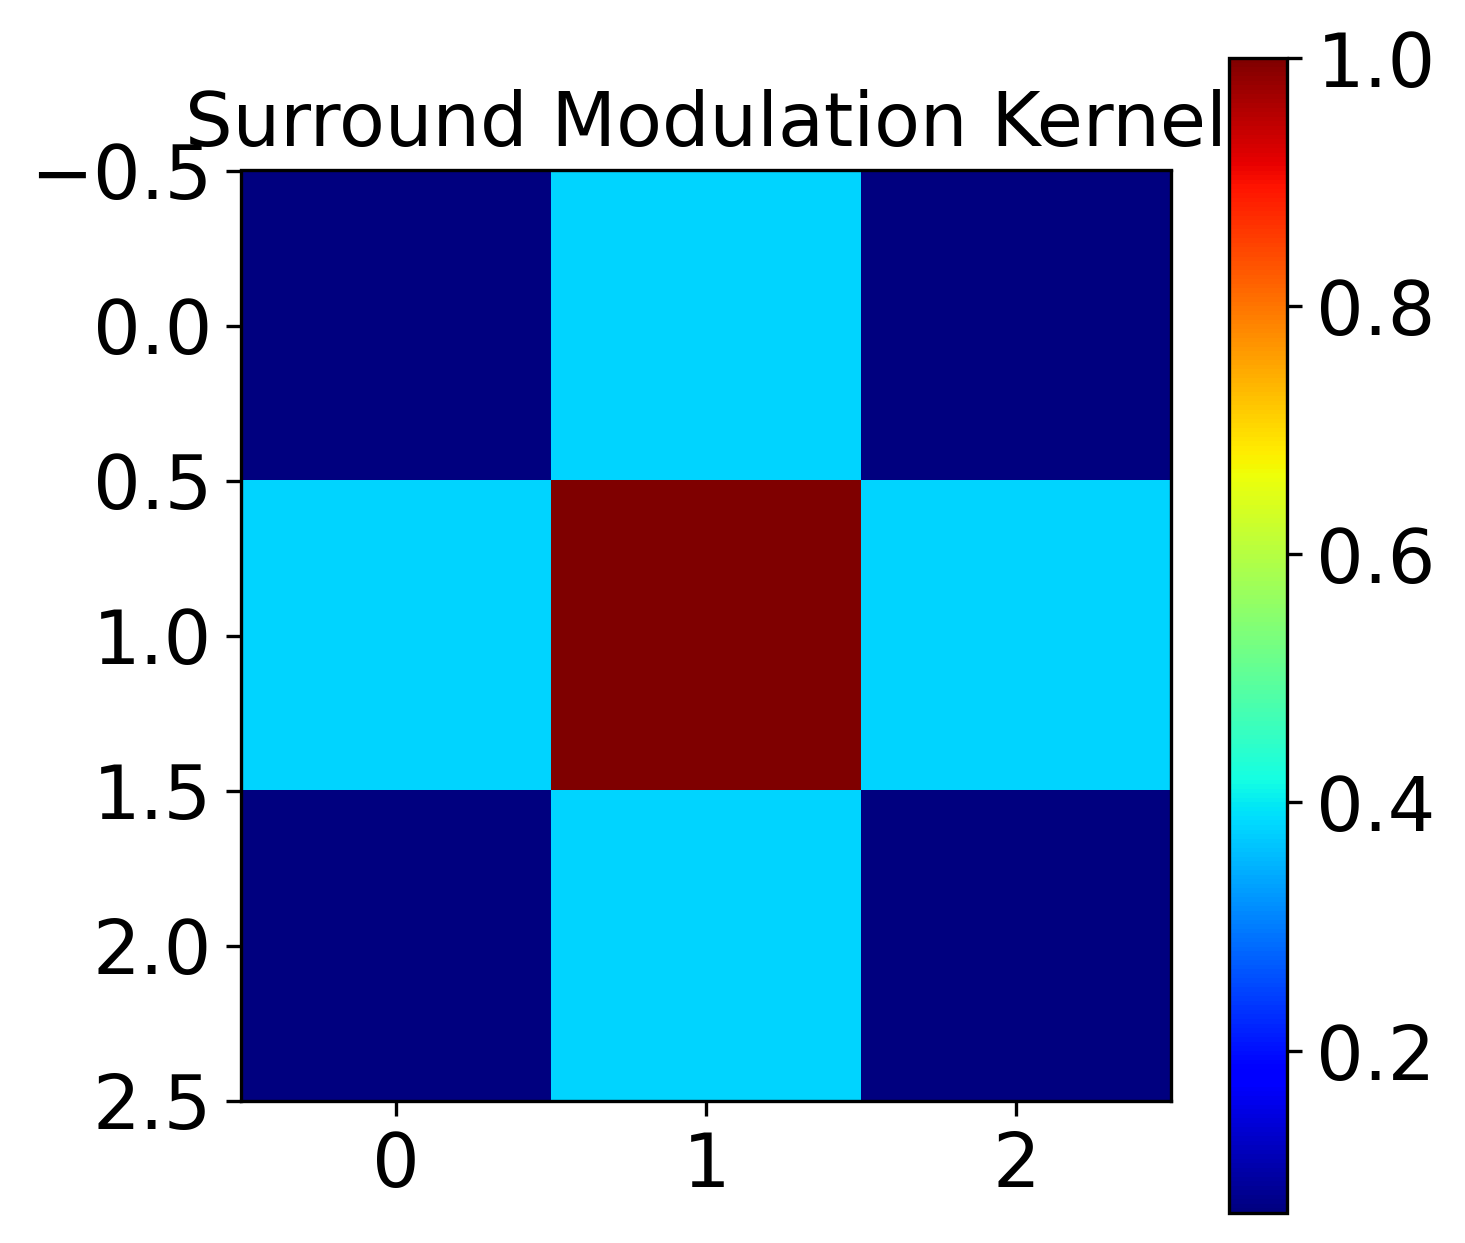

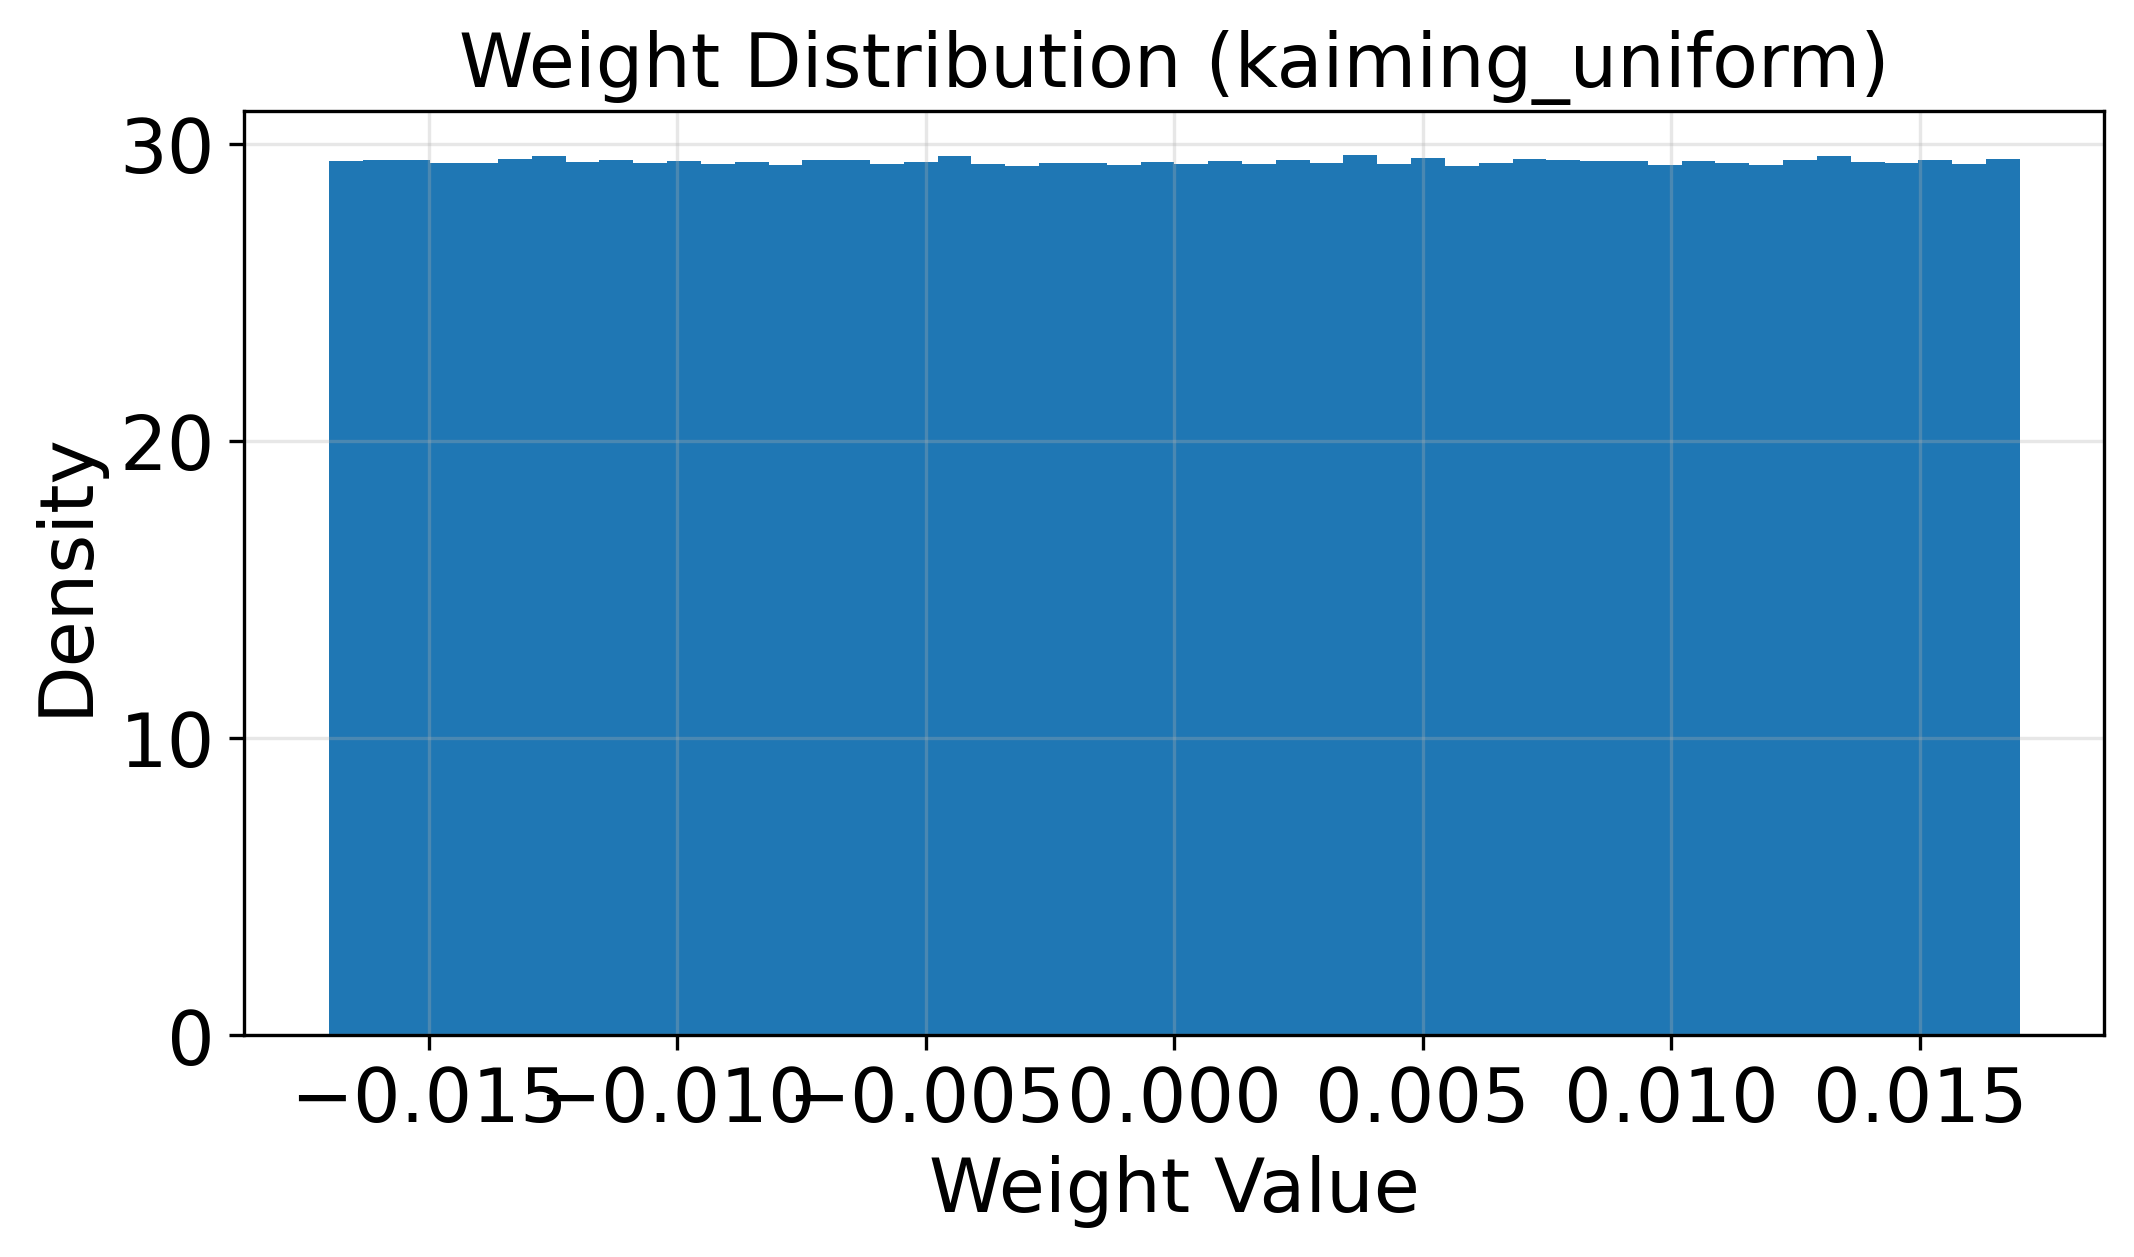

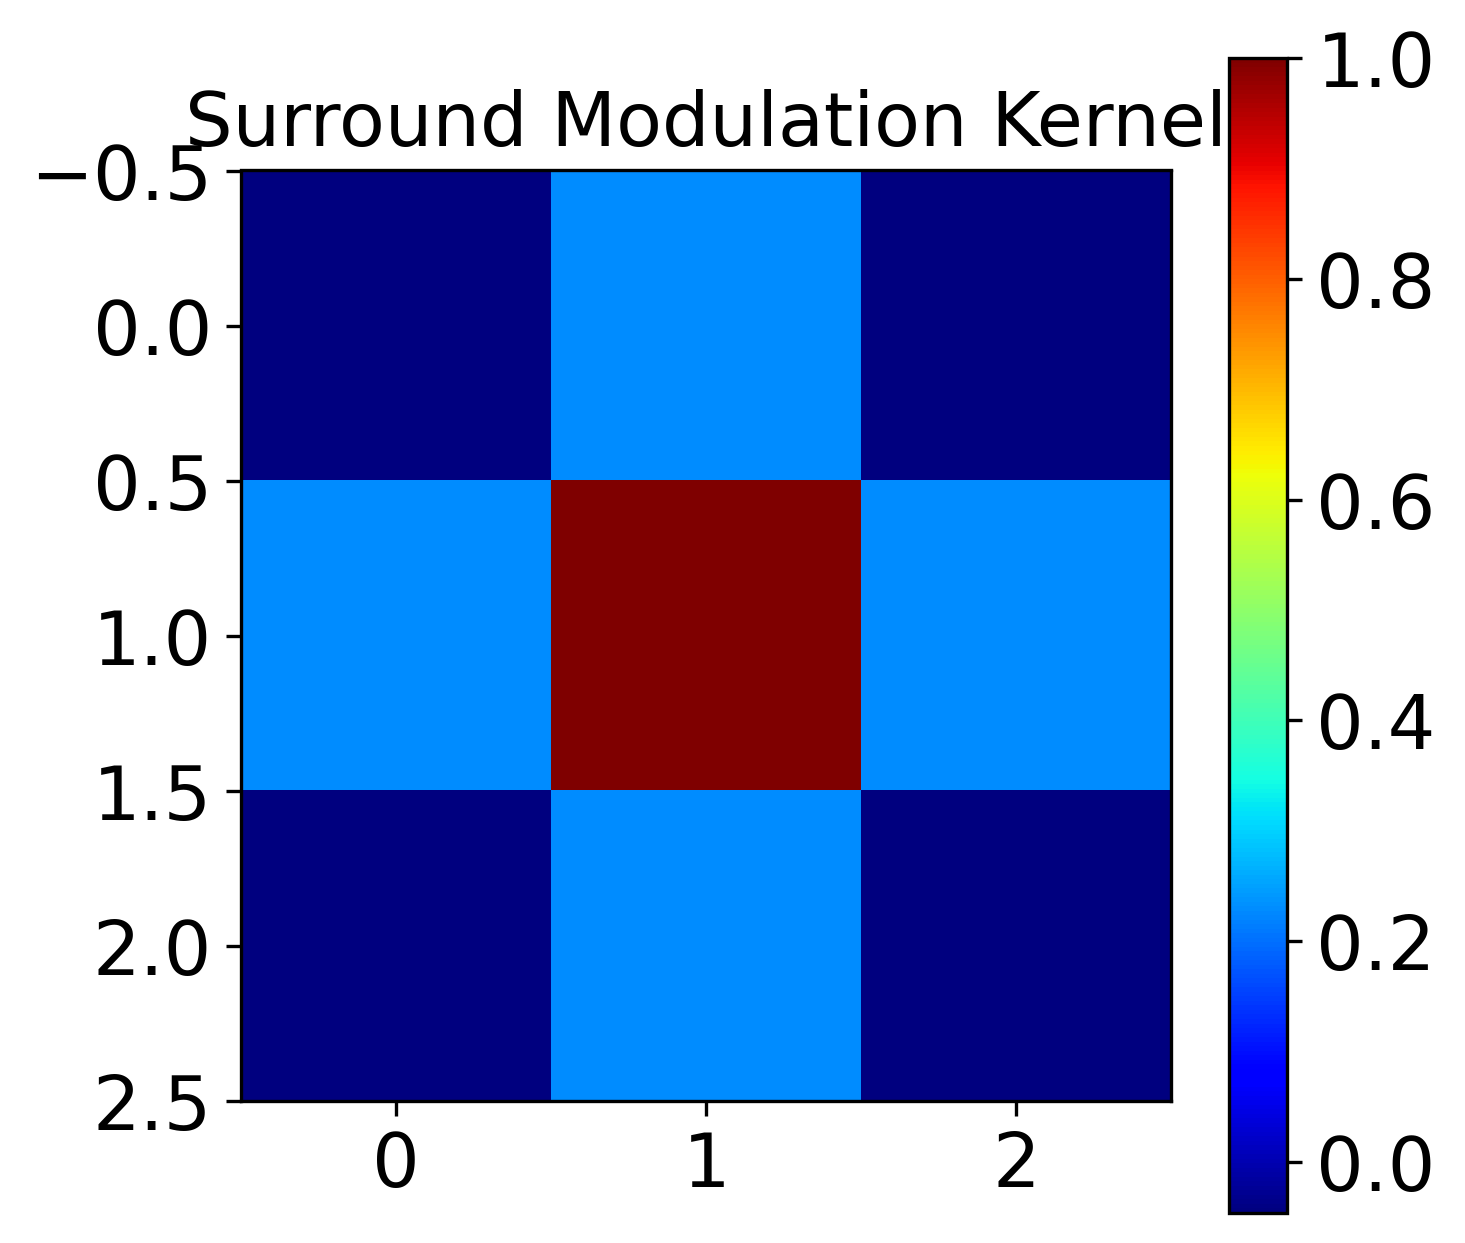

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2697 | Train Acc: 55.68% | Test Loss: 1.0458 | Test Acc: 63.10% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9997 | Train Acc: 65.55% | Test Loss: 0.9331 | Test Acc: 67.46% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9250 | Train Acc: 67.96% | Test Loss: 0.8769 | Test Acc: 69.11% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8879 | Train Acc: 69.40% | Test Loss: 0.8464 | Test Acc: 70.47% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8594 | Train Acc: 70.22% | Test Loss: 0.8517 | Test Acc: 70.08% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8393 | Train Acc: 70.99% | Test Loss: 0.8302 | Test Acc: 70.52% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8215 | Train Acc: 71.58% | Test Loss: 0.8185 | Test Acc: 71.53% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8126 | Train Acc: 72.04% | Test Loss: 0.8097 | Test Acc: 71.42% | LR: 0.001000
Epoch [9/2

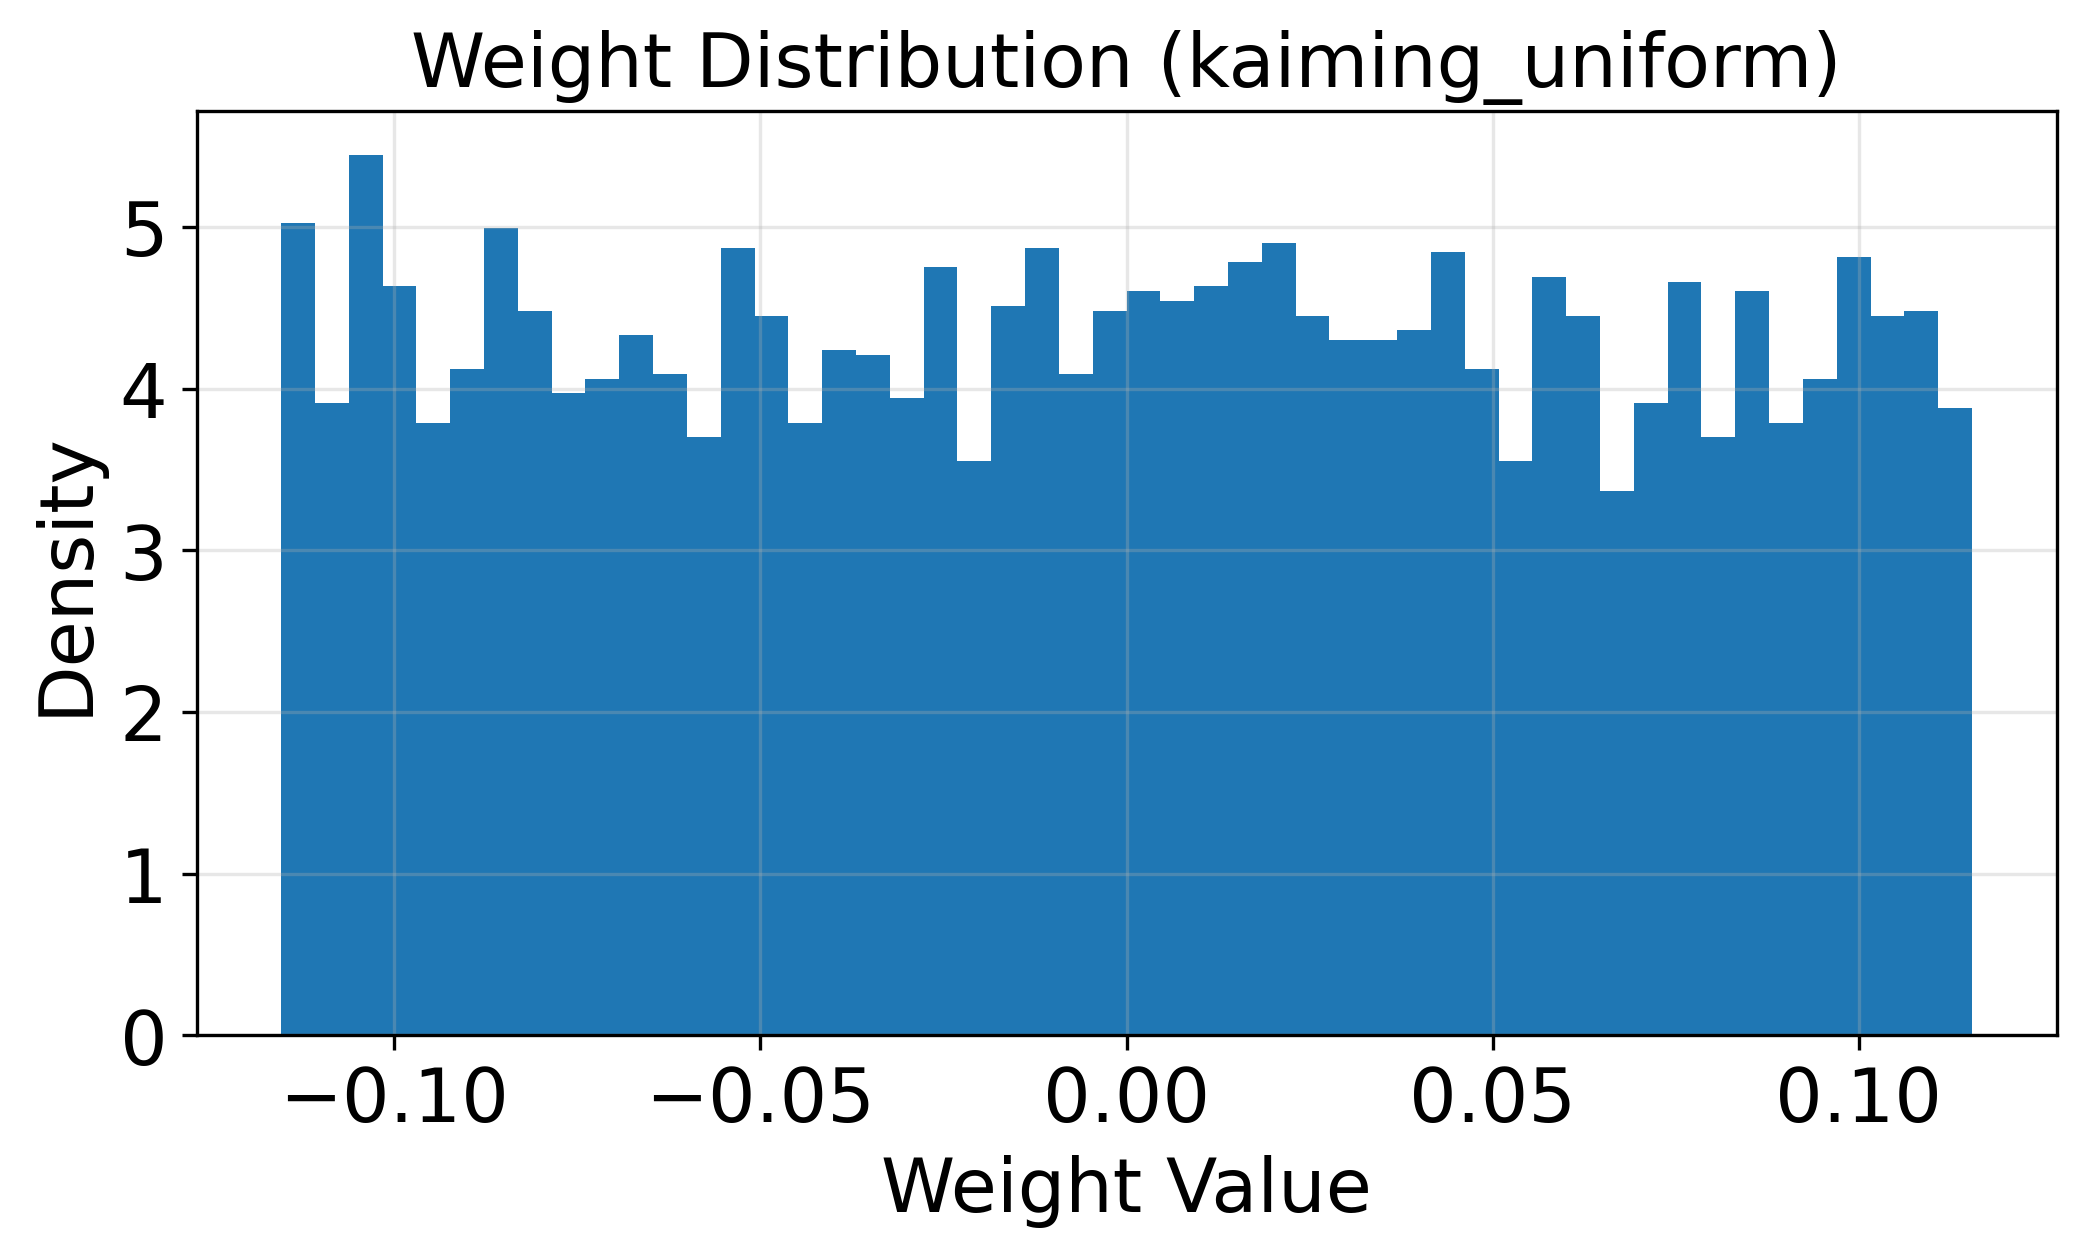

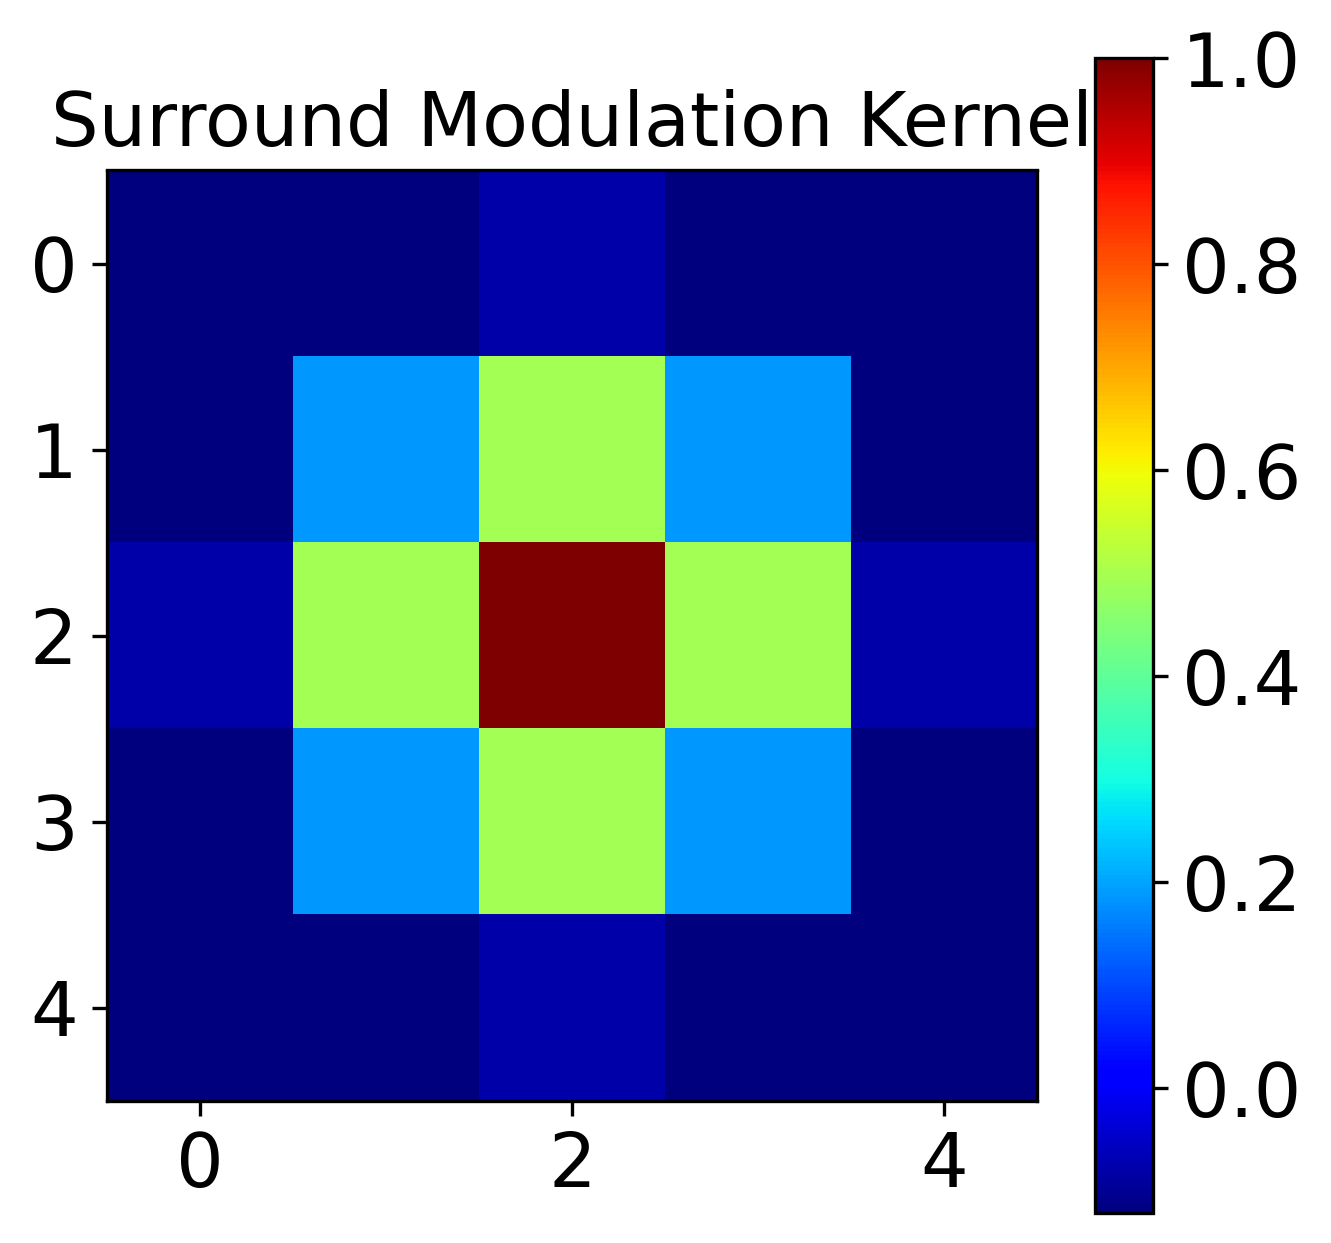

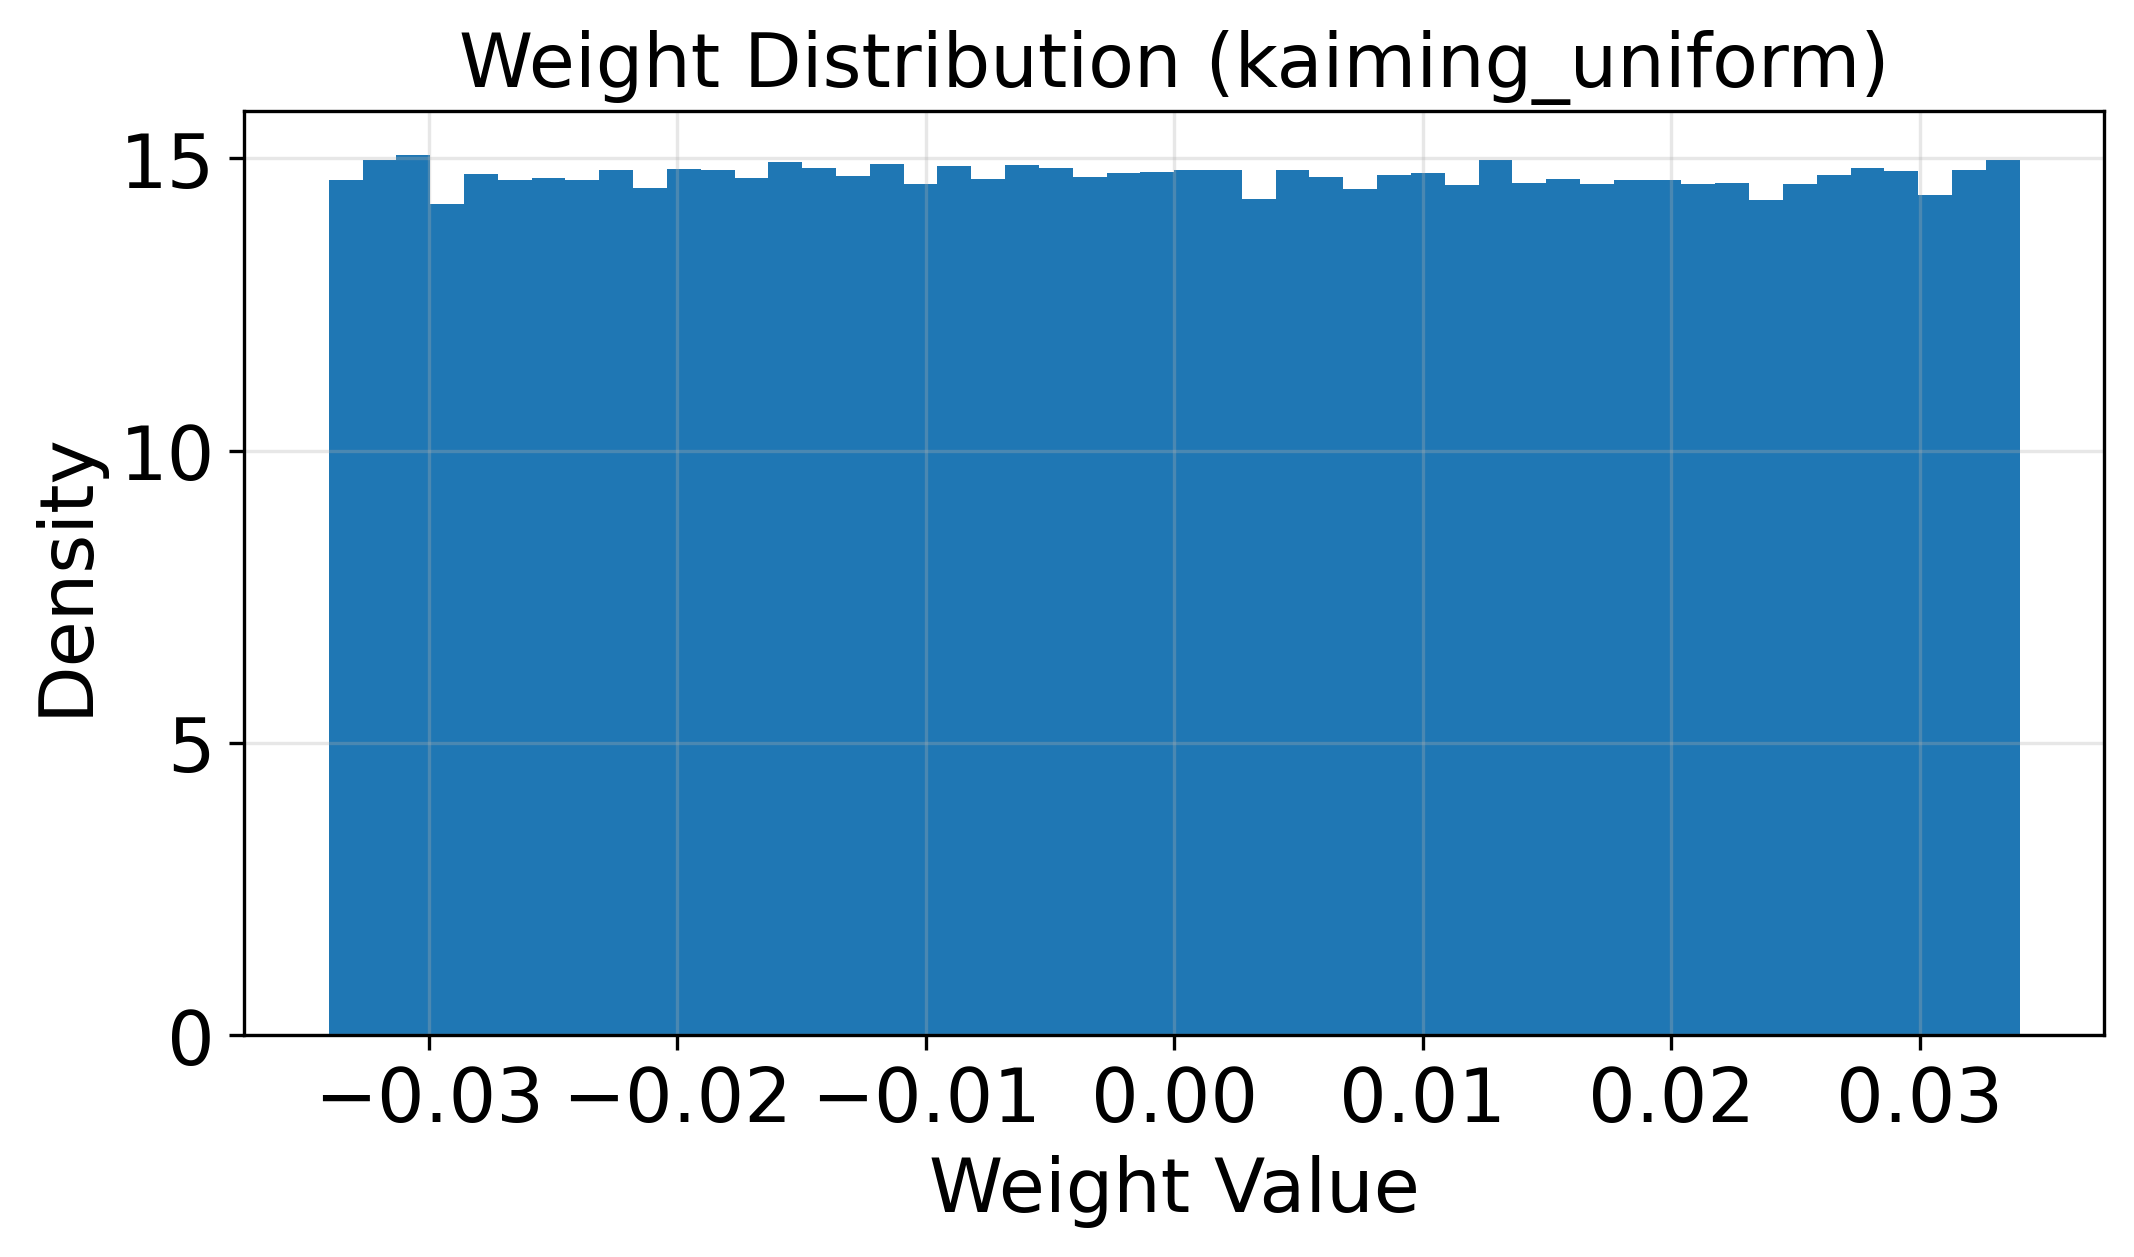

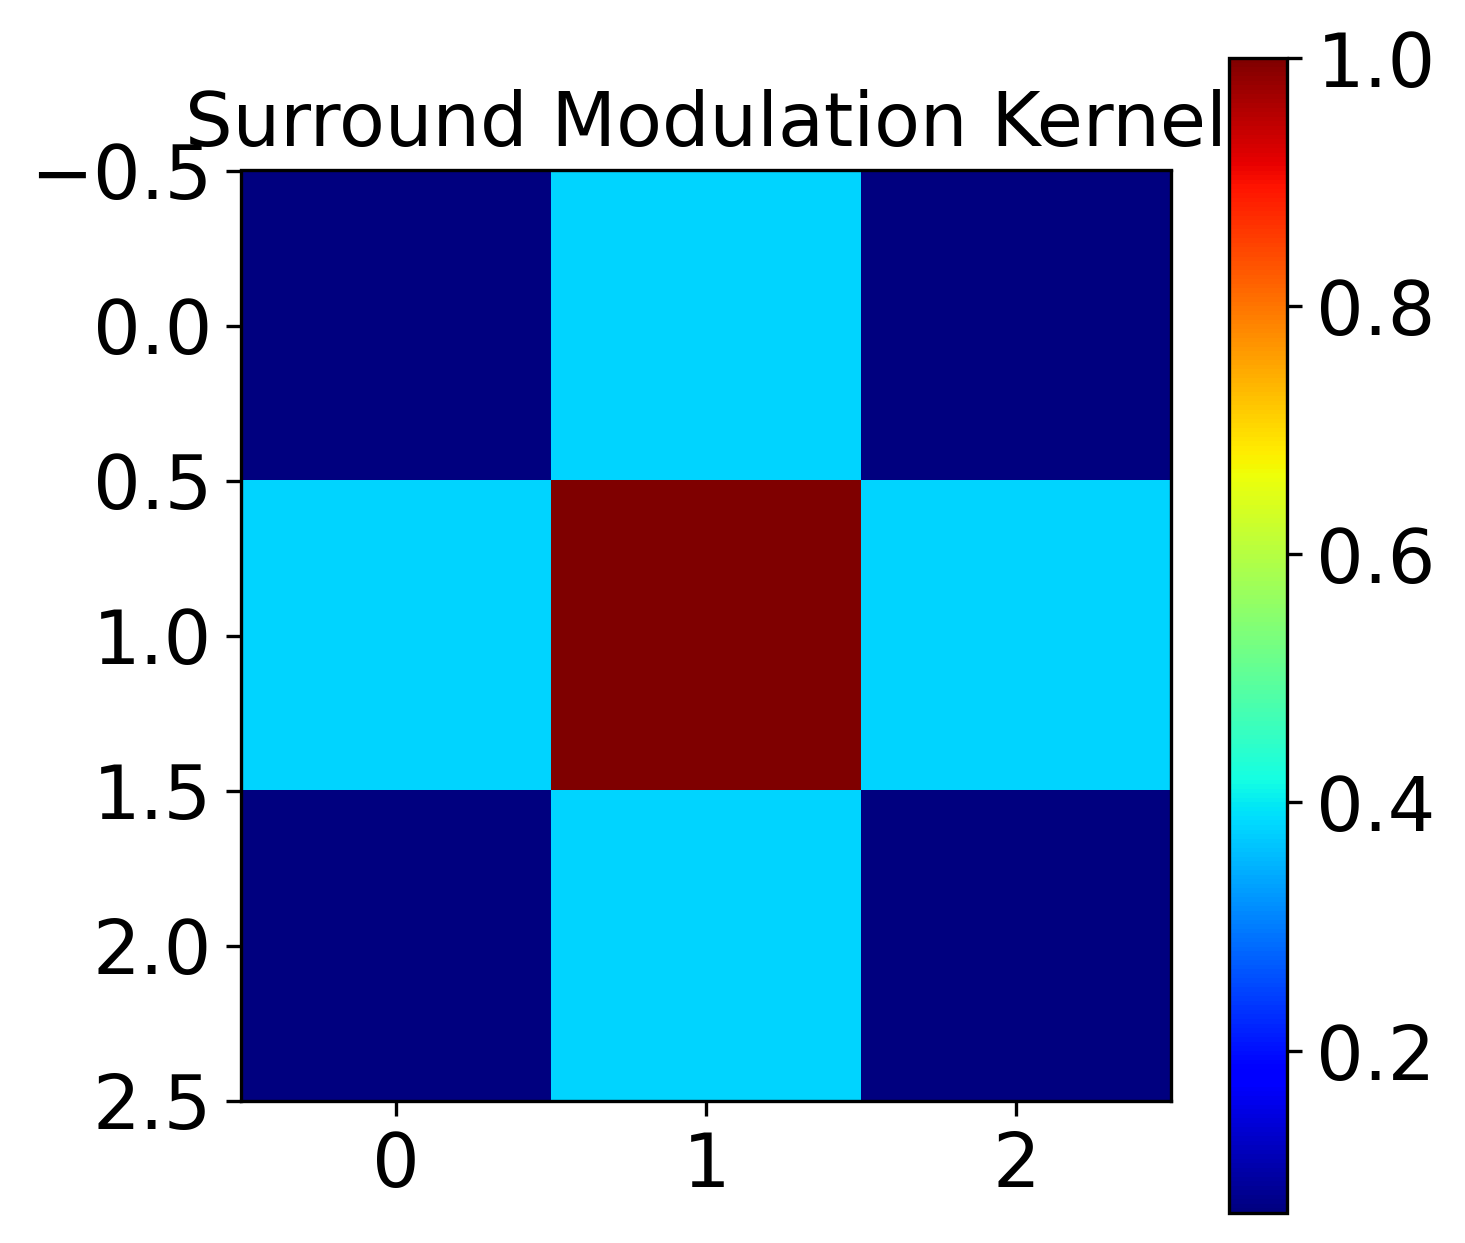

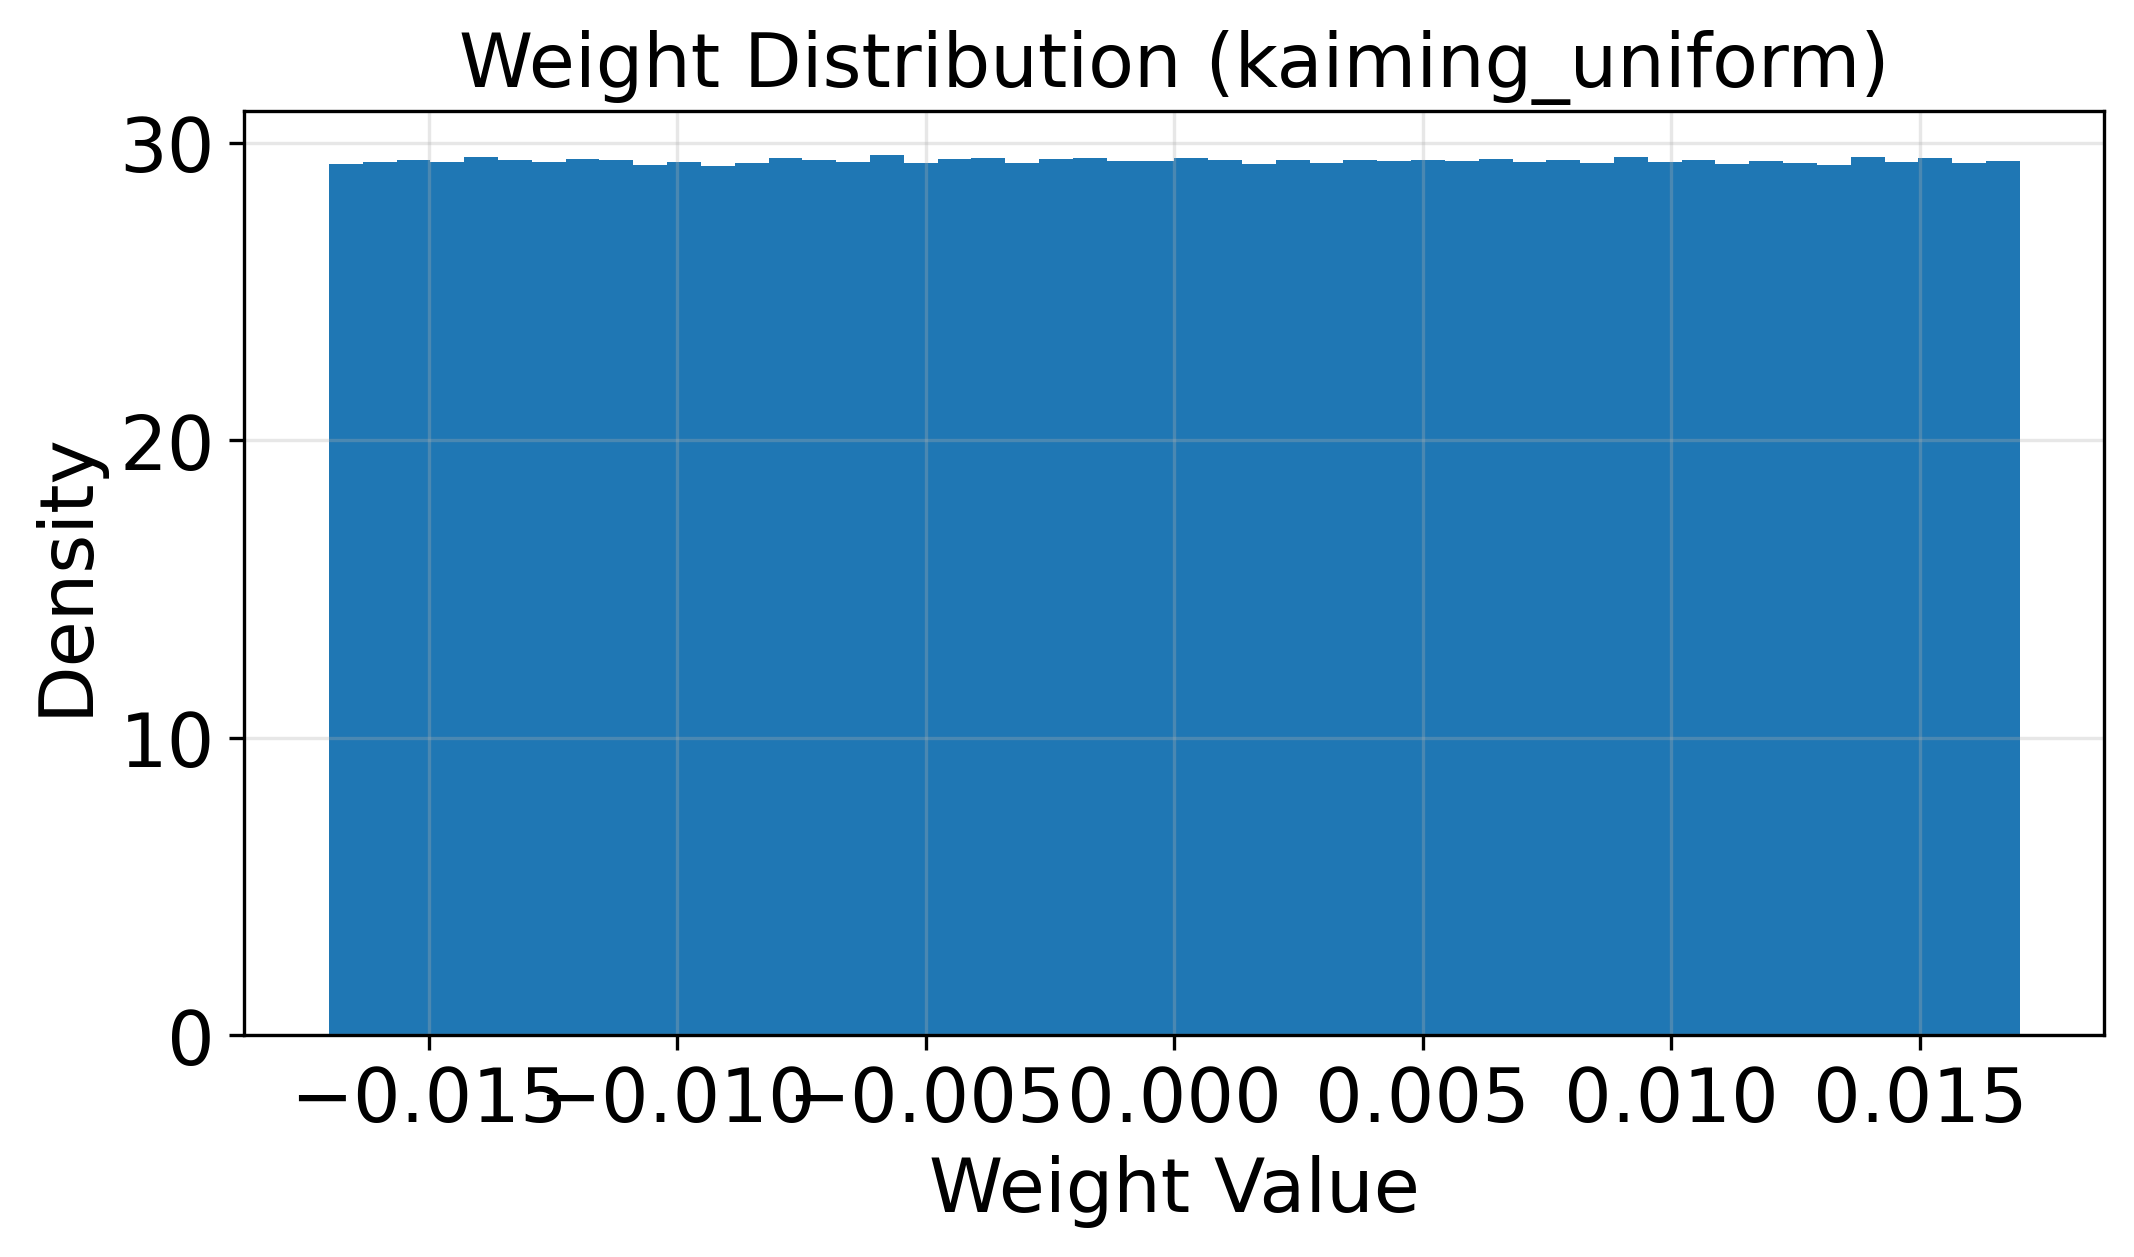

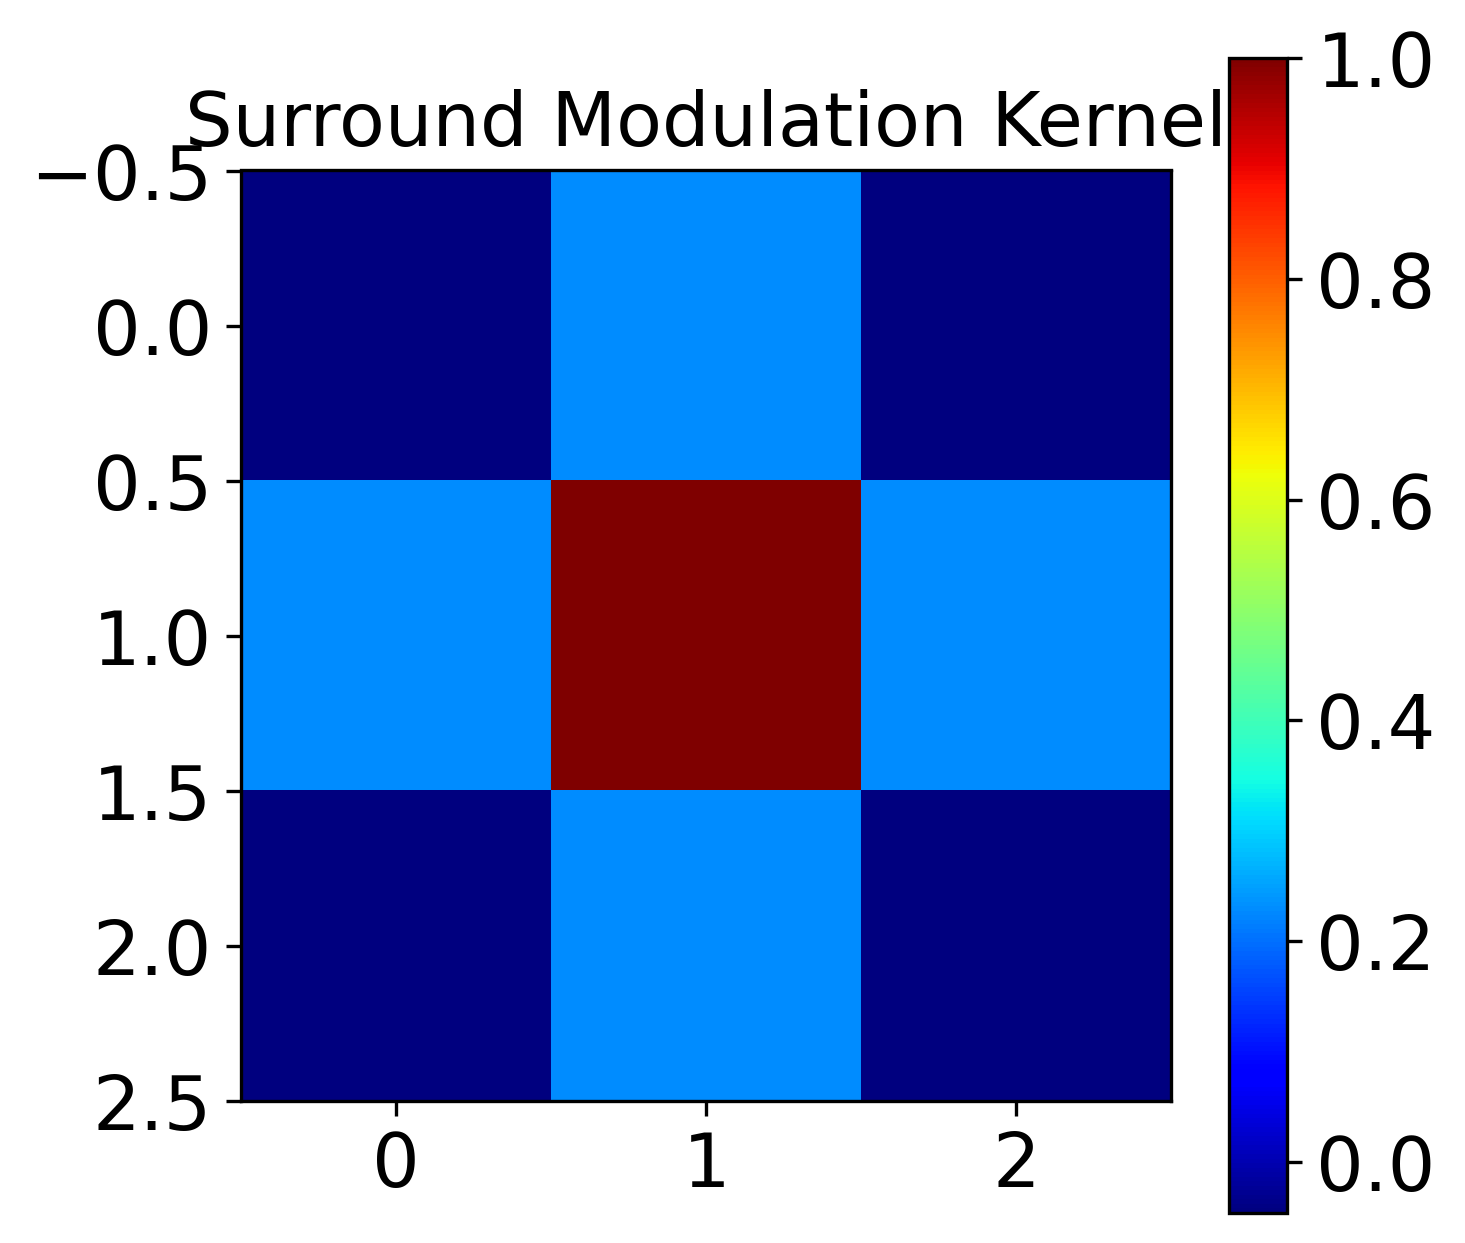

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2554 | Train Acc: 56.51% | Test Loss: 1.0302 | Test Acc: 64.15% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9830 | Train Acc: 66.08% | Test Loss: 0.9333 | Test Acc: 67.58% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9217 | Train Acc: 67.99% | Test Loss: 0.8723 | Test Acc: 69.56% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8767 | Train Acc: 69.65% | Test Loss: 0.8669 | Test Acc: 70.23% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8477 | Train Acc: 70.79% | Test Loss: 0.8699 | Test Acc: 69.60% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8264 | Train Acc: 71.47% | Test Loss: 0.8376 | Test Acc: 70.90% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8150 | Train Acc: 71.61% | Test Loss: 0.8245 | Test Acc: 71.40% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8070 | Train Acc: 72.10% | Test Loss: 0.8367 | Test Acc: 70.73% | LR: 0.001000
Epoch [9/2

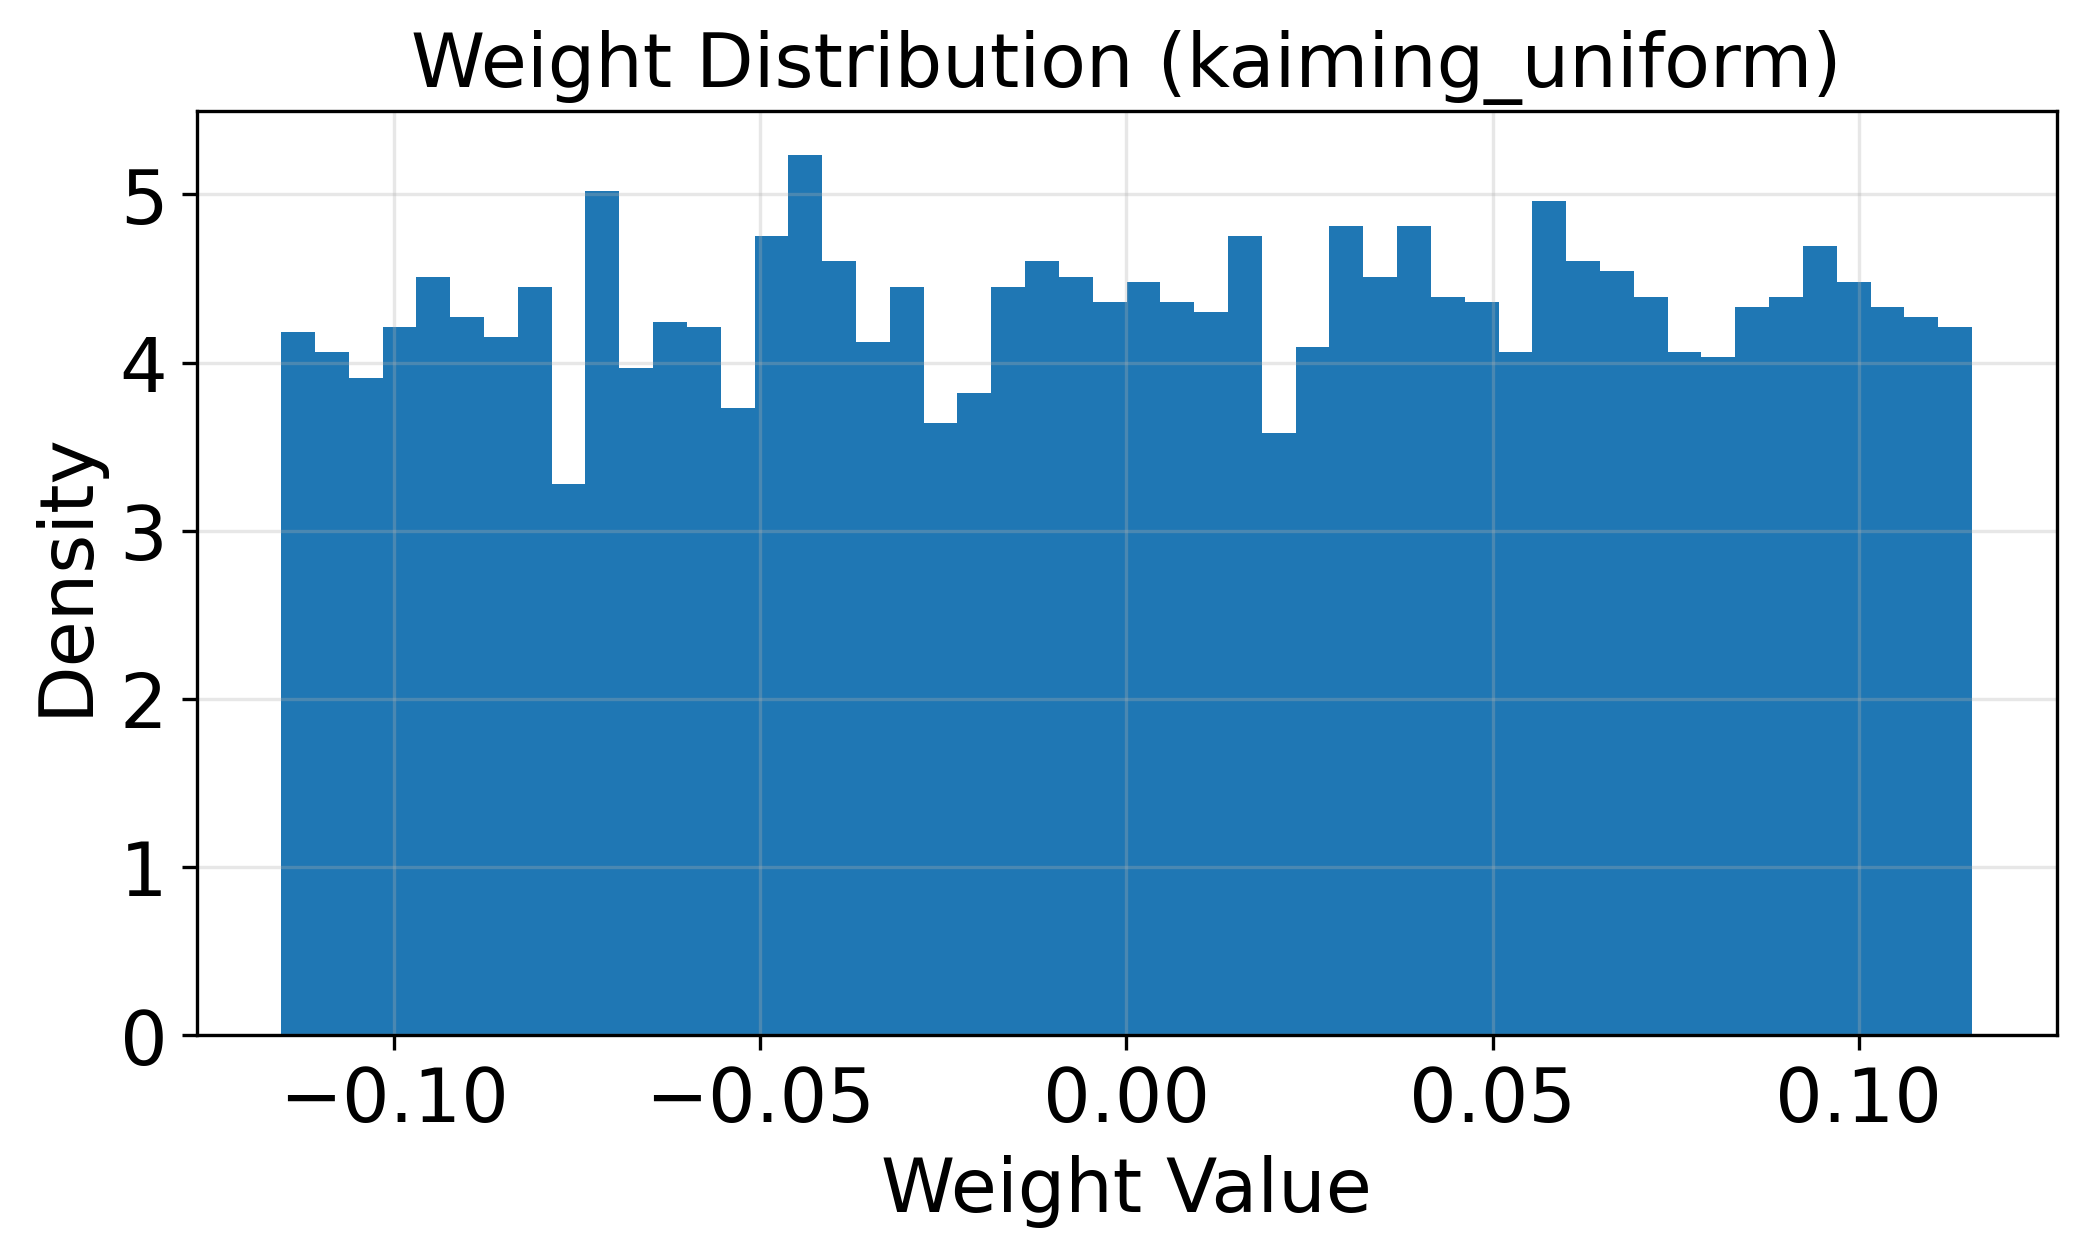

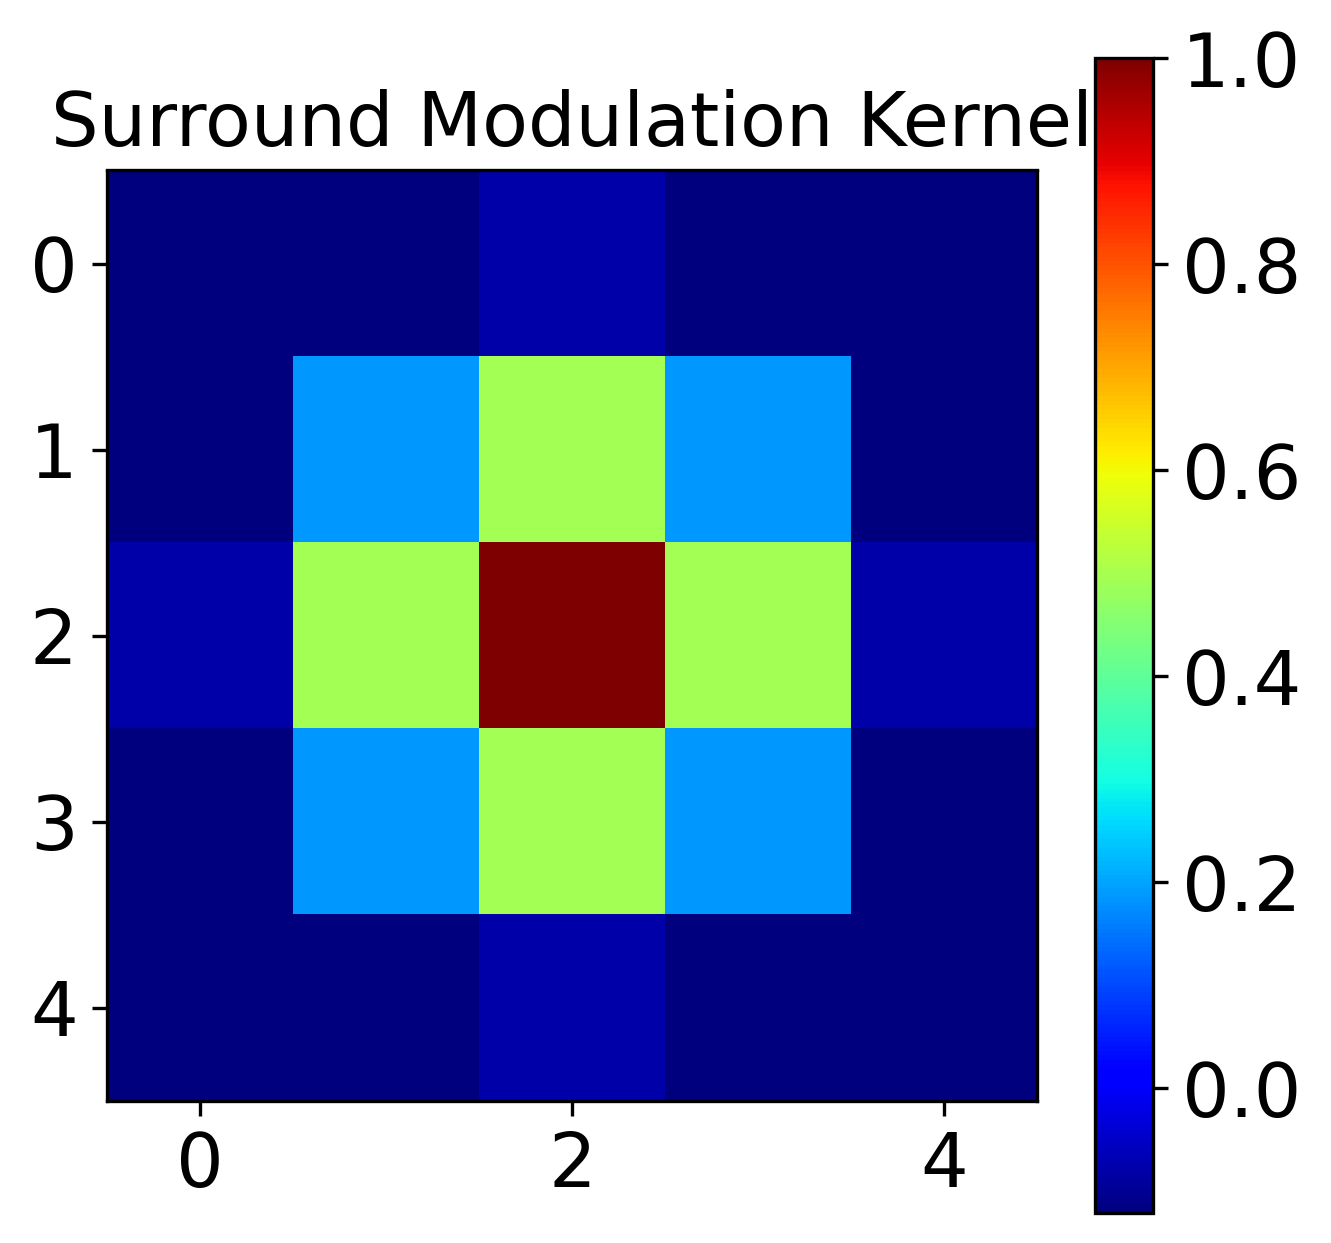

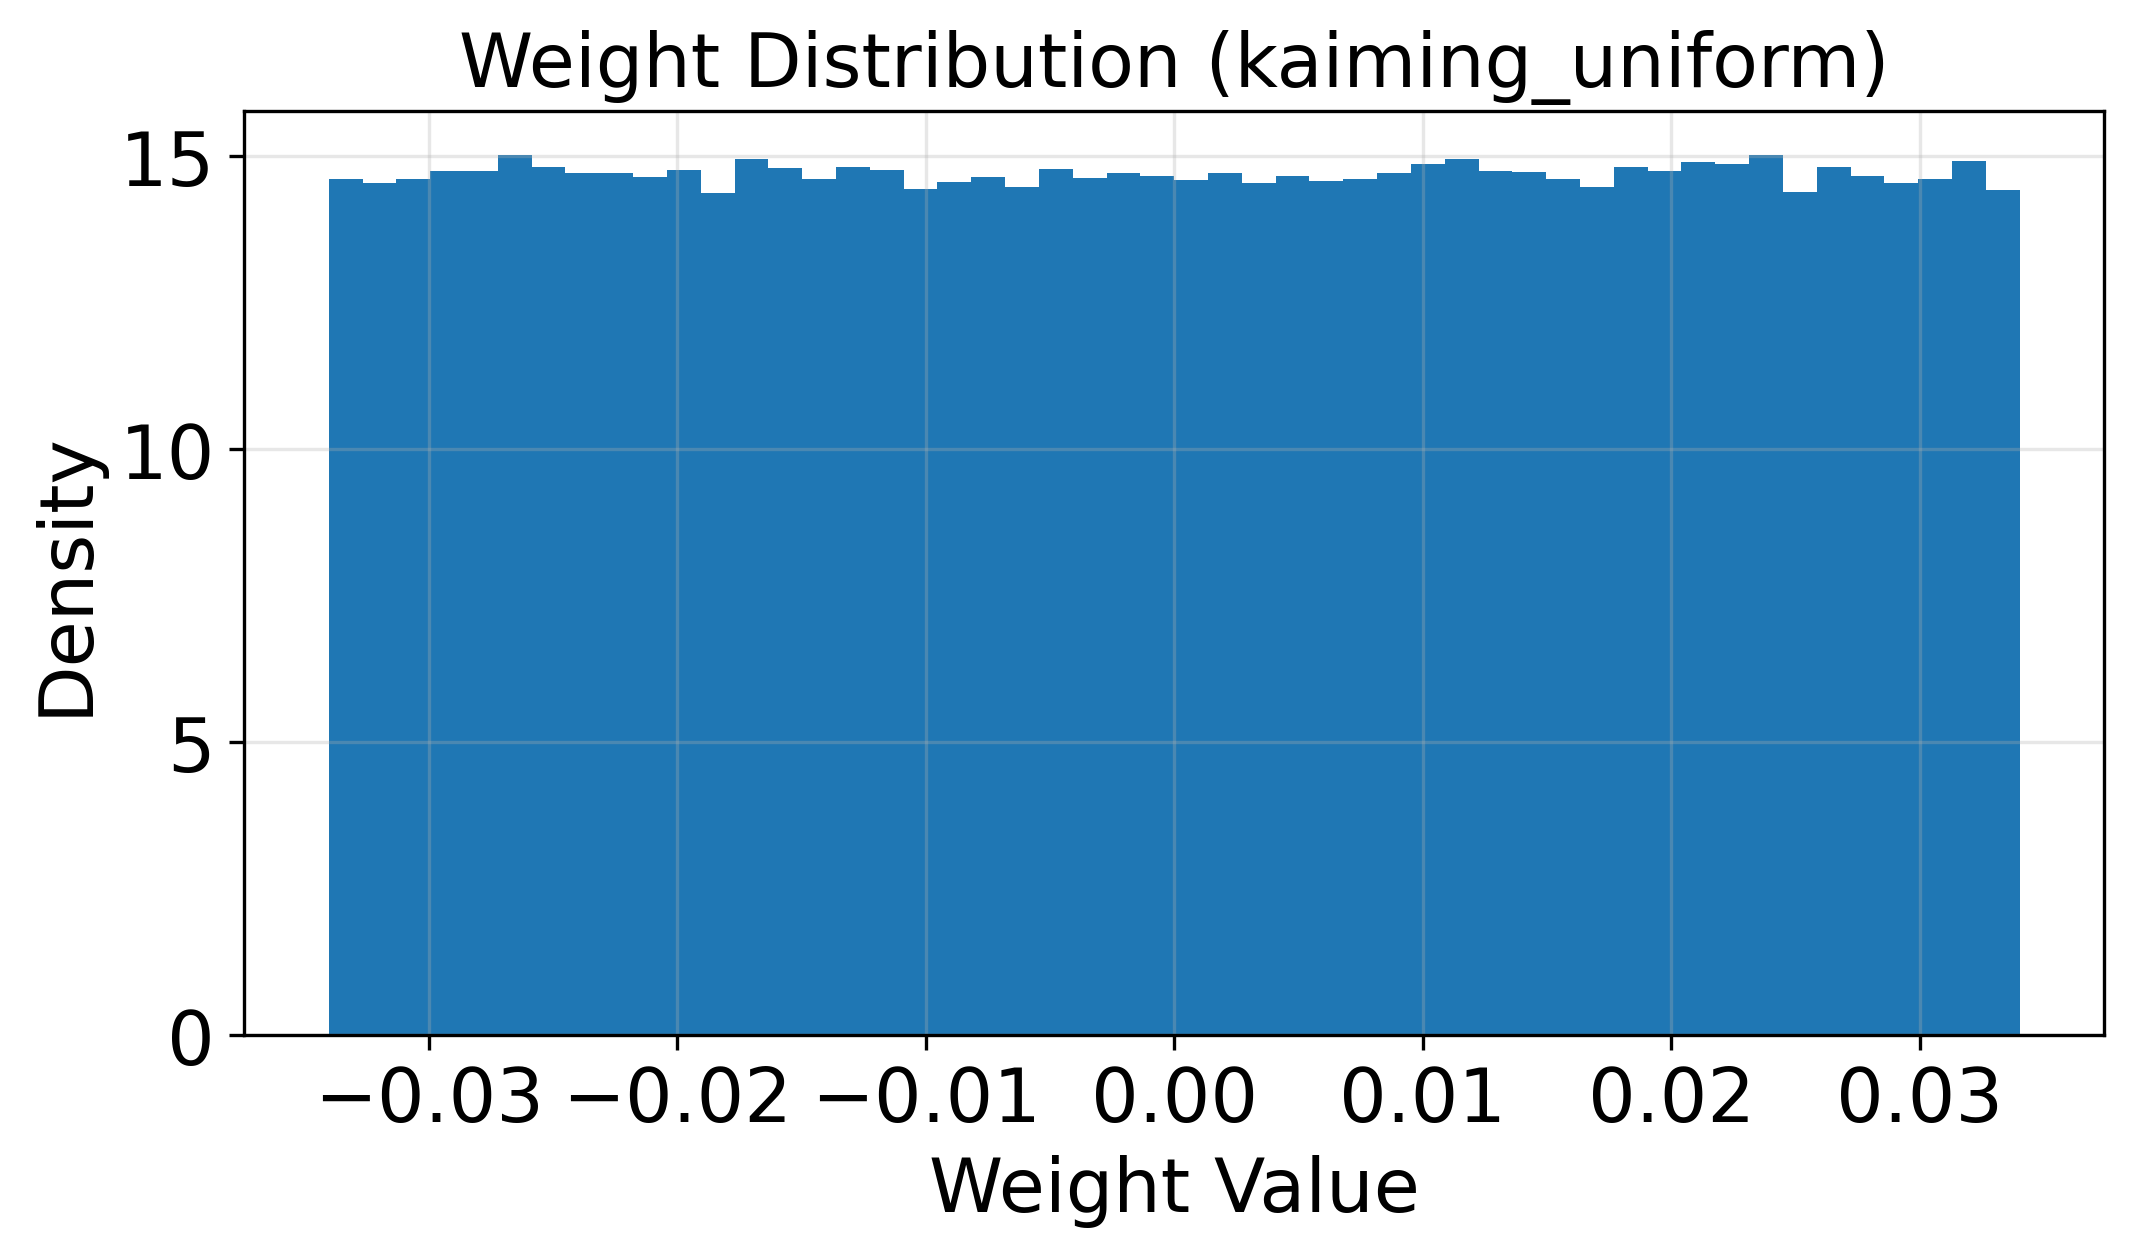

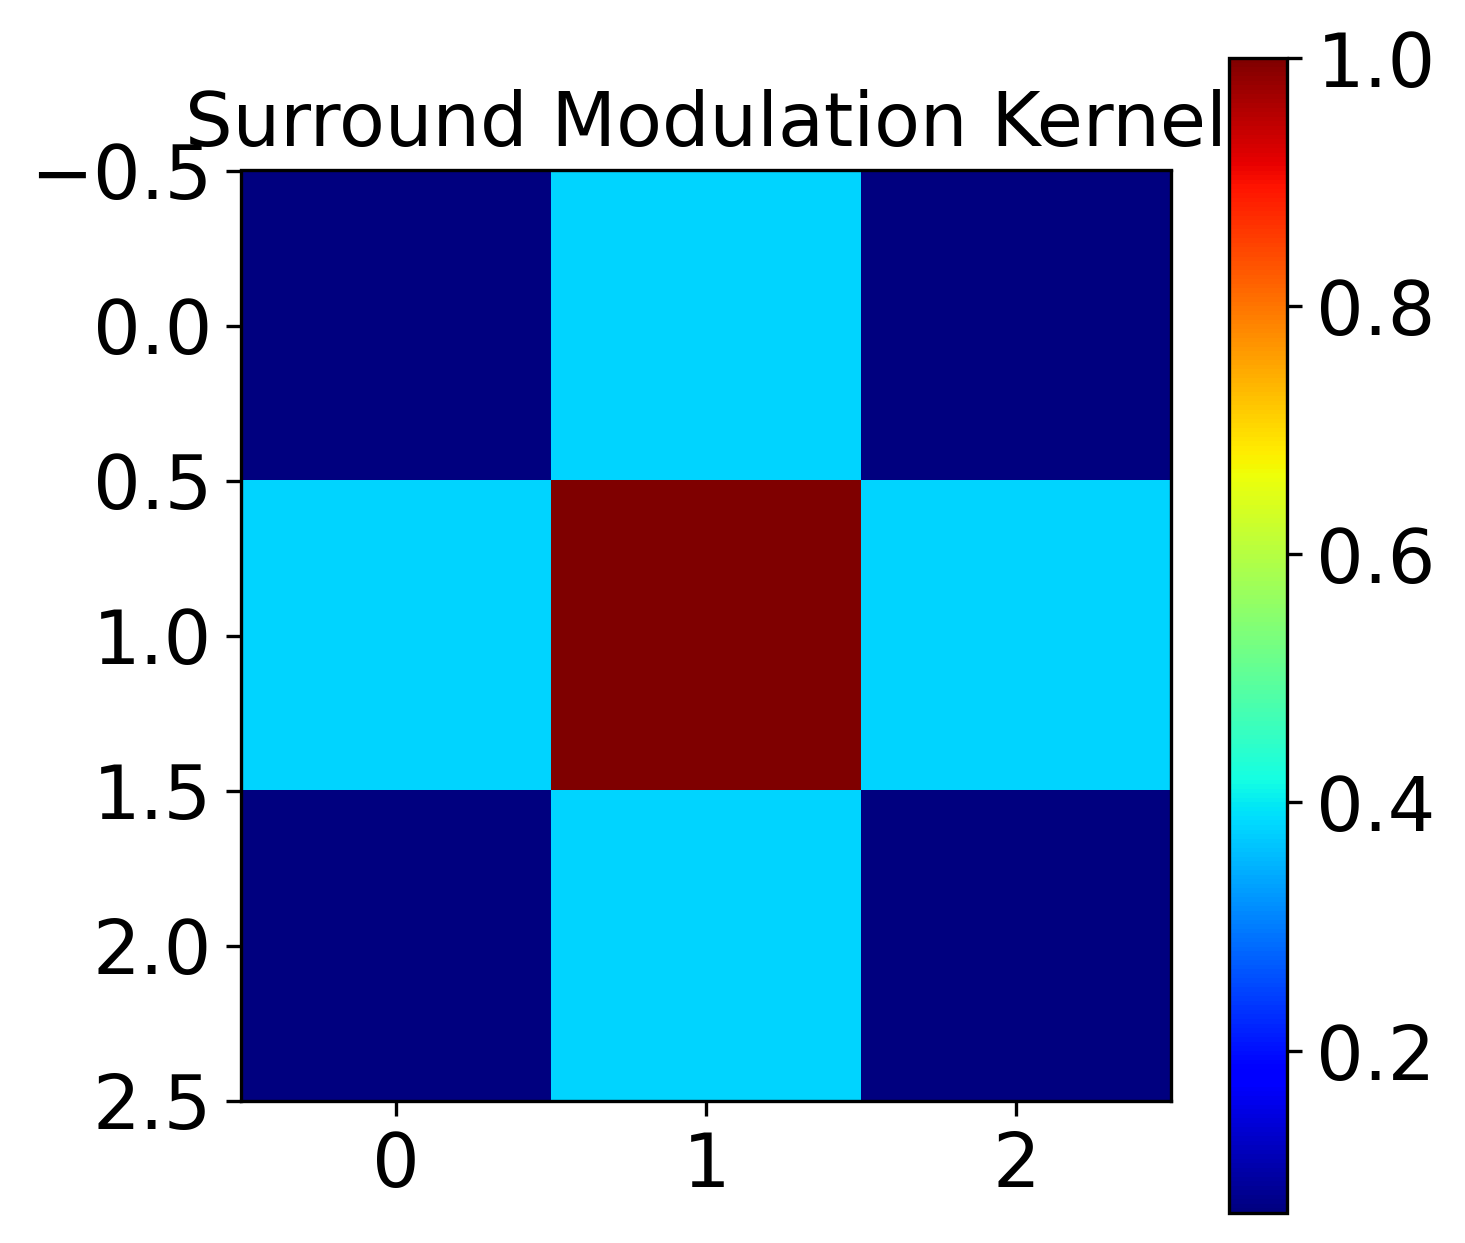

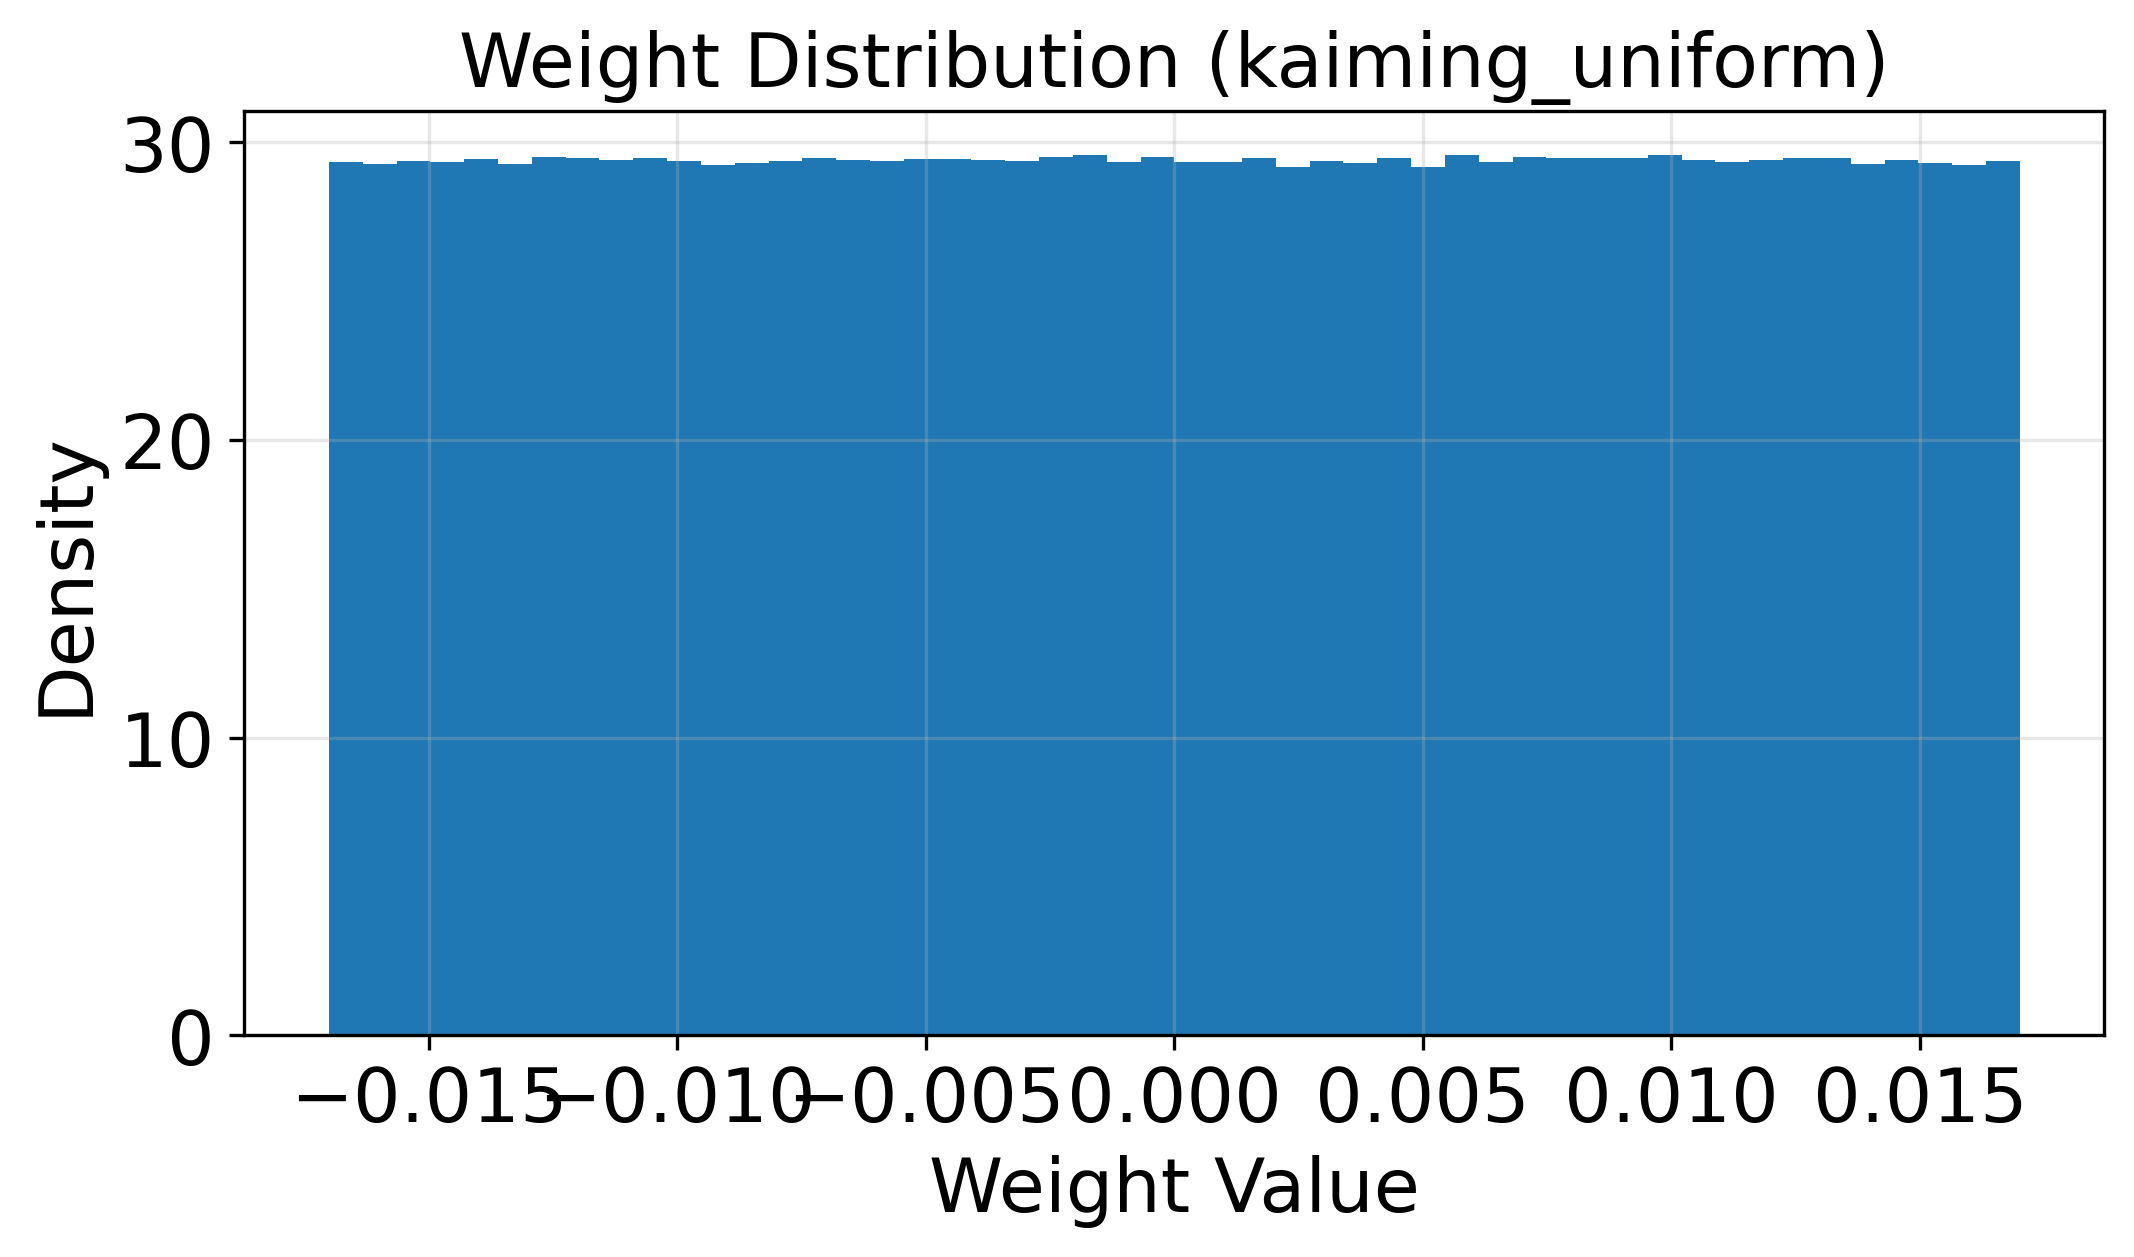

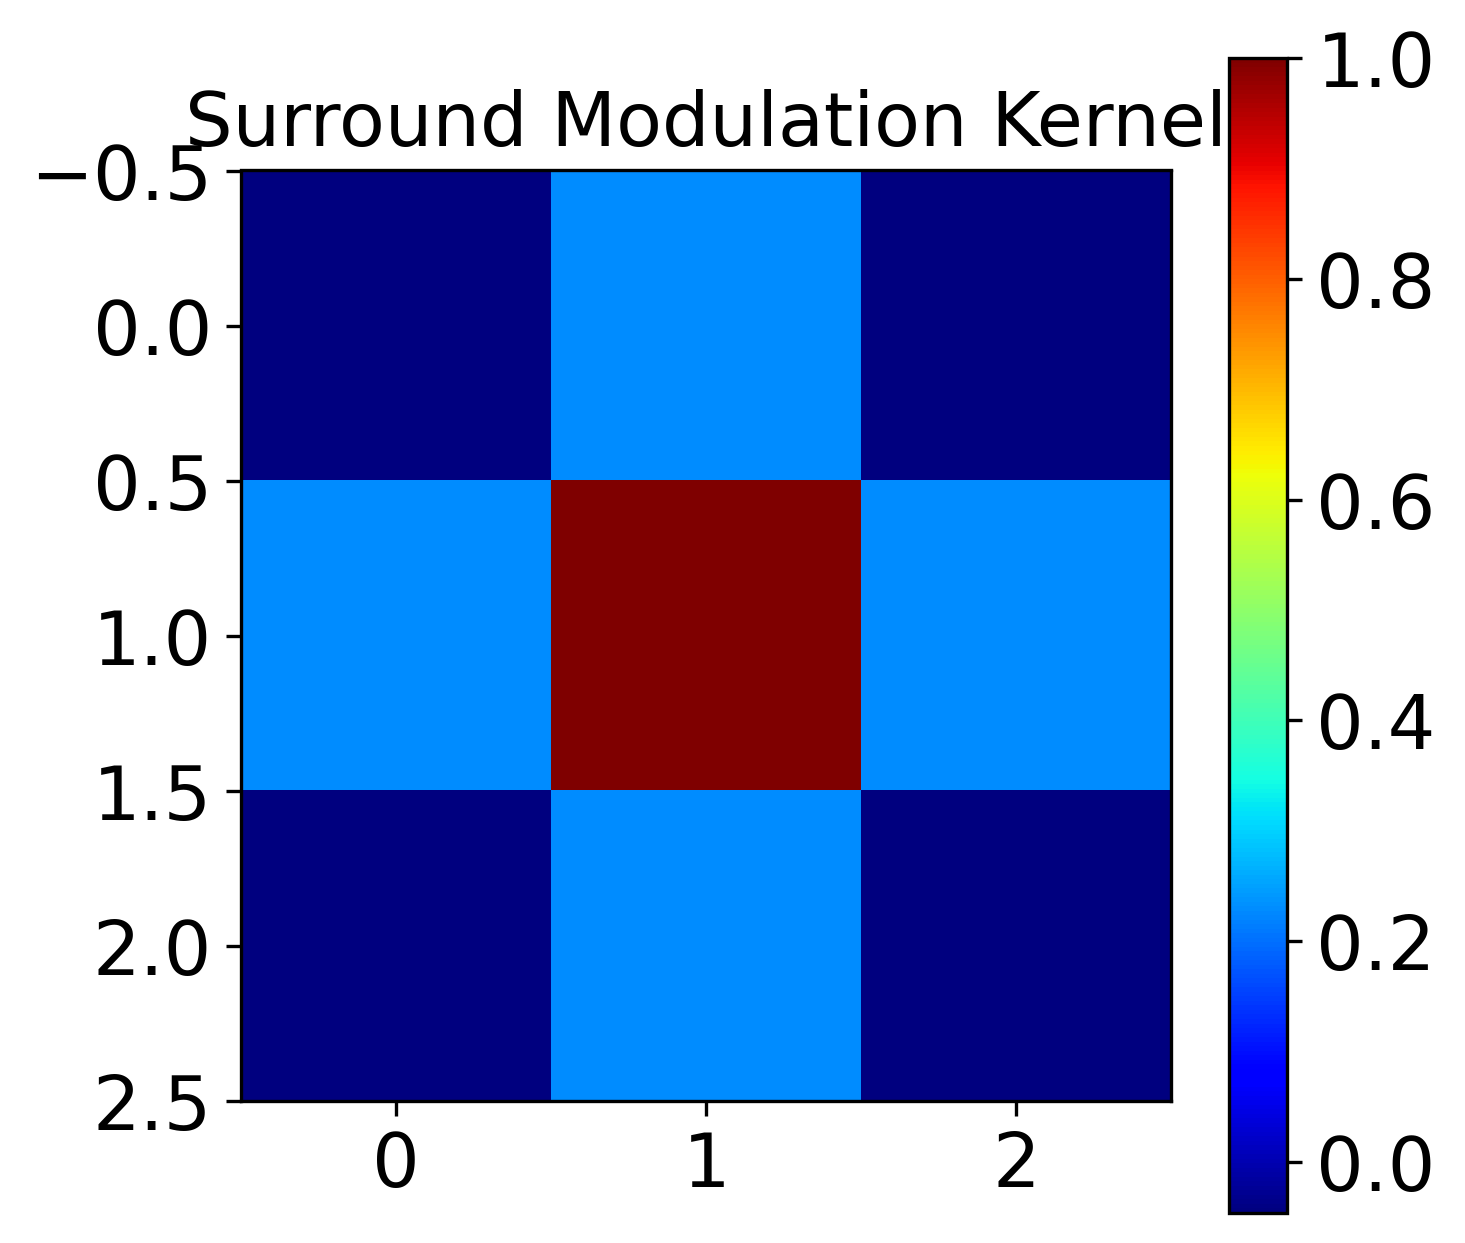

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2975 | Train Acc: 54.66% | Test Loss: 1.0358 | Test Acc: 64.37% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0210 | Train Acc: 64.67% | Test Loss: 0.9781 | Test Acc: 66.43% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9502 | Train Acc: 67.08% | Test Loss: 0.9232 | Test Acc: 67.96% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9084 | Train Acc: 68.57% | Test Loss: 0.9175 | Test Acc: 68.37% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8841 | Train Acc: 69.30% | Test Loss: 0.8479 | Test Acc: 70.68% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8623 | Train Acc: 70.21% | Test Loss: 0.8354 | Test Acc: 71.33% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8534 | Train Acc: 70.60% | Test Loss: 0.8401 | Test Acc: 70.79% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8474 | Train Acc: 70.63% | Test Loss: 0.8274 | Test Acc: 71.09% | LR: 0.001000
Epoch [9/2

In [48]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")

    set_seed(seed)

    #fresh model

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [49]:

train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [50]:
train_acc_df=pd.DataFrame(train_acc)

In [52]:
test_acc_df=pd.DataFrame(test_acc)


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_3_layer_train_acc_.csv",index=False)

In [56]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_3_layer_test_acc_.csv",index=False)


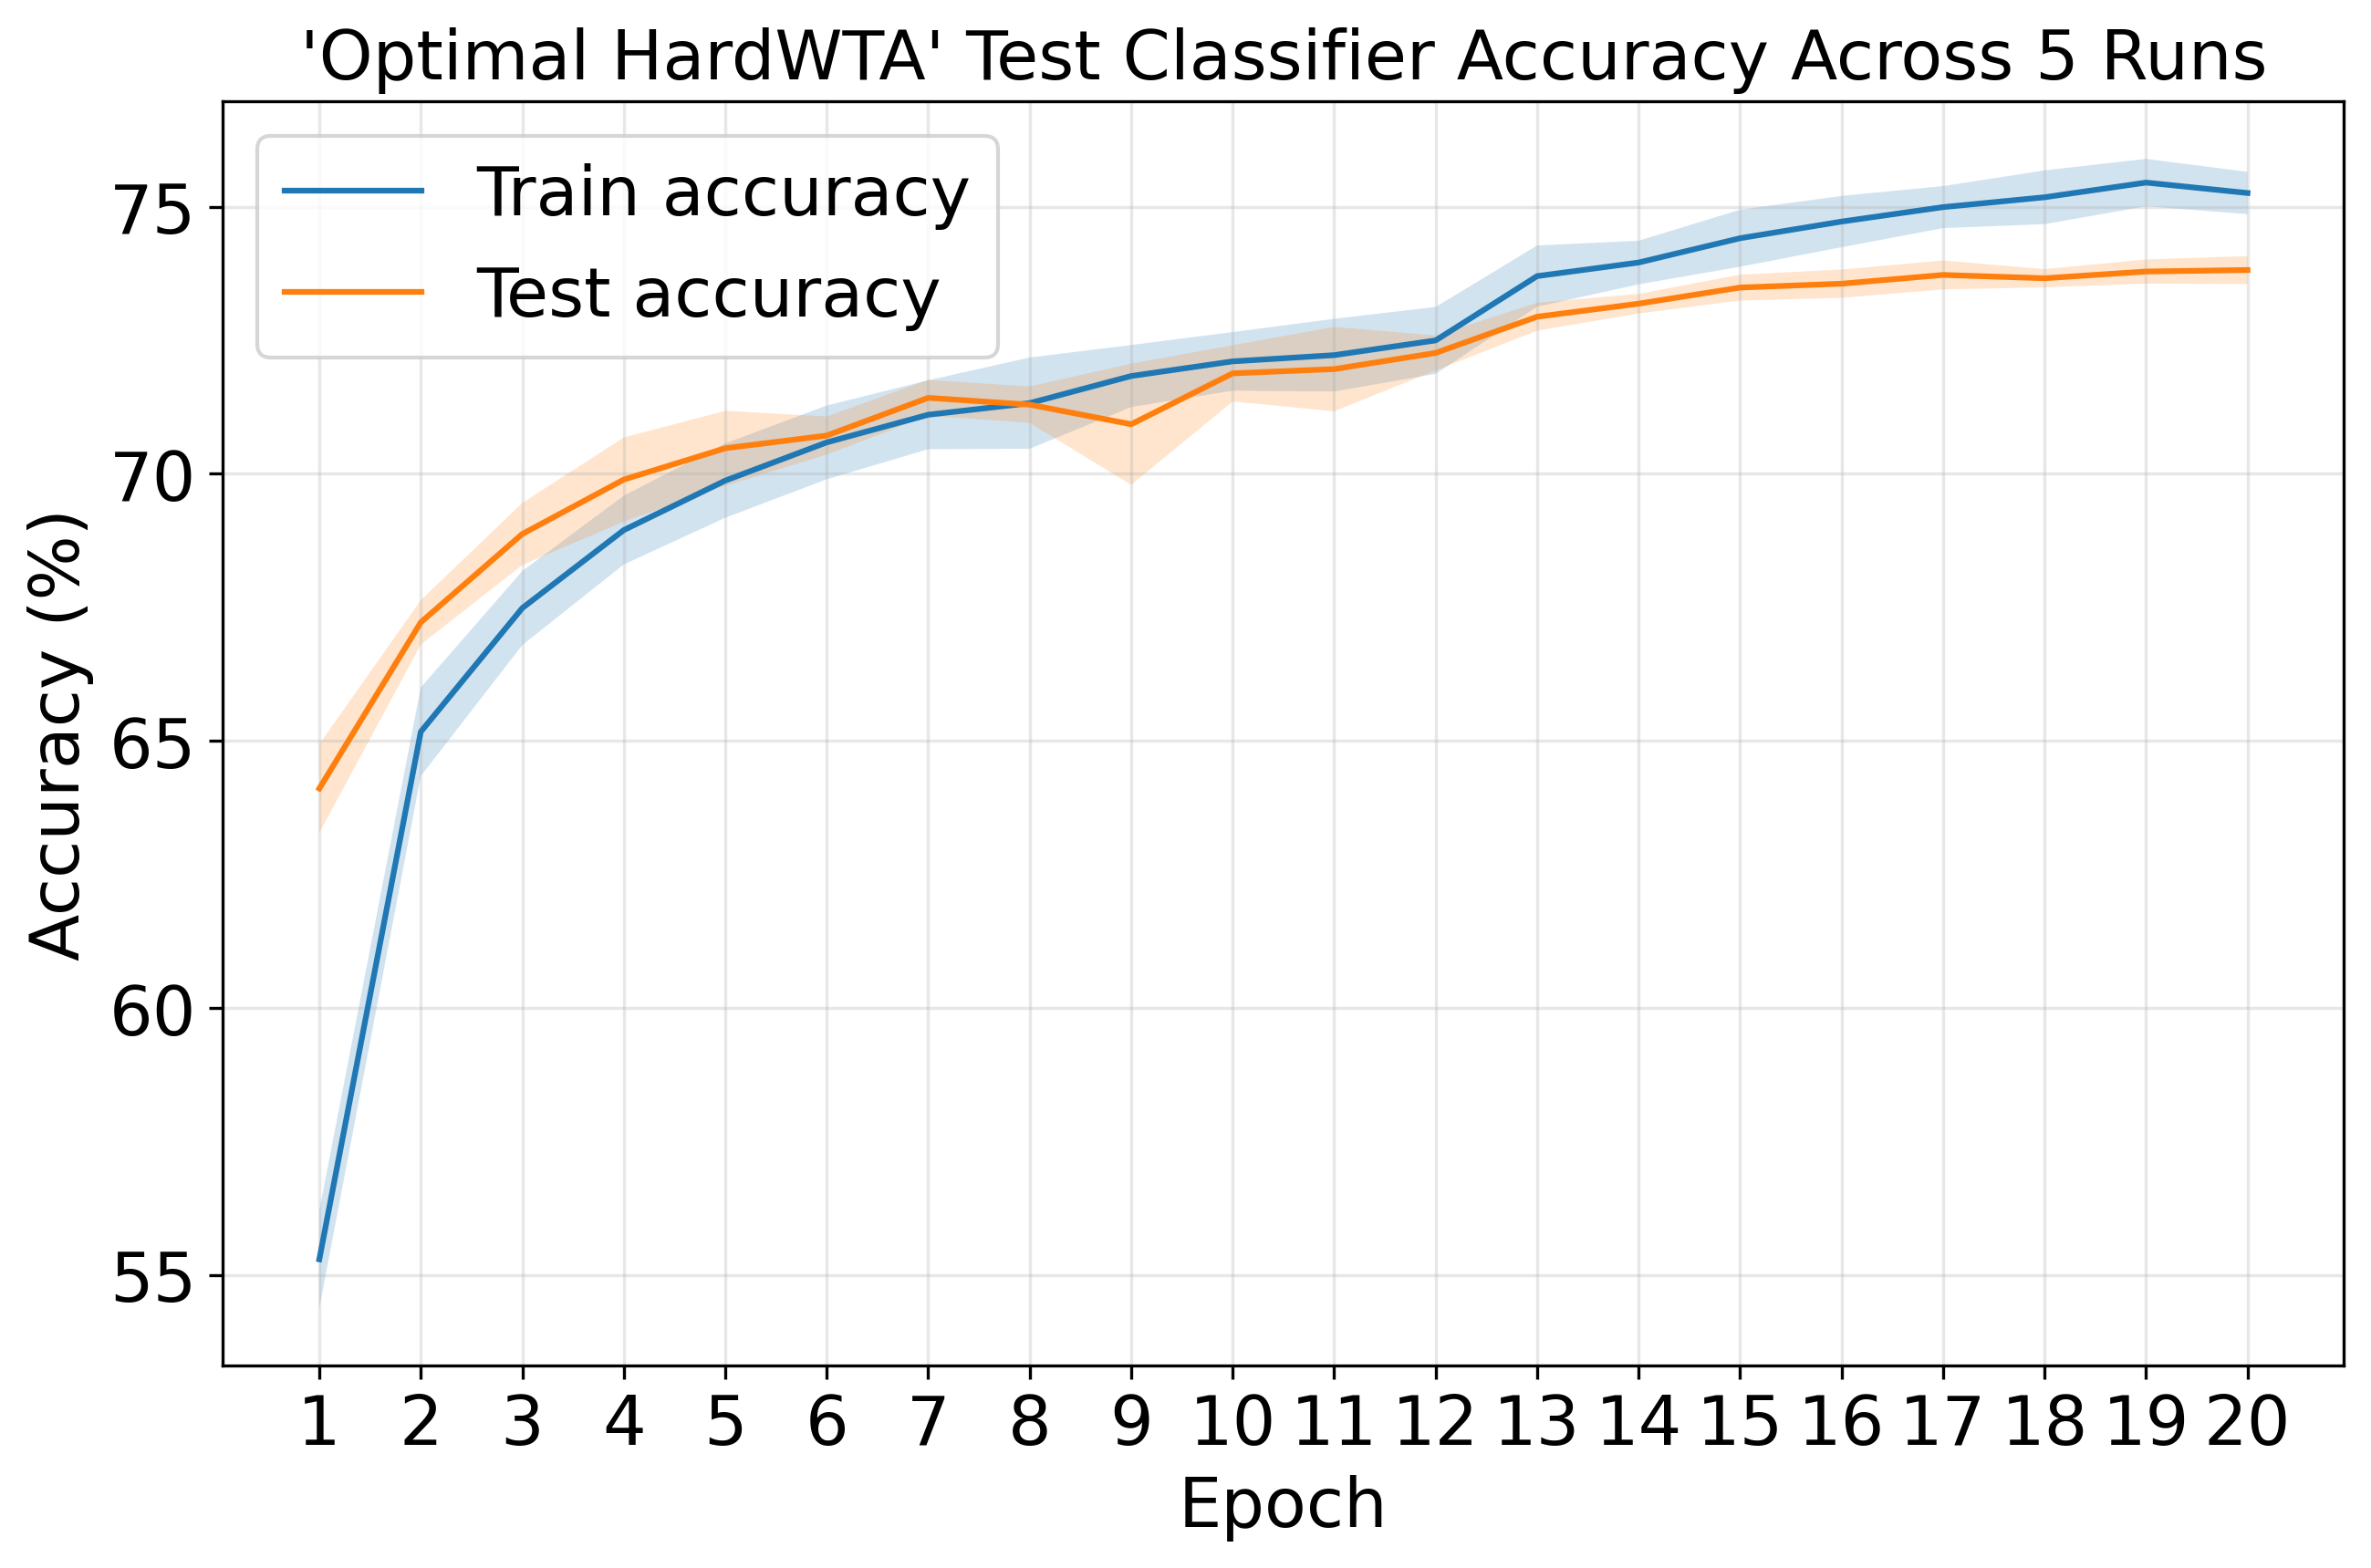

In [57]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [58]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 73.81 ± 0.26%


In [59]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 73.88 ± 0.26%


# Slimming down the model to 1-layer (again data pre-processing stats are computed from train, and no random flipping at test time)